<center><h3><strong> DETECÇÃO DE FRAUDES FINANCEIRAS POR MEIO DE MODELOS SUPERVISIONADOS </strong></h3></center>

- A **detecção eficaz de fraudes é fundamental para Instituições Financeiras** evitarem perdas financeiras significativas, manterem a confiança dos clientes e atenderem requisitos regulatórios. Mas a detecção de fraudes financeiras apresenta um desafio técnico, visto que as transações normais e as fraudulentas podem se parecer muito e dado que sempre haverá um desbalanceamento considerável entre as transações normais e as fraudulentas.

- O objetivo deste projeto é **construir Modelos de Machine Learning capazes de detectar transações fraudulentas com a melhor precisão** afim de **minimizar as perdas financeiras potenciais geradas por fraudes**.

- Para isso, utilizarei técnicas avançadas de **Engenharia de Variáveis (Feature Engineering)**, de **Seleção de Variáveis (Feature Selection)**, de **Machine Learning**, de **Tunagem de Hiperparâmetros**, assim como técnicas de **balanceamento de dados**.

- Em todas as etapas do projeto serão calculadas **Métricas de performance preditiva dos Modelos**, tanto do ponto de vista de identificação do máximo de fraudes possíveis quanto da minimização de falsos positivos (**Recall, Precision, F1-Score, F2-Score, AUROC e Acurácia, além da Matriz de Confusão**).	

**Dicionário das Features/Variáveis**

- **`score_1` a `score_10`**: 


  - Descrição: Notas de bureau de crédito.

  - Finalidade: Utilizadas para avaliar a confiabilidade do comprador.
  
- **`Pais`**: 

  - Descrição: País onde a compra foi realizada.


- **`Produto`**: 


  - Descrição: Item específico adquirido no e-commerce.
    

- **`Categoria_produto`**: 


  - Descrição: Classificação do produto dentro do e-commerce.


   
- **`Entrega_doc_1` a `entrega_doc_3`**: 


  - Descrição: Indicadores de entrega de documentos no momento de criação da conta.


  - Valores: 

 
    - **0** ou **N**: Não entregou.
      
    - **1** ou **Y**: Entregou.
   
    - Vazio: Considerei como não entregou.

- **`Score_fraude_modelo`**: 


  - Descrição: Probabilidade, fornecida pelo modelo atual, de uma compra ser fraudulenta.

  - Valores: Varia de 0 a 100. Quanto mais próximo de 100, maior a confiança do modelo de que a transação é fraudulenta.

- **`Fraude`**: 


  - Descrição: Verificação de autenticidade da compra.

  - Valores: 
 
    - **0**: Transação normal.

     - **1**: Transação fraudulenta.

## Importação das bibliotecas

In [1]:
# Módulos de manipulação de dados
import numpy as np
import pandas as pd

In [2]:
# Pacotes gráficos
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import morethemes as mt
import missingno
import warnings
from lightgbm import plot_importance
from IPython.display import HTML
import base64
warnings.filterwarnings('ignore')

In [3]:
# Pacotes de modelagem
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from fancyimpute import KNN
from tqdm import tqdm
from sklearn.model_selection import TunedThresholdClassifierCV, cross_val_score
from feature_engine.discretisation import DecisionTreeDiscretiser
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from lightgbm import LGBMClassifier
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.preprocessing import OrdinalEncoder, RobustScaler, StandardScaler, MinMaxScaler, PolynomialFeatures
from category_encoders import CatBoostEncoder
from category_encoders import TargetEncoder
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, precision_recall_curve, roc_curve, auc, silhouette_score, fbeta_score
from boruta import BorutaPy
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
import joblib
from joblib import Parallel, delayed
from tqdm import tqdm
from tqdm.std import tqdm        
from tqdm_joblib import tqdm_joblib 
import optuna
roc_auc_scorer = make_scorer(roc_auc_score, needs_proba=True)
recall_scorer = make_scorer(recall_score, average='binary')
precision_scorer = make_scorer(precision_score, average='binary')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pickle

In [4]:
# Pacotes de interpretabilidade
import shap

## Funções

### Função para cálculo das métricas de desempenho dos Modelos de Machine Learning

In [7]:
def calcula_desempenho(modelo, x_train, y_train, x_test, y_test):
    """
    Calcula métricas de desempenho de um modelo de ML treinado.
    Funciona com:
      - Modelos padrão com predict/predict_proba
      - Modelos tunados com threshold (TunedThresholdClassifierCV)
    """
    # --- Predições ---
    try:
        ypred_train = modelo.predict(x_train)
        ypred_proba_train = modelo.predict_proba(x_train)[:,1]
        ypred_test = modelo.predict(x_test)
        ypred_proba_test = modelo.predict_proba(x_test)[:,1]
    except AttributeError:
        # fallback se não houver predict_proba
        ypred_train = modelo.predict(x_train)
        ypred_proba_train = ypred_train
        ypred_test = modelo.predict(x_test)
        ypred_proba_test = ypred_test
    
    # --- Métricas ---
    acc_train = accuracy_score(y_train, ypred_train)
    acc_test = accuracy_score(y_test, ypred_test)
    
    roc_train = roc_auc_score(y_train, ypred_proba_train)
    roc_test = roc_auc_score(y_test, ypred_proba_test)
    
    prec_train = precision_score(y_train, ypred_train, zero_division=0)
    prec_test = precision_score(y_test, ypred_test, zero_division=0)
    
    recl_train = recall_score(y_train, ypred_train)
    recl_test = recall_score(y_test, ypred_test)
    
    f1_train = f1_score(y_train, ypred_train)
    f1_test = f1_score(y_test, ypred_test)
    
    # F2 Score
    f2_train = fbeta_score(y_train, ypred_train, beta=2)
    f2_test = fbeta_score(y_test, ypred_test, beta=2)
    
    # --- DataFrame ---
    df_desemp = pd.DataFrame({
        'Treino':[acc_train, roc_train, prec_train, recl_train, f1_train, f2_train],
        'Teste':[acc_test, roc_test, prec_test, recl_test, f1_test, f2_test]
    }, index=['Acurácia','AUROC','Precision','Recall','F1','F2'])
    
    # Percentual e variação
    df_desemp = (df_desemp * 100).round(4)
    df_desemp['Variação%'] = ((df_desemp['Teste']/df_desemp['Treino']) - 1) * 100
    df_desemp['Variação%'] = df_desemp['Variação%'].round(4)
    df_desemp = df_desemp.applymap(lambda x: f"{x:.2f}%" if isinstance(x, (int,float)) else x)
    
    # --- Threshold ótimo ---
    threshold = None
    # 1) Tentativa direta
    if hasattr(modelo, "best_threshold_"):
        threshold = modelo.best_threshold_
    # 2) Se estiver encapsulado (como TunedThresholdClassifierCV)
    elif hasattr(modelo, "estimator_") and hasattr(modelo.estimator_, "best_threshold_"):
        threshold = modelo.estimator_.best_threshold_
    # 3) Se estiver mais profundamente aninhado
    elif hasattr(modelo, "steps"):  # Pipeline
        for step_name, step_est in modelo.steps:
            if hasattr(step_est, "best_threshold_"):
                threshold = step_est.best_threshold_
                break
    
    if threshold is not None:
        print(f"\n>>> Melhor threshold encontrado: {threshold:.4f}\n")
    
    return df_desemp

### Função que plota a Matriz de Confusão (Confusion Matrix) do Modelo de Machine Learning

In [9]:
def matriz_confusao(model, X, y):
    # Predição do modelo
    y_pred = model.predict(X)

    # Matriz de confusão
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Percentuais linha a linha
    tn_pct = tn / (tn + fp) if (tn + fp) > 0 else 0
    fp_pct = fp / (tn + fp) if (tn + fp) > 0 else 0
    fn_pct = fn / (fn + tp) if (fn + tp) > 0 else 0
    tp_pct = tp / (fn + tp) if (fn + tp) > 0 else 0

    # Percentuais coluna a coluna
    tp_pct_col = tp / (tp + fp) if (tp + fp) > 0 else 0
    fp_pct_col = fp / (tp + fp) if (tp + fp) > 0 else 0
    tn_pct_col = tn / (tn + fn) if (tn + fn) > 0 else 0
    fn_pct_col = fn / (tn + fn) if (tn + fn) > 0 else 0

    # Labels dentro dos quadrantes
    labels = [
        [f"Verdadeiro Negativo (TN)\n{tn:,}\n{tn_pct:.2%}\n({tn_pct_col:.2%})".replace(",", "."),
         f"Falso Posivito (FP)\n{fp:,}\n{fp_pct:.2%}\n({fp_pct_col:.2%})".replace(",", ".")],
        [f"Falso Negativo (FN)\n{fn:,}\n{fn_pct:.2%}\n({fn_pct_col:.2%})".replace(",", "."),
         f"Verdadeiro Positivo (TP)\n{tp:,}\n Recall: {tp_pct:.2%}\n Precision: ({tp_pct_col:.2%})".replace(",", ".")]
    ]

    # Totais
    total_real_normal = tn + fp
    total_real_fraude = fn + tp
    total_pred_normal = tn + fn
    total_pred_fraude = fp + tp
    total_geral = tn + fp + fn + tp

    # Plot da matriz
    plt.figure(figsize=(11, 6))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["Normal", "Fraude"],
                yticklabels=["Normal", "Fraude"],
                annot_kws={"size": 12})

    plt.xlabel("PREDITO", fontsize=14)
    plt.ylabel("REAL", fontsize=14)
    plt.title("Matriz de Confusão", fontsize=18)

    # ---- Legenda lateral completa via figtext ----
    texto_legenda = f"""
Explicação dos Quadrantes:

TP (Verdadeiro Positivo):
Fraude predita corretamente

FN (Falso Negativo):
Fraude classificada erroneamente como Normal

FP (Falso Positivo):
Normal classificado erroneamente como Fraude

TN (Verdadeiro Negativo):
Normal predito corretamente

Total Real Fraude: {total_real_fraude:,}
Total Real Normal: {total_real_normal:,}
Fraude Predita: {total_pred_fraude:,}
Normal Predito: {total_pred_normal:,}
Total Geral: {total_geral:,}
""".replace(",", ".")

    plt.figtext(1.02, 0.2, texto_legenda, ha="left", va="bottom", fontsize=10, family="monospace")

    plt.tight_layout()
    plt.show()

### Função que plota o gráfico da Área abaixo da Curva ROC (AUC OU AUROC)

In [11]:
def curva_roc(modelo, x_train, y_train, x_test, y_test, titulo="Curva ROC"):
    """
    Plota a curva ROC (AUROC) para treino e teste de um modelo de classificação.

    Parâmetros:
    - modelo: modelo já treinado (com método predict_proba).
    - x_train, y_train: dados de treino.
    - x_test, y_test: dados de teste.
    - titulo: título do gráfico (string).
    """
    
    # Probabilidades para classe positiva
    ypred_proba_train = modelo.predict_proba(x_train)[:, 1]
    ypred_proba_test  = modelo.predict_proba(x_test)[:, 1]
    
    # ROC curva para treino
    fpr_train, tpr_train, _ = roc_curve(y_train, ypred_proba_train)
    roc_auc_train = auc(fpr_train, tpr_train)
    
    # ROC curva para teste
    fpr_test, tpr_test, _ = roc_curve(y_test, ypred_proba_test)
    roc_auc_test = auc(fpr_test, tpr_test)
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_train, tpr_train, color='green', lw=2,
             label=f'Treino (AUC = {roc_auc_train:.4f})')
    plt.plot(fpr_test, tpr_test, color='darkorange', lw=2,
             label=f'Teste (AUC = {roc_auc_test:.4f})')
    
    # Linha diagonal (aleatoriedade)
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    
    # Configurações
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate: 1 - True Negative Rate (TNR)')
    plt.ylabel('True Positive Rate (TPR): Recall')
    plt.title(titulo)
    plt.legend(loc='lower right')
    plt.fill_between(fpr_test, tpr_test, color='blue', alpha=0.1,
                     label='AUC = Área sob curva (teste)')
    plt.grid(True)
    plt.show()

## Importação da base de dados

In [12]:
df = pd.read_excel("fraude.xlsx")

In [13]:
df.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,produto,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,data_compra,valor_compra,score_fraude_modelo,fraude
0,4,0.7685,94436.24,20.0,0.444828,1.0,BR,5,Máquininha Corta Barba Cabelo Peito Perna Pelo...,cat_8d714cd,0.883598,240.0,102.0,1,NaN,N,2020-03-27 11:51:16,5.64,66,0
1,4,0.7550,9258.50,1.0,0.000000,33.0,BR,0,Avental Descartavel Manga Longa - 50 Un. Tnt ...,cat_64b574b,0.376019,4008.0,0.0,1,Y,N,2020-04-15 19:58:08,124.71,72,0
2,4,0.7455,242549.09,3.0,0.000000,19.0,AR,23,Bicicleta Mountain Fire Bird Rodado 29 Alumini...,cat_e9110c5,0.516368,1779.0,77.0,1,NaN,N,2020-03-25 18:13:38,339.32,95,0
3,4,0.7631,18923.90,50.0,0.482385,18.0,BR,23,Caneta Delineador Carimbo Olho Gatinho Longo 2...,cat_d06e653,0.154036,1704.0,1147.0,1,NaN,Y,2020-04-16 16:03:10,3.54,2,0
4,2,0.7315,5728.68,15.0,0.000000,1.0,BR,2,Resident Evil Operation Raccoon City Ps3,cat_6c4cfdc,0.855798,1025.0,150.0,1,NaN,N,2020-04-02 10:24:45,3.53,76,0


In [14]:
df.shape

(150000, 20)

## Modelo Baseline atual

- A base de dados apresenta a coluna **`score_fraude_modelo`**, que representa a probabilidade atribuída pelo modelo atual de uma compra ser fraudulenta. Seus valores variam de 0 a 100, onde quanto mais próximo de 100, maior a confiança do modelo de que a transação é fraudulenta.

- Com essas informações, é possível calcular o AUC-ROC diretamente a partir dos scores. Para as demais métricas (Acurácia, Precision, Recall, F1-Score e F2-Score), é necessário definir um Threshold (ponto de corte) para converter os scores em predições binárias. Utilizarei um Threshold de 50.

- Essas métricas servirão como baseline (referência inicial) para comparação com os tratamentos de dados e modelos de Machine Learning que serão desenvolvidos posteriormente no projeto.

- As métricas serão explicadas em detalhes mais adiante.

In [26]:
threshold = 50

# Predições binárias
df['predicao'] = (df['score_fraude_modelo'] >= threshold).astype(int)

# Cálculo das Métricas
recall = recall_score(df['fraude'], df['predicao'])
precision = precision_score(df['fraude'], df['predicao'])
f1 = f1_score(df['fraude'], df['predicao'])
f2 = fbeta_score(df['fraude'], df['predicao'], beta=2)
accuracy = accuracy_score(df['fraude'], df['predicao'])
auc = roc_auc_score(df['fraude'], df['score_fraude_modelo'])


print(f"Threshold considerado: {threshold}")
print(f"Acurácia: {accuracy * 100:.2f}%")
print(f"AUC-ROC: {auc * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1-Score: {f1 * 100:.2f}%")
print(f"F2-Score: {f2 * 100:.2f}%")

Threshold considerado: 50
Acurácia: 54.18%
AUC-ROC: 72.63%
Precision: 7.89%
Recall: 76.44%
F1-Score: 14.30%
F2-Score: 27.91%


## Tratamentos gerais da base de dados

### Linhas duplicadas

In [17]:
df.duplicated().sum()

0

- Não há linhas duplicadas no dataset.

### Exclusão de colunas

- A coluna **`score_fraude_modelo`** é o score do Modelo atual e, por esse motivo, e não deve entrar nas features do novo Modelo de Machine Learning.
  
- Assim, irei excluir essa coluna do dataset.

In [21]:
df = df.drop(columns=['score_fraude_modelo'])

In [22]:
df.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,produto,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,data_compra,valor_compra,fraude
0,4,0.7685,94436.24,20.0,0.444828,1.0,BR,5,Máquininha Corta Barba Cabelo Peito Perna Pelo...,cat_8d714cd,0.883598,240.0,102.0,1,NaN,N,2020-03-27 11:51:16,5.64,0
1,4,0.7550,9258.50,1.0,0.000000,33.0,BR,0,Avental Descartavel Manga Longa - 50 Un. Tnt ...,cat_64b574b,0.376019,4008.0,0.0,1,Y,N,2020-04-15 19:58:08,124.71,0
2,4,0.7455,242549.09,3.0,0.000000,19.0,AR,23,Bicicleta Mountain Fire Bird Rodado 29 Alumini...,cat_e9110c5,0.516368,1779.0,77.0,1,NaN,N,2020-03-25 18:13:38,339.32,0
3,4,0.7631,18923.90,50.0,0.482385,18.0,BR,23,Caneta Delineador Carimbo Olho Gatinho Longo 2...,cat_d06e653,0.154036,1704.0,1147.0,1,NaN,Y,2020-04-16 16:03:10,3.54,0
4,2,0.7315,5728.68,15.0,0.000000,1.0,BR,2,Resident Evil Operation Raccoon City Ps3,cat_6c4cfdc,0.855798,1025.0,150.0,1,NaN,N,2020-04-02 10:24:45,3.53,0


In [23]:
df.shape

(150000, 19)

**Analisando a cardinalidade das colunas categóricas**

In [25]:
colunas_categoricas = df.select_dtypes(include=['object', 'category']).columns

for coluna in colunas_categoricas:
    print(f"{coluna}: {df[coluna].nunique()} categorias")

pais: 51 categorias
produto: 127804 categorias
categoria_produto: 8324 categorias
entrega_doc_2: 2 categorias
entrega_doc_3: 2 categorias


- Nota-se que a coluna **`produto`** apresenta uma cardinalidade extremamente alta (127.804 produtos diferentes em um dataset de 150.000 linhas, o que indica que, na média, cada produto aparece praticamente apenas uma vez).
  
- Essa alta cardinalidade pode atrapalhar muito o Modelo, já que é muito provável que não ajude na identicação de padrões. Além disso, a alta cardinalidade pode viesar o Modelo a dar uma importância indevida a essas features de alta cardinalidade, o que pode atrapalhar muito na generalização, ou seja, tende a gerar alto overfitting. Assim, também iremos excluir essa coluna.

In [27]:
df = df.drop(columns=['produto'])

In [28]:
df.shape

(150000, 18)

### Visualizando o tipo de dado de cada coluna

In [30]:
pd.set_option('display.max_rows', None)
tipos_colunas = pd.DataFrame({
    'Nome da Coluna': df.columns,
    'Tipo de Dado': df.dtypes
}).reset_index(drop=True)
print(tipos_colunas)

       Nome da Coluna    Tipo de Dado
0             score_1           int64
1             score_2         float64
2             score_3         float64
3             score_4         float64
4             score_5         float64
5             score_6         float64
6                pais          object
7             score_7           int64
8   categoria_produto          object
9             score_8         float64
10            score_9         float64
11           score_10         float64
12      entrega_doc_1           int64
13      entrega_doc_2          object
14      entrega_doc_3          object
15        data_compra  datetime64[ns]
16       valor_compra         float64
17             fraude           int64


### Transformação de variáveis/Features

**Irei converter as colunas float64 para float32 para consumir menos memória:**

In [33]:
# Lista de colunas float64
cols_float64 = df.select_dtypes(include=['float64']).columns.tolist()

# Converte apenas essas colunas
df[cols_float64] = df[cols_float64].astype('float32')

In [34]:
pd.set_option('display.max_rows', None)
tipos_colunas = pd.DataFrame({
    'Nome da Coluna': df.columns,
    'Tipo de Dado': df.dtypes
}).reset_index(drop=True)
print(tipos_colunas)

       Nome da Coluna    Tipo de Dado
0             score_1           int64
1             score_2         float32
2             score_3         float32
3             score_4         float32
4             score_5         float32
5             score_6         float32
6                pais          object
7             score_7           int64
8   categoria_produto          object
9             score_8         float32
10            score_9         float32
11           score_10         float32
12      entrega_doc_1           int64
13      entrega_doc_2          object
14      entrega_doc_3          object
15        data_compra  datetime64[ns]
16       valor_compra         float32
17             fraude           int64


### Balanceamento das Classes

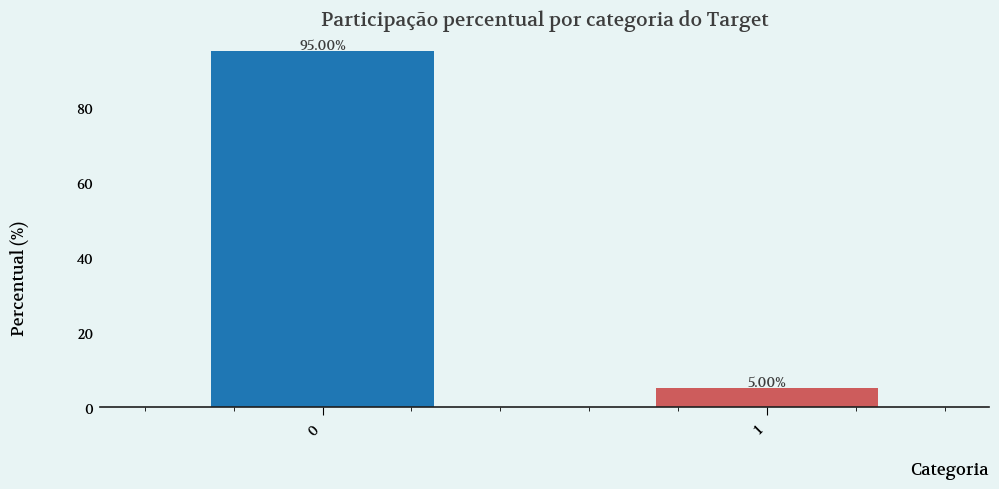

In [36]:

mt.set_theme("economist")

label_percent = df['fraude'].value_counts(normalize=True) * 100

# Identificando maior e menor
idx_max = label_percent.idxmax()
idx_min = label_percent.idxmin()

# Criando lista de cores
colors = []
for idx in label_percent.index:
    if idx == idx_max:
        colors.append("#1f77b4")   
    elif idx == idx_min:
        colors.append("indianred") 
    else:
        colors.append("gray")      

ax = label_percent.plot(kind='bar', figsize=(10,5), color=colors)

plt.title("Participação percentual por categoria do Target", fontsize=14)
plt.xlabel("Categoria", fontsize=12, labelpad=15)
plt.ylabel("Percentual (%)", fontsize=12, labelpad=15)

ax.yaxis.set_label_coords(-0.08, 0.5)

ax.grid(False)

for i, v in enumerate(label_percent):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [37]:
# Voltando o notebook ao tema gráfico original
plt.style.use('default')

- Como podemos verificar acima, 95% das observações da coluna 'fraude' (nosso Target) são da classe 0 e só 5% são da classe 1. Ou seja, **essa base é bastante desbalanceada**.

- Uma das principais métricas de avaliação de modelos de classificação é a Acurácia. A Acurácia é a divisão do total de acertos do Modelo pelo total de linhas da base de dados:


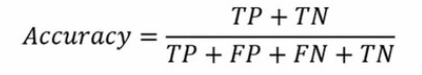

In [45]:

path = "Acurácia.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

- **Entretanto**, para bases desbalanceadas, a **Acurácia não é uma métrica de desempenho muito boa** porque, neste tipo de base, a maioria das instâncias pertence a uma classe majoritária, enquanto uma minoria pertence a uma classe minoritária. Então, se um modelo simplesmente predizer a classe majoritária para todas as instâncias, ele ainda pode obter uma alta Acurácia. Isso ocorre porque a maioria das previsões estará correta apenas devido à predominância da classe majoritária, ignorando completamente a classe minoritária.

- Ex: uma base de dados com 1.000 instâncias, das quais 950 pertencem à classe majoritária (classe 0) e 50 pertencem à classe minoritária (classe 1). Um modelo que prediz *sempre* a classe majoritária terá uma Acurácia de 95% (950/1.000), mesmo que ele nunca consiga prever corretamente a classe minoritária (ou seja, mesmo que ele erre todas as predições da classe minoritária). Essa acurácia de 95% pode parecer muito boa à primeira vista, **mas o modelo não tem utilidade prática porque erra *todas* as classificações da classe minoritária**.

- Na base em questão, se montarmos um modelo de classificação **que estima todas as instâncias como sendo como da classe 0, já teríamos uma Acurácia de 95%, mesmo ele sendo totalmente incapaz de classificar fraudes (classe 1)**. Então, iremos olhar com mais ênfase as outras métricas de desempenho.

- Além de não usar a Acurácia como métrica de desempenho (por a base ser desbalanceada), também iremos usar a técnica de **Class Weight** ao treinar todos os Modelos de Machine Learning que vamos avaliar.
  
- Essa técnica **faz com os Modelos atribuam um peso maior para erros quanto a classes minoritárias.** Assim, se a proporção for de 90% de classe majoritária e 10% de classe minoritária, por exemplo, **o Modelo será penalizado 9 vezes mais (90% / 10%) caso ele erre a classificação de uma classe minoritária (fraude, no nosso caso) do que se ele errar a classificação de uma classe majoritária (transação normal, no nosso caso).** Ou seja, estamos ponderando, dando 9 vezes (nesse exemplo) mais importância para a classificação das fraudes do que para a classificação de transações normais.

- Também há as técnicas conhecidas como **Oversampling** e como **Undersampling**, para tratar bases desbalanceadas.
  
- **O Oversampling irá aumentar a quantidade de dados da classe minoritária**, seja repetindo linhas da classe minoritária de forma randômica, seja usando o algoritmo *SMOTE* que gera novas instâncias sintéticas da classe minoritária interpolando os valores das instâncias existentes da classe minoritária.

- **O Underrsampling irá diminuir a quantidade de dados da classe majoritária**, seja eliminando linhas da classe majoritária de forma randômica, seja usando o algoritmo *Tomek Link Undersampling*, que identifica pares de observações de classes diferentes mas que estão próximos entre si e, destes pares, exclui as observações da classe majoritária.

- **Entretanto** as técnicas de **Oversampling e de Undersampling vem sendo cada vez menos utilizadas** por uma série de motivos:

    - Por alterarem a base de dados original;
    - Por levar à perda significativa de informação pela redução de observações da classe majoritária (no caso do Undersampling);
    - Por poder distorcer a distribuição de dados pela criação de instâncias sintéticas (no caso de Oversampling via SMOTE);
    - Por aumentar a chance de overfitting (quando o modelo fica 'viciado' na base de treino e generaliza mal), no caso do Oversampling randômico, uma vez que algumas instâncias da classe minoritária serão duplicadas, fazendo com que o modelo aprenda padrões específicos do conjunto de treinamento que não generalizam bem para novos dados.

**Irei fazer uma cópia do dataframe original e realizar um tratamento de dados simples para treinar um primeiro modelo de Machine Learning, que será a nossa referência inicial**

## 1º Ciclo de tratamentos específicos seguidos de avaliação de performance utilizando o modelo Árvore de Decisão como referência

In [22]:
df_simplificado = df.copy()

Nesse 1º tratamento **simplificado** de dados irei realizar transformações simplórias para uma primeira avaliação de Modelo de Machine Learning. Irei:
- **Excluir a coluna `data_compra`** que, posteriormente, terá variáveis extraídas dela e um trabalho de Engenharia de Features sobre elas.
- **Excluir colunas** que tenham muitos valores vazios.
- **Excluir as linhas vazias** das colunas restantes.

### Excluindo a coluna de data

In [25]:
df_simplificado = df_simplificado.drop(columns=['data_compra'])

In [26]:
df_simplificado.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,valor_compra,fraude
0,4,0.7685,94436.242188,20.0,0.444828,1.0,BR,5,cat_8d714cd,0.883598,240.0,102.0,1,NaN,N,5.640000,0
1,4,0.7550,9258.500000,1.0,0.000000,33.0,BR,0,cat_64b574b,0.376019,4008.0,0.0,1,Y,N,124.709999,0
2,4,0.7455,242549.093750,3.0,0.000000,19.0,AR,23,cat_e9110c5,0.516368,1779.0,77.0,1,NaN,N,339.320007,0
3,4,0.7631,18923.900391,50.0,0.482385,18.0,BR,23,cat_d06e653,0.154036,1704.0,1147.0,1,NaN,Y,3.540000,0
4,2,0.7315,5728.680176,15.0,0.000000,1.0,BR,2,cat_6c4cfdc,0.855798,1025.0,150.0,1,NaN,N,3.530000,0


In [27]:
df_simplificado.shape

(150000, 17)

### Visualizando os dados missing

In [29]:
(df_simplificado.isnull().sum()/df_simplificado.shape[0] * 100).round(2).astype(str) + '%'

score_1                0.0%
score_2               8.66%
score_3               8.66%
score_4               0.24%
score_5                0.0%
score_6               0.01%
pais                  0.13%
score_7                0.0%
categoria_produto      0.0%
score_8                0.0%
score_9               0.01%
score_10              0.24%
entrega_doc_1          0.0%
entrega_doc_2        72.57%
entrega_doc_3          0.0%
valor_compra           0.0%
fraude                 0.0%
dtype: object

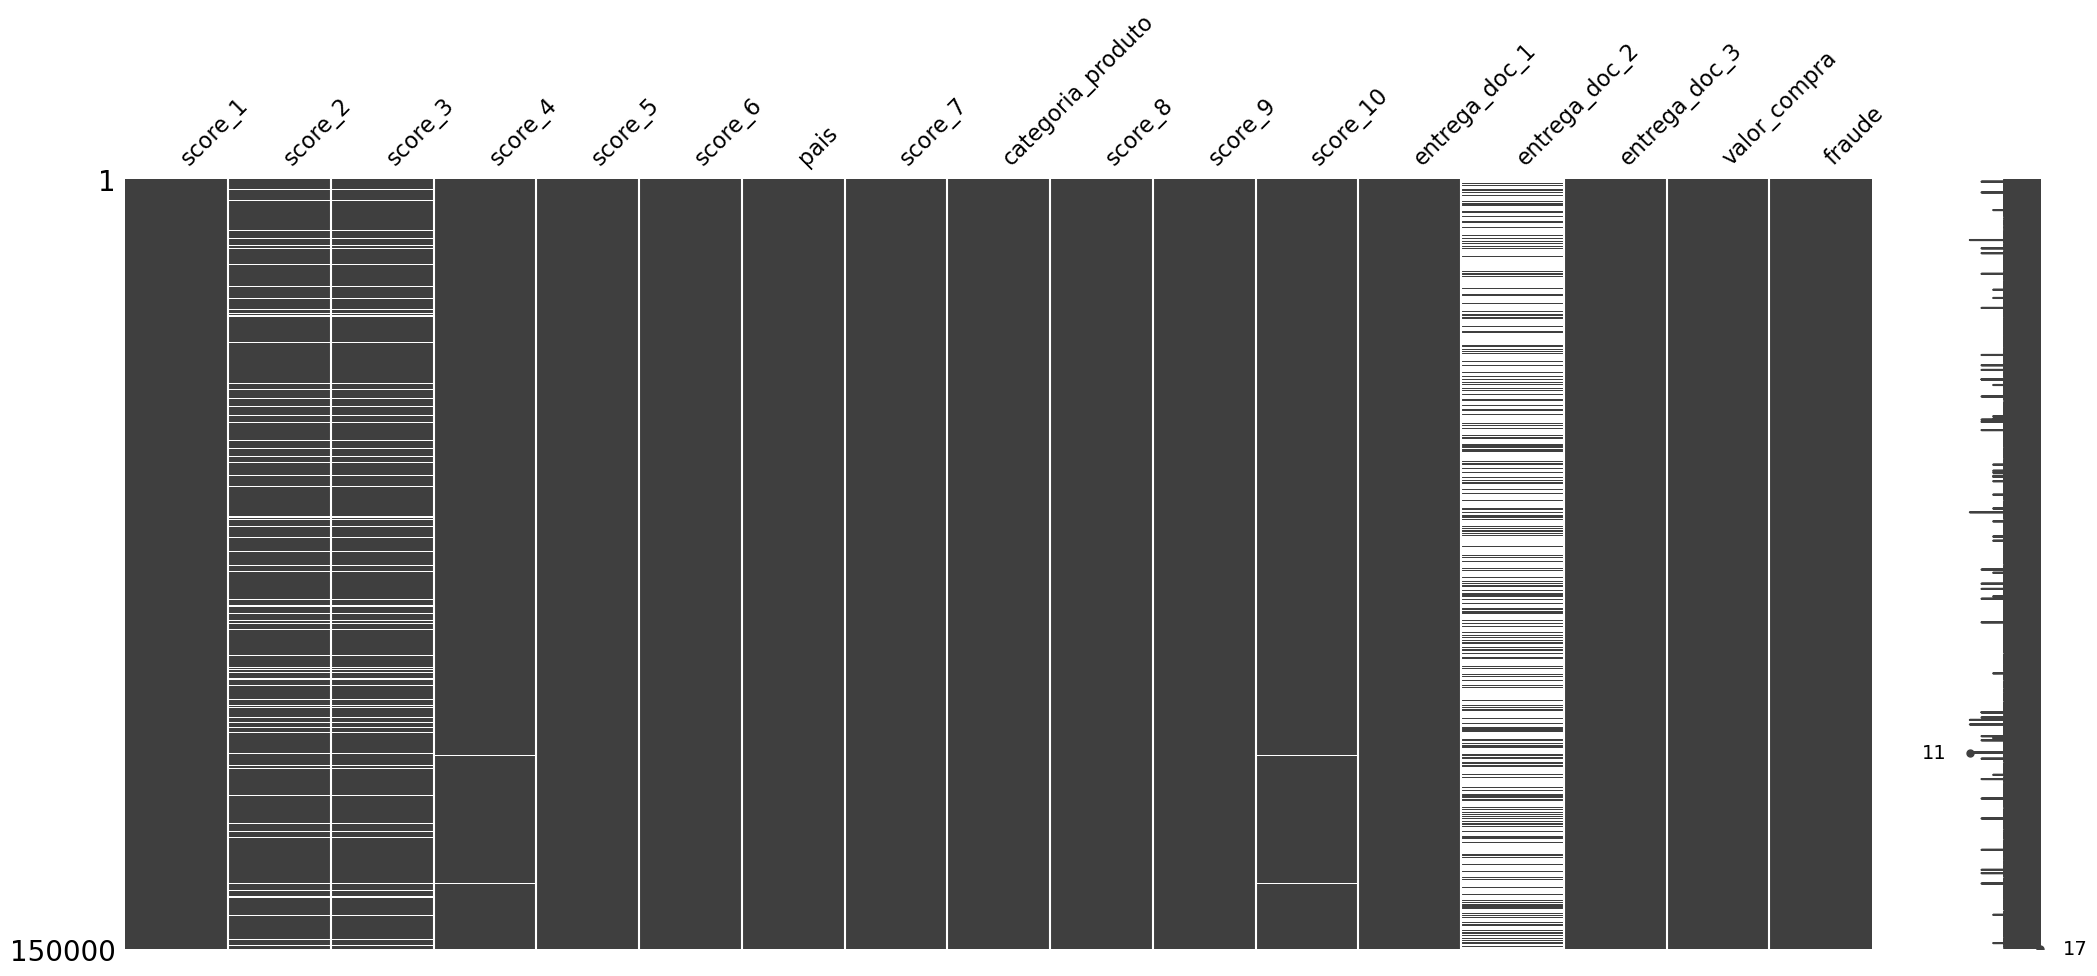

In [30]:
missingno.matrix(df_simplificado)
plt.show()

### Excluindo a coluna 'entrega_doc_2'

- **Para essa rodada de tratamento mais simples, irei excluir a coluna `entrega_doc_2` que possui 72,57% das suas linhas vazias.**

In [33]:
df_simplificado = df_simplificado.drop(columns=['entrega_doc_2'])

In [34]:
df_simplificado.shape

(150000, 16)

### Excluindo as linhas com algum valor faltante

In [36]:
df_simplificado.isnull().sum()

score_1                  0
score_2              12984
score_3              12984
score_4                365
score_5                  0
score_6                 11
pais                   194
score_7                  0
categoria_produto        0
score_8                  0
score_9                 11
score_10               365
entrega_doc_1            0
entrega_doc_3            0
valor_compra             0
fraude                   0
dtype: int64

- **Para essa rodada de tratamento mais simples, irei excluir todas as linhas que apresentarem algum coluna sem dado.**

In [38]:
df_simplificado.dropna(inplace=True)

In [39]:
df_simplificado.isnull().sum()

score_1              0
score_2              0
score_3              0
score_4              0
score_5              0
score_6              0
pais                 0
score_7              0
categoria_produto    0
score_8              0
score_9              0
score_10             0
entrega_doc_1        0
entrega_doc_3        0
valor_compra         0
fraude               0
dtype: int64

In [40]:
df_simplificado.shape

(136515, 16)

### Definição das Features e do Target da base simplificada

In [42]:
x_simplificado = df_simplificado.drop('fraude', axis=1)
y_simplificado = df_simplificado['fraude']

In [43]:
x_simplificado.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_3,valor_compra
0,4,0.7685,94436.242188,20.0,0.444828,1.0,BR,5,cat_8d714cd,0.883598,240.0,102.0,1,N,5.640000
1,4,0.7550,9258.500000,1.0,0.000000,33.0,BR,0,cat_64b574b,0.376019,4008.0,0.0,1,N,124.709999
2,4,0.7455,242549.093750,3.0,0.000000,19.0,AR,23,cat_e9110c5,0.516368,1779.0,77.0,1,N,339.320007
3,4,0.7631,18923.900391,50.0,0.482385,18.0,BR,23,cat_d06e653,0.154036,1704.0,1147.0,1,Y,3.540000
4,2,0.7315,5728.680176,15.0,0.000000,1.0,BR,2,cat_6c4cfdc,0.855798,1025.0,150.0,1,N,3.530000


In [44]:
y_simplificado.head()

0    0
1    0
2    0
3    0
4    0
Name: fraude, dtype: int64

### Separação da base simplificada em Treino e Teste

In [46]:
x_train_simplificado, x_test_simplificado, y_train_simplificado, y_test_simplificado = train_test_split(x_simplificado,
                                                    y_simplificado,
                                                    test_size=0.20,
                                                    stratify=y_simplificado,
                                                    random_state=42)

In [47]:
x_train_simplificado.shape

(109212, 15)

In [48]:
109212/136515

0.8

In [49]:
# Resetar índices do y
y_train_simplificado = y_train_simplificado.reset_index(drop=True)
y_test_simplificado = y_test_simplificado.reset_index(drop=True)

- A coluna **`categoria_produto`** apresenta uma cardinalidade alta (8.324 produtos diferentes em um dataset de 150.000 linhas), mas bem mais baixa que a coluna **`produto`**.
  
- Desta forma, iremos manter essa coluna, mas reduziremos a sua cardinalidade da seguinte maneira:

    - As categorias de produto que concentram 80% das fraudes terão os seus nomes preservados.
      
    - As demais categorias de produto terão  os seus nomes alterados para a categoria 'Outros'.

In [51]:
# 1. Identificar categorias principais APENAS no treino
df_train = x_train_simplificado.copy()
df_train['fraude'] = y_train_simplificado.values

# Filtrar apenas fraudes do conjunto de treino
df_fraudes_train = df_train[df_train['fraude'] == 1]

# Contar fraudes por categoria no treino
fraudes_por_categoria = df_fraudes_train['categoria_produto'].value_counts()

# Calcular porcentagem acumulada
total_fraudes = fraudes_por_categoria.sum()
fraudes_acumuladas = fraudes_por_categoria.cumsum()
pct_acumulado = (fraudes_acumuladas / total_fraudes) * 100

# Identificar categorias que representam até 80% das fraudes
categorias_principais = pct_acumulado[pct_acumulado <= 80].index.tolist()

# Adicionar próxima categoria para garantir pelo menos 80%
if len(categorias_principais) < len(pct_acumulado):
    categorias_principais.append(pct_acumulado.index[len(categorias_principais)])

print(f"Total de fraudes no treino: {total_fraudes}")
print(f"Categorias originais: {x_train_simplificado['categoria_produto'].nunique()}")
print(f"Categorias que concentram 80% das fraudes: {len(categorias_principais)}")
print(f"Porcentagem coberta: {pct_acumulado.iloc[len(categorias_principais)-1]:.2f}%")

# 2. Aplicar o agrupamento em treino e teste
x_train_simplificado['categoria_produto'] = x_train_simplificado['categoria_produto'].apply(
    lambda x: x if x in categorias_principais else 'Outros'
)

x_test_simplificado['categoria_produto'] = x_test_simplificado['categoria_produto'].apply(
    lambda x: x if x in categorias_principais else 'Outros'
)

# 3. Verificação
print(f"\nCategorias únicas no treino após agrupamento: {x_train_simplificado['categoria_produto'].nunique()}")
print(f"Categorias únicas no teste após agrupamento: {x_test_simplificado['categoria_produto'].nunique()}")

Total de fraudes no treino: 5307
Categorias originais: 7492
Categorias que concentram 80% das fraudes: 637
Porcentagem coberta: 80.01%

Categorias únicas no treino após agrupamento: 638
Categorias únicas no teste após agrupamento: 629


In [52]:
x_train_simplificado.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_3,valor_compra
46911,4,0.6763,1.958288e+06,37.0,0.000000,38.0,US,6,cat_41d2590,0.363057,2552.0,102.0,1,Y,58.459999
58648,4,0.7569,2.497393e+05,50.0,0.218965,8.0,BR,40,cat_7d79cff,0.738628,1000.0,499.0,1,Y,23.040001
94471,3,0.7640,3.524118e+04,17.0,0.342466,13.0,BR,37,Outros,0.730335,2140.0,982.0,1,Y,42.020000
31602,4,0.7410,3.491284e+04,1.0,0.222556,0.0,BR,7,cat_ab41ae3,0.208769,131.0,0.0,0,N,7.820000
31273,4,0.7000,3.441451e+04,8.0,0.000000,-1.0,BR,5,cat_c7b1813,0.510674,2440.0,497.0,1,Y,36.230000


In [53]:
x_test_simplificado.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_3,valor_compra
91058,1,0.7821,4.684743e+06,50.0,0.576768,1.0,BR,47,Outros,0.457615,458.0,338.0,1,Y,3.850000
60517,4,0.6627,8.596847e+04,1.0,0.000000,0.0,AR,13,cat_a06f94b,0.670075,2.0,2.0,0,N,13.270000
64683,2,1.0000,3.086000e+01,9.0,0.000000,0.0,AR,3,cat_41d2590,0.161006,2719.0,159.0,1,Y,7.690000
86183,4,0.7945,4.608954e+04,1.0,0.000000,150.0,BR,1,cat_2c670e8,0.184924,1858.0,0.0,1,N,30.389999
139721,2,0.6364,1.438053e+04,50.0,0.000000,70.0,AR,33,Outros,0.301122,832.0,616.0,1,Y,31.450001


### Criação do DataFrame com as Colunas *Categóricas* da base de *Treino* simplificada

In [55]:
x_var_categoricas_train_simplificado = x_train_simplificado.select_dtypes(include=['object']).columns.tolist()

In [56]:
x_var_categoricas_train_simplificado

['pais', 'categoria_produto', 'entrega_doc_3']

In [57]:
x_categoricas_train_simplificado = x_train_simplificado[x_var_categoricas_train_simplificado].copy()

In [58]:
x_categoricas_train_simplificado.head()

,pais,categoria_produto,entrega_doc_3
46911,US,cat_41d2590,Y
58648,BR,cat_7d79cff,Y
94471,BR,Outros,Y
31602,BR,cat_ab41ae3,N
31273,BR,cat_c7b1813,Y


### Criação do DataFrame com as Colunas *Categóricas* da base de *Teste* simplificada

In [60]:
x_var_categoricas_test_simplificado = x_test_simplificado.select_dtypes(include=['object']).columns.tolist()

In [61]:
x_var_categoricas_test_simplificado

['pais', 'categoria_produto', 'entrega_doc_3']

In [62]:
x_categoricas_test_simplificado = x_test_simplificado[x_var_categoricas_test_simplificado].copy()

In [63]:
x_categoricas_test_simplificado.head()

,pais,categoria_produto,entrega_doc_3
91058,BR,Outros,Y
60517,AR,cat_a06f94b,N
64683,AR,cat_41d2590,Y
86183,BR,cat_2c670e8,N
139721,AR,Outros,Y


### Criação do DataFrame com as Colunas *Numéricas* da base de *Treino* simplificada

In [65]:
x_var_numericas_train_simplificado = x_train_simplificado.select_dtypes(include=['float32', 'int64', 'float64', 'int32']).columns.tolist()

In [66]:
x_var_numericas_train_simplificado

['score_1',
 'score_2',
 'score_3',
 'score_4',
 'score_5',
 'score_6',
 'score_7',
 'score_8',
 'score_9',
 'score_10',
 'entrega_doc_1',
 'valor_compra']

In [67]:
x_numericas_train_simplificado = x_train_simplificado[x_var_numericas_train_simplificado].copy()

In [68]:
x_numericas_train_simplificado.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,valor_compra
46911,4,0.6763,1.958288e+06,37.0,0.000000,38.0,6,0.363057,2552.0,102.0,1,58.459999
58648,4,0.7569,2.497393e+05,50.0,0.218965,8.0,40,0.738628,1000.0,499.0,1,23.040001
94471,3,0.7640,3.524118e+04,17.0,0.342466,13.0,37,0.730335,2140.0,982.0,1,42.020000
31602,4,0.7410,3.491284e+04,1.0,0.222556,0.0,7,0.208769,131.0,0.0,0,7.820000
31273,4,0.7000,3.441451e+04,8.0,0.000000,-1.0,5,0.510674,2440.0,497.0,1,36.230000


### Criação do DataFrame com as Colunas *Numéricas* da base de *Teste* simplificada

In [70]:
x_var_numericas_test_simplificado = x_test_simplificado.select_dtypes(include=['float32', 'int64', 'float64', 'int32']).columns.tolist()

In [71]:
x_var_numericas_test_simplificado

['score_1',
 'score_2',
 'score_3',
 'score_4',
 'score_5',
 'score_6',
 'score_7',
 'score_8',
 'score_9',
 'score_10',
 'entrega_doc_1',
 'valor_compra']

In [72]:
x_numericas_test_simplificado = x_test_simplificado[x_var_numericas_test_simplificado].copy()

In [73]:
x_numericas_test_simplificado.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,valor_compra
91058,1,0.7821,4.684743e+06,50.0,0.576768,1.0,47,0.457615,458.0,338.0,1,3.850000
60517,4,0.6627,8.596847e+04,1.0,0.000000,0.0,13,0.670075,2.0,2.0,0,13.270000
64683,2,1.0000,3.086000e+01,9.0,0.000000,0.0,3,0.161006,2719.0,159.0,1,7.690000
86183,4,0.7945,4.608954e+04,1.0,0.000000,150.0,1,0.184924,1858.0,0.0,1,30.389999
139721,2,0.6364,1.438053e+04,50.0,0.000000,70.0,33,0.301122,832.0,616.0,1,31.450001


In [74]:
# Resetar índices
x_numericas_train_simplificado = x_numericas_train_simplificado.reset_index(drop=True)
x_numericas_test_simplificado = x_numericas_test_simplificado.reset_index(drop=True)
x_categoricas_train_simplificado = x_categoricas_train_simplificado.reset_index(drop=True)
x_categoricas_test_simplificado = x_categoricas_test_simplificado.reset_index(drop=True)

### Tratamento de Variáveis Categóricas (Encoding)

- O processo de encoding **tranforma as features/variáveis categóricas em numéricas**.
  
- Existem diversas formas de realizar o Encoding de features categóricas. Vamos tratar de algumas delas:

    - **One Hot Encoder** é o método de encoding que, para cada categoria de cada coluna, é criada uma nova coluna. Para cada coluna criada, em todas as linhas em que a categoria estiver presente, é atribuído o valor 1 nessa nova coluna; nas demais linhas, é atribuído o valor 0. Isso é feito para todas as colunas criadas. Assim, caso uma coluna possua 10 categorias diferentes, por exemplo, o One Hot Encoder irá criar 10 colunas diferentes. Esse problema é conhecido como **"Maldição da Dimensionalidade" (Curse of Dimensionality)**. Serão criadas muitas dimensões para serem analisadas pelo algoritmo. Isso irá exigir muito mais em termos de processamento. E, para a maioria dos algoritmos, **esse problema tende a piorar o poder de predição e de generalização dos modelos**, especialmente aqueles que forem baseados em distância, porque o aumento do número de dimensões faz com que **os dados tendam a ficar muito distantes uns dos outros, o que dificulta a identificação de padrões ou agrupamentos.**
      
    - **OrdinalEncoder** é o método de encoding que transforma os dados de cada feature categórica em um número inteiro. As categorias de cada variável serão enumeradas randomicamente. E categorias iguais terão o mesmo número. Ex: Digamos que a base possui uma coluna COR. E que a cor azul aparece em três linhas e a cor amarelo aparece em quatro linhas. Nas três linhas em que aparece a cor azul, o encoding irá substituir a palavra 'azul', por exemplo, pelo número 1. E nas quatro linhas em que aparece a cor amarelo, o encoding irá substituir a palavra 'amarelo', por exemplo, pelo número 2.
 
    - **Target Encoding (também conhecido como Mean Encoding ou Impact Encoding)**: Atribui valores às variáveis categóricas de acordo com o valor médio do Target de cada categoria de cada variável. Ex: Digamos que a base possui uma coluna COR. E digamos que temos uma coluna de Target que pode apresentar ou o valor 0 ou o valor 1. Digamos que a categoria cor 'azul' apareça em três linhas e que para duas das linhas da categoria azul o Target seja 1 e para uma linha da categoria azul o Target seja 0. Assim, a média do Target para a categoria 'azul' seria de 0.6667 ((1+1+0)/3 observações). Desta forma, todas as linhas com a categoria 'azul' seriam substituidas pelo número 0.6667. E digamos que a categoria cor 'amarelo' apareça em quatro linhas e que para duas das linhas da categoria amarelo o Target seja 1 e para uma linha da categoria amarelo o Target seja 0. Assim, a média do Target para a categoria 'amarelo' seria de 0.50 ((1+1+0+0)/4 observações). Desta forma, todas as linhas com a categoria 'amarelo' seriam substituidas pelo número 0.50. O Target Encoding também pode ser calculado com o parâmetro smoothing. Ele afeta o cálculo no numerador e no denominador. No numerador, somamos o valor do smothing multiplicado pela média global. E, no denominador, somamos o valor do smothing. No exemplo, a média global seria 0.57 ((2+2/7). Assim, a categoria azul seria substituida por 0.6425 ((3 ocorrência de azul x 0.6667 + 1 x 0.57) / 3 + 1). E a categoria amarelo seria subsituida por por 0.514 ((4 ocorrência de amarelo x 0.50 + 1 x 0.57) / 4 + 1).
 
    - **CatBoostEncoder**: Apresenta um mecanismo parecido com o Target Encoding, mas o valor do target das linhas anteriores de cada categoria influencia no cálculo do valor da linha em questão. Assim, cada linha (de uma mesma categoria) apresentará valores diferentes, ao contrário do Target Encoding. O CatBoostEncoder tende a generalizar melhor que o Target Encoding.
 
    - Iremos comparar os métodos OrdinalEncoder e CatBoostEncoder. 

**Visualizado a quantidade de categorias das features categóricas**:

In [78]:
colunas_categoricas = x_train_simplificado.select_dtypes(include=['object', 'category']).columns

for coluna in colunas_categoricas:
    print(f"{coluna}: {x_train_simplificado[coluna].nunique()} categorias")

pais: 49 categorias
categoria_produto: 638 categorias
entrega_doc_3: 2 categorias


**Garantindo que todas as features categóricas da base de treino estejam em formato object e não em formato float**

In [80]:
x_categoricas_train_simplificado = x_categoricas_train_simplificado.astype(str)

**Garantindo que todas as features categóricas da base de teste estejam em formato object e não em formato float**

In [82]:
x_categoricas_test_simplificado = x_categoricas_test_simplificado.astype(str)

In [83]:
ordinal_encoder_simplificado = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [84]:
ordinal_encoder_simplificado.fit(x_categoricas_train_simplificado)

,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'use_encoded_value'
,unknown_value,-1
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [85]:
x_categoricas_train_ordinal_simplificado = ordinal_encoder_simplificado.transform(x_categoricas_train_simplificado)

In [86]:
x_categoricas_train_ordinal_simplificado

array([[ 46., 185.,   1.],
       [  6., 324.,   1.],
       [  6.,   0.,   1.],
       ...,
       [  6.,   0.,   1.],
       [  6.,   0.,   1.],
       [ 47.,   0.,   1.]])

In [87]:
# Criar DataFrame
x_categoricas_train_ordinal_df_simplificado = pd.DataFrame(
    x_categoricas_train_ordinal_simplificado, 
    columns=x_categoricas_train_simplificado.columns,
    index=x_categoricas_train_simplificado.index
)

In [88]:
x_categoricas_train_ordinal_df_simplificado.head()

,pais,categoria_produto,entrega_doc_3
0,46.0,185.0,1.0
1,6.0,324.0,1.0
2,6.0,0.0,1.0
3,6.0,443.0,0.0
4,6.0,504.0,1.0


**Executando o transform do encoding na base de Teste com base no fit da base de Treino**

In [90]:
x_categoricas_test_ordinal_simplificado = ordinal_encoder_simplificado.transform(x_categoricas_test_simplificado)

In [91]:
x_categoricas_test_ordinal_simplificado

array([[  6.,   0.,   1.],
       [  2., 415.,   0.],
       [  2., 185.,   1.],
       ...,
       [ 47.,   0.,   0.],
       [  6.,   0.,   1.],
       [ 47.,   0.,   0.]])

In [92]:
# Criar DataFrame
x_categoricas_test_ordinal_df_simplificado = pd.DataFrame(
    x_categoricas_test_ordinal_simplificado, 
    columns=x_categoricas_test_simplificado.columns,
    index=x_categoricas_test_simplificado.index
)

In [93]:
x_categoricas_test_ordinal_df_simplificado.head()

,pais,categoria_produto,entrega_doc_3
0,6.0,0.0,1.0
1,2.0,415.0,0.0
2,2.0,185.0,1.0
3,6.0,130.0,0.0
4,2.0,0.0,1.0


**Concatenação do dataframe da base de TREINO das variáveis categóricas que passaram pelo processo de encoding com as variáveis numéricas**

In [95]:
x_train_ordinal_simplificado = pd.concat([x_numericas_train_simplificado, x_categoricas_train_ordinal_df_simplificado], axis=1)

In [96]:
x_train_ordinal_simplificado.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,valor_compra,pais,categoria_produto,entrega_doc_3
0,4,0.6763,1.958288e+06,37.0,0.000000,38.0,6,0.363057,2552.0,102.0,1,58.459999,46.0,185.0,1.0
1,4,0.7569,2.497393e+05,50.0,0.218965,8.0,40,0.738628,1000.0,499.0,1,23.040001,6.0,324.0,1.0
2,3,0.7640,3.524118e+04,17.0,0.342466,13.0,37,0.730335,2140.0,982.0,1,42.020000,6.0,0.0,1.0
3,4,0.7410,3.491284e+04,1.0,0.222556,0.0,7,0.208769,131.0,0.0,0,7.820000,6.0,443.0,0.0
4,4,0.7000,3.441451e+04,8.0,0.000000,-1.0,5,0.510674,2440.0,497.0,1,36.230000,6.0,504.0,1.0


In [97]:
x_train_ordinal_simplificado.shape

(109212, 15)

**Concatenação do dataframe da base de TESTE das variáveis categóricas que passaram pelo processo de encoding com as variáveis numéricas**

In [99]:
x_test_ordinal_simplificado = pd.concat([x_numericas_test_simplificado, x_categoricas_test_ordinal_df_simplificado], axis=1)

In [100]:
x_test_ordinal_simplificado.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,valor_compra,pais,categoria_produto,entrega_doc_3
0,1,0.7821,4.684743e+06,50.0,0.576768,1.0,47,0.457615,458.0,338.0,1,3.850000,6.0,0.0,1.0
1,4,0.6627,8.596847e+04,1.0,0.000000,0.0,13,0.670075,2.0,2.0,0,13.270000,2.0,415.0,0.0
2,2,1.0000,3.086000e+01,9.0,0.000000,0.0,3,0.161006,2719.0,159.0,1,7.690000,2.0,185.0,1.0
3,4,0.7945,4.608954e+04,1.0,0.000000,150.0,1,0.184924,1858.0,0.0,1,30.389999,6.0,130.0,0.0
4,2,0.6364,1.438053e+04,50.0,0.000000,70.0,33,0.301122,832.0,616.0,1,31.450001,2.0,0.0,1.0


In [101]:
x_test_ordinal_simplificado.shape

(27303, 15)

### Treinamento de uma primeira Árvore de Decisão para uma primeira avaliação da performance, considerando apenas o tratamento simplificado dos dados

**Instanciando o Modelo**

In [104]:
dt_ordinal_simplificado = DecisionTreeClassifier(min_samples_leaf=2,
                                     max_depth=5,
                                     class_weight='balanced',    
                                     random_state=42)

**Treinando o modelo na base de Treino**

In [106]:
dt_ordinal_simplificado.fit(x_train_ordinal_simplificado, y_train_simplificado)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Desempenho do Modelo**

**Recall**

- Uma das principais Métricas de Performance em modelos de classificação é o **Recall (ou Sensibilidade)**. Ela é calculada dividindo-se os Verdadeiros Positivos (TP) pela soma de Verdadeiros Positivos (TP) e Falsos Negativos (FN), conforme fórmula abaixo:


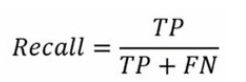

In [110]:

path = "Recall.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

- Ou seja, **de todas as classificações que, de fato, foram positivas (fraude, no nosso caso), quantas o Modelo previu que seriam positivas**. Dito de outra forma, o Recall mostra a proporção de casos positivos reais que o modelo conseguiu identificar corretamente. É crítico quando é essencial capturar o máximo de casos positivos. No nosso caso, a classificação positiva é a fraude.

- No caso desta base de dados, um **Recall de 80%, por exemplo**, nos informa que **de cada 100 fraudes que realmente ocorreram, o modelo preveria 80 dessas fraudes** e deixaria de identificar corretamente 20 fraudes.

- Ou seja, neste caso, **um Recall alto quer dizer a grande maioria das fraudes reais serão detectados pelo Modelo de Machine Learning**.

- Quanto maior for essa métrica, melhor.

**Precision**

- Outra Métrica de Performance muito importante de Modelos de Classificação é o **Precision**. Ela é calculada dividindo-se os Verdadeiros Positivos (TP) pela soma de Verdadeiros Positivos (TP) e Falsos Positivos (FP), conforme fórmula abaixo:


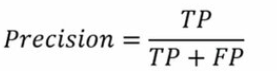

In [114]:

path = "Precision.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

- Ou seja, **de todas as classificações que o Modelo *previu* que seriam positivas (previsão de fraude, no nosso caso), quantas de fato foram positivas**. Dito de outra forma, o Precision calcula a proporção de **previsões** positivas que foram corretas. Ou seja, calcula o nível de precisão do que o modelo *prevê* como classe postiva. É especialmente importante quando o custo de um Falso Positivo é alto.

- No caso desta base de dados, um **Precision de 60%, por exemplo**, nos informa que **de cada 100 previsões de fraude previstas pelo Modelo, 60 de fato foram fraude**. Nesse cenário, a cada 100 previsões de fraude previstas pelo Modelo, **40 (100-60) transações normais são erroneamente identificados, pelo Modelo, como fraude**. A empresa, ao tratar essas 40 transações como fraude, **poderá gastar recursos e esforços do time de maneira desnecessária e poderá gerar desgastes com clientes, o que representa um custo de oportunidade**.

- Quanto maior for essa métrica, melhor. No caso desta base de dados, quanto maior o Precision, **mais eficaz o Modelo será em prever corretamente as fraudes**. Isso permite que a empresa **tome decisões mais assertivas e direcionadas para se defender desse tipo de situação**, evitando o incoveniente e a aplicação de esforços para tratar transações normais.

- Ou seja, nesse caso, **um Precision alto quer dizer que haverão poucos alarmes falsos gerados pelo Modelo de Machine Learning.**

**F1 Score**

- **Geralmente, quando o Recall aumenta, o Precision diminui**.
  
- Podemos entender isso com um exemplo: se o Modelo for adaptado para obter um Recall maior, ele tenderá a considerar uma quantidade maior de instâncias como fraude, de forma a englobar a maior quantidade de fraudes possível. **No limite extremo, o modelo poderia considerar tudo como fraude. Nesse caso, o Recall seria de 100% porque todas as fraudes efetivas seriam previstos pelo Modelo. Mas isso ocorrerá às custas de uma piora no Precision, porque o Modelo passará a considerar várias instâncias de transação normal como fraude, piorando a precisão (Precision) das previsões de fraude**.

- Uma métrica que que faz um balanço entre o Recall e o Precision é o F1 Score. Ele é a média harmônica entre o Recall e o Precision, medindo um equilíbrio entre essas duas métricas. A fórmula do F1 Score é:


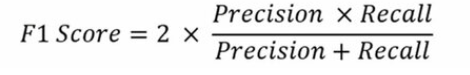

In [118]:

path = "F1.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

**F2 Score**

- Entretanto, o F1 Score atribui, na média harmônica, o mesmo peso para o Precision e para o Recall.

- Neste problema de fraude, não temos explicitamente o custo da fraude e o custo de oportunidade de mover recursos para tratar uma transação normal como fraudulenta. Mas iremos partir do pressuposto que o custo da fraude é superior ao custo de oportunidade de um Precision baixo.

- Assim, **a nossa principal métrica de referência para as tomadas de decisões e maximização de hiperparâmetros será o F2-Score que é a média harmônica entre o Precision e o Recall, dando 4 vezes mais peso para o Recall do que para o Precision (β= 2 e β²= 4)**. Assim, o Recall será priorizado, mas o Precision não será desconsiderado nas decisões ao usarmos o F2-Score como referência, uma vez que um Precision muito baixo gerará excessivos alarmes falsos para o negócio.


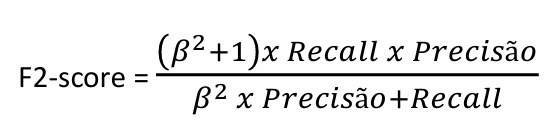

In [1057]:

path = "F2.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

**Área abaixo da Curva ROC**

- Outra forma de medirmos a performance de um Modelo de Classificação é através do cálculo da Área da abaixo da Curva ROC: 

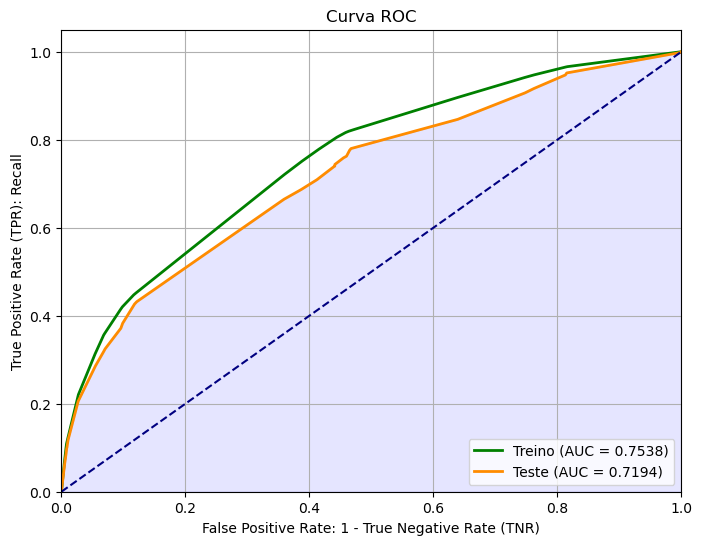

In [121]:
curva_roc(dt_ordinal_simplificado, x_train_ordinal_simplificado, y_train_simplificado, x_test_ordinal_simplificado, y_test_simplificado, titulo="Curva ROC")

- No gráfico acima, nós temos **no Eixo Y** o **True Positive Rate (TPR)** que nada mais é que a métrica de desempenho **Recall**. Ou seja, de todas as classificações que, de fato, foram positivas, quantas o modelo previu que seriam positivas.
  
- No **Eixo X** nós temos a **False Positive Rate**. Ela é calculada como **1 - True Negative Rate (TNR)**. A TNR é a divisão dos Verdadeiros Negativos (TN) pela soma dos Verdadeiros Negativos (TN) com os Falsos Positivos (FP). Ou seja, **a True Negative Rate (TNR) nos retorna de todas as classificações que, de fato, foram negativas, quantas o modelo previu que seriam negativas**.
  
- **Um modelo de classificação perfeito teria 100% de True Positive Rate (TPR) e 100% de True Negative Rate (TNR)**. Ou seja, esse modelo perfeito não apresentaria Falsos Positivos e nem Falsos Negativos.
  
- **Por isso que o Eixo X do gráfico acima é 1 - True Negative Rate (TNR)**. Porque iremos calcular a área desse gráfico para obtermos uma medida de performance do modelo. Assim, quanto mais próxima à diagonal superior esquerda do gráfico, maior será a área abaixo da curva. **Essa será a área de um modelo perfeito, em que a True Positive Rate (no Eixo Y) será de 100% e 1 - True Negative Rate (TNR) será de 0% (no Eixo X), já que, nesse modelo perfeito, a TNR será de 100%.**
  
- A curva laranja do gráfico acima é conhecida como Curva ROC (Receiver Operating Characteristic Curve. Em português, Curva Característica de Operação do Receptor). E a área abaixo dessa curva é conhecida como AUC, ou AUROC (Area Under Curve. Ou seja, área abaixo da curva ROC). **Quanto maior for o indicador AUC, maior será a capacidade do modelo de identificar Verdadeiros Positivos e Verdadeiros Negativos e menores serão os Falsos Positivos e Falsos Negativos.**

- A linha tracejada corta o quadrado ao meio. O AUC dessa linha é de 50%. Ela representa um modelo aleatório que funciona como uma moeda de cara e coroa. 

In [123]:
desempenho_dt_ordinal_simplificado=calcula_desempenho(dt_ordinal_simplificado, x_train_ordinal_simplificado, y_train_simplificado, x_test_ordinal_simplificado, y_test_simplificado)

In [124]:
desempenho_dt_ordinal_simplificado

,Treino,Teste,Variação%
Acurácia,59.42%,59.38%,-0.06%
AUROC,75.38%,71.94%,-4.57%
Precision,8.74%,8.08%,-7.53%
Recall,77.84%,70.91%,-8.90%
F1,15.71%,14.51%,-7.67%
F2,30.15%,27.75%,-7.96%


**Matriz de Confusão da base de Treino**

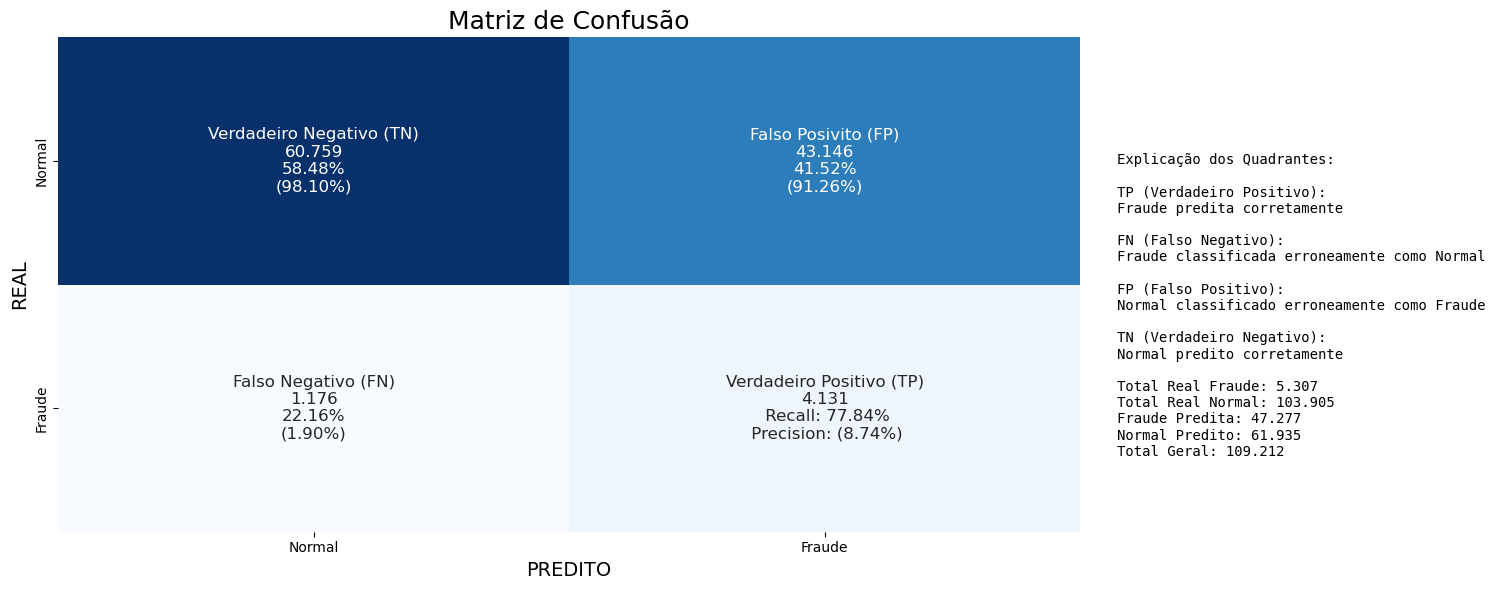

In [126]:
matriz_confusao(dt_ordinal_simplificado, x_train_ordinal_simplificado, y_train_simplificado)

Na **Matriz de Confusão** (Confusion Matriz), da base de Treino, acima, podemos verificar que:

- Temos um total de **109.212 observações na base de Treino**.

    - Dessas, **5.307** observações (4.131 + 1.176) foram **Fraudes** (Positivo no contexto de Matriz de Confusão).
      
    - E **103.905** observações (60.759 + 43.146) foram **Normais** (Negativo no contexto de Matriz de Confusão).

- **Verdadeiro Positivo (TP - True Positive)**: Considerando a base de Treino, verificamos que este Modelo de Machine Learning identificou **4.131** observações Verdadeiro Positivo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam positivas (ser Fraude) e de fato foram positivas**. Ou seja, ele **conseguiu identificar 77,84% dos registros que de fato foram fraude** (4.131/5.307). Esse percentual é o **Recall**. Além disso, considerando que este Modelo previu 47.277 observações como fraude (4.131 + 43.146), **o nível de assertividade das *previsões* que o Modelo faz foi de 8,74% (4.131/47.277)**. Esse percentual é o **Precision**.

- **Falso Negativo (FN - False Negative)**: Considerando a base de Treino, verificamos que este Modelo de Machine Learning identificou **1.176** observações Falso Negativo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam negativas (ser Normal) mas, de fato, foram positivas (foram fraude)**. Isso representa 22,16% das fraudes efetivas. O Falso Negativo também é conhecido como Erro do Tipo II.

- **Falso Positivo (FP - False Positive)**: Considerando a base de Treino, verificamos que este Modelo de Machine Learning identificou **43.146** observações Falso Positivo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam positivas (ser Fraude) mas, de fato, foram negativas (foram Normais)**. Isso representa 91,26% das previsões de fraude realizadas por este Modelo. O Falso Positivo também é conhecido como Erro do Tipo I.

- **Verdadeiro Negativo (TN - True Negative)**: Considerando a base de Treino, verificamos que este Modelo de Machine Learning identificou **60.759** observações Verdadeiro Negativo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam negativas (ser Normal) e de fato foram negativas**. Ou seja, ele conseguiu identificar 58,48% dos registros que de fato foram Normais (60.759/103.905).

**Matriz de Confusão da base de Teste**

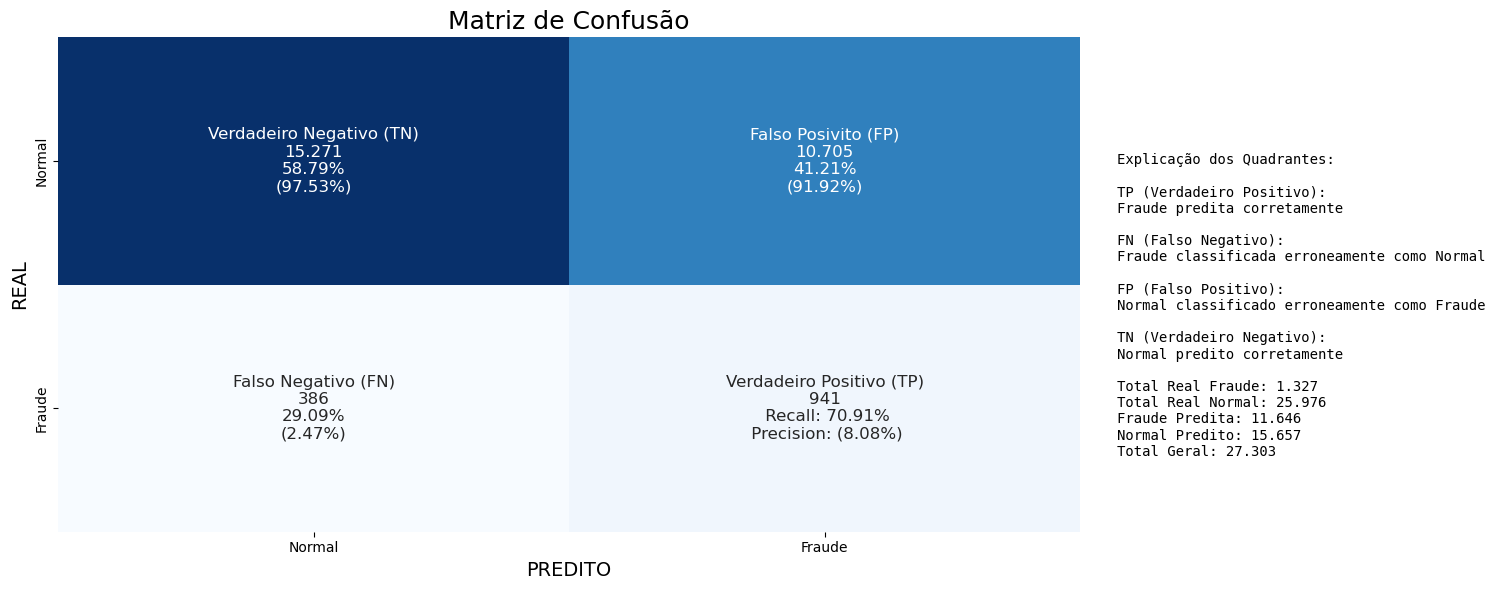

In [129]:
matriz_confusao(dt_ordinal_simplificado, x_test_ordinal_simplificado, y_test_simplificado)

Na **Matriz de Confusão** (Confusion Matriz), da base de Teste, acima, podemos verificar que:

- Temos um total de **27.303 observações na base de Treino**.

    - Dessas, **1.327** observações (941 + 386) foram **Fraudes** (Positivo no contexto de Matriz de Confusão).
      
    - E **25.976** observações (15.271 + 10.705) foram **Normais** (Negativo no contexto de Matriz de Confusão).

- **Verdadeiro Positivo (TP - True Positive)**: Considerando a base de Teste, verificamos que este Modelo de Machine Learning identificou **941** observações Verdadeiro Positivo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam positivas (ser Fraude) e de fato foram positivas**. Ou seja, ele **conseguiu identificar 70,91% dos registros que de fato foram fraude** (941/1.327). Esse percentual é o **Recall**. Além disso, considerando que este Modelo previu 11.646 observações como fraude (941 + 10.705), **o nível de assertividade das *previsões* que o Modelo faz foi de 8,08% (941/11.646)**. Esse percentual é o **Precision**.

- **Falso Negativo (FN - False Negative)**: Considerando a base de Teste, verificamos que este Modelo de Machine Learning identificou **386** observações Falso Negativo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam negativas (ser Normal) mas, de fato, foram positivas (foram fraude)**. Isso representa 29,09% das fraudes efetivas. O Falso Negativo também é conhecido como Erro do Tipo II.

- **Falso Positivo (FP - False Positive)**: Considerando a base de Teste, verificamos que este Modelo de Machine Learning identificou **10.705** observações Falso Positivo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam positivas (ser Fraude) mas, de fato, foram negativas (foram Normais)**. Isso representa 91,92% das previsões de fraude realizadas por este Modelo. O Falso Positivo também é conhecido como Erro do Tipo I.

- **Verdadeiro Negativo (TN - True Negative)**: Considerando a base de Teste, verificamos que este Modelo de Machine Learning identificou **15.271** observações Verdadeiro Negativo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam negativas (ser Normal) e de fato foram negativas**. Ou seja, ele conseguiu identificar 58,79% dos registros que de fato foram Normais (15.271/25.976).

### CatBoostEncoder

In [131]:
cbe_simplificado = CatBoostEncoder(cols=x_categoricas_train_simplificado.columns.tolist(),a=1000)

In [132]:
cbe_simplificado.fit(x_categoricas_train_simplificado, y_train_simplificado)

,verbose,0
,cols,"['pais', 'categoria_produto', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None
,sigma,None
,a,1000


In [133]:
x_categoricas_train_cbe_simplificado = cbe_simplificado.transform(x_categoricas_train_simplificado)

In [134]:
x_categoricas_train_cbe_simplificado = x_categoricas_train_cbe_simplificado.reset_index(drop=True)

In [135]:
x_categoricas_train_cbe_simplificado.head()

,pais,categoria_produto,entrega_doc_3
0,0.036925,0.051238,0.029257
1,0.053667,0.048047,0.029257
2,0.053667,0.023159,0.029257
3,0.053667,0.048354,0.072552
4,0.053667,0.050582,0.029257


In [136]:
x_train_cbe_simplificado = pd.concat([x_numericas_train_simplificado, x_categoricas_train_cbe_simplificado], axis=1)

In [137]:
x_train_cbe_simplificado.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,valor_compra,pais,categoria_produto,entrega_doc_3
0,4,0.6763,1.958288e+06,37.0,0.000000,38.0,6,0.363057,2552.0,102.0,1,58.459999,0.036925,0.051238,0.029257
1,4,0.7569,2.497393e+05,50.0,0.218965,8.0,40,0.738628,1000.0,499.0,1,23.040001,0.053667,0.048047,0.029257
2,3,0.7640,3.524118e+04,17.0,0.342466,13.0,37,0.730335,2140.0,982.0,1,42.020000,0.053667,0.023159,0.029257
3,4,0.7410,3.491284e+04,1.0,0.222556,0.0,7,0.208769,131.0,0.0,0,7.820000,0.053667,0.048354,0.072552
4,4,0.7000,3.441451e+04,8.0,0.000000,-1.0,5,0.510674,2440.0,497.0,1,36.230000,0.053667,0.050582,0.029257


In [138]:
x_train_cbe_simplificado.shape

(109212, 15)

In [139]:
x_categoricas_test_cbe_simplificado = cbe_simplificado.transform(x_categoricas_test_simplificado)

In [140]:
x_categoricas_test_cbe_simplificado = x_categoricas_test_cbe_simplificado.reset_index(drop=True)

In [141]:
x_categoricas_test_cbe_simplificado.head()

,pais,categoria_produto,entrega_doc_3
0,0.053667,0.023159,0.029257
1,0.036185,0.043842,0.072552
2,0.036185,0.051238,0.029257
3,0.053667,0.047291,0.072552
4,0.036185,0.023159,0.029257


In [142]:
x_test_cbe_simplificado = pd.concat([x_numericas_test_simplificado, x_categoricas_test_cbe_simplificado], axis=1)

In [143]:
x_test_cbe_simplificado.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,valor_compra,pais,categoria_produto,entrega_doc_3
0,1,0.7821,4.684743e+06,50.0,0.576768,1.0,47,0.457615,458.0,338.0,1,3.850000,0.053667,0.023159,0.029257
1,4,0.6627,8.596847e+04,1.0,0.000000,0.0,13,0.670075,2.0,2.0,0,13.270000,0.036185,0.043842,0.072552
2,2,1.0000,3.086000e+01,9.0,0.000000,0.0,3,0.161006,2719.0,159.0,1,7.690000,0.036185,0.051238,0.029257
3,4,0.7945,4.608954e+04,1.0,0.000000,150.0,1,0.184924,1858.0,0.0,1,30.389999,0.053667,0.047291,0.072552
4,2,0.6364,1.438053e+04,50.0,0.000000,70.0,33,0.301122,832.0,616.0,1,31.450001,0.036185,0.023159,0.029257


In [144]:
x_test_cbe_simplificado.shape

(27303, 15)

### Treinamento de uma primeira Árvore de Decisão para uma primeira avaliação da performance, considerando apenas o tratamento simplificado dos dados

**Instanciando o Modelo**

In [147]:
dt_cbe_simplificado = DecisionTreeClassifier(min_samples_leaf=2,
                                     max_depth=5,
                                     class_weight='balanced',    
                                     random_state=42)

**Treinando o modelo na base de Treino**

In [149]:
dt_cbe_simplificado.fit(x_train_cbe_simplificado, y_train_simplificado)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [150]:
desempenho_dt_cbe_simplificado=calcula_desempenho(dt_cbe_simplificado, x_train_cbe_simplificado, y_train_simplificado, x_test_cbe_simplificado, y_test_simplificado)

In [151]:
desempenho_dt_cbe_simplificado

,Treino,Teste,Variação%
Acurácia,73.53%,73.12%,-0.56%
AUROC,77.17%,73.42%,-4.86%
Precision,11.70%,10.59%,-9.47%
Recall,67.93%,60.89%,-10.36%
F1,19.97%,18.05%,-9.60%
F2,34.64%,31.23%,-9.84%


**Matriz de Confusão da base de Treino**

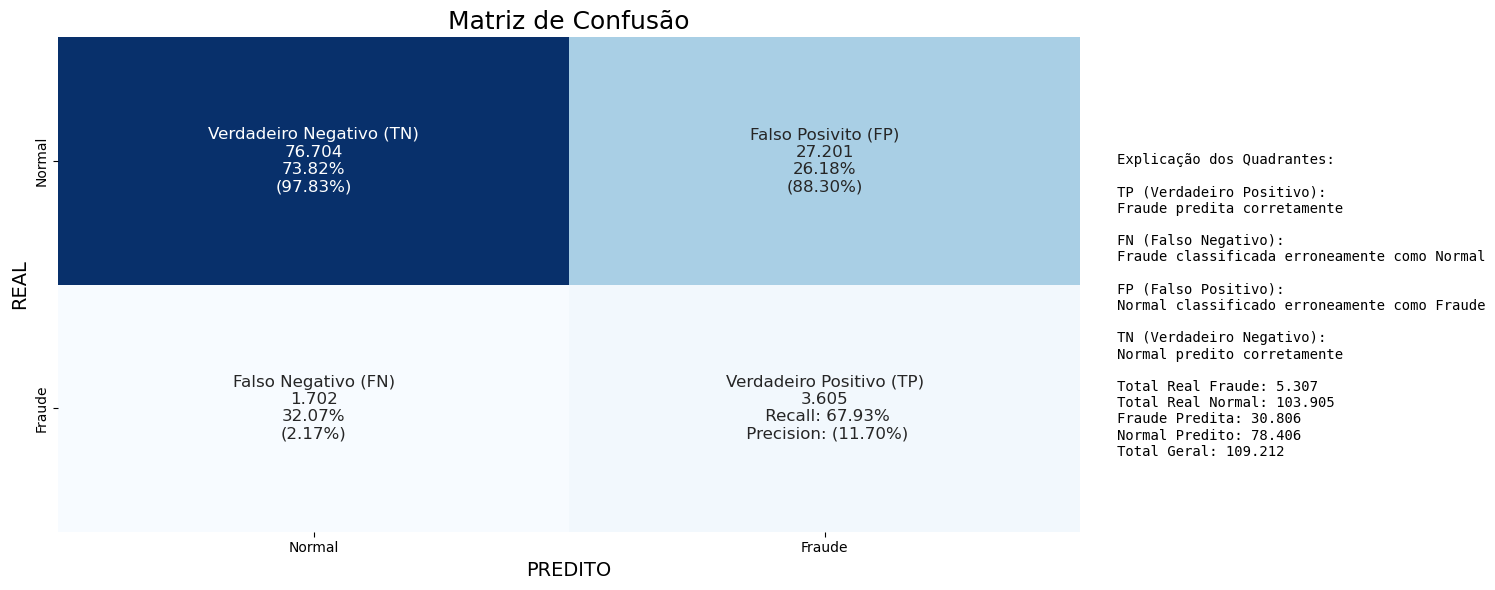

In [153]:
matriz_confusao(dt_cbe_simplificado, x_train_cbe_simplificado, y_train_simplificado)

**Matriz de Confusão da base de Teste**

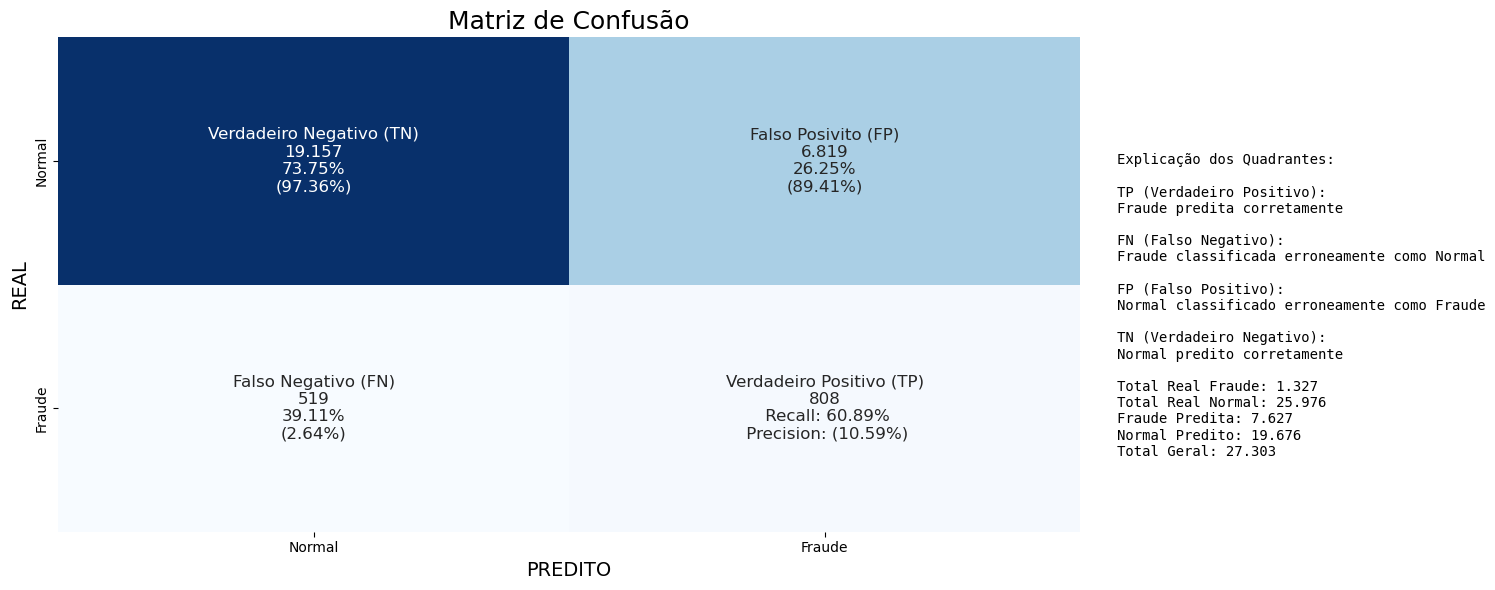

In [155]:
matriz_confusao(dt_cbe_simplificado, x_test_cbe_simplificado, y_test_simplificado)

In [156]:
desempenho_dt_cbe_simplificado

,Treino,Teste,Variação%
Acurácia,73.53%,73.12%,-0.56%
AUROC,77.17%,73.42%,-4.86%
Precision,11.70%,10.59%,-9.47%
Recall,67.93%,60.89%,-10.36%
F1,19.97%,18.05%,-9.60%
F2,34.64%,31.23%,-9.84%


In [157]:
desempenho_dt_ordinal_simplificado

,Treino,Teste,Variação%
Acurácia,59.42%,59.38%,-0.06%
AUROC,75.38%,71.94%,-4.57%
Precision,8.74%,8.08%,-7.53%
Recall,77.84%,70.91%,-8.90%
F1,15.71%,14.51%,-7.67%
F2,30.15%,27.75%,-7.96%


- Apesar de a Árvore de Decisão treinada com o encoding OrdinalEncoder apresentar melhor Recall, **a Árvore de Decisão treinada com o encoding CatBoostEncoder apresentou melhor AUROC, melhor Precision, melhor F1 Score, melhor F2 Score e também melhor Acurácia**.

- Assim, **seguiremos nos próximos ciclos com a CatBoostEncoder, especialmente por ele estar contribuindo para um melhor F2-Score**, visto que ele é a média harmônica entre o Precision e o Recall, na qual o Recall recebe um peso quatro vezes maior (β= 2 e β²= 4) em relação ao Precision. Assim, o Recall será priorizado, mas o Precision não será desconsiderado nas decisões ao usarmos o F2 como referência, uma vez que um Precision muito baixo gerará excessivos alarmes falsos para o negócio.

## 2º Ciclo de tratamentos específicos seguidos de avaliação de performance utilizando o modelo Árvore de Decisão como referência

**- Nesse 2º ciclo de avaliação dos Modelos de Machine Learning irei apenas imputar os dados vazios e avaliar novamente o modelo referência.**

**- Nesse 2º ciclo, irei excluir a coluna `data_compra` que, posteriormente, terá variáveis extraídas dela e um trabalho de Engenharia de Features sobre elas.**

**Carregar o df ajustado**

In [32]:
df_imputer = df.copy()

In [33]:
df_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,data_compra,valor_compra,fraude
0,4,0.7685,94436.242188,20.0,0.444828,1.0,BR,5,cat_8d714cd,0.883598,240.0,102.0,1,NaN,N,2020-03-27 11:51:16,5.640000,0
1,4,0.7550,9258.500000,1.0,0.000000,33.0,BR,0,cat_64b574b,0.376019,4008.0,0.0,1,Y,N,2020-04-15 19:58:08,124.709999,0
2,4,0.7455,242549.093750,3.0,0.000000,19.0,AR,23,cat_e9110c5,0.516368,1779.0,77.0,1,NaN,N,2020-03-25 18:13:38,339.320007,0
3,4,0.7631,18923.900391,50.0,0.482385,18.0,BR,23,cat_d06e653,0.154036,1704.0,1147.0,1,NaN,Y,2020-04-16 16:03:10,3.540000,0
4,2,0.7315,5728.680176,15.0,0.000000,1.0,BR,2,cat_6c4cfdc,0.855798,1025.0,150.0,1,NaN,N,2020-04-02 10:24:45,3.530000,0


### Definição das Features e do Target da base que terá vazios imputados

In [35]:
x_imputer = df_imputer.drop('fraude', axis=1)
y_imputer = df_imputer['fraude']

In [36]:
x_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,data_compra,valor_compra
0,4,0.7685,94436.242188,20.0,0.444828,1.0,BR,5,cat_8d714cd,0.883598,240.0,102.0,1,NaN,N,2020-03-27 11:51:16,5.640000
1,4,0.7550,9258.500000,1.0,0.000000,33.0,BR,0,cat_64b574b,0.376019,4008.0,0.0,1,Y,N,2020-04-15 19:58:08,124.709999
2,4,0.7455,242549.093750,3.0,0.000000,19.0,AR,23,cat_e9110c5,0.516368,1779.0,77.0,1,NaN,N,2020-03-25 18:13:38,339.320007
3,4,0.7631,18923.900391,50.0,0.482385,18.0,BR,23,cat_d06e653,0.154036,1704.0,1147.0,1,NaN,Y,2020-04-16 16:03:10,3.540000
4,2,0.7315,5728.680176,15.0,0.000000,1.0,BR,2,cat_6c4cfdc,0.855798,1025.0,150.0,1,NaN,N,2020-04-02 10:24:45,3.530000


In [37]:
y_imputer.head()

0    0
1    0
2    0
3    0
4    0
Name: fraude, dtype: int64

### Separação da base, *que terá os vazios imputados*, em base de Treino e base de Teste

In [39]:
x_train_imputer, x_test_imputer, y_train_imputer, y_test_imputer = train_test_split(x_imputer,
                                                    y_imputer,
                                                    test_size=0.20,
                                                    stratify=y_imputer,
                                                    random_state=42)

In [40]:
x_train_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,data_compra,valor_compra
40222,4,NaN,NaN,1.0,0.000000,11.0,BR,19,cat_8f4de11,0.917440,3122.0,181.0,1,NaN,N,2020-03-10 07:51:10,40.990002
113835,4,0.8218,31927.509766,20.0,0.553419,9.0,BR,0,cat_0f47e2a,0.946183,5573.0,1061.0,1,Y,Y,2020-04-06 19:23:01,9.070000
67288,4,0.6871,11216.540039,24.0,0.000000,33.0,BR,10,cat_be0af8e,0.603595,3136.0,202.0,1,NaN,Y,2020-03-28 15:44:18,23.879999
118571,4,0.7930,31825.539062,4.0,0.000000,0.0,BR,5,cat_bdcf37d,0.499857,61.0,57.0,0,NaN,N,2020-03-10 18:03:36,31.190001
5463,4,0.4413,22360.009766,8.0,0.307992,5.0,AD,30,cat_b4a93f8,0.894125,3574.0,20.0,0,N,N,2020-04-04 07:14:22,19.410000


In [41]:
x_train_imputer.shape

(120000, 17)

In [42]:
120000/150000

0.8

In [43]:
# Guardando coluna 'data_compra' e os Índices originais para depois
data_compra_train = x_train_imputer['data_compra'].copy()
data_compra_test = x_test_imputer['data_compra'].copy()
indices_train_originais = x_train_imputer.index.copy()
indices_test_originais = x_test_imputer.index.copy()

In [44]:
# Removendo a coluna 'data_compra'
x_train_imputer = x_train_imputer.drop(columns=['data_compra'])
x_test_imputer = x_test_imputer.drop(columns=['data_compra'])

In [45]:
x_train_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,valor_compra
40222,4,NaN,NaN,1.0,0.000000,11.0,BR,19,cat_8f4de11,0.917440,3122.0,181.0,1,NaN,N,40.990002
113835,4,0.8218,31927.509766,20.0,0.553419,9.0,BR,0,cat_0f47e2a,0.946183,5573.0,1061.0,1,Y,Y,9.070000
67288,4,0.6871,11216.540039,24.0,0.000000,33.0,BR,10,cat_be0af8e,0.603595,3136.0,202.0,1,NaN,Y,23.879999
118571,4,0.7930,31825.539062,4.0,0.000000,0.0,BR,5,cat_bdcf37d,0.499857,61.0,57.0,0,NaN,N,31.190001
5463,4,0.4413,22360.009766,8.0,0.307992,5.0,AD,30,cat_b4a93f8,0.894125,3574.0,20.0,0,N,N,19.410000


In [46]:
x_train_imputer.shape

(120000, 16)

**Tratando a alta cardinalidade da coluna `categoria_produto`:**

In [48]:
# 1. Identificar categorias principais APENAS no treino
df_train = x_train_imputer.copy()
df_train['fraude'] = y_train_imputer.values

# Filtrar apenas fraudes do conjunto de treino
df_fraudes_train = df_train[df_train['fraude'] == 1]

# Contar fraudes por categoria no treino
fraudes_por_categoria = df_fraudes_train['categoria_produto'].value_counts()

# Calcular porcentagem acumulada
total_fraudes = fraudes_por_categoria.sum()
fraudes_acumuladas = fraudes_por_categoria.cumsum()
pct_acumulado = (fraudes_acumuladas / total_fraudes) * 100

# Identificar categorias que representam até 80% das fraudes
categorias_principais = pct_acumulado[pct_acumulado <= 80].index.tolist()

# Adicionar próxima categoria para garantir pelo menos 80%
if len(categorias_principais) < len(pct_acumulado):
    categorias_principais.append(pct_acumulado.index[len(categorias_principais)])

print(f"Total de fraudes no treino: {total_fraudes}")
print(f"Categorias originais: {x_train_imputer['categoria_produto'].nunique()}")
print(f"Categorias que concentram 80% das fraudes: {len(categorias_principais)}")
print(f"Porcentagem coberta: {pct_acumulado.iloc[len(categorias_principais)-1]:.2f}%")

# 2. Aplicar o agrupamento em treino e teste
x_train_imputer['categoria_produto'] = x_train_imputer['categoria_produto'].apply(
    lambda x: x if x in categorias_principais else 'Outros'
)

x_test_imputer['categoria_produto'] = x_test_imputer['categoria_produto'].apply(
    lambda x: x if x in categorias_principais else 'Outros'
)

# 3. Verificação
print(f"\nCategorias únicas no treino após agrupamento: {x_train_imputer['categoria_produto'].nunique()}")
print(f"Categorias únicas no teste após agrupamento: {x_test_imputer['categoria_produto'].nunique()}")

Total de fraudes no treino: 6000
Categorias originais: 7836
Categorias que concentram 80% das fraudes: 646
Porcentagem coberta: 80.02%

Categorias únicas no treino após agrupamento: 647
Categorias únicas no teste após agrupamento: 638


In [49]:
x_train_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,valor_compra
40222,4,NaN,NaN,1.0,0.000000,11.0,BR,19,Outros,0.917440,3122.0,181.0,1,NaN,N,40.990002
113835,4,0.8218,31927.509766,20.0,0.553419,9.0,BR,0,cat_0f47e2a,0.946183,5573.0,1061.0,1,Y,Y,9.070000
67288,4,0.6871,11216.540039,24.0,0.000000,33.0,BR,10,cat_be0af8e,0.603595,3136.0,202.0,1,NaN,Y,23.879999
118571,4,0.7930,31825.539062,4.0,0.000000,0.0,BR,5,cat_bdcf37d,0.499857,61.0,57.0,0,NaN,N,31.190001
5463,4,0.4413,22360.009766,8.0,0.307992,5.0,AD,30,cat_b4a93f8,0.894125,3574.0,20.0,0,N,N,19.410000


In [50]:
x_test_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,valor_compra
22325,4,0.8054,3710.010010,15.0,0.199167,20.0,BR,32,Outros,0.170378,5629.0,311.0,1,NaN,Y,24.260000
7970,4,0.7945,62113.718750,22.0,0.000000,1.0,BR,5,cat_be0af8e,0.866514,564.0,342.0,1,N,Y,37.799999
47378,4,0.8253,7268.939941,2.0,0.191935,74.0,BR,14,cat_048130a,0.777637,3620.0,91.0,1,Y,Y,12.700000
37537,4,0.7754,38398.339844,35.0,0.779688,18.0,BR,38,Outros,0.125672,4347.0,303.0,1,NaN,Y,12.600000
40722,4,0.7551,39319.968750,18.0,0.000000,11.0,BR,20,Outros,0.250006,4062.0,83.0,1,Y,N,70.790001


In [51]:
x_train_imputer.shape

(120000, 16)

### Valores Missing

In [53]:
(df_imputer.isnull().sum()/df_imputer.shape[0] * 100).round(2).astype(str) + '%'

score_1                0.0%
score_2               8.66%
score_3               8.66%
score_4               0.24%
score_5                0.0%
score_6               0.01%
pais                  0.13%
score_7                0.0%
categoria_produto      0.0%
score_8                0.0%
score_9               0.01%
score_10              0.24%
entrega_doc_1          0.0%
entrega_doc_2        72.57%
entrega_doc_3          0.0%
data_compra            0.0%
valor_compra           0.0%
fraude                 0.0%
dtype: object

**Tratamento da coluna `entrega_doc_2`:**

- Como já havíamos observado, a coluna **`entrega_doc_2` possui uma taxa muito alta de dados vazios (72,57%)**.
  
- Assim, **iremos tratar essa coluna da seguinte maneira**:

    - Iremos atribuir, na coluna **`entrega_doc_2`**, o valor 1 para os casos em que o doc_2 foi entregue (quando estiver preenchido como 'Y')
    
    - Iremos atribuir, na coluna **`entrega_doc_2`**, o valor 0 para os casos em que ou o doc_2 não foi entregue (quando estiver preenchido como 'N') ou quando estiver vazio (NaN). Ao também substituir os dados vazios por 0, garantimos que não haverá dado vazio, o que é necessário para o treinamento de vários modelos.
 
    - E, **além disso**, iremos **criar uma nova coluna nomeada como `doc_2_vazio`**. Ela será preenchida com o valor 1 quando `entrega_doc_2` estiver vazia (NaN), e com o valor 0 caso contrário. Ou seja, essa coluna informará ao Modelo de Machine Learning onde havia informação faltante. Assim, o Modelo consegue aprender padrões associados à ausência de dados, sem perder essa informação ao preenchermos os NaN da coluna `entrega_doc_2`. Isso é importante porque o simples fato de uma informação estar ausente pode ser relevante para a previsão. 

In [56]:
x_train_imputer['doc_2_vazio'] = np.where(x_train_imputer['entrega_doc_2'].isna(), 1, 0)

In [57]:
x_train_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,valor_compra,doc_2_vazio
40222,4,NaN,NaN,1.0,0.000000,11.0,BR,19,Outros,0.917440,3122.0,181.0,1,NaN,N,40.990002,1
113835,4,0.8218,31927.509766,20.0,0.553419,9.0,BR,0,cat_0f47e2a,0.946183,5573.0,1061.0,1,Y,Y,9.070000,0
67288,4,0.6871,11216.540039,24.0,0.000000,33.0,BR,10,cat_be0af8e,0.603595,3136.0,202.0,1,NaN,Y,23.879999,1
118571,4,0.7930,31825.539062,4.0,0.000000,0.0,BR,5,cat_bdcf37d,0.499857,61.0,57.0,0,NaN,N,31.190001,1
5463,4,0.4413,22360.009766,8.0,0.307992,5.0,AD,30,cat_b4a93f8,0.894125,3574.0,20.0,0,N,N,19.410000,0


In [58]:
x_train_imputer['entrega_doc_2'] = (
    x_train_imputer['entrega_doc_2']
    .replace({'Y': 1, 'N': 0})
    .fillna(0)
)

In [59]:
x_train_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,pais,score_7,categoria_produto,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,entrega_doc_3,valor_compra,doc_2_vazio
40222,4,NaN,NaN,1.0,0.000000,11.0,BR,19,Outros,0.917440,3122.0,181.0,1,0.0,N,40.990002,1
113835,4,0.8218,31927.509766,20.0,0.553419,9.0,BR,0,cat_0f47e2a,0.946183,5573.0,1061.0,1,1.0,Y,9.070000,0
67288,4,0.6871,11216.540039,24.0,0.000000,33.0,BR,10,cat_be0af8e,0.603595,3136.0,202.0,1,0.0,Y,23.879999,1
118571,4,0.7930,31825.539062,4.0,0.000000,0.0,BR,5,cat_bdcf37d,0.499857,61.0,57.0,0,0.0,N,31.190001,1
5463,4,0.4413,22360.009766,8.0,0.307992,5.0,AD,30,cat_b4a93f8,0.894125,3574.0,20.0,0,0.0,N,19.410000,0


In [60]:
x_test_imputer['doc_2_vazio'] = np.where(x_test_imputer['entrega_doc_2'].isna(), 1, 0)

In [61]:
x_test_imputer['entrega_doc_2'] = (
    x_test_imputer['entrega_doc_2']
    .replace({'Y': 1, 'N': 0})
    .fillna(0)
)

**Tratamento da coluna `pais`:**

- Ainda há uma coluna categórica que possui dados faltantes: a coluna `pais`. 
  
- Iremos preencher os dados vazios com o dado mais frequente (Moda) da coluna.

In [64]:
imputer_pais = SimpleImputer(strategy='most_frequent')

**Ajustando (fit) o imputador apenas na base de Treino:**

In [66]:
imputer_pais.fit(x_train_imputer[['pais']])

,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


**Aplicando (transform) o imputador na base de Treino:**

In [68]:
x_train_imputer['pais'] = imputer_pais.transform(x_train_imputer[['pais']]).ravel()

**Aplicando (transform) o imputador na base de Teste com base no ajuste da base de Treino:**

In [70]:
x_test_imputer['pais'] = imputer_pais.transform(x_test_imputer[['pais']]).ravel()

### KNN Imputer

- O KNN Imputer é um **método de imputação de valores faltantes que utiliza o algoritmo K-Nearest Neighbors** (K vizinhos mais próximos). A ideia é preencher valores ausentes com base nos valores dos k vizinhos mais similares.
  
- Funcionamento do KNN Imputer:

    - 1: Identifica vizinhos: Para cada instância com valor faltante, encontra as k instâncias mais próximas (sem valores faltantes naquela feature).
      
    - 2:  Calcula distância: Usa distância considerando apenas as features disponíveis.
 
    - 3: Imputa: Substitui o valor faltante pela média dos valores dos k vizinhos.

- **Exemplo**:

**Base de Treino**:

| Linha | Feature 1 | Feature 2 | Feature 3 |
|---------|-----------|-----------|-----------|
| A | 2 | 3 | 5 |
| B | 4 | **?** | 7 |
| C | 6 | 8 | 9 |
| D | 1 | 2 | 4 |

- Objetivo: Imputar a linha B da Feature 2. Vamos considerar a quantidade de vizinhos (K) como sendo 2.

- **Passo 1**: Calcular distâncias da linha B para as demais linhas que tenham valor preenchido na Feature 2 (usando Features 1 e 3):

    - Distância B→A: √[(4-2)² + (7-5)²] = √[4 + 4] = √8 = 2.83
    
    - Distância B→C: √[(4-6)² + (7-9)²] = √[4 + 4] = √8 = 2.83
    
    - Distância B→D: √[(4-1)² + (7-4)²] = √[9 + 9] = √18 = 4.24
      
- **Passo 2**: Selecionar k=2 vizinhos mais próximos: Linhas A e C (ambos com distância 2.83, que é menor que 4.24)

- **Passo 3**: Imputar pela média:
    
    - Calcula a média dos valores das linhas A e C da Feature 2 e a aplica na linha B da Feature 2, onde há o vazio = (3 + 8) / 2 = **5.5**
    
      

- **Base de Treino após imputação**:

| Linha | Feature 1 | Feature 2 | Feature 3 |
|---------|-----------|-----------|-----------|
| A | 2 | 3 | 5 |
| B | 4 | **5.5** | 7 |
| C | 6 | 8 | 9 |
| D | 1 | 2 | 4 |

**Base de Teste:**

| Linha | Feature 1 | Feature 2 | Feature 3 |
|---------|-----------|-----------|-----------|
| E | 3 | 4 | **?** |

- **Objetivo**: Imputar a linha E da Feature 3

- **Importante**: Usamos os vizinhos da **base de Treino** (já imputada)!

- **Passo 1**: Calcular distâncias da linha E para as linhas da base de Treino (usando Features 1 e 2):

    - Distância E→A: √[(3-2)² + (4-3)²] = √[1 + 1] = √2 = 1.41
    
    - Distância E→B: √[(3-4)² + (4-5.5)²] = √[1 + 2.25] = √3.25 = 1.80
    
    - Distância E→C: √[(3-6)² + (4-8)²] = √[9 + 16] = √25 = 5.00
    
    - Distância E→D: √[(3-1)² + (4-2)²] = √[4 + 4] = √8 = 2.83

- **Passo 2**: Selecionar k=2 vizinhos mais próximos: Linha A (1.41) e Linha B (1.80), que são menores que 2.83 e que 5.0

- **Passo 3**: Imputar pela média:
    - Calcula a média dos valores das linhas A e B da Feature 3 da Base de Treino e a aplica na linha E da Feature 3 da Base de Teste, onde há o vazio= (5 + 7) / 2 = **6**

- **Base de Teste após imputação**:

| Linha | Feature 1 | Feature 2 | Feature 3 |
|---------|-----------|-----------|-----------|
| E | 3 | 4 | **6** |

**Instanciando o imputador de vazios**

In [76]:
knn_imputer = KNNImputer(
    n_neighbors=5,
    weights='distance',
    metric='nan_euclidean'
)

In [77]:
numericas = x_train_imputer.select_dtypes(include='number').columns
knn_imputer.fit(x_train_imputer[numericas])

,missing_values,nan
,n_neighbors,5
,weights,'distance'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


**O imputer foi ajustado (fit) apenas com os dados de Treino, nas colunas numéricas. Ele será aplicado (transform) na base de Teste (e também na de Treino)**

**Aplicado (transform) do KNN Imputer base de Treino:**

In [80]:
# Função para aplicar o transform em blocos com barra de progresso
def transform_with_progress(imputer, df, chunk_size=100):
    arr = df.values
    result = np.empty_like(arr)
    
    for i in tqdm(range(0, arr.shape[0], chunk_size), desc='KNN Imputer'):
        chunk = arr[i:i+chunk_size]
        result[i:i+chunk_size] = imputer.transform(chunk)
    
    return pd.DataFrame(result, columns=df.columns, index=df.index)

In [81]:
x_train_imputer[numericas] = transform_with_progress(knn_imputer, x_train_imputer[numericas])

KNN Imputer: 100%|██████████| 1200/1200 [02:50<00:00,  7.03it/s]


**Aplicado (transform) do KNN Imputer base de Teste:**

In [83]:
x_test_imputer[numericas] = transform_with_progress(knn_imputer, x_test_imputer[numericas])

KNN Imputer: 100%|██████████| 300/300 [00:42<00:00,  7.12it/s]


In [84]:
(x_test_imputer.isnull().sum()/x_train_imputer.shape[0] * 100).round(2).astype(str) + '%'

score_1              0.0%
score_2              0.0%
score_3              0.0%
score_4              0.0%
score_5              0.0%
score_6              0.0%
pais                 0.0%
score_7              0.0%
categoria_produto    0.0%
score_8              0.0%
score_9              0.0%
score_10             0.0%
entrega_doc_1        0.0%
entrega_doc_2        0.0%
entrega_doc_3        0.0%
valor_compra         0.0%
doc_2_vazio          0.0%
dtype: object

### Criação do DataFrame com as Colunas *Categóricas* da base de *Treino* com vazios imputados

In [123]:
x_var_categoricas_train_imputer = x_train_imputer.select_dtypes(include=['object']).columns.tolist()

In [124]:
x_var_categoricas_train_imputer

['pais', 'categoria_produto', 'entrega_doc_3']

In [125]:
x_categoricas_train_imputer = x_train_imputer[x_var_categoricas_train_imputer].copy()

In [126]:
x_categoricas_train_imputer.head()

,pais,categoria_produto,entrega_doc_3
40222,BR,Outros,N
113835,BR,cat_0f47e2a,Y
67288,BR,cat_be0af8e,Y
118571,BR,cat_bdcf37d,N
5463,AD,cat_b4a93f8,N


### Criação do DataFrame com as Colunas *Categóricas* da base de *Teste* com vazios imputados

In [128]:
x_var_categoricas_test_imputer = x_test_imputer.select_dtypes(include=['object']).columns.tolist()

In [129]:
x_var_categoricas_test_imputer

['pais', 'categoria_produto', 'entrega_doc_3']

In [130]:
x_categoricas_test_imputer = x_test_imputer[x_var_categoricas_test_imputer].copy()

In [131]:
x_categoricas_test_imputer.head()

,pais,categoria_produto,entrega_doc_3
22325,BR,Outros,Y
7970,BR,cat_be0af8e,Y
47378,BR,cat_048130a,Y
37537,BR,Outros,Y
40722,BR,Outros,N


### Criação do DataFrame com as Colunas *Numéricas* da base de *Treino* com vazios imputados

In [133]:
x_var_numericas_train_imputer = x_train_imputer.select_dtypes(include=['float32', 'float64','int64']).columns.tolist()

In [134]:
x_var_numericas_train_imputer

['score_1',
 'score_2',
 'score_3',
 'score_4',
 'score_5',
 'score_6',
 'score_7',
 'score_8',
 'score_9',
 'score_10',
 'entrega_doc_1',
 'entrega_doc_2',
 'valor_compra',
 'doc_2_vazio']

In [135]:
x_numericas_train_imputer = x_train_imputer[x_var_numericas_train_imputer].copy()

In [136]:
x_numericas_train_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,valor_compra,doc_2_vazio
40222,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,1.0,0.0,40.990002,1.0
113835,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,1.0,1.0,9.070000,0.0
67288,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,1.0,0.0,23.879999,1.0
118571,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,0.0,0.0,31.190001,1.0
5463,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,0.0,0.0,19.410000,0.0


### Criação do DataFrame com as Colunas *Numéricas* da base de *Teste* com vazios imputados

In [138]:
x_var_numericas_test_imputer = x_test_imputer.select_dtypes(include=['float32', 'float64','int64']).columns.tolist()

In [139]:
x_var_numericas_test_imputer

['score_1',
 'score_2',
 'score_3',
 'score_4',
 'score_5',
 'score_6',
 'score_7',
 'score_8',
 'score_9',
 'score_10',
 'entrega_doc_1',
 'entrega_doc_2',
 'valor_compra',
 'doc_2_vazio']

In [140]:
x_numericas_test_imputer = x_test_imputer[x_var_numericas_test_imputer].copy()

In [141]:
x_numericas_test_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,valor_compra,doc_2_vazio
22325,4.0,0.8054,3710.010010,15.0,0.199167,20.0,32.0,0.170378,5629.0,311.0,1.0,0.0,24.260000,1.0
7970,4.0,0.7945,62113.718750,22.0,0.000000,1.0,5.0,0.866514,564.0,342.0,1.0,0.0,37.799999,0.0
47378,4.0,0.8253,7268.939941,2.0,0.191935,74.0,14.0,0.777637,3620.0,91.0,1.0,1.0,12.700000,0.0
37537,4.0,0.7754,38398.339844,35.0,0.779688,18.0,38.0,0.125672,4347.0,303.0,1.0,0.0,12.600000,1.0
40722,4.0,0.7551,39319.968750,18.0,0.000000,11.0,20.0,0.250006,4062.0,83.0,1.0,1.0,70.790001,0.0


### Tratamento de Variáveis Categóricas (Encoding)

- O processo de encoding **transforma as variáveis categóricas em numéricas**.

**Garantindo que todas as features categóricas da base de treino estejam em formato object e não em formato float**

In [145]:
x_categoricas_train_imputer = x_categoricas_train_imputer.astype(str)

**Garantindo que todas as features categóricas da base de teste estejam em formato object e não em formato float**

In [147]:
x_categoricas_test_imputer = x_categoricas_test_imputer.astype(str)

### CatBoostEncoder

In [149]:
cbe_imputer = CatBoostEncoder(cols=x_categoricas_train_imputer.columns.tolist(),a=1000)

In [150]:
cbe_imputer.fit(x_categoricas_train_imputer, y_train_imputer)

,verbose,0
,cols,"['pais', 'categoria_produto', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None
,sigma,None
,a,1000


In [151]:
x_categoricas_train_cbe_imputer = cbe_imputer.transform(x_categoricas_train_imputer)

In [152]:
x_categoricas_train_cbe_imputer = x_categoricas_train_cbe_imputer.reset_index(drop=True)

In [153]:
x_numericas_train_imputer = x_numericas_train_imputer.reset_index(drop=True)

In [154]:
x_categoricas_train_cbe_imputer.head()

,pais,categoria_produto,entrega_doc_3
0,0.055163,0.024016,0.075980
1,0.055163,0.057629,0.029087
2,0.055163,0.050000,0.029087
3,0.055163,0.064763,0.075980
4,0.050000,0.053131,0.075980


In [155]:
x_train_cbe_imputer = pd.concat([x_numericas_train_imputer, x_categoricas_train_cbe_imputer], axis=1)

In [156]:
x_train_cbe_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,valor_compra,doc_2_vazio,pais,categoria_produto,entrega_doc_3
0,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,1.0,0.0,40.990002,1.0,0.055163,0.024016,0.075980
1,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,1.0,1.0,9.070000,0.0,0.055163,0.057629,0.029087
2,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,1.0,0.0,23.879999,1.0,0.055163,0.050000,0.029087
3,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,0.0,0.0,31.190001,1.0,0.055163,0.064763,0.075980
4,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,0.0,0.0,19.410000,0.0,0.050000,0.053131,0.075980


In [157]:
x_train_cbe_imputer.shape

(120000, 17)

In [158]:
x_categoricas_test_cbe_imputer = cbe_imputer.transform(x_categoricas_test_imputer)

In [159]:
x_categoricas_test_cbe_imputer = x_categoricas_test_cbe_imputer.reset_index(drop=True)

In [160]:
x_numericas_test_imputer = x_numericas_test_imputer.reset_index(drop=True)

In [161]:
x_categoricas_test_cbe_imputer.head()

,pais,categoria_produto,entrega_doc_3
0,0.055163,0.024016,0.029087
1,0.055163,0.050000,0.029087
2,0.055163,0.047012,0.029087
3,0.055163,0.024016,0.029087
4,0.055163,0.024016,0.075980


In [162]:
x_test_cbe_imputer = pd.concat([x_numericas_test_imputer, x_categoricas_test_cbe_imputer], axis=1)

In [163]:
x_test_cbe_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,valor_compra,doc_2_vazio,pais,categoria_produto,entrega_doc_3
0,4.0,0.8054,3710.010010,15.0,0.199167,20.0,32.0,0.170378,5629.0,311.0,1.0,0.0,24.260000,1.0,0.055163,0.024016,0.029087
1,4.0,0.7945,62113.718750,22.0,0.000000,1.0,5.0,0.866514,564.0,342.0,1.0,0.0,37.799999,0.0,0.055163,0.050000,0.029087
2,4.0,0.8253,7268.939941,2.0,0.191935,74.0,14.0,0.777637,3620.0,91.0,1.0,1.0,12.700000,0.0,0.055163,0.047012,0.029087
3,4.0,0.7754,38398.339844,35.0,0.779688,18.0,38.0,0.125672,4347.0,303.0,1.0,0.0,12.600000,1.0,0.055163,0.024016,0.029087
4,4.0,0.7551,39319.968750,18.0,0.000000,11.0,20.0,0.250006,4062.0,83.0,1.0,1.0,70.790001,0.0,0.055163,0.024016,0.075980


In [164]:
x_test_cbe_imputer.shape

(30000, 17)

**Restaurar índices originais**

In [166]:
x_train_cbe_imputer.index = indices_train_originais
x_test_cbe_imputer.index = indices_test_originais

**Restaurar índices originais do Y**

In [168]:
y_train_imputer.index = indices_train_originais
y_test_imputer.index = indices_test_originais

### Treinamento de uma Árvore de Decisão para avaliação da performance, considerando a imputação de vazios

**Instanciando o Modelo**

In [171]:
dt_imputer = DecisionTreeClassifier(min_samples_leaf=2,
                                     max_depth=5,
                                     class_weight='balanced',    
                                     random_state=42)

**Treinando o Modelo na base de Treino**

In [173]:
dt_imputer.fit(x_train_cbe_imputer, y_train_imputer)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Desempenho do Modelo**

In [175]:
desempenho_dt_imputer=calcula_desempenho(dt_imputer, x_train_cbe_imputer, y_train_imputer, x_test_cbe_imputer, y_test_imputer)

In [176]:
desempenho_dt_imputer

,Treino,Teste,Variação%
Acurácia,77.40%,76.84%,-0.72%
AUROC,84.69%,82.39%,-2.72%
Precision,15.13%,14.23%,-5.92%
Recall,76.37%,72.27%,-5.37%
F1,25.25%,23.78%,-5.83%
F2,42.20%,39.81%,-5.67%


**Matriz de Confusão da base de Treino**

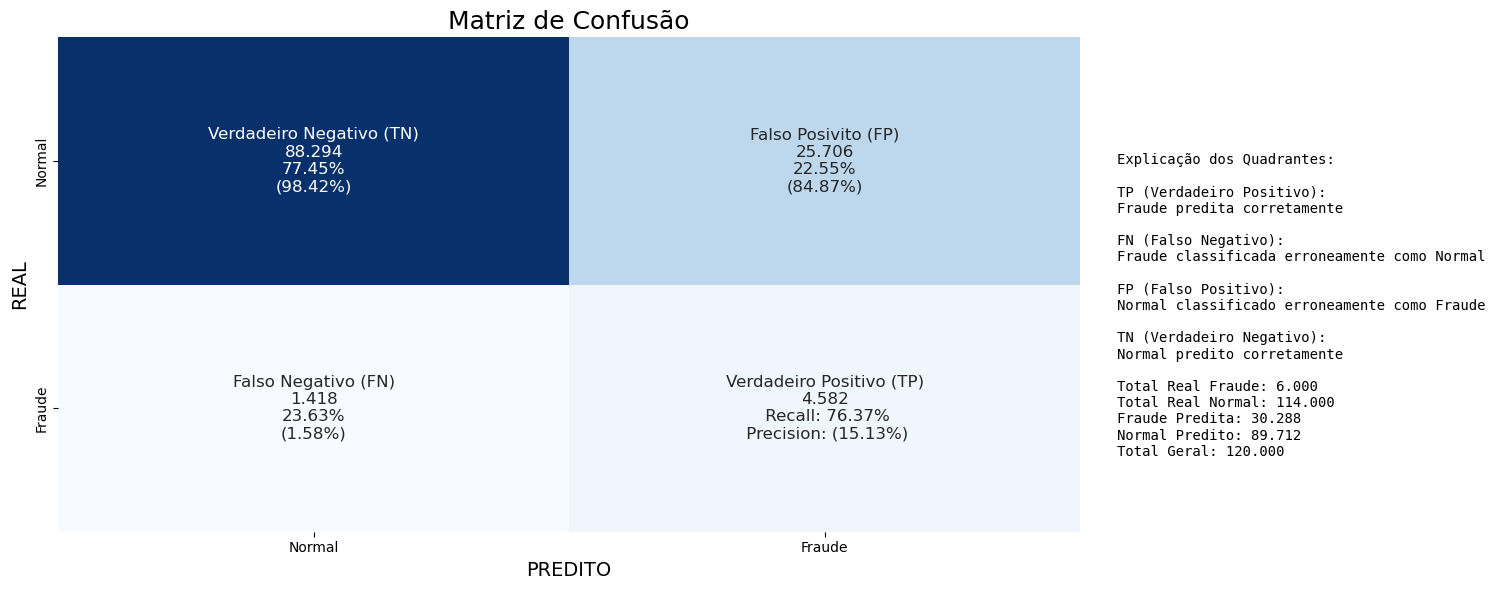

In [178]:
matriz_confusao(dt_imputer, x_train_cbe_imputer, y_train_imputer)

**Matriz de Confusão da base de Teste**

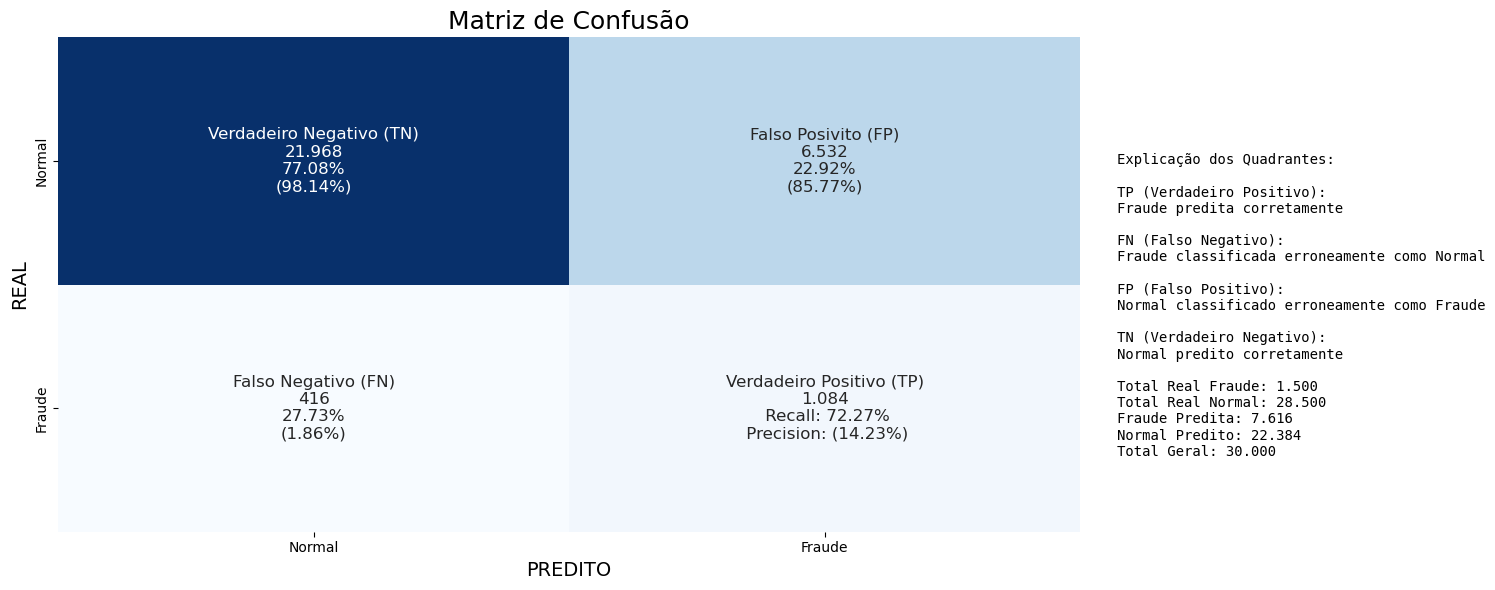

In [180]:
matriz_confusao(dt_imputer, x_test_cbe_imputer, y_test_imputer)

- Nota-se que o tratamentos de colunas e imputação de vazios apresentou resultados muito melhores do que simplesmente excluir colunas com muitos dados faltantes e linhas com algum dado vazio.
  
- F2-Score da Base de Teste saiu de 31,23% para 39,81%.

## 3º Ciclo de tratamentos específicos seguidos de avaliação de performance utilizando os modelos Árvore de Decisão e Regressão Logística como referência

**Neste 3º ciclo, vamos já trabalhar com a base de dados com os valores vazios imputados, incluiremos a coluna de data, extrairemos dela as informações de data e hora e as adaptaremos para considerar a ciclicidade que carregam.**

In [225]:
x_train_imputed_date = x_train_cbe_imputer.copy()
x_test_imputed_date = x_test_cbe_imputer.copy()

In [226]:
# Adicionar data_compra de volta
x_train_imputed_date['data_compra'] = data_compra_train
x_test_imputed_date['data_compra'] = data_compra_test

In [228]:
x_train_cbe_imputer.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,valor_compra,doc_2_vazio,pais,categoria_produto,entrega_doc_3
40222,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,1.0,0.0,40.990002,1.0,0.055163,0.024016,0.075980
113835,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,1.0,1.0,9.070000,0.0,0.055163,0.057629,0.029087
67288,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,1.0,0.0,23.879999,1.0,0.055163,0.050000,0.029087
118571,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,0.0,0.0,31.190001,1.0,0.055163,0.064763,0.075980
5463,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,0.0,0.0,19.410000,0.0,0.050000,0.053131,0.075980


In [229]:
x_train_imputed_date.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,valor_compra,doc_2_vazio,pais,categoria_produto,entrega_doc_3,data_compra
40222,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,1.0,0.0,40.990002,1.0,0.055163,0.024016,0.075980,2020-03-10 07:51:10
113835,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,1.0,1.0,9.070000,0.0,0.055163,0.057629,0.029087,2020-04-06 19:23:01
67288,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,1.0,0.0,23.879999,1.0,0.055163,0.050000,0.029087,2020-03-28 15:44:18
118571,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,0.0,0.0,31.190001,1.0,0.055163,0.064763,0.075980,2020-03-10 18:03:36
5463,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,0.0,0.0,19.410000,0.0,0.050000,0.053131,0.075980,2020-04-04 07:14:22


### Conversão das colunas de tempo da base de Treino

In [231]:
x_train_imputed_date[['data_compra']].dtypes

data_compra    datetime64[ns]
dtype: object

### Extraindo variáveis temporais das colunas de tempo da base de Treino

In [233]:
x_train_imputed_date[['ano_datetime']] = x_train_imputed_date[['data_compra']].apply(lambda x: x.dt.year.astype('Int64'))

In [234]:
x_train_imputed_date[['ano_datetime']].tail()

,ano_datetime
98675,2020
107282,2020
120366,2020
76208,2020
1534,2020


In [235]:
x_train_imputed_date[['mes_datetime']] = x_train_imputed_date[['data_compra']].apply(lambda x: x.dt.month)

In [236]:
x_train_imputed_date[['mes_datetime']].tail()

,mes_datetime
98675,4
107282,4
120366,4
76208,3
1534,3


In [237]:
x_train_imputed_date[['dia_datetime']] = x_train_imputed_date[['data_compra']].apply(lambda x: x.dt.day.astype('Int64'))

In [238]:
x_train_imputed_date[['dia_datetime']].tail()

,dia_datetime
98675,14
107282,11
120366,21
76208,22
1534,22


In [239]:
x_train_imputed_date[['hora_datetime']] = x_train_imputed_date[['data_compra']].apply(lambda x: x.dt.hour.astype('Int64'))

In [240]:
x_train_imputed_date[['hora_datetime']].head()

,hora_datetime
40222,7
113835,19
67288,15
118571,18
5463,7


In [241]:
x_train_imputed_date[['dia_semana_datetime']] = x_train_imputed_date[['data_compra']].apply(lambda x: x.dt.dayofweek.astype('Int64'))

In [242]:
x_train_imputed_date[['dia_semana_datetime']].head()

,dia_semana_datetime
40222,1
113835,0
67288,5
118571,1
5463,5


In [243]:
x_train_imputed_date[['dias_no_mes_datetime']] = x_train_imputed_date[['data_compra']].apply(lambda x: x.dt.days_in_month.astype('Int64'))

In [244]:
x_train_imputed_date[['dias_no_mes_datetime']].head()

,dias_no_mes_datetime
40222,31
113835,30
67288,31
118571,31
5463,30


### Adaptando variáveis cíclicas da base de Treino

- A distância de domingo para segunda-feira é a mesma distância de sábado para domingo. Ou seja, 1 dia. Caso consideremos apenas o número do dia da semana, os algoritmos de Machine Learning entenderão que há uma grande distância de dias entre o domingo (dia 6) e a segunda-feira (dia 0), quando na verdade eles estão lado a lado, com uma distância de 1. O mesmo vale para meses, anos e qualquer outra variável cíclica. 

- Para tratar esse tipo de situações cíclicas, podemos adaptar as variáveis utilizando o Circulo Trigonométrico.

**Exemplo comparando a distância entre segunda-feira e domingo e segunda-feira e terça-feira**

- Consideraremos que segunda-feira é o dia 0. Terça-feira: 1. Domingo: 6.

- Iremos adaptar esses dias dentro do Círculo Trigonométrico.

- Cálculo dos ângulos desses dias, em radianos:

    - Segunda-Feira (0): 2 * 3,1416 * 0 / 7 dias = 0
    - Terça-Feira (1): 2 * 3,1416 * 1 / 7 dias = 0,8976
    - Domingo (6): 2 * 3,1416 * 6 / 7 dias = 5,385

- Para encontrarmos a localização do ponto de cada dia no Círculo Trigonométrico, usaremos as suas **coordenadas dentro do Círculo**. E para isso usamos o seno e o cosseno. **O seno representa a posição vertical da coordenada. O cosseno representa a posição horizontal da coordenada.**

- Seno e Cosseno de cada dia:
    - Segunda-feira: cosseno(0) = 1. seno(0) = 0. Coordenada: (1,0)
    - Terça-feira: cosseno(0,8976) = 0,6235. seno(0,8976) = 0,7818. Coordenada: (0.6235,0.7818)
    - Domingo: cosseno(5,385) = 0,6235. seno(5,385) = - 0,7818. Coordenada: (0.6235,-0.7818).

- Distância entre Segunda-feira (1.0, 0.0) e Terça-feira (0.6235, 0.7818):

$$
d = \sqrt{(0.6235 - 1.0)^2 + (0.7818 - 0.0)^2} \\
$$
$$
d = \sqrt{(-0.3765)^2 + (0.7818)^2} \\
$$
$$
d = \sqrt{0.1417 + 0.6112} \\
$$
$$
d = \sqrt{0.7529} \approx 0.8676
$$

- Distância entre Domingo (0.6235, -0.7818) e Segunda-feira (1.0, 0.0):
$$
d = \sqrt{(0.6235 - 1.0)^2 + (-0.7818 - 0.0)^2} \\
$$
$$
d = \sqrt{(-0.3765)^2 + (-0.7818)^2} \\
$$
$$
d = \sqrt{0.1417 + 0.6112} \\
$$
$$
d = \sqrt{0.7529} \approx 0.8676
$$

Desta maneira, **nota-se que a distância entre a Segunda-feira e a Terça-feira será igual à distância entre Domingo e Segunda-feira, utilizando seno e cosseno**. Ao contrário de quando consideramos a distância desses dias utilizando o dia da semana.

**Visualizando graficamente a distância entre os dias dentro do Círculo Trigonométrico**

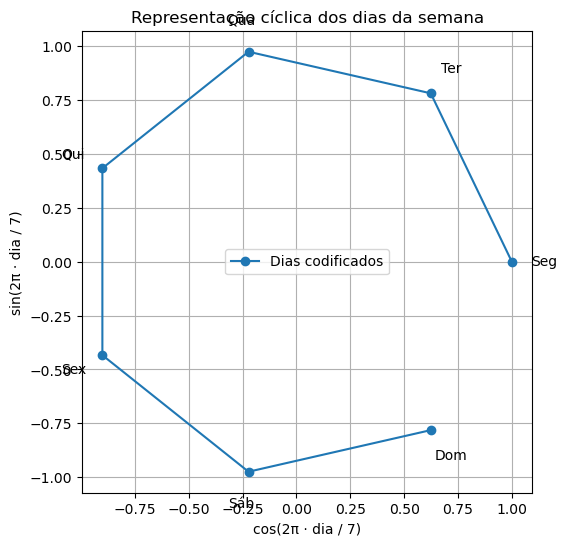

In [253]:
# Dias da semana: 0 = segunda, ..., 6 = domingo
dias = np.arange(7)
nomes_dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

# Codificação cíclica
semana_sen = np.sin(2 * np.pi * dias / 7)
semana_cos = np.cos(2 * np.pi * dias / 7)

# Gráfico circular
plt.figure(figsize=(6, 6))
plt.plot(semana_cos, semana_sen, 'o-', label='Dias codificados')
for dia, x, y in zip(nomes_dias, semana_cos, semana_sen):
    plt.text(x * 1.15, y * 1.15, dia, ha='center', va='center', fontsize=10)

plt.title('Representação cíclica dos dias da semana')
plt.xlabel('cos(2π · dia / 7)')
plt.ylabel('sin(2π · dia / 7)')
plt.gca().set_aspect('equal')
plt.grid(True)
plt.legend()
plt.show()

Note-se que, inserindo os dias da semana no Circulo Trigonométrico, o Domingo fica próximo da Segunda-feira. 

**Criando as variáveis seno e cosseno para as variáveis cíclicas**

In [256]:
# Mês (1 a 12)
x_train_imputed_date['mes_sen_datetime'] = np.sin(2 * np.pi * x_train_imputed_date['mes_datetime'] / 12)
x_train_imputed_date['mes_cos_datetime'] = np.cos(2 * np.pi * x_train_imputed_date['mes_datetime'] / 12)

In [257]:
x_train_imputed_date[['mes_sen_datetime','mes_cos_datetime']].head()

,mes_sen_datetime,mes_cos_datetime
40222,1.000000,6.123234e-17
113835,0.866025,-5.000000e-01
67288,1.000000,6.123234e-17
118571,1.000000,6.123234e-17
5463,0.866025,-5.000000e-01


In [258]:
# Dia
x_train_imputed_date['dia_sen_datetime'] = np.sin(2 * np.pi * x_train_imputed_date['dia_datetime'] / x_train_imputed_date['dias_no_mes_datetime'])
x_train_imputed_date['dia_cos_datetime'] = np.cos(2 * np.pi * x_train_imputed_date['dia_datetime'] / x_train_imputed_date['dias_no_mes_datetime'])

In [259]:
x_train_imputed_date[['dia_sen_datetime','dia_cos_datetime']].head()

,dia_sen_datetime,dia_cos_datetime
40222,0.897805,-0.440394
113835,0.951057,0.309017
67288,-0.571268,0.820763
118571,0.897805,-0.440394
5463,0.743145,0.669131


In [260]:
# Hora (0 a 23)
x_train_imputed_date['hora_sen_datetime'] = np.sin(2 * np.pi * x_train_imputed_date['hora_datetime'] / 24)
x_train_imputed_date['hora_cos_datetime'] = np.cos(2 * np.pi * x_train_imputed_date['hora_datetime'] / 24)

In [261]:
x_train_imputed_date[['hora_sen_datetime','hora_cos_datetime']].tail()

,hora_sen_datetime,hora_cos_datetime
98675,-0.258819,0.965926
107282,-0.866025,-0.5
120366,-0.707107,-0.707107
76208,-0.866025,-0.5
1534,-0.5,-0.866025


In [262]:
# Dia da semana (0 a 6)
x_train_imputed_date['dia_semana_sen_datetime'] = np.sin(2 * np.pi * x_train_imputed_date['dia_semana_datetime'] / 7)
x_train_imputed_date['dia_semana_cos_datetime'] = np.cos(2 * np.pi * x_train_imputed_date['dia_semana_datetime'] / 7)

In [263]:
x_train_imputed_date[['dia_semana_sen_datetime','dia_semana_cos_datetime']].head()

,dia_semana_sen_datetime,dia_semana_cos_datetime
40222,0.781831,0.62349
113835,0.0,1.0
67288,-0.974928,-0.222521
118571,0.781831,0.62349
5463,-0.974928,-0.222521


In [264]:
x_train_imputed_date.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,dia_semana_datetime,dias_no_mes_datetime,mes_sen_datetime,mes_cos_datetime,dia_sen_datetime,dia_cos_datetime,hora_sen_datetime,hora_cos_datetime,dia_semana_sen_datetime,dia_semana_cos_datetime
40222,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,...,1,31,1.000000,6.123234e-17,0.897805,-0.440394,0.965926,-0.258819,0.781831,0.62349
113835,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,...,0,30,0.866025,-5.000000e-01,0.951057,0.309017,-0.965926,0.258819,0.0,1.0
67288,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,...,5,31,1.000000,6.123234e-17,-0.571268,0.820763,-0.707107,-0.707107,-0.974928,-0.222521
118571,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,...,1,31,1.000000,6.123234e-17,0.897805,-0.440394,-1.0,-0.0,0.781831,0.62349
5463,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,...,5,30,0.866025,-5.000000e-01,0.743145,0.669131,0.965926,-0.258819,-0.974928,-0.222521


### Exclusão das variáveis de tempo não cíclicas da base de Treino

Agora que criamos as variáveis de tempo devidamente tratadas com ciclicidade (utilizando seno e cosseno), iremos excluir as demais variáveis de tempo que não lidam bem com ciclicidade e deturpam distâncias de tempo.

In [267]:
x_train_imputed_date = x_train_imputed_date.drop(columns=['data_compra',
                      'mes_datetime','dia_datetime','hora_datetime','dia_semana_datetime','dias_no_mes_datetime'
                      ])

In [268]:
x_train_imputed_date.columns

Index(['score_1', 'score_2', 'score_3', 'score_4', 'score_5', 'score_6',
       'score_7', 'score_8', 'score_9', 'score_10', 'entrega_doc_1',
       'entrega_doc_2', 'valor_compra', 'doc_2_vazio', 'pais',
       'categoria_produto', 'entrega_doc_3', 'ano_datetime',
       'mes_sen_datetime', 'mes_cos_datetime', 'dia_sen_datetime',
       'dia_cos_datetime', 'hora_sen_datetime', 'hora_cos_datetime',
       'dia_semana_sen_datetime', 'dia_semana_cos_datetime'],
      dtype='object')

### Conversão das colunas de tempo da base de Teste

In [270]:
x_test_imputed_date[['data_compra']].dtypes

data_compra    datetime64[ns]
dtype: object

### Extraindo variáveis temporais das colunas de tempo da base de Teste

In [272]:
x_test_imputed_date[['ano_datetime']] = x_test_imputed_date[['data_compra']].apply(lambda x: x.dt.year.astype('Int64'))

In [273]:
x_test_imputed_date[['ano_datetime']].tail()

,ano_datetime
52609,2020
143186,2020
90681,2020
5094,2020
111989,2020


In [274]:
x_test_imputed_date[['mes_datetime']] = x_test_imputed_date[['data_compra']].apply(lambda x: x.dt.month)

In [275]:
x_test_imputed_date[['mes_datetime']].tail()

,mes_datetime
52609,4
143186,4
90681,3
5094,3
111989,4


In [276]:
x_test_imputed_date[['dia_datetime']] = x_test_imputed_date[['data_compra']].apply(lambda x: x.dt.day.astype('Int64'))

In [277]:
x_test_imputed_date[['dia_datetime']].tail()

,dia_datetime
52609,8
143186,12
90681,21
5094,14
111989,16


In [278]:
x_test_imputed_date[['hora_datetime']] = x_test_imputed_date[['data_compra']].apply(lambda x: x.dt.hour.astype('Int64'))

In [279]:
x_test_imputed_date[['hora_datetime']].head()

,hora_datetime
22325,1
7970,14
47378,9
37537,2
40722,18


In [280]:
x_test_imputed_date[['dia_semana_datetime']] = x_test_imputed_date[['data_compra']].apply(lambda x: x.dt.dayofweek.astype('Int64'))

In [281]:
x_test_imputed_date[['dia_semana_datetime']].head()

,dia_semana_datetime
22325,1
7970,1
47378,4
37537,0
40722,2


In [282]:
x_test_imputed_date[['dias_no_mes_datetime']] = x_test_imputed_date[['data_compra']].apply(lambda x: x.dt.days_in_month.astype('Int64'))

In [283]:
x_test_imputed_date[['dias_no_mes_datetime']].head()

,dias_no_mes_datetime
22325,31
7970,30
47378,31
37537,30
40722,30


### Adaptando variáveis cíclicas da base de Teste

**Criando as variáveis seno e cosseno para as variáveis cíclicas**

In [286]:
# Mês (1 a 12)
x_test_imputed_date['mes_sen_datetime'] = np.sin(2 * np.pi * x_test_imputed_date['mes_datetime'] / 12)
x_test_imputed_date['mes_cos_datetime'] = np.cos(2 * np.pi * x_test_imputed_date['mes_datetime'] / 12)

In [287]:
x_test_imputed_date[['mes_sen_datetime','mes_cos_datetime']].head()

,mes_sen_datetime,mes_cos_datetime
22325,1.000000,6.123234e-17
7970,0.866025,-5.000000e-01
47378,1.000000,6.123234e-17
37537,0.866025,-5.000000e-01
40722,0.866025,-5.000000e-01


In [288]:
# Dia
x_test_imputed_date['dia_sen_datetime'] = np.sin(2 * np.pi * x_test_imputed_date['dia_datetime'] / x_test_imputed_date['dias_no_mes_datetime'])
x_test_imputed_date['dia_cos_datetime'] = np.cos(2 * np.pi * x_test_imputed_date['dia_datetime'] / x_test_imputed_date['dias_no_mes_datetime'])

In [289]:
x_test_imputed_date[['dia_sen_datetime','dia_cos_datetime']].head()

,dia_sen_datetime,dia_cos_datetime
22325,-0.988468,0.151428
7970,0.994522,0.104528
47378,-0.790776,-0.612106
37537,-0.866025,-0.5
40722,0.0,-1.0


In [290]:
# Hora (0 a 23)
x_test_imputed_date['hora_sen_datetime'] = np.sin(2 * np.pi * x_test_imputed_date['hora_datetime'] / 24)
x_test_imputed_date['hora_cos_datetime'] = np.cos(2 * np.pi * x_test_imputed_date['hora_datetime'] / 24)

In [291]:
x_test_imputed_date[['hora_sen_datetime','hora_cos_datetime']].tail()

,hora_sen_datetime,hora_cos_datetime
52609,-0.965926,0.258819
143186,-0.258819,0.965926
90681,-0.965926,-0.258819
5094,0.965926,-0.258819
111989,0.5,-0.866025


In [292]:
# Dia da semana (0 a 6)
x_test_imputed_date['dia_semana_sen_datetime'] = np.sin(2 * np.pi * x_test_imputed_date['dia_semana_datetime'] / 7)
x_test_imputed_date['dia_semana_cos_datetime'] = np.cos(2 * np.pi * x_test_imputed_date['dia_semana_datetime'] / 7)

In [293]:
x_test_imputed_date[['dia_semana_sen_datetime','dia_semana_cos_datetime']].head()

,dia_semana_sen_datetime,dia_semana_cos_datetime
22325,0.781831,0.62349
7970,0.781831,0.62349
47378,-0.433884,-0.900969
37537,0.0,1.0
40722,0.974928,-0.222521


In [294]:
x_test_imputed_date.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,dia_semana_datetime,dias_no_mes_datetime,mes_sen_datetime,mes_cos_datetime,dia_sen_datetime,dia_cos_datetime,hora_sen_datetime,hora_cos_datetime,dia_semana_sen_datetime,dia_semana_cos_datetime
22325,4.0,0.8054,3710.010010,15.0,0.199167,20.0,32.0,0.170378,5629.0,311.0,...,1,31,1.000000,6.123234e-17,-0.988468,0.151428,0.258819,0.965926,0.781831,0.62349
7970,4.0,0.7945,62113.718750,22.0,0.000000,1.0,5.0,0.866514,564.0,342.0,...,1,30,0.866025,-5.000000e-01,0.994522,0.104528,-0.5,-0.866025,0.781831,0.62349
47378,4.0,0.8253,7268.939941,2.0,0.191935,74.0,14.0,0.777637,3620.0,91.0,...,4,31,1.000000,6.123234e-17,-0.790776,-0.612106,0.707107,-0.707107,-0.433884,-0.900969
37537,4.0,0.7754,38398.339844,35.0,0.779688,18.0,38.0,0.125672,4347.0,303.0,...,0,30,0.866025,-5.000000e-01,-0.866025,-0.5,0.5,0.866025,0.0,1.0
40722,4.0,0.7551,39319.968750,18.0,0.000000,11.0,20.0,0.250006,4062.0,83.0,...,2,30,0.866025,-5.000000e-01,0.0,-1.0,-1.0,-0.0,0.974928,-0.222521


### Exclusão das variáveis de tempo não cíclicas da base de Teste

Agora que criamos as variáveis de tempo devidamente tratadas com ciclicidade (utilizando seno e cosseno), iremos excluir as demais variáveis de tempo que não lidam bem com ciclicidade e deturpam distâncias de tempo.

In [297]:
x_test_imputed_date = x_test_imputed_date.drop(columns=['data_compra',
                      'mes_datetime','dia_datetime','hora_datetime','dia_semana_datetime','dias_no_mes_datetime'
                      ])

In [298]:
x_test_imputed_date.columns

Index(['score_1', 'score_2', 'score_3', 'score_4', 'score_5', 'score_6',
       'score_7', 'score_8', 'score_9', 'score_10', 'entrega_doc_1',
       'entrega_doc_2', 'valor_compra', 'doc_2_vazio', 'pais',
       'categoria_produto', 'entrega_doc_3', 'ano_datetime',
       'mes_sen_datetime', 'mes_cos_datetime', 'dia_sen_datetime',
       'dia_cos_datetime', 'hora_sen_datetime', 'hora_cos_datetime',
       'dia_semana_sen_datetime', 'dia_semana_cos_datetime'],
      dtype='object')

### Treinamento de uma Árvore de Decisão para avaliação da performance, considerando a imputação de vazios

**Instanciando o Modelo**

In [301]:
dt_imputed_date = DecisionTreeClassifier(min_samples_leaf=2,
                                     max_depth=5,
                                     class_weight='balanced',    
                                     random_state=42)

**Treinando o Modelo na base de Treino**

In [303]:
dt_imputed_date.fit(x_train_imputed_date, y_train_imputer)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Desempenho do Modelo**

In [305]:
desempenho_dt_imputed_date=calcula_desempenho(dt_imputed_date, x_train_imputed_date, y_train_imputer, x_test_imputed_date, y_test_imputer)

In [306]:
desempenho_dt_imputed_date

,Treino,Teste,Variação%
Acurácia,77.40%,76.84%,-0.72%
AUROC,84.69%,82.39%,-2.72%
Precision,15.13%,14.23%,-5.92%
Recall,76.37%,72.27%,-5.37%
F1,25.25%,23.78%,-5.83%
F2,42.20%,39.81%,-5.67%


**Matriz de Confusão da base de Treino**

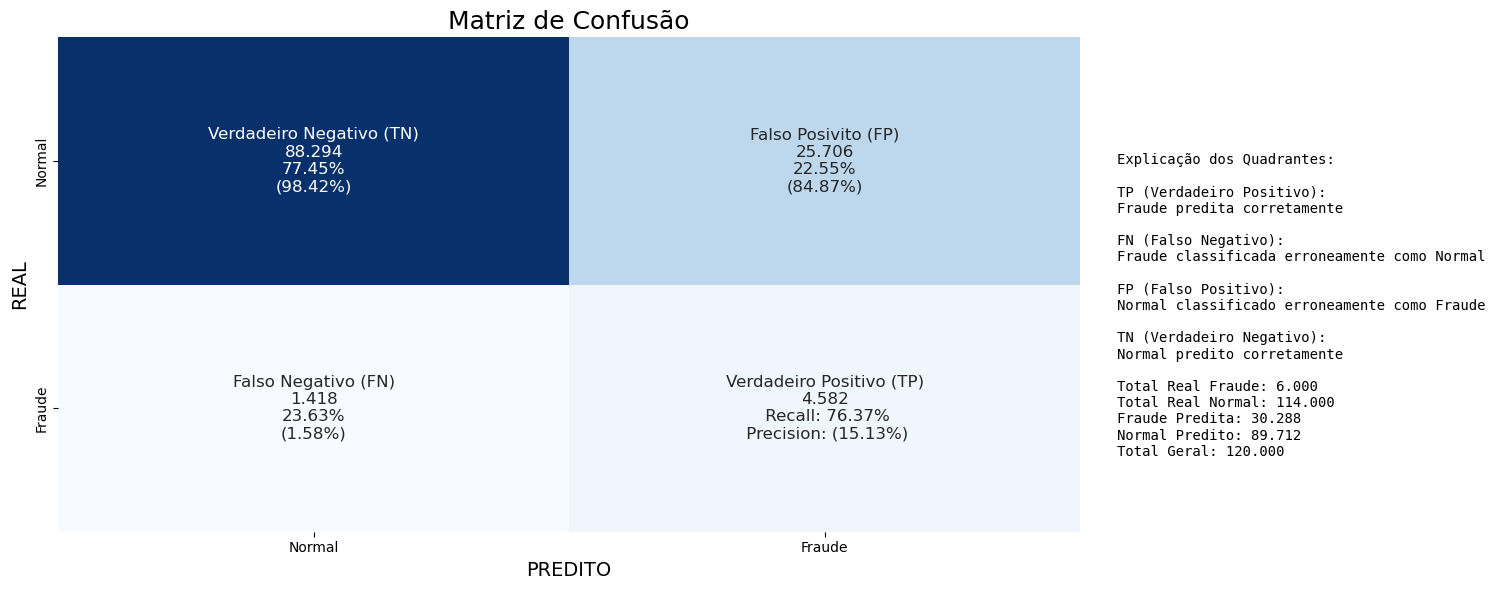

In [308]:
matriz_confusao(dt_imputed_date, x_train_imputed_date, y_train_imputer)

**Matriz de Confusão da base de Teste**

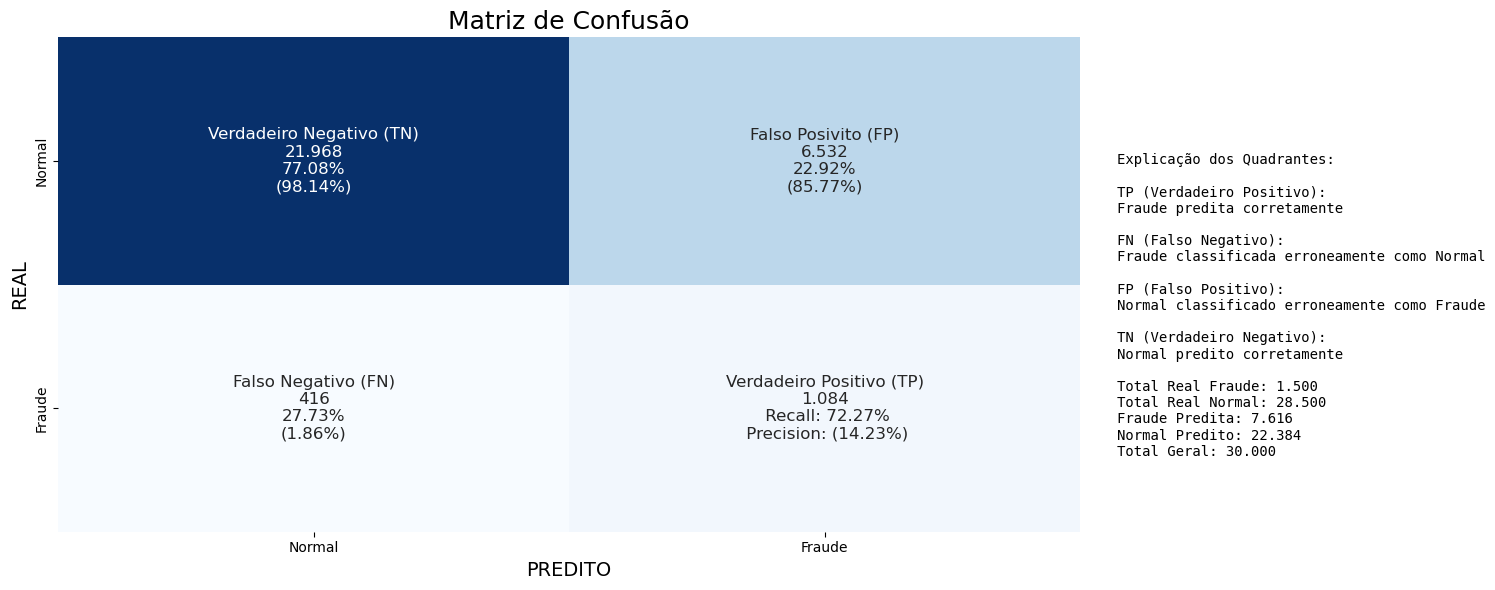

In [310]:
matriz_confusao(dt_imputed_date, x_test_imputed_date, y_test_imputer)

- Para essa configuração de Árvore de Decisão, **a inclusão de features temporais não trouxe ganho para o Modelo**.
  
- É possível que em Árvores de Decisão mais profundas, houvesse alguma melhora perceptível ao incluirmos as features temporais, mas provavelmente à custa da piora na generalização.

- Assim, **seguiremos sem as features temporais**.

### Treinamento de uma Regressão para avaliação da performance, considerando a imputação de vazios

- Também iremos treinar e avaliar os resultados de uma Regressão Logística porque, nos próximos ciclos, iremos realizar comparações de transformações que são pouco afetadas para Árvores de Decisão. 

In [376]:
reg_log_imputed_date = LogisticRegression(
    solver="saga",         
    max_iter=100,         
    n_jobs=-1,            
    penalty="l2",        
    class_weight='balanced', 
    verbose=2,            
    warm_start=True,       
    random_state=42
)

In [377]:
reg_log_imputed_date.fit(x_train_imputed_date, y_train_imputer)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


max_iter reached after 7 seconds


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [378]:
desempenho_reg_log_imputed_date=calcula_desempenho(reg_log_imputed_date, x_train_imputed_date, y_train_imputer, x_test_imputed_date, y_test_imputer)

In [379]:
desempenho_reg_log_imputed_date

,Treino,Teste,Variação%
Acurácia,80.40%,80.25%,-0.19%
AUROC,65.50%,65.74%,0.36%
Precision,9.26%,9.34%,0.82%
Recall,33.18%,33.87%,2.06%
F1,14.48%,14.64%,1.09%
F2,21.88%,22.20%,1.47%


## 4º Ciclo de tratamentos específicos seguidos de avaliação de performance utilizando os modelos Árvore de Decisão e Regressão Logística como referência

**Nessa ciclo vamos discretizar a base utilizando o K-Means.**

### Feature Engineering (Engenharia de Variáveis)

#### Discretização de Variáveis

- **Discretização é uma técnica de feature engineering** que transforma variáveis contínuas em variáveis discretas numéricas com comportamento de variável categórica, **agrupando seus valores em faixas (bins)**, baseando-se em algum critério.
  
- Uma das **vantagens** de criar variáveis discretas é que alguns algorítmos de Machine Learning **tendem a performar melhor quando munidos de variáveis discretas** porque alguns desses algorítmos tomam decisões baseados em particionamentos discretizados de cada variável.

##### K-Means Discretization (Discretização utilizando o algorítmo de Machine Learning K-Means)

- A discretização por meio do algorítmo de Machine Learning **K-Means divide os dados de cada variável em grupos (clusters) homogêneos**. Diferentemente de quando usamos o K-Means como um método-fim de resolução de problema envolvendo Machine Learning, em que fazemos a clusterização considerando várias variáveis em conjunto, **para a discretização iremos executar o K-Means em cada variável (feature) individualmente**.

- As etapas do K-Means são:

    - 1º: É definida a quantidade de grupos (clusters) em que os dados de cada variável serão divididos.
    - 2º: É sorteada aleatoriamente a posição central para cada cluster (essa posição é conhecida como **centróide**).
    - 3º: É calculada a distância de cada dado à posição de todos os centróides.
    - 4º: Cada dado é associada ao cluster cujo centróide esteja mais próximo dele.
    - 5º: Os centróides são recalculados como a média dos dados do seu respectivo cluster.
    - 6º: Repetimos o passo 3, calculando novamente todas as distâncias entre cada dado e a nova posição dos centróides.
    - 7º: Cada dado é associada ao cluster cujo centróide esteja mais próximo dele (considerando a nova posição dos centróides).
    - 8º: Repetimos o passo 5, calculando novamente a médias dos dados de cada cluster, e movemos o centróide mais uma vez, agora para essa nova média.
    - 9º: Os passos 3, 4 e 5 são repetidos até que os centróides não tenham mais mudanças de posição. Quando chegamos neste ponto, dizemos que o algoritmo K-Means convergiu para a solução de descoberta dos clusters.

In [384]:
x_train_kmeans = x_train_cbe_imputer.copy()
x_test_kmeans = x_test_cbe_imputer.copy()
# Está sendo copiado o x_train_cbe_imputer porque ele não contava com as variáveis de data/hora.

In [386]:
y_train_kmeans = y_train_imputer.copy()

In [387]:
y_train_kmeans.head()

40222     0
113835    0
67288     0
118571    0
5463      0
Name: fraude, dtype: int64

In [388]:
y_test_kmeans = y_test_imputer.copy()

In [389]:
y_test_kmeans.head()

22325    0
7970     1
47378    0
37537    0
40722    0
Name: fraude, dtype: int64

In [390]:
x_train_kmeans.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,valor_compra,doc_2_vazio,pais,categoria_produto,entrega_doc_3
40222,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,1.0,0.0,40.990002,1.0,0.055163,0.024016,0.075980
113835,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,1.0,1.0,9.070000,0.0,0.055163,0.057629,0.029087
67288,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,1.0,0.0,23.879999,1.0,0.055163,0.050000,0.029087
118571,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,0.0,0.0,31.190001,1.0,0.055163,0.064763,0.075980
5463,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,0.0,0.0,19.410000,0.0,0.050000,0.053131,0.075980


In [391]:
x_test_kmeans.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,valor_compra,doc_2_vazio,pais,categoria_produto,entrega_doc_3
22325,4.0,0.8054,3710.010010,15.0,0.199167,20.0,32.0,0.170378,5629.0,311.0,1.0,0.0,24.260000,1.0,0.055163,0.024016,0.029087
7970,4.0,0.7945,62113.718750,22.0,0.000000,1.0,5.0,0.866514,564.0,342.0,1.0,0.0,37.799999,0.0,0.055163,0.050000,0.029087
47378,4.0,0.8253,7268.939941,2.0,0.191935,74.0,14.0,0.777637,3620.0,91.0,1.0,1.0,12.700000,0.0,0.055163,0.047012,0.029087
37537,4.0,0.7754,38398.339844,35.0,0.779688,18.0,38.0,0.125672,4347.0,303.0,1.0,0.0,12.600000,1.0,0.055163,0.024016,0.029087
40722,4.0,0.7551,39319.968750,18.0,0.000000,11.0,20.0,0.250006,4062.0,83.0,1.0,1.0,70.790001,0.0,0.055163,0.024016,0.075980


- O K-Means é um algoritmo que **exige a informação de quantidade de clusters (k)** que serão criados.
  
- Para não tornar essa definição aleatória, podemos utilizar métodos que encontrem a quantidade ótima de clusters para o comportamento de cada variável.

- Um método muito conhecido é o **Elbow-Curve**. Mas ele tem problemas, como ser subjetivo por depender de interpretação gráfica de cada variável.

- Assim, iremos utilizar o **Silhouette Score** para definir a quantidade ótima de clusters para cada variável.

- O Silhouette Score varia de -1 a 1. Quanto maior o indicador, maior será a similaridade intra-cluster e maior será a dissimilaridade intercluster. **Ou seja, quanto maior o indicador, mais coeso estará cada cluster e mais distante estarão os clusters entre si.**

- Assim, vamos iterar o cálculo do Silhouette Score a até 5 clusters por variável afim de encontrar qual é a quantidade de clusters, para cada variável, que apresenta o maior Silhouette Score.

Cálculo do **Silhouette Score** é: 

- **b-a / max(a,b)**

- **a = distância média intra-cluster**. Ou seja, para cada observação é calculada a distância dela para todas as outras observações dentro do cluster. Isso é feito com todas as observações do cluster. E então, é tirada a média de todas essas distâncias. **É a similaridade dos dados dentro do cluster**.

- **b = é a distância média à observação do cluster mais próximo do qual a observação em questão não faz parte**. Representará a menor média das distâncias de todas as observações em um cluster diferente. **É a dissimilaridade intercluster**.

- **Quero um "b" grande (grande distância interclusters)**, que demonstrará a notória separação entre os clusters.

- E **quero um "a" pequeno (pequena distância intra-cluster)**, que demonstrará que a distância média dos dados dentro de um mesmo cluster é pequena.

- **Então quanto maior o Coeficiente Silhouette, melhor**.

**Funções para encontrar a quantidade ótima de clusters por coluna/feature**

In [395]:
def find_optimal_bins(X, min_bins=2, max_bins=10, strategy='kmeans', random_state=42, max_samples_silhouette=10000):
    """
    Encontra o número ótimo de bins usando silhouette score para uma coluna.
    """
    scores = {}
    
    print(f"    Testando de {min_bins} a {max_bins} bins...")
    
    for n_bins in range(min_bins, max_bins + 1):
        print(f"      Testando {n_bins} bins...", end=" ", flush=True)
        
        discretizer = KBinsDiscretizer(
            n_bins=n_bins,
            encode='ordinal',
            strategy=strategy,
            random_state=random_state
        )
        
        X_binned = discretizer.fit_transform(X)
        labels = X_binned.ravel()
        
        # Verificar se temos clusters únicos suficientes
        n_unique_labels = len(np.unique(labels))
        
        if n_unique_labels >= 2 and n_unique_labels < X.shape[0]:
            try:
                # OTIMIZAÇÃO: Usar amostragem para silhouette score se dataset for muito grande
                if X.shape[0] > max_samples_silhouette:
                    indices = np.random.RandomState(random_state).choice(
                        X.shape[0], 
                        size=max_samples_silhouette, 
                        replace=False
                    )
                    X_sample = X[indices]
                    labels_sample = labels[indices]
                    score = silhouette_score(X_sample, labels_sample)
                else:
                    score = silhouette_score(X, labels)
                
                scores[n_bins] = score
                print(f"Score: {score:.4f}")
            except Exception as e:
                scores[n_bins] = -1
                print(f"Erro: {e}")
        else:
            scores[n_bins] = -1
            print(f"Labels insuficientes")
    
    best_n_bins = max(scores, key=scores.get)
    best_score = scores[best_n_bins]
    
    return best_n_bins, best_score, scores


def find_optimal_bins_per_column(X, min_bins=2, max_bins=10, strategy='kmeans', random_state=42, max_samples_silhouette=10000):
    """
    Encontra o número ótimo de bins para cada coluna individualmente.
    Aceita DataFrame ou array numpy.
    """
    # Converter para numpy array se for DataFrame
    if isinstance(X, pd.DataFrame):
        col_names = X.columns
        X_array = X.values
    else:
        col_names = [f"col_{i}" for i in range(X.shape[1])]
        X_array = X
    
    print(f"Dataset: {X_array.shape[0]} linhas, {X_array.shape[1]} colunas")
    print(f"Usando amostragem de {max_samples_silhouette} amostras para silhouette score\n")
    
    optimal_bins_per_col = []
    
    # Barra de progresso para as colunas
    for col_idx in tqdm(range(X_array.shape[1]), desc="Processando colunas"):
        print(f"\n  Coluna {col_names[col_idx]}:")
        X_col = X_array[:, col_idx].reshape(-1, 1)
        
        best_n_bins, best_score, scores = find_optimal_bins(
            X_col,
            min_bins=min_bins,
            max_bins=max_bins,
            strategy=strategy,
            random_state=random_state,
            max_samples_silhouette=max_samples_silhouette
        )
        
        optimal_bins_per_col.append(best_n_bins)
        print(f"  Número ótimo de bins: {best_n_bins}")
        print(f"  Melhor silhouette score: {best_score:.4f}")
    
    return optimal_bins_per_col

In [396]:
optimal_bins_list = find_optimal_bins_per_column(
    x_train_kmeans,
    min_bins=2,
    max_bins=5,
    strategy='kmeans',
    random_state=42,
    max_samples_silhouette=10000
)

print(f"\nResumo - Bins ótimos por coluna: {optimal_bins_list}")

Dataset: 120000 linhas, 17 colunas
Usando amostragem de 10000 amostras para silhouette score



Processando colunas:   0%|          | 0/17 [00:00<?, ?it/s]


  Coluna score_1:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.9569
      Testando 3 bins... Score: 0.9676
      Testando 4 bins... Score: 1.0000
      Testando 5 bins... 

Processando colunas:   6%|▌         | 1/17 [00:11<03:07, 11.72s/it]

Score: 1.0000
  Número ótimo de bins: 4
  Melhor silhouette score: 1.0000

  Coluna score_2:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.6355
      Testando 3 bins... Score: 0.5452
      Testando 4 bins... Score: 0.5165
      Testando 5 bins... 

Processando colunas:  12%|█▏        | 2/17 [00:18<02:09,  8.65s/it]

Score: 0.5099
  Número ótimo de bins: 2
  Melhor silhouette score: 0.6355

  Coluna score_3:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.9404
      Testando 3 bins... Score: 0.9324
      Testando 4 bins... Score: 0.9317
      Testando 5 bins... 

Processando colunas:  18%|█▊        | 3/17 [00:25<01:49,  7.85s/it]

Score: 0.8680
  Número ótimo de bins: 2
  Melhor silhouette score: 0.9404

  Coluna score_4:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.7777
      Testando 3 bins... Score: 0.7652
      Testando 4 bins... Score: 0.7574
      Testando 5 bins... 

Processando colunas:  24%|██▎       | 4/17 [00:31<01:34,  7.26s/it]

Score: 0.7404
  Número ótimo de bins: 2
  Melhor silhouette score: 0.7777

  Coluna score_5:
    Testando de 2 a 5 bins...
      Testando 2 bins... Erro: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
      Testando 3 bins... Erro: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
      Testando 4 bins... Score: 0.9863
      Testando 5 bins... 

Processando colunas:  29%|██▉       | 5/17 [00:35<01:11,  5.92s/it]

Score: 0.9863
  Número ótimo de bins: 4
  Melhor silhouette score: 0.9863

  Coluna score_6:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.9993
      Testando 3 bins... Score: 0.9956
      Testando 4 bins... Score: 0.9925
      Testando 5 bins... 

Processando colunas:  35%|███▌      | 6/17 [00:42<01:09,  6.28s/it]

Score: 0.9904
  Número ótimo de bins: 2
  Melhor silhouette score: 0.9993

  Coluna score_7:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.6776
      Testando 3 bins... Score: 0.6430
      Testando 4 bins... Score: 0.6131
      Testando 5 bins... 

Processando colunas:  41%|████      | 7/17 [00:48<01:03,  6.33s/it]

Score: 0.5906
  Número ótimo de bins: 2
  Melhor silhouette score: 0.6776

  Coluna score_8:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.6265
      Testando 3 bins... Score: 0.5901
      Testando 4 bins... Score: 0.5691
      Testando 5 bins... 

Processando colunas:  47%|████▋     | 8/17 [00:54<00:56,  6.33s/it]

Score: 0.5578
  Número ótimo de bins: 2
  Melhor silhouette score: 0.6265

  Coluna score_9:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.6228
      Testando 3 bins... Score: 0.5831
      Testando 4 bins... Score: 0.5639
      Testando 5 bins... 

Processando colunas:  53%|█████▎    | 9/17 [01:00<00:50,  6.28s/it]

Score: 0.5571
  Número ótimo de bins: 2
  Melhor silhouette score: 0.6228

  Coluna score_10:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.6764
      Testando 3 bins... Score: 0.6307
      Testando 4 bins... Score: 0.6191
      Testando 5 bins... 

Processando colunas:  59%|█████▉    | 10/17 [01:07<00:44,  6.32s/it]

Score: 0.6014
  Número ótimo de bins: 2
  Melhor silhouette score: 0.6764

  Coluna entrega_doc_1:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 1.0000
      Testando 3 bins... Score: 1.0000
      Testando 4 bins... Score: 1.0000
      Testando 5 bins... 

Processando colunas:  65%|██████▍   | 11/17 [01:13<00:38,  6.42s/it]

Score: 1.0000
  Número ótimo de bins: 2
  Melhor silhouette score: 1.0000

  Coluna entrega_doc_2:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 1.0000
      Testando 3 bins... Score: 1.0000
      Testando 4 bins... Score: 1.0000
      Testando 5 bins... 

Processando colunas:  71%|███████   | 12/17 [01:20<00:32,  6.46s/it]

Score: 1.0000
  Número ótimo de bins: 2
  Melhor silhouette score: 1.0000

  Coluna valor_compra:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.8921
      Testando 3 bins... Score: 0.8537
      Testando 4 bins... Score: 0.8096
      Testando 5 bins... 

Processando colunas:  76%|███████▋  | 13/17 [01:27<00:26,  6.63s/it]

Score: 0.7217
  Número ótimo de bins: 2
  Melhor silhouette score: 0.8921

  Coluna doc_2_vazio:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 1.0000
      Testando 3 bins... Score: 1.0000
      Testando 4 bins... Score: 1.0000
      Testando 5 bins... 

Processando colunas:  82%|████████▏ | 14/17 [01:34<00:19,  6.57s/it]

Score: 1.0000
  Número ótimo de bins: 2
  Melhor silhouette score: 1.0000

  Coluna pais:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.9674
      Testando 3 bins... Score: 0.9907
      Testando 4 bins... Score: 0.9807
      Testando 5 bins... 

Processando colunas:  88%|████████▊ | 15/17 [01:40<00:13,  6.65s/it]

Score: 0.9915
  Número ótimo de bins: 5
  Melhor silhouette score: 0.9915

  Coluna categoria_produto:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 0.7868
      Testando 3 bins... Score: 0.8391
      Testando 4 bins... Score: 0.7979
      Testando 5 bins... 

Processando colunas:  94%|█████████▍| 16/17 [01:47<00:06,  6.57s/it]

Score: 0.7565
  Número ótimo de bins: 3
  Melhor silhouette score: 0.8391

  Coluna entrega_doc_3:
    Testando de 2 a 5 bins...
      Testando 2 bins... Score: 1.0000
      Testando 3 bins... Score: 1.0000
      Testando 4 bins... Score: 1.0000
      Testando 5 bins... 

Processando colunas: 100%|██████████| 17/17 [01:53<00:00,  6.68s/it]

Score: 1.0000
  Número ótimo de bins: 2
  Melhor silhouette score: 1.0000

Resumo - Bins ótimos por coluna: [4, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 3, 2]


In [407]:
# Converter para array se necessário
if isinstance(x_train_kmeans, pd.DataFrame):
    x_train_array = x_train_kmeans.values
    x_test_array = x_test_kmeans.values
    col_names = x_train_kmeans.columns
else:
    x_train_array = x_train_kmeans
    x_test_array = x_test_kmeans
    col_names = [f"col_{i}" for i in range(x_train_array.shape[1])]

In [408]:
# Criar DataFrames para armazenar as colunas discretizadas
x_train_discretized = pd.DataFrame(index=x_train_kmeans.index if isinstance(x_train_kmeans, pd.DataFrame) else None)
x_test_discretized = pd.DataFrame(index=x_test_kmeans.index if isinstance(x_test_kmeans, pd.DataFrame) else None)

# Armazenar os discretizers para reutilização
discretizers = []

print("\nAplicando discretização...")
for col_idx in tqdm(range(x_train_array.shape[1]), desc="Discretizando colunas"):
    col_name = col_names[col_idx]
    new_col_name = f"{col_name}_kmeans"
    
    # Criar discretizer com o número ótimo de bins para cada coluna
    discretizer = KBinsDiscretizer(
        n_bins=optimal_bins_list[col_idx],
        encode='ordinal',
        strategy='kmeans',
        random_state=42
    )
    
    # FIT apenas no base de Treino
    discretizer.fit(x_train_array[:, col_idx].reshape(-1, 1))
    
    # TRANSFORM na base de Treino e de Teste
    x_train_discretized[new_col_name] = discretizer.transform(
        x_train_array[:, col_idx].reshape(-1, 1)
    ).ravel()
    
    x_test_discretized[new_col_name] = discretizer.transform(
        x_test_array[:, col_idx].reshape(-1, 1)
    ).ravel()
    
    # Guardar o discretizer caso precise depois
    discretizers.append(discretizer)

# Adicionar as colunas discretizadas aos DataFrames originais
if isinstance(x_train_kmeans, pd.DataFrame):
    x_train_kmeans = pd.concat([x_train_kmeans, x_train_discretized], axis=1)
    x_test_kmeans = pd.concat([x_test_kmeans, x_test_discretized], axis=1)
else:
    # Se eram arrays, converter para DataFrame
    x_train_kmeans = pd.DataFrame(x_train_array, columns=col_names)
    x_test_kmeans = pd.DataFrame(x_test_array, columns=col_names)
    x_train_kmeans = pd.concat([x_train_kmeans, x_train_discretized], axis=1)
    x_test_kmeans = pd.concat([x_test_kmeans, x_test_discretized], axis=1)

print("\n Discretização concluída!")
print(f"\nShape do x_train_kmeans: {x_train_kmeans.shape}")
print(f"Shape do x_test_kmeans: {x_test_kmeans.shape}")
print(f"\nColunas adicionadas:")
print(list(x_train_discretized.columns))


Aplicando discretização...


Discretizando colunas: 100%|██████████| 17/17 [00:00<00:00, 42.63it/s]


 Discretização concluída!

Shape do x_train_kmeans: (120000, 34)
Shape do x_test_kmeans: (30000, 34)

Colunas adicionadas:
['score_1_kmeans', 'score_2_kmeans', 'score_3_kmeans', 'score_4_kmeans', 'score_5_kmeans', 'score_6_kmeans', 'score_7_kmeans', 'score_8_kmeans', 'score_9_kmeans', 'score_10_kmeans', 'entrega_doc_1_kmeans', 'entrega_doc_2_kmeans', 'valor_compra_kmeans', 'doc_2_vazio_kmeans', 'pais_kmeans', 'categoria_produto_kmeans', 'entrega_doc_3_kmeans']


In [409]:
x_train_kmeans.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
40222,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,1.0
113835,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0
67288,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,1.0,0.0
118571,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,1.0
5463,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0


In [410]:
x_test_kmeans.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
22325,4.0,0.8054,3710.010010,15.0,0.199167,20.0,32.0,0.170378,5629.0,311.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,0.0
7970,4.0,0.7945,62113.718750,22.0,0.000000,1.0,5.0,0.866514,564.0,342.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.0
47378,4.0,0.8253,7268.939941,2.0,0.191935,74.0,14.0,0.777637,3620.0,91.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0
37537,4.0,0.7754,38398.339844,35.0,0.779688,18.0,38.0,0.125672,4347.0,303.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,0.0
40722,4.0,0.7551,39319.968750,18.0,0.000000,11.0,20.0,0.250006,4062.0,83.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,4.0,0.0,1.0


### Treinamento de uma Árvore de Decisão para avaliação da performance, considerando a imputação de vazios e também a discretização de features via K-Means

**Instanciando o Modelo**

In [413]:
dt_kmeans = DecisionTreeClassifier(min_samples_leaf=2,
                                     max_depth=5,
                                     class_weight='balanced',    
                                     random_state=42)

**Treinando o Modelo na base de Treino**

In [415]:
dt_kmeans.fit(x_train_kmeans, y_train_kmeans)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Desempenho do Modelo**

In [417]:
desempenho_dt_kmeans=calcula_desempenho(dt_kmeans, x_train_kmeans, y_train_kmeans, x_test_kmeans, y_test_kmeans)

In [418]:
desempenho_dt_kmeans

,Treino,Teste,Variação%
Acurácia,77.40%,76.84%,-0.72%
AUROC,84.69%,82.39%,-2.72%
Precision,15.13%,14.23%,-5.92%
Recall,76.37%,72.27%,-5.37%
F1,25.25%,23.78%,-5.83%
F2,42.20%,39.81%,-5.67%


**Matriz de Confusão da base de Treino**

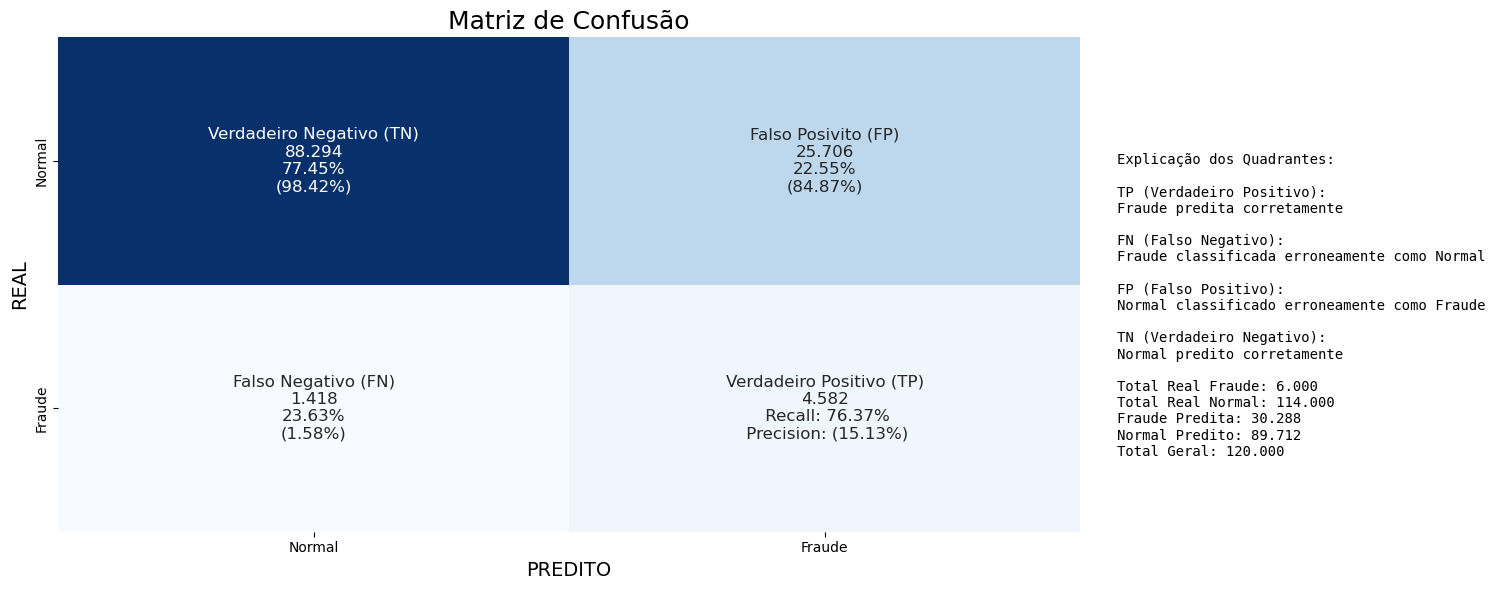

In [420]:
matriz_confusao(dt_kmeans, x_train_kmeans, y_train_kmeans)

**Matriz de Confusão da base de Teste**

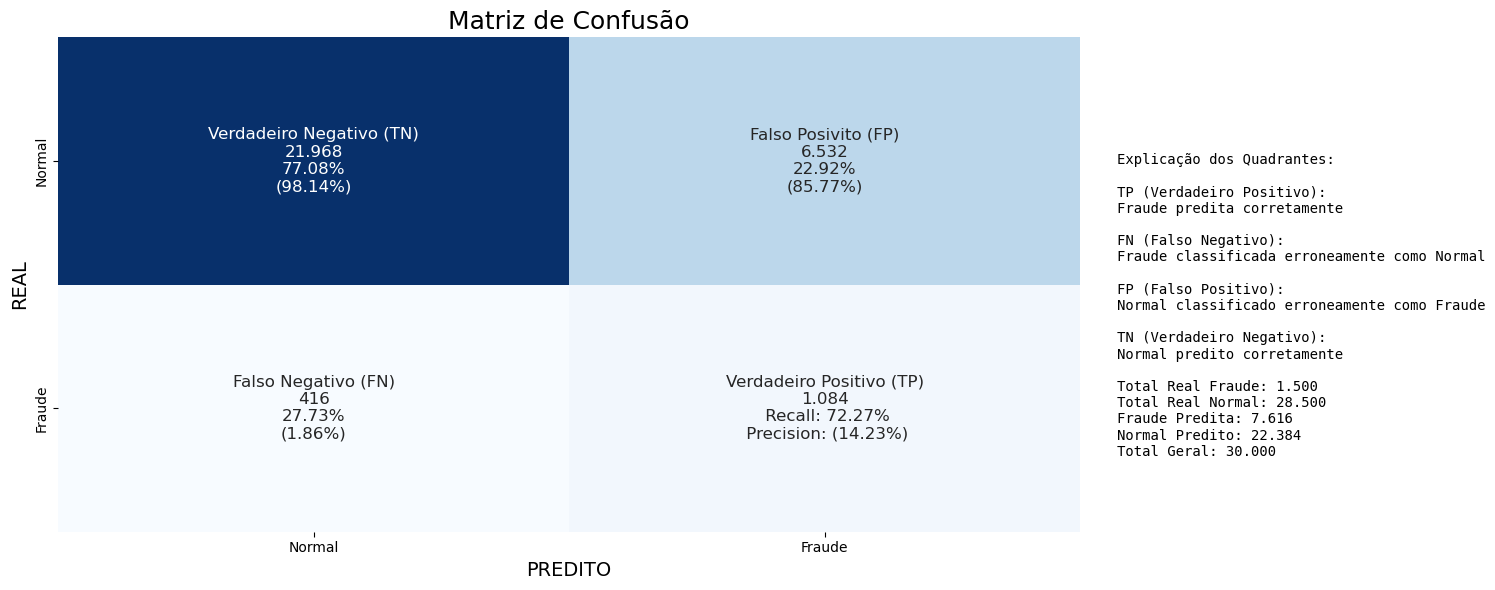

In [422]:
matriz_confusao(dt_kmeans, x_test_kmeans, y_test_kmeans)

### Treinamento de uma Regressão Logística para avaliação da performance, considerando a imputação de vazios e também a discretização de features via K-Means

In [434]:
reg_log_kmeans = LogisticRegression(
    solver="saga",         
    max_iter=100,         
    n_jobs=-1,            
    penalty="l2",         
    class_weight='balanced', 
    verbose=2,            
    warm_start=True,       
    random_state=42
)

In [435]:
reg_log_kmeans.fit(x_train_kmeans, y_train_kmeans)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


max_iter reached after 7 seconds


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [436]:
desempenho_reg_log_kmeans=calcula_desempenho(reg_log_kmeans, x_train_kmeans, y_train_kmeans, x_test_kmeans, y_test_kmeans)

In [437]:
desempenho_reg_log_kmeans

,Treino,Teste,Variação%
Acurácia,79.22%,78.90%,-0.41%
AUROC,65.52%,65.76%,0.37%
Precision,9.58%,9.41%,-1.72%
Recall,37.37%,37.33%,-0.09%
F1,15.24%,15.03%,-1.39%
F2,23.64%,23.43%,-0.90%


- Nota-se que a inclusão de features discretizadas via K-Means não trouxe melhoria para uma Árvore de Decisão, o que já era esperado.
  
- Por outro lado, nota-se que **a inclusão de features discretizadas via K-Means trouxe melhoria para uma Regressão Logística**, especialmente no indicador Recall. Outras famílias de algorítmos de Machine Learning, como Redes Neurais, também podem ser beneficiadas pela inclusão de features discretizadas no dataset.

- **Como ainda vamos testar Modelos de Machine Learning de famílias de algorítmos diferentes, seguiremos com a inclusão das features discretizadas.**

## 5º Ciclo de tratamentos específicos seguidos de avaliação de performance utilizando os modelos Árvore de Decisão e Regressão Logística como referência

**Nesse ciclo vamos discretizar a base utilizando a técnica Decision Tree Discretization.**

### Feature Engineering (Engenharia de Variáveis)

#### Discretização de Variáveis

##### Decision Tree Discretization (Discretização utilizando o algorítmo de Machine Learning Decision Tree)

- Existem várias técnicas de discretização. Uma das mais robustas é a **discretização utilizando o algorítmo de Machine Learning de Árvore de Decisão** para agrupar os valores de uma variável. Essa técnica **só é válida para bases de dados supervisionadas**.
  
- **Esta discretização utiliza uma Árvore de Decisão para determinar os pontos de corte ótimos**. A Árvore é treinada com a variável contínua como feature e uma variável alvo (Target) categórica. A Árvore de Decisão identifica os pontos de corte (splits) que melhor separam os dados em termos da variável alvo. Com base nos pontos de corte identificados, a variável contínua é discretizada em intervalos. Cada intervalo representa uma categoria distinta.

- Ex: Digamos que temos uma base com várias colunas. E que uma delas a a variável 'Idade' e há uma variável Target 'Valor do Seguro'. Poderíamos criar uma variável discretizada da Idade rodando uma Árvore de Decisão entre a 'Idade' e o Target 'Valor do Seguro'. Digamos que a Árvore teve profundidade 2 e fez a seguinte divisão para separar os valores de seguro de acordo com a idade: **pessoas com até 40 anos e pessoas com mais de 40 anos. Daí, teríamos uma nova coluna: para pessoas com até 40 anos seria atribuído o valor da média do 'Valor do Seguro' de quem tem até 40 anos (ou poderia ser atribuído, por exemplo, o número 0,20, que seria, no caso, a probabilidade média do intervalo de ser da classe positiva - Classe 1). E para pessoas com mais de 40 anos seria atribuído o valor da média do 'Valor do Seguro' de quem tem mais de 40 anos (ou poderia ser atribuído, por exemplo, o número 0,60, que seria, no caso, a probabilidade média do intervalo de ser da classe positiva - Classe 1)**. A biblioteca feature-engine já trabalha com o grid-search do sklearn para utilizar a Árvore de Decisão que, baseada em algum indicador como ROC-AUC, melhor discretize a variável contínua.

- Além das técnicas de discretização utilizando K-means e Decision Tree, também existem **técnicas de discretização mais simples**. Há 2 técnicas muito utilizadas: Equal Width Binning (Discretização por largura igual) e Equal Frequency Binning (Discretização por frequência igual).
  
- O **Equal Width Binning** divide os dados de cada coluna de forma que o intervalo de cada grupo tenha o mesmo tamanho.

- O **Equal Frequency Binning** divide os dados de cada coluna de forma que cada grupo contenha o mesmo número de observações.

In [442]:
x_train_tree = x_train_kmeans.copy()

In [443]:
x_train_tree.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
40222,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,1.0
113835,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0
67288,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,1.0,0.0
118571,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,1.0
5463,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0


In [444]:
x_test_tree = x_test_kmeans.copy()

In [445]:
x_test_tree.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
22325,4.0,0.8054,3710.010010,15.0,0.199167,20.0,32.0,0.170378,5629.0,311.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,0.0
7970,4.0,0.7945,62113.718750,22.0,0.000000,1.0,5.0,0.866514,564.0,342.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.0
47378,4.0,0.8253,7268.939941,2.0,0.191935,74.0,14.0,0.777637,3620.0,91.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0
37537,4.0,0.7754,38398.339844,35.0,0.779688,18.0,38.0,0.125672,4347.0,303.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,0.0
40722,4.0,0.7551,39319.968750,18.0,0.000000,11.0,20.0,0.250006,4062.0,83.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,4.0,0.0,1.0


In [446]:
y_train_tree = y_train_kmeans.copy()

In [447]:
y_train_tree.head()

40222     0
113835    0
67288     0
118571    0
5463      0
Name: fraude, dtype: int64

In [448]:
y_test_tree = y_test_kmeans.copy()

In [449]:
y_test_tree.head()

22325    0
7970     1
47378    0
37537    0
40722    0
Name: fraude, dtype: int64

**Como a discretização via Decision Tree Discretization precisa da coluna do Target (coluna 'fraude', no caso), é necessário concatenar o dataframe com as features (x) com o dataframe que possui o target (y)**

**Alinhando os Dataframes da base de Treino**

In [453]:
x_train_tree= x_train_tree.reset_index(drop=True)

In [454]:
y_train_tree= y_train_tree.reset_index(drop=True)

In [455]:
df_train_tree = pd.concat([x_train_tree, y_train_tree], axis=1)

In [456]:
df_train_tree.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans,fraude
0,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,...,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,1.0,0
1,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,...,1.0,1.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0,0
2,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,...,1.0,0.0,1.0,0.0,0.0,1.0,4.0,1.0,0.0,0
3,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,...,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,1.0,0
4,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,...,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,0


In [457]:
df_train_tree.shape

(120000, 35)

**Alinhando os Dataframes da base de Teste**

In [459]:
x_test_tree= x_test_tree.reset_index(drop=True)

In [460]:
y_test_tree= y_test_tree.reset_index(drop=True)

In [461]:
df_test_tree = pd.concat([x_test_tree, y_test_tree], axis=1)

In [462]:
df_test_tree.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans,fraude
0,4.0,0.8054,3710.010010,15.0,0.199167,20.0,32.0,0.170378,5629.0,311.0,...,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,0.0,0
1,4.0,0.7945,62113.718750,22.0,0.000000,1.0,5.0,0.866514,564.0,342.0,...,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.0,1
2,4.0,0.8253,7268.939941,2.0,0.191935,74.0,14.0,0.777637,3620.0,91.0,...,1.0,0.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0,0
3,4.0,0.7754,38398.339844,35.0,0.779688,18.0,38.0,0.125672,4347.0,303.0,...,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,0.0,0
4,4.0,0.7551,39319.968750,18.0,0.000000,11.0,20.0,0.250006,4062.0,83.0,...,1.0,0.0,1.0,1.0,0.0,0.0,4.0,0.0,1.0,0


In [463]:
df_test_tree.shape

(30000, 35)

In [464]:
list(df_train_tree.columns)

['score_1',
 'score_2',
 'score_3',
 'score_4',
 'score_5',
 'score_6',
 'score_7',
 'score_8',
 'score_9',
 'score_10',
 'entrega_doc_1',
 'entrega_doc_2',
 'valor_compra',
 'doc_2_vazio',
 'pais',
 'categoria_produto',
 'entrega_doc_3',
 'score_1_kmeans',
 'score_2_kmeans',
 'score_3_kmeans',
 'score_4_kmeans',
 'score_5_kmeans',
 'score_6_kmeans',
 'score_7_kmeans',
 'score_8_kmeans',
 'score_9_kmeans',
 'score_10_kmeans',
 'entrega_doc_1_kmeans',
 'entrega_doc_2_kmeans',
 'valor_compra_kmeans',
 'doc_2_vazio_kmeans',
 'pais_kmeans',
 'categoria_produto_kmeans',
 'entrega_doc_3_kmeans',
 'fraude']

**Realizando a discretização via Decision Tree Discretization**

In [486]:
from tqdm.std import tqdm        
from tqdm_joblib import tqdm_joblib 

# Definição das features a discretizar
features = [
    'score_1', 'score_2', 'score_3', 'score_4', 'score_5', 'score_6', 'score_7', 'score_8', 'score_9', 'score_10', 
    'entrega_doc_1','entrega_doc_2', 'valor_compra', 'doc_2_vazio', 'pais', 'categoria_produto', 'entrega_doc_3'
]

# Função que treina um discretizador em uma feature e retorna os datasets transformados
def discretizar_feature(feature, X_train, y_train, X_test):
    """
    Treina um DecisionTreeDiscretiser em uma feature da base de treino,
    aplica no treino e no teste, e retorna as colunas discretizadas.
    """
    discretiser = DecisionTreeDiscretiser(
        cv=3,                 # cross-validation dentro do discretizador
        scoring='roc_auc',    
        variables=[feature],  # qual variável discretizar
        regression=False,     # target é categórico (fraude)
        param_grid={
            'max_depth': [2, 3, 4, 5],           
            'min_samples_leaf': [0.05, 0.10, 0.15], 
            'class_weight': ['balanced']         
        }
    )

    # Fit apenas na base de treino
    discretiser.fit(X_train, y_train)

    # Transformar treino e teste
    X_train_disc = discretiser.transform(X_train)
    X_test_disc = discretiser.transform(X_test)

    # Renomear a coluna nova com sufixo "_tree"
    new_col_name = feature + "_tree"
    return new_col_name, X_train_disc[feature], X_test_disc[feature]


# Executar paralelamente com barra de progresso
print("Discretizando features...")
with tqdm_joblib(tqdm(desc="Features", total=len(features))) as progress_bar:
    results = Parallel(n_jobs=-1)(
        delayed(discretizar_feature)(feat, df_train_tree[features], df_train_tree['fraude'], df_test_tree[features])
        for feat in features
    )

# Adiciona as colunas discretizadas aos datasets originais
for new_col, train_col, test_col in results:
    df_train_tree[new_col] = train_col
    df_test_tree[new_col] = test_col

print(f"\n✅ Discretização concluída! {len(features)} novas features criadas.")

Discretizando features...


Features:   0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]


✅ Discretização concluída! 17 novas features criadas.


In [488]:
df_train_tree.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_tree,score_9_tree,score_10_tree,entrega_doc_1_tree,entrega_doc_2_tree,valor_compra_tree,doc_2_vazio_tree,pais_tree,categoria_produto_tree,entrega_doc_3_tree
0,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,...,0.508766,0.409649,0.422047,0.429021,0.485272,0.484928,0.286371,0.526758,0.310237,0.611372
1,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,...,0.481095,0.241339,0.286109,0.429021,0.566086,0.431651,0.735527,0.526758,0.681507,0.360154
2,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,...,0.508766,0.367776,0.422047,0.429021,0.485272,0.484928,0.286371,0.526758,0.481214,0.360154
3,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,...,0.508766,0.811191,0.501614,0.785442,0.485272,0.484928,0.286371,0.526758,0.782273,0.611372
4,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,...,0.508766,0.306852,0.589978,0.785442,0.485272,0.484928,0.735527,0.526758,0.649256,0.611372


In [489]:
df_train_tree.shape

(120000, 52)

In [490]:
df_test_tree.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_tree,score_9_tree,score_10_tree,entrega_doc_1_tree,entrega_doc_2_tree,valor_compra_tree,doc_2_vazio_tree,pais_tree,categoria_produto_tree,entrega_doc_3_tree
0,4.0,0.8054,3710.010010,15.0,0.199167,20.0,32.0,0.170378,5629.0,311.0,...,0.499691,0.241339,0.378348,0.429021,0.485272,0.484928,0.286371,0.526758,0.310237,0.360154
1,4.0,0.7945,62113.718750,22.0,0.000000,1.0,5.0,0.866514,564.0,342.0,...,0.508766,0.586420,0.378348,0.429021,0.485272,0.484928,0.735527,0.526758,0.481214,0.360154
2,4.0,0.8253,7268.939941,2.0,0.191935,74.0,14.0,0.777637,3620.0,91.0,...,0.508766,0.306852,0.501614,0.429021,0.566086,0.431651,0.735527,0.526758,0.362979,0.360154
3,4.0,0.7754,38398.339844,35.0,0.779688,18.0,38.0,0.125672,4347.0,303.0,...,0.499691,0.306852,0.422047,0.429021,0.485272,0.431651,0.286371,0.526758,0.310237,0.360154
4,4.0,0.7551,39319.968750,18.0,0.000000,11.0,20.0,0.250006,4062.0,83.0,...,0.499691,0.306852,0.501614,0.429021,0.566086,0.553267,0.735527,0.526758,0.310237,0.611372


In [491]:
df_test_tree.shape

(30000, 52)

**Removendo a coluna de Target ('fraude') que foi utilizada para realizar o Decision Tree Discretization**

In [493]:
x_train_tree_discretized = df_train_tree.drop(columns=['fraude'])

In [494]:
x_train_tree_discretized.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_tree,score_9_tree,score_10_tree,entrega_doc_1_tree,entrega_doc_2_tree,valor_compra_tree,doc_2_vazio_tree,pais_tree,categoria_produto_tree,entrega_doc_3_tree
0,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,...,0.508766,0.409649,0.422047,0.429021,0.485272,0.484928,0.286371,0.526758,0.310237,0.611372
1,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,...,0.481095,0.241339,0.286109,0.429021,0.566086,0.431651,0.735527,0.526758,0.681507,0.360154
2,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,...,0.508766,0.367776,0.422047,0.429021,0.485272,0.484928,0.286371,0.526758,0.481214,0.360154
3,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,...,0.508766,0.811191,0.501614,0.785442,0.485272,0.484928,0.286371,0.526758,0.782273,0.611372
4,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,...,0.508766,0.306852,0.589978,0.785442,0.485272,0.484928,0.735527,0.526758,0.649256,0.611372


In [495]:
x_test_tree_discretized = df_test_tree.drop(columns=['fraude'])

In [496]:
x_test_tree_discretized.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_tree,score_9_tree,score_10_tree,entrega_doc_1_tree,entrega_doc_2_tree,valor_compra_tree,doc_2_vazio_tree,pais_tree,categoria_produto_tree,entrega_doc_3_tree
0,4.0,0.8054,3710.010010,15.0,0.199167,20.0,32.0,0.170378,5629.0,311.0,...,0.499691,0.241339,0.378348,0.429021,0.485272,0.484928,0.286371,0.526758,0.310237,0.360154
1,4.0,0.7945,62113.718750,22.0,0.000000,1.0,5.0,0.866514,564.0,342.0,...,0.508766,0.586420,0.378348,0.429021,0.485272,0.484928,0.735527,0.526758,0.481214,0.360154
2,4.0,0.8253,7268.939941,2.0,0.191935,74.0,14.0,0.777637,3620.0,91.0,...,0.508766,0.306852,0.501614,0.429021,0.566086,0.431651,0.735527,0.526758,0.362979,0.360154
3,4.0,0.7754,38398.339844,35.0,0.779688,18.0,38.0,0.125672,4347.0,303.0,...,0.499691,0.306852,0.422047,0.429021,0.485272,0.431651,0.286371,0.526758,0.310237,0.360154
4,4.0,0.7551,39319.968750,18.0,0.000000,11.0,20.0,0.250006,4062.0,83.0,...,0.499691,0.306852,0.501614,0.429021,0.566086,0.553267,0.735527,0.526758,0.310237,0.611372


### Treinamento de uma Árvore de Decisão para avaliação da performance, considerando a imputação de vazios e também a discretização de features via K-Means Discretization e Decision Tree Discretization

**Instanciando o Modelo**

In [510]:
dt_tree_discretized = DecisionTreeClassifier(min_samples_leaf=2,
                                     max_depth=5,
                                     class_weight='balanced',    
                                     random_state=42)

**Treinando o Modelo na base de Treino**

In [512]:
dt_tree_discretized.fit(x_train_tree_discretized, y_train_tree)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Desempenho do Modelo**

In [514]:
desempenho_dt_tree_discretized=calcula_desempenho(dt_tree_discretized, x_train_tree_discretized, y_train_tree, x_test_tree_discretized, y_test_tree)

In [515]:
desempenho_dt_tree_discretized

,Treino,Teste,Variação%
Acurácia,76.41%,75.76%,-0.85%
AUROC,84.72%,82.32%,-2.84%
Precision,14.73%,13.75%,-6.61%
Recall,77.62%,73.00%,-5.95%
F1,24.76%,23.15%,-6.50%
F2,41.86%,39.22%,-6.33%


**Matriz de Confusão da base de Treino**

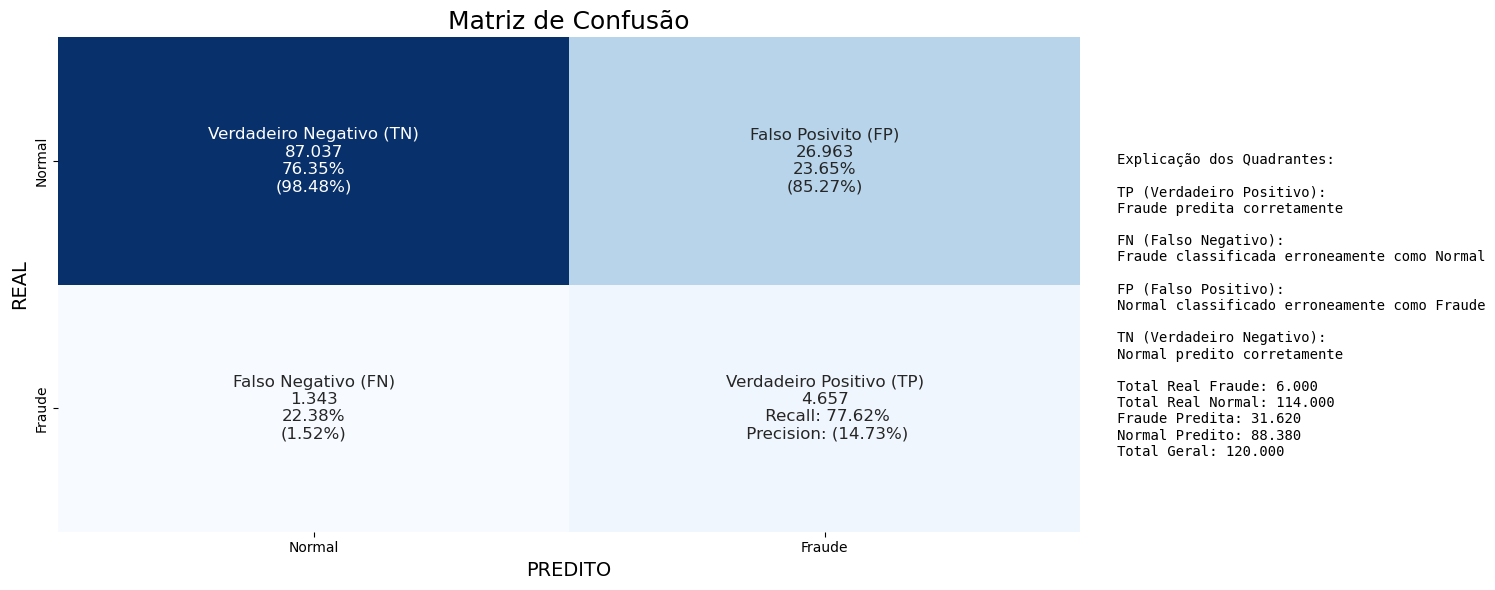

In [517]:
matriz_confusao(dt_tree_discretized, x_train_tree_discretized, y_train_tree)

**Matriz de Confusão da base de Teste**

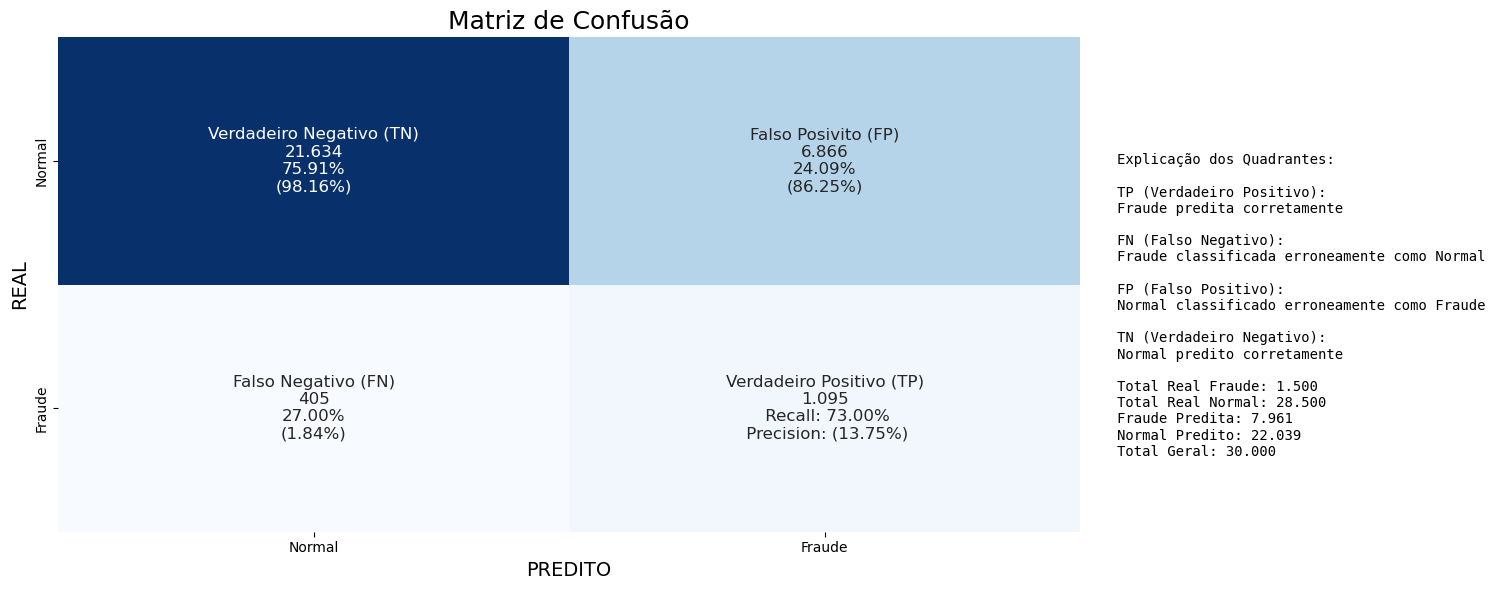

In [519]:
matriz_confusao(dt_tree_discretized, x_test_tree_discretized, y_test_tree)

### Treinamento de uma Regressão Logística para avaliação da performance, considerando a imputação de vazios e também a discretização de features via K-Means

In [526]:
reg_log_tree_discretized = LogisticRegression(
    solver="saga",         
    max_iter=100,         
    n_jobs=-1,            
    penalty="l2",         
    class_weight='balanced', 
    verbose=2,            
    warm_start=True,       
    random_state=42
)

In [527]:
reg_log_tree_discretized.fit(x_train_tree_discretized, y_train_tree)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


max_iter reached after 10 seconds


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [528]:
desempenho_reg_log_tree_discretized=calcula_desempenho(reg_log_tree_discretized, x_train_tree_discretized, y_train_tree, x_test_tree_discretized, y_test_tree)

In [529]:
desempenho_reg_log_tree_discretized

,Treino,Teste,Variação%
Acurácia,79.22%,78.90%,-0.41%
AUROC,65.52%,65.76%,0.37%
Precision,9.58%,9.41%,-1.72%
Recall,37.37%,37.33%,-0.09%
F1,15.24%,15.03%,-1.39%
F2,23.64%,23.43%,-0.90%


- **Ao incluir as features discretizadas via Decision Tree Discretization, os indicadores da Árvore de Decisão pioraram um pouco e os da Regressão Logística não mudaram.**

- **Assim, vamos seguir sem essas features discretizadas via Decision Tree Discretization.**

## Padronização da Escala (Scaling)

In [535]:
x_train_scaler = x_train_kmeans.copy()
x_test_scaler = x_test_kmeans.copy()
y_train_scaler = y_train_kmeans.copy()
y_test_scaler = y_test_kmeans.copy()

In [536]:
x_train_scaler.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
40222,4.0,0.80199,210446.828868,1.0,0.000000,11.0,19.0,0.917440,3122.0,181.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,1.0
113835,4.0,0.82180,31927.509766,20.0,0.553419,9.0,0.0,0.946183,5573.0,1061.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0
67288,4.0,0.68710,11216.540039,24.0,0.000000,33.0,10.0,0.603595,3136.0,202.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,1.0,0.0
118571,4.0,0.79300,31825.539062,4.0,0.000000,0.0,5.0,0.499857,61.0,57.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,1.0
5463,4.0,0.44130,22360.009766,8.0,0.307992,5.0,30.0,0.894125,3574.0,20.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0


In [537]:
x_test_scaler.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
22325,4.0,0.8054,3710.010010,15.0,0.199167,20.0,32.0,0.170378,5629.0,311.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,0.0
7970,4.0,0.7945,62113.718750,22.0,0.000000,1.0,5.0,0.866514,564.0,342.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.0
47378,4.0,0.8253,7268.939941,2.0,0.191935,74.0,14.0,0.777637,3620.0,91.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0
37537,4.0,0.7754,38398.339844,35.0,0.779688,18.0,38.0,0.125672,4347.0,303.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,0.0
40722,4.0,0.7551,39319.968750,18.0,0.000000,11.0,20.0,0.250006,4062.0,83.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,4.0,0.0,1.0


- Boa parte dos modelos de Machine Learning necessitam (ou são beneficiados) que essa etapa de **padronização de escala** seja efetuada antes do treinamento do modelo. Caso não seja realizada essa padronização, **algorítimos baseados em distância terão seus resultados distorcidos porque a distância entre as observações será maior por conta das diferentes escalas no espaço hiperdimensional, fazendo com que variáveis com escala maior (mas não necessariamente importância maior) dominem as distâncias e importância no modelo**. A padronização também ajuda (ou viabiliza que) vários algoritmos a **convergir mais rápido** (como Redes Neurais, SVM, e Regressões).

- A padronização de dados é especialmente importante para algoritmos que envolvam cálculos de distância, como algorítmos de clusterização (como o DB-Scan e K-Means) e também Regressões Lineares e Logísticas e Redes Neurais.

- Existem várias metodologias de padronização de escala. A padronização mantém a distribuição original dos dados, mas reescala os valores:

    - Uma das metodologias mais utilizadas é o **StandardScaler**. Essa metodologia transforma as variáveis ao, para cada variável, pegar cada dado e subtraí-lo pela média da variável e dividir essa subtração pelo desvio-padrão da variável. Esse cálculo que é realizado para cada observação de cada variável é conhecido como Z-Score. **Essa tranformação faz com que a média de cada variável seja 0 e que o desvio padrão de cada variável seja igual a 1**.
      
    - Uma outra metodologia é o **RobustScaler**. Ela transforma as variáveis ao, para cada variável, pegar cada dado e subtraí-lo pela mediana da variável e dividir essa subtração pelo Intervalo Interquartil (valor do 75º Quartil - valor do 25º Quartil) da variável. **Essa tranformação faz com que a *mediana (e não é média)* de cada variável seja 0. E, como ele considera o Intervalo Interquartil (que desconsidera os outliers) na divisão do processo de scaling, a escala não será distorcida pelos outliers.** Assim, os possíveis outliers continuarão presentes para serem identificados, mas eles não distorcerão o cálculo da padronização de todas as observações de cada variável.

- Vamos testar esses dois tipos de Scaling sobre uma Regressão Logística (que é sensível a Scaling) e ver qual apresentará melhores resultados

### Método StandardScaler

**Instanciando o método de Scaling StandardScaler**

In [543]:
standard_scaler = StandardScaler()

**Treinando o método de Scaling na base de Treino**

In [545]:
standard_scaler.fit(x_train_scaler)

,copy,True
,with_mean,True
,with_std,True


- Para que não haja Vazamento de Dados **(Data Leaked), devemos padronizar os dados a partir do conjunto de dados de Treino** e não sobre o conjunto de dados completo. Se executarmos o fit da padronização em cima do conjunto de dados completo, estaríamos usando um dado que não teríamos no momento do desenvolvimento (os dados da base de teste).

- Por isso, executamos o **fit SOMENTE base de *Treino*** e executamos o **transform (aplicação com base no fit) na base TANTO na base de Treino QUANTO na base de Teste**.

**Aplicando o método de Scaling na base de Treino com base no fit feito na base de Treino**

In [548]:
x_train_standard_scaler_array = standard_scaler.transform(x_train_scaler)

In [549]:
x_train_standard_scaler_array

array([[ 0.39031096,  0.57385221, -0.06116827, ...,  0.57820933,
        -1.06019447,  1.11660751],
       [ 0.39031096,  0.72819311, -0.28046716, ...,  0.57820933,
         0.8143482 , -0.89556983],
       [ 0.39031096, -0.32127435, -0.30590918, ...,  0.57820933,
         0.8143482 , -0.89556983],
       ...,
       [ 0.39031096,  0.27007383, -0.29288513, ...,  0.57820933,
         0.8143482 ,  1.11660751],
       [ 0.39031096, -0.22232662, -0.31348014, ...,  0.57820933,
        -1.06019447,  1.11660751],
       [ 0.39031096, -0.31114603,  0.36421975, ..., -1.66612588,
        -1.06019447, -0.89556983]])

- **O processo de pradonização (scaling) transforma a base em um array**.
- Transformando em um dataframe:

In [551]:
x_train_standard_scaler = pd.DataFrame(x_train_standard_scaler_array, columns=x_train_scaler.columns, index=x_train_scaler.index)

In [552]:
x_train_standard_scaler.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
40222,0.390311,0.573852,-0.061168,-1.031826,-0.082744,-0.055092,0.340459,1.455758,0.476291,-0.371375,...,1.006337,1.361972,-0.5817,0.327422,-0.437355,-0.178738,0.614312,0.578209,-1.060194,1.116608
113835,0.390311,0.728193,-0.280467,-0.084445,0.122953,-0.057803,-1.002007,1.555373,1.907833,2.370353,...,1.006337,1.361972,1.7191,0.327422,2.286469,-0.178738,-1.627838,0.578209,0.814348,-0.895570
67288,0.390311,-0.321274,-0.305909,0.115004,-0.082744,-0.025264,-0.295446,0.368059,0.484468,-0.305948,...,1.006337,1.361972,-0.5817,0.327422,-0.437355,-0.178738,0.614312,0.578209,0.814348,-0.895570
118571,0.390311,0.503808,-0.280592,-0.882239,-0.082744,-0.070006,-0.648726,0.008533,-1.311531,-0.757710,...,1.006337,-0.734230,-0.5817,-3.054163,-0.437355,-0.178738,0.614312,0.578209,0.814348,1.116608
5463,0.390311,-2.236338,-0.292220,-0.682791,0.031732,-0.063227,1.117675,1.374953,0.740288,-0.872987,...,1.006337,1.361972,-0.5817,-3.054163,-0.437355,-0.178738,-1.627838,-0.169902,0.814348,1.116608


In [553]:
x_train_standard_scaler.shape

(120000, 34)

**Aplicando o método de Scaling na base de Teste com base no fit feito na base de Treino**

In [555]:
x_test_standard_scaler_array = standard_scaler.transform(x_test_scaler)

In [556]:
x_test_standard_scaler_array

array([[ 0.39031096,  0.60041847, -0.31513044, ...,  0.57820933,
        -1.06019447, -0.89556983],
       [ 0.39031096,  0.51549481, -0.24338545, ...,  0.57820933,
         0.8143482 , -0.89556983],
       [ 0.39031096,  0.75546201, -0.31075854, ...,  0.57820933,
         0.8143482 , -0.89556983],
       ...,
       [ 0.39031096,  0.70793602,  0.43523803, ...,  0.57820933,
        -1.06019447,  1.11660751],
       [ 0.39031096,  1.1979992 , -0.14236565, ...,  0.57820933,
         2.68889087, -0.89556983],
       [ 0.39031096,  0.86843381, -0.0616545 , ...,  0.57820933,
         0.8143482 ,  1.11660751]])

- **O processo de pradonização (scaling) transforma a base em um array**.
- Transformando em um dataframe:

In [558]:
x_test_standard_scaler = pd.DataFrame(x_test_standard_scaler_array, columns=x_test_scaler.columns, index=x_test_scaler.index)

In [559]:
x_test_standard_scaler.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
22325,0.390311,0.600418,-0.315130,-0.333756,-0.008717,-0.042889,1.258988,-1.133348,1.940541,0.033653,...,-0.993703,1.361972,-0.5817,0.327422,-0.437355,-0.178738,0.614312,0.578209,-1.060194,-0.895570
7970,0.390311,0.515495,-0.243385,0.015279,-0.082744,-0.068650,-0.648726,1.279260,-1.017746,0.130236,...,1.006337,-0.734230,-0.5817,0.327422,-0.437355,-0.178738,-1.627838,0.578209,0.814348,-0.895570
47378,0.390311,0.755462,-0.310759,-0.981963,-0.011404,0.030325,-0.012822,0.971238,0.767155,-0.651779,...,1.006337,1.361972,-0.5817,0.327422,2.286469,-0.178738,-1.627838,0.578209,0.814348,-0.895570
37537,0.390311,0.366684,-0.272518,0.663487,0.207053,-0.045601,1.682924,-1.288289,1.191770,0.008728,...,-0.993703,1.361972,-0.5817,0.327422,-0.437355,-0.178738,0.614312,0.578209,-1.060194,-0.895570
40722,0.390311,0.208524,-0.271386,-0.184169,-0.082744,-0.055092,0.411115,-0.857381,1.025312,-0.676704,...,-0.993703,1.361972,-0.5817,0.327422,2.286469,-0.178738,-1.627838,0.578209,-1.060194,1.116608


In [560]:
x_test_standard_scaler.shape

(30000, 34)

**Instanciando o Modelo**

In [563]:
reg_log_standard_scaler = LogisticRegression(
    solver="saga",         
    max_iter=100,         
    n_jobs=-1,            
    penalty="l2",         
    class_weight='balanced', 
    verbose=2,            
    warm_start=False,       
    random_state=42
)

**Treinando o Modelo na base de Treino**

In [565]:
reg_log_standard_scaler.fit(x_train_standard_scaler, y_train_scaler)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


max_iter reached after 8 seconds


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


**Desempenho do Modelo**

In [567]:
desempenho_reg_log_standard_scaler=calcula_desempenho(reg_log_standard_scaler,x_train_standard_scaler, y_train_scaler, x_test_standard_scaler, y_test_scaler)

In [568]:
desempenho_reg_log_standard_scaler

,Treino,Teste,Variação%
Acurácia,78.24%,78.06%,-0.23%
AUROC,84.53%,83.16%,-1.62%
Precision,15.52%,15.09%,-2.77%
Recall,75.42%,73.20%,-2.94%
F1,25.74%,25.02%,-2.80%
F2,42.56%,41.35%,-2.85%


**Matriz de Confusão da base de Treino**

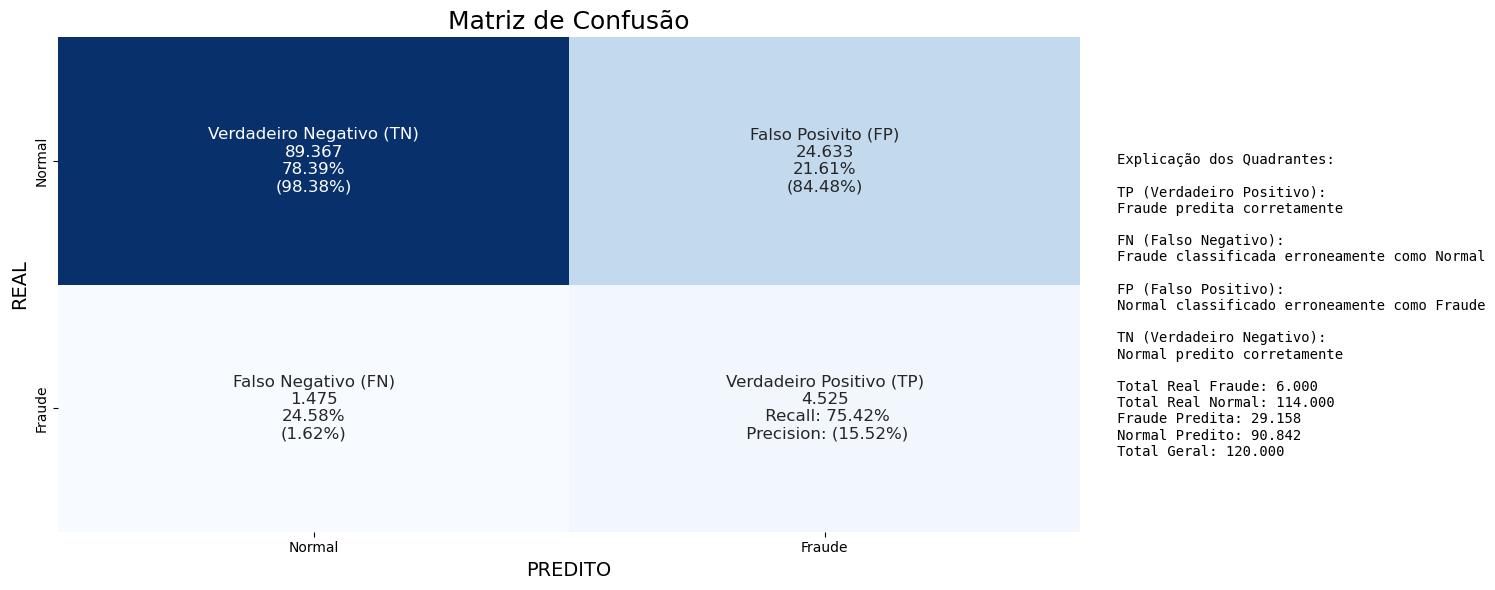

In [570]:
matriz_confusao(reg_log_standard_scaler, x_train_standard_scaler, y_train_scaler)

**Matriz de Confusão da base de Teste**

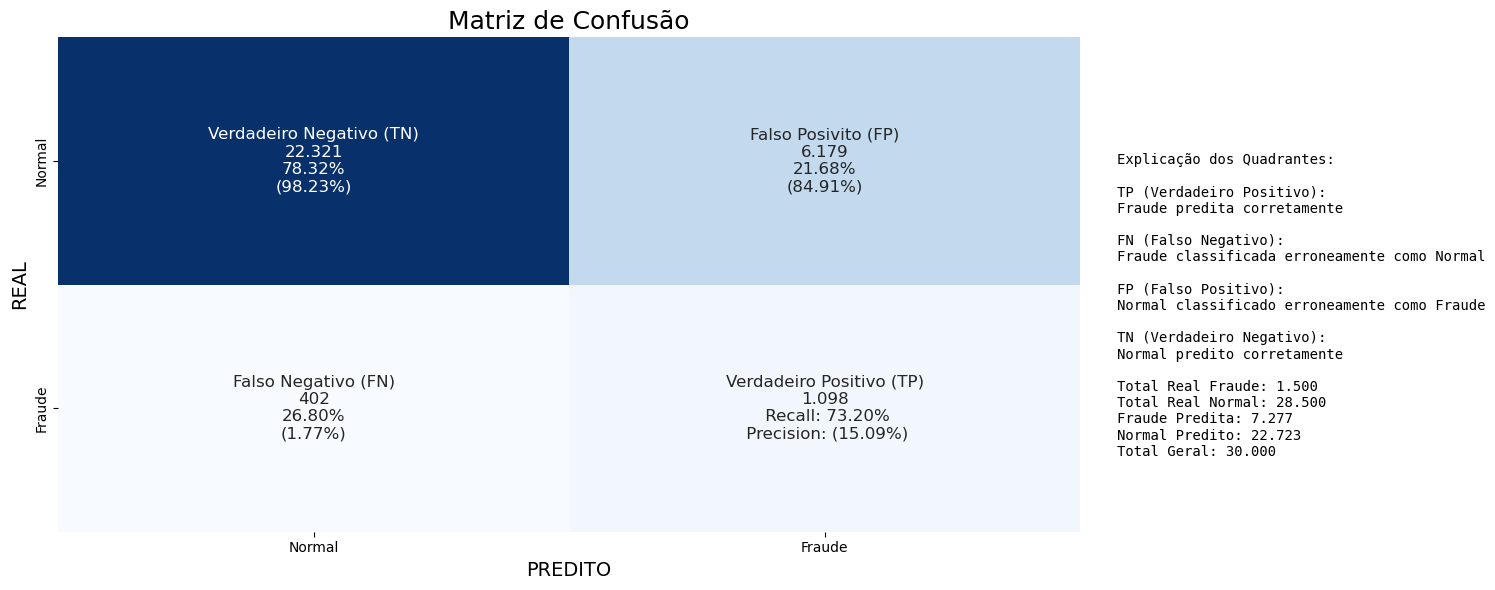

In [572]:
matriz_confusao(reg_log_standard_scaler, x_test_standard_scaler, y_test_scaler)

### Método RobustScaler

**Instanciando o método de Scaling RobustScaler**

In [601]:
robust_scaler = RobustScaler()

**Treinando o método de Scaling na base de Treino**

In [603]:
robust_scaler.fit(x_train_scaler)

,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False


- Para que não haja Vazamento de Dados **(Data Leaked), devemos padronizar os dados a partir do conjunto de dados de Treino** e não sobre o conjunto de dados completo. Se executarmos o fit da padronização em cima do conjunto de dados completo, estaríamos usando um dado que não teríamos no momento do desenvolvimento (os dados da base de teste).

- Por isso, executamos o **fit SOMENTE base de *Treino*** e executamos o **transform (aplicação com base no fit) na base TANTO na base de Treino QUANTO na base de Teste**.

**Aplicando o método de Scaling na base de Treino com base no fit feito na base de Treino**

In [606]:
x_train_robust_scaler_array = robust_scaler.transform(x_train_scaler)

In [607]:
x_train_robust_scaler_array

array([[ 0.        ,  0.40258994,  1.12949994, ...,  0.        ,
        -1.        ,  1.        ],
       [ 0.        ,  0.56472007, -0.12029145, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -0.53771163, -0.26528635, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.08348055, -0.19106188, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.        , -0.43377024, -0.30843351, ...,  0.        ,
        -1.        ,  1.        ],
       [ 0.        , -0.52707216,  3.55379992, ..., -1.5       ,
        -1.        ,  0.        ]])

- **O processo de pradonização (scaling) transforma a base em um array**.
- Transformando em um dataframe:

In [609]:
x_train_robust_scaler = pd.DataFrame(x_train_robust_scaler_array, columns=x_train_scaler.columns, index=x_train_scaler.index)

In [610]:
x_train_robust_scaler.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
40222,0.0,0.402590,1.129500,-0.270833,-0.372239,0.09375,0.555556,0.842436,0.467615,-0.031250,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0
113835,0.0,0.564720,-0.120291,0.125000,1.580890,0.03125,-0.500000,0.899890,1.435624,2.084135,...,1.0,1.0,1.0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0
67288,0.0,-0.537712,-0.265286,0.208333,-0.372239,0.78125,0.055556,0.215093,0.473144,0.019231,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
118571,0.0,0.329011,-0.121005,-0.208333,-0.372239,-0.25000,-0.222222,0.007732,-0.741311,-0.329327,...,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0
5463,0.0,-2.549424,-0.187272,-0.125000,0.714728,-0.09375,1.166667,0.795831,0.646130,-0.418269,...,1.0,1.0,0.0,-1.0,0.0,0.0,-1.0,-0.5,0.0,1.0


In [611]:
x_train_robust_scaler.shape

(120000, 34)

**Aplicando o método de Scaling na base de Teste com base no fit feito na base de Treino**

In [613]:
x_test_robust_scaler_array = robust_scaler.transform(x_test_scaler)

In [614]:
x_test_robust_scaler_array

array([[ 0.        ,  0.43049693, -0.31783863, ...,  0.        ,
        -1.        ,  0.        ],
       [ 0.        ,  0.34128736,  0.09103842, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.59336517, -0.29292301, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.54344065,  3.95853536, ...,  0.        ,
        -1.        ,  1.        ],
       [ 0.        ,  1.05823621,  0.66675349, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.        ,  0.71203839,  1.1267289 , ...,  0.        ,
         0.        ,  1.        ]])

- **O processo de pradonização (scaling) transforma a base em um array**.
- Transformando em um dataframe:

In [616]:
x_test_robust_scaler = pd.DataFrame(x_test_robust_scaler_array, columns=x_test_scaler.columns, index=x_test_scaler.index)

In [617]:
x_test_robust_scaler.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
22325,0.0,0.430497,-0.317839,0.020833,0.330661,0.37500,1.277778,-0.650861,1.457741,0.281250,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
7970,0.0,0.341287,0.091038,0.166667,-0.372239,-0.21875,-0.222222,0.740639,-0.542654,0.355769,...,1.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
47378,0.0,0.593365,-0.292923,-0.250000,0.305141,2.06250,0.277778,0.562983,0.664297,-0.247596,...,1.0,1.0,0.0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0
37537,0.0,0.184966,-0.074990,0.437500,2.379439,0.31250,1.611111,-0.740225,0.951422,0.262019,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
40722,0.0,0.018824,-0.068538,0.083333,-0.372239,0.09375,0.611111,-0.491694,0.838863,-0.266827,...,0.0,1.0,0.0,0.0,1.0,0.0,-1.0,0.0,-1.0,1.0


In [618]:
x_test_robust_scaler.shape

(30000, 34)

**Instanciando o Modelo**

In [621]:
reg_log_robust_scaler = LogisticRegression(
    solver="saga",        
    max_iter=100,         
    n_jobs=-1,            
    penalty="l2",         
    class_weight='balanced',
    verbose=2,            
    warm_start=False,      
    random_state=42
)

**Treinando o Modelo na base de Treino**

In [623]:
reg_log_robust_scaler.fit(x_train_robust_scaler, y_train_scaler)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


max_iter reached after 8 seconds


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


**Desempenho do Modelo**

In [625]:
desempenho_reg_log_robust_scaler=calcula_desempenho(reg_log_robust_scaler,x_train_robust_scaler, y_train_scaler, x_test_robust_scaler, y_test_scaler)

In [626]:
desempenho_reg_log_robust_scaler

,Treino,Teste,Variação%
Acurácia,63.94%,63.60%,-0.52%
AUROC,80.56%,79.27%,-1.61%
Precision,10.41%,10.19%,-2.08%
Recall,81.68%,80.40%,-1.57%
F1,18.47%,18.09%,-2.02%
F2,34.48%,33.82%,-1.91%


**Matriz de Confusão da base de Treino**

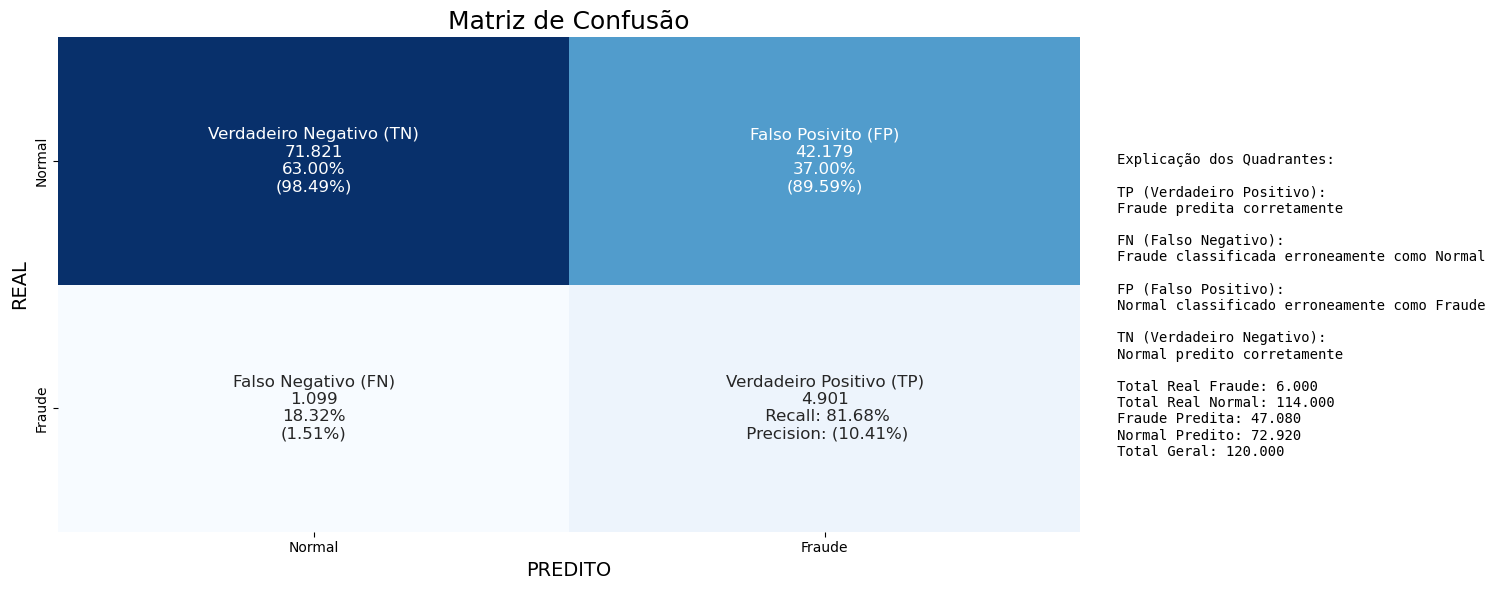

In [628]:
matriz_confusao(reg_log_robust_scaler, x_train_robust_scaler, y_train_scaler)

**Matriz de Confusão da base de Teste**

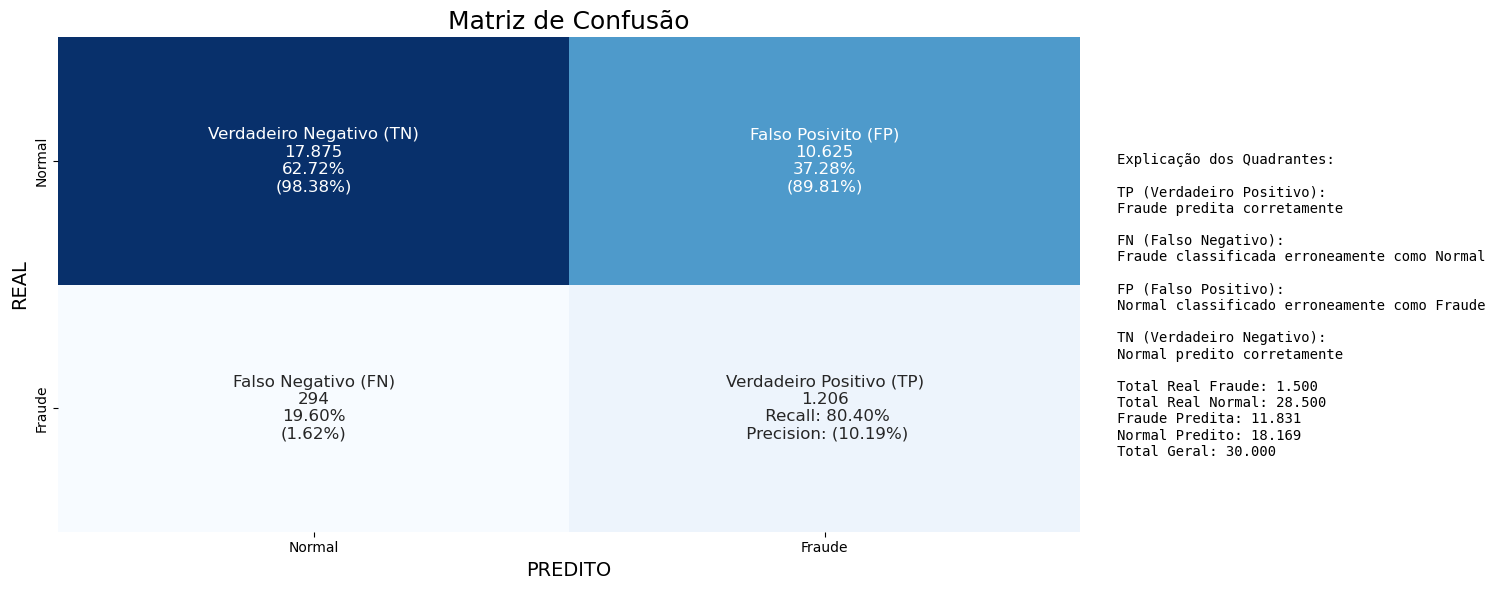

In [630]:
matriz_confusao(reg_log_robust_scaler, x_test_robust_scaler, y_test_scaler)

- Nota-se que o Scaling utilizando o **StandardScaler foi muito melhor para a nossa base de dados**.
  
- **Assim, seguiremos com o StandardScaler.**

## 6º Ciclo de tratamentos específicos seguidos de avaliação de performance utilizando os modelos Árvore de Decisão e Regressão Logística como referência

**Nesse ciclo vamos criar Features Polinomiais.**

### Feature Engineering (Engenharia de Variáveis)

#### Criação de Features Polinomiais

O método de features polinomiais consiste em **gerar novas features elevando as existentes a uma determinada potência e combinando-as entre si**. Por exemplo, se temos duas features, $x_1$ e $x_2$, ao criar features polinomiais de grau 2, teremos como resultado: 

* $x_1^2$
* $x_2^2$
* $x_1*x_2$

A adição de features polinomiais pode melhorar a capacidade preditiva do modelo, especialmente quando há uma relação polinomial subjacente nos dados.

In [652]:
x_train_poly = x_train_standard_scaler.copy()

In [653]:
x_train_poly.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
40222,0.390311,0.573852,-0.061168,-1.031826,-0.082744,-0.055092,0.340459,1.455758,0.476291,-0.371375,...,1.006337,1.361972,-0.5817,0.327422,-0.437355,-0.178738,0.614312,0.578209,-1.060194,1.116608
113835,0.390311,0.728193,-0.280467,-0.084445,0.122953,-0.057803,-1.002007,1.555373,1.907833,2.370353,...,1.006337,1.361972,1.7191,0.327422,2.286469,-0.178738,-1.627838,0.578209,0.814348,-0.895570
67288,0.390311,-0.321274,-0.305909,0.115004,-0.082744,-0.025264,-0.295446,0.368059,0.484468,-0.305948,...,1.006337,1.361972,-0.5817,0.327422,-0.437355,-0.178738,0.614312,0.578209,0.814348,-0.895570
118571,0.390311,0.503808,-0.280592,-0.882239,-0.082744,-0.070006,-0.648726,0.008533,-1.311531,-0.757710,...,1.006337,-0.734230,-0.5817,-3.054163,-0.437355,-0.178738,0.614312,0.578209,0.814348,1.116608
5463,0.390311,-2.236338,-0.292220,-0.682791,0.031732,-0.063227,1.117675,1.374953,0.740288,-0.872987,...,1.006337,1.361972,-0.5817,-3.054163,-0.437355,-0.178738,-1.627838,-0.169902,0.814348,1.116608


In [654]:
x_test_poly = x_test_standard_scaler.copy()

In [655]:
x_test_poly.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,...,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans
22325,0.390311,0.600418,-0.315130,-0.333756,-0.008717,-0.042889,1.258988,-1.133348,1.940541,0.033653,...,-0.993703,1.361972,-0.5817,0.327422,-0.437355,-0.178738,0.614312,0.578209,-1.060194,-0.895570
7970,0.390311,0.515495,-0.243385,0.015279,-0.082744,-0.068650,-0.648726,1.279260,-1.017746,0.130236,...,1.006337,-0.734230,-0.5817,0.327422,-0.437355,-0.178738,-1.627838,0.578209,0.814348,-0.895570
47378,0.390311,0.755462,-0.310759,-0.981963,-0.011404,0.030325,-0.012822,0.971238,0.767155,-0.651779,...,1.006337,1.361972,-0.5817,0.327422,2.286469,-0.178738,-1.627838,0.578209,0.814348,-0.895570
37537,0.390311,0.366684,-0.272518,0.663487,0.207053,-0.045601,1.682924,-1.288289,1.191770,0.008728,...,-0.993703,1.361972,-0.5817,0.327422,-0.437355,-0.178738,0.614312,0.578209,-1.060194,-0.895570
40722,0.390311,0.208524,-0.271386,-0.184169,-0.082744,-0.055092,0.411115,-0.857381,1.025312,-0.676704,...,-0.993703,1.361972,-0.5817,0.327422,2.286469,-0.178738,-1.627838,0.578209,-1.060194,1.116608


In [656]:
y_train_poly = y_train_scaler.copy()

In [657]:
y_train_poly.head()

40222     0
113835    0
67288     0
118571    0
5463      0
Name: fraude, dtype: int64

In [658]:
y_test_poly = y_test_scaler.copy()

In [659]:
y_test_poly.head()

22325    0
7970     1
47378    0
37537    0
40722    0
Name: fraude, dtype: int64

In [662]:
# 1. Selecionar apenas features contínuas para polinômios
# ===========================
continuous_features = [
    'score_1', 'score_2', 'score_3', 'score_4', 'score_5', 'score_6', 'score_7', 'score_8', 'score_9', 'score_10', 
    'entrega_doc_1','entrega_doc_2', 'valor_compra', 'doc_2_vazio', 'entrega_doc_3'
]

X_train_cont = x_train_poly[continuous_features]
X_test_cont = x_test_poly[continuous_features]

# ===========================
# 2. Inicializar PolynomialFeatures para grau 2 (quadrados + interações)
# ===========================
poly = PolynomialFeatures(
    degree=2,
    interaction_only=False,  # inclui quadrados individuais + interações
    include_bias=False       # não cria coluna de 1
)

# ===========================
# 3. Fit no treino e transformação no treino
# ===========================
X_train_poly_features = poly.fit_transform(X_train_cont)
poly_feature_names = poly.get_feature_names_out(continuous_features)
X_train_poly_features = pd.DataFrame(X_train_poly_features, columns=poly_feature_names, index=x_train_poly.index)

# ===========================
# 4. Transformação na base de teste
# ===========================
X_test_poly_features = poly.transform(X_test_cont)
X_test_poly_features = pd.DataFrame(X_test_poly_features, columns=poly_feature_names, index=x_test_poly.index)

# ===========================
# 5. Remover as colunas originais da saída polinomial
# ===========================
X_train_poly_features = X_train_poly_features.drop(columns=continuous_features)
X_test_poly_features = X_test_poly_features.drop(columns=continuous_features)

# ===========================
# 6. Acrescentar apenas as novas features polinomiais aos datasets originais
# ===========================
x_train_poly = pd.concat([x_train_poly, X_train_poly_features], axis=1)
x_test_poly = pd.concat([x_test_poly, X_test_poly_features], axis=1)

In [663]:
pd.set_option('display.max_columns', None)
x_train_poly.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,valor_compra,doc_2_vazio,pais,categoria_produto,entrega_doc_3,score_1_kmeans,score_2_kmeans,score_3_kmeans,score_4_kmeans,score_5_kmeans,score_6_kmeans,score_7_kmeans,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans,score_1^2,score_1 score_2,score_1 score_3,score_1 score_4,score_1 score_5,score_1 score_6,score_1 score_7,score_1 score_8,score_1 score_9,score_1 score_10,score_1 entrega_doc_1,score_1 entrega_doc_2,score_1 valor_compra,score_1 doc_2_vazio,score_1 entrega_doc_3,score_2^2,score_2 score_3,score_2 score_4,score_2 score_5,score_2 score_6,score_2 score_7,score_2 score_8,score_2 score_9,score_2 score_10,score_2 entrega_doc_1,score_2 entrega_doc_2,score_2 valor_compra,score_2 doc_2_vazio,score_2 entrega_doc_3,score_3^2,score_3 score_4,score_3 score_5,score_3 score_6,score_3 score_7,score_3 score_8,score_3 score_9,score_3 score_10,score_3 entrega_doc_1,score_3 entrega_doc_2,score_3 valor_compra,score_3 doc_2_vazio,score_3 entrega_doc_3,score_4^2,score_4 score_5,score_4 score_6,score_4 score_7,score_4 score_8,score_4 score_9,score_4 score_10,score_4 entrega_doc_1,score_4 entrega_doc_2,score_4 valor_compra,score_4 doc_2_vazio,score_4 entrega_doc_3,score_5^2,score_5 score_6,score_5 score_7,score_5 score_8,score_5 score_9,score_5 score_10,score_5 entrega_doc_1,score_5 entrega_doc_2,score_5 valor_compra,score_5 doc_2_vazio,score_5 entrega_doc_3,score_6^2,score_6 score_7,score_6 score_8,score_6 score_9,score_6 score_10,score_6 entrega_doc_1,score_6 entrega_doc_2,score_6 valor_compra,score_6 doc_2_vazio,score_6 entrega_doc_3,score_7^2,score_7 score_8,score_7 score_9,score_7 score_10,score_7 entrega_doc_1,score_7 entrega_doc_2,score_7 valor_compra,score_7 doc_2_vazio,score_7 entrega_doc_3,score_8^2,score_8 score_9,score_8 score_10,score_8 entrega_doc_1,score_8 entrega_doc_2,score_8 valor_compra,score_8 doc_2_vazio,score_8 entrega_doc_3,score_9^2,score_9 score_10,score_9 entrega_doc_1,score_9 entrega_doc_2,score_9 valor_compra,score_9 doc_2_vazio,score_9 entrega_doc_3,score_10^2,score_10 entrega_doc_1,score_10 entrega_doc_2,score_10 valor_compra,score_10 doc_2_vazio,score_10 entrega_doc_3,entrega_doc_1^2,entrega_doc_1 entrega_doc_2,entrega_doc_1 valor_compra,entrega_doc_1 doc_2_vazio,entrega_doc_1 entrega_doc_3,entrega_doc_2^2,entrega_doc_2 valor_compra,entrega_doc_2 doc_2_vazio,entrega_doc_2 entrega_doc_3,valor_compra^2,valor_compra doc_2_vazio,valor_compra entrega_doc_3,doc_2_vazio^2,doc_2_vazio entrega_doc_3,entrega_doc_3^2
40222,0.390311,0.573852,-0.061168,-1.031826,-0.082744,-0.055092,0.340459,1.455758,0.476291,-0.371375,0.327422,-0.437355,-0.026376,0.614312,0.561067,-0.944594,1.116608,0.390311,0.514945,-0.152834,-0.772876,-0.022779,-0.004083,-0.569254,1.006337,1.361972,-0.5817,0.327422,-0.437355,-0.178738,0.614312,0.578209,-1.060194,1.116608,0.152343,0.223981,-0.023875,-0.402733,-0.032296,-0.021503,0.132885,0.568198,0.185902,-0.144952,0.127796,-0.170705,-0.010295,0.239773,0.435824,0.329306,-0.035102,-0.592115,-0.047483,-0.031615,0.195373,0.835390,0.273321,-0.213115,0.187892,-0.250977,-0.015136,0.352524,0.640768,0.003742,0.063115,0.005061,0.003370,-0.020825,-0.089046,-0.029134,0.022716,-0.020028,0.026752,0.001613,-0.037576,-0.068301,1.064664,0.085377,0.056845,-0.351294,-1.502089,-0.491449,0.383195,-0.337842,0.451275,0.027215,-0.633862,-1.152144,0.006847,0.004559,-0.028171,-0.120455,-0.039410,0.030729,-0.027092,0.036188,0.002182,-0.050830,-0.092392,0.003035,-0.018756,-0.080200,-0.026240,0.020460,-0.018038,0.024095,0.001453,-0.033844,-0.061516,0.115912,0.495626,0.162157,-0.126438,0.111474,-0.148901,-0.008980,0.209148,0.380159,2.119233,0.693365,-0.540633,0.476647,-0.636684,-0.038397,0.894289,1.625511,0.226853,-0.176883,0.155948,-0.208308,-0.012563,0.292591,0.531830,0.137920,-0.121596,0.16

In [664]:
x_train_poly.shape

(120000, 154)

In [665]:
x_test_poly.head()

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,entrega_doc_1,entrega_doc_2,valor_compra,doc_2_vazio,pais,categoria_produto,entrega_doc_3,score_1_kmeans,score_2_kmeans,score_3_kmeans,score_4_kmeans,score_5_kmeans,score_6_kmeans,score_7_kmeans,score_8_kmeans,score_9_kmeans,score_10_kmeans,entrega_doc_1_kmeans,entrega_doc_2_kmeans,valor_compra_kmeans,doc_2_vazio_kmeans,pais_kmeans,categoria_produto_kmeans,entrega_doc_3_kmeans,score_1^2,score_1 score_2,score_1 score_3,score_1 score_4,score_1 score_5,score_1 score_6,score_1 score_7,score_1 score_8,score_1 score_9,score_1 score_10,score_1 entrega_doc_1,score_1 entrega_doc_2,score_1 valor_compra,score_1 doc_2_vazio,score_1 entrega_doc_3,score_2^2,score_2 score_3,score_2 score_4,score_2 score_5,score_2 score_6,score_2 score_7,score_2 score_8,score_2 score_9,score_2 score_10,score_2 entrega_doc_1,score_2 entrega_doc_2,score_2 valor_compra,score_2 doc_2_vazio,score_2 entrega_doc_3,score_3^2,score_3 score_4,score_3 score_5,score_3 score_6,score_3 score_7,score_3 score_8,score_3 score_9,score_3 score_10,score_3 entrega_doc_1,score_3 entrega_doc_2,score_3 valor_compra,score_3 doc_2_vazio,score_3 entrega_doc_3,score_4^2,score_4 score_5,score_4 score_6,score_4 score_7,score_4 score_8,score_4 score_9,score_4 score_10,score_4 entrega_doc_1,score_4 entrega_doc_2,score_4 valor_compra,score_4 doc_2_vazio,score_4 entrega_doc_3,score_5^2,score_5 score_6,score_5 score_7,score_5 score_8,score_5 score_9,score_5 score_10,score_5 entrega_doc_1,score_5 entrega_doc_2,score_5 valor_compra,score_5 doc_2_vazio,score_5 entrega_doc_3,score_6^2,score_6 score_7,score_6 score_8,score_6 score_9,score_6 score_10,score_6 entrega_doc_1,score_6 entrega_doc_2,score_6 valor_compra,score_6 doc_2_vazio,score_6 entrega_doc_3,score_7^2,score_7 score_8,score_7 score_9,score_7 score_10,score_7 entrega_doc_1,score_7 entrega_doc_2,score_7 valor_compra,score_7 doc_2_vazio,score_7 entrega_doc_3,score_8^2,score_8 score_9,score_8 score_10,score_8 entrega_doc_1,score_8 entrega_doc_2,score_8 valor_compra,score_8 doc_2_vazio,score_8 entrega_doc_3,score_9^2,score_9 score_10,score_9 entrega_doc_1,score_9 entrega_doc_2,score_9 valor_compra,score_9 doc_2_vazio,score_9 entrega_doc_3,score_10^2,score_10 entrega_doc_1,score_10 entrega_doc_2,score_10 valor_compra,score_10 doc_2_vazio,score_10 entrega_doc_3,entrega_doc_1^2,entrega_doc_1 entrega_doc_2,entrega_doc_1 valor_compra,entrega_doc_1 doc_2_vazio,entrega_doc_1 entrega_doc_3,entrega_doc_2^2,entrega_doc_2 valor_compra,entrega_doc_2 doc_2_vazio,entrega_doc_2 entrega_doc_3,valor_compra^2,valor_compra doc_2_vazio,valor_compra entrega_doc_3,doc_2_vazio^2,doc_2_vazio entrega_doc_3,entrega_doc_3^2
22325,0.390311,0.600418,-0.315130,-0.333756,-0.008717,-0.042889,1.258988,-1.133348,1.940541,0.033653,0.327422,-0.437355,-0.213871,0.614312,0.561067,-0.944594,-0.895570,0.390311,0.514945,-0.152834,-0.772876,-0.022779,-0.004083,1.756685,-0.993703,1.361972,-0.5817,0.327422,-0.437355,-0.178738,0.614312,0.578209,-1.060194,-0.895570,0.152343,0.234350,-0.122999,-0.130268,-0.003402,-0.016740,0.491397,-0.442358,0.757414,0.013135,0.127796,-0.170705,-0.083476,0.239773,-0.349551,0.360502,-0.189210,-0.200393,-0.005234,-0.025752,0.755919,-0.680483,1.165137,0.020206,0.196590,-0.262596,-0.128412,0.368844,-0.537717,0.099307,0.105177,0.002747,0.013516,-0.396745,0.357152,-0.611524,-0.010605,-0.103181,0.137824,0.067397,-0.193588,0.282221,0.111393,0.002909,0.014315,-0.420194,0.378261,-0.647666,-0.011232,-0.109279,0.145970,0.071380,-0.205030,0.298901,0.000076,0.000374,-0.010974,0.009879,-0.016915,-0.000293,-0.002854,0.003812,0.001864,-0.005355,0.007806,0.001839,-0.053997,0.048609,-0.083229,-0.001443,-0.014043,0.018758,0.009173,-0.026347,0.038410,1.585050,-1.426871,2.443117,0.042368,0.412220,-0.550625,-0.269260,0.773411,-1.127511,1.284477,-2.199308,-0.038140,-0.371083,0.495676,0.242390,-0.696229,1.014992,3.765700,0.065304,0.635376,-0.848706,-0.415025,1.192097,-1.737890,0.001133,0.011019,-0.

In [666]:
x_test_poly.shape

(30000, 154)

### Treinamento de uma Árvore de Decisão para avaliação da performance, considerando a imputação de vazios e também a discretização de features via Decision Tree Discretization e a inclusão de Features Polinomiais

**Instanciando o Modelo**

In [670]:
dt_poly = DecisionTreeClassifier(min_samples_leaf=2,
                                     max_depth=5,
                                     class_weight='balanced',    
                                     random_state=42)

**Treinando o Modelo na base de Treino**

In [672]:
dt_poly.fit(x_train_poly, y_train_poly)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Desempenho do Modelo**

In [674]:
desempenho_dt_poly=calcula_desempenho(dt_poly,x_train_poly, y_train_poly, x_test_poly, y_test_poly)

In [675]:
desempenho_dt_poly

,Treino,Teste,Variação%
Acurácia,81.43%,80.71%,-0.89%
AUROC,84.75%,82.20%,-3.01%
Precision,17.29%,16.05%,-7.14%
Recall,71.73%,67.60%,-5.76%
F1,27.86%,25.95%,-6.87%
F2,44.01%,41.17%,-6.47%


**Matriz de Confusão da base de Treino**

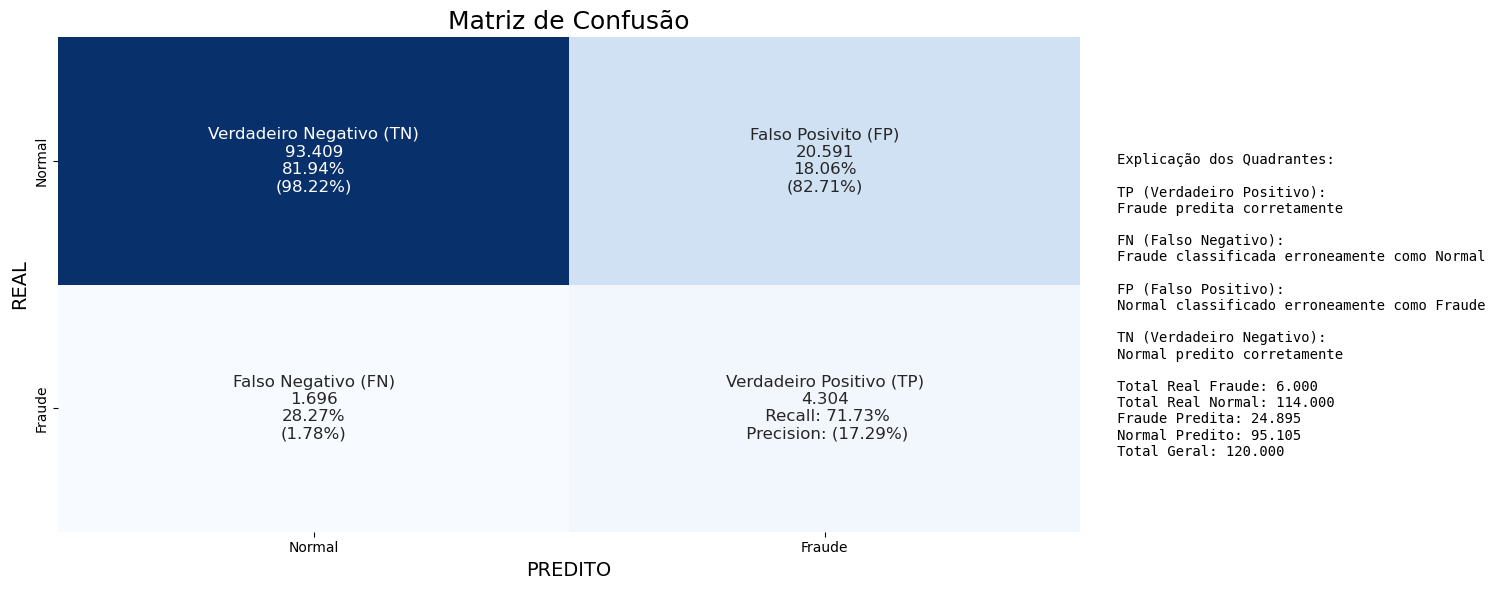

In [677]:
matriz_confusao(dt_poly, x_train_poly, y_train_poly)

**Matriz de Confusão da base de Teste**

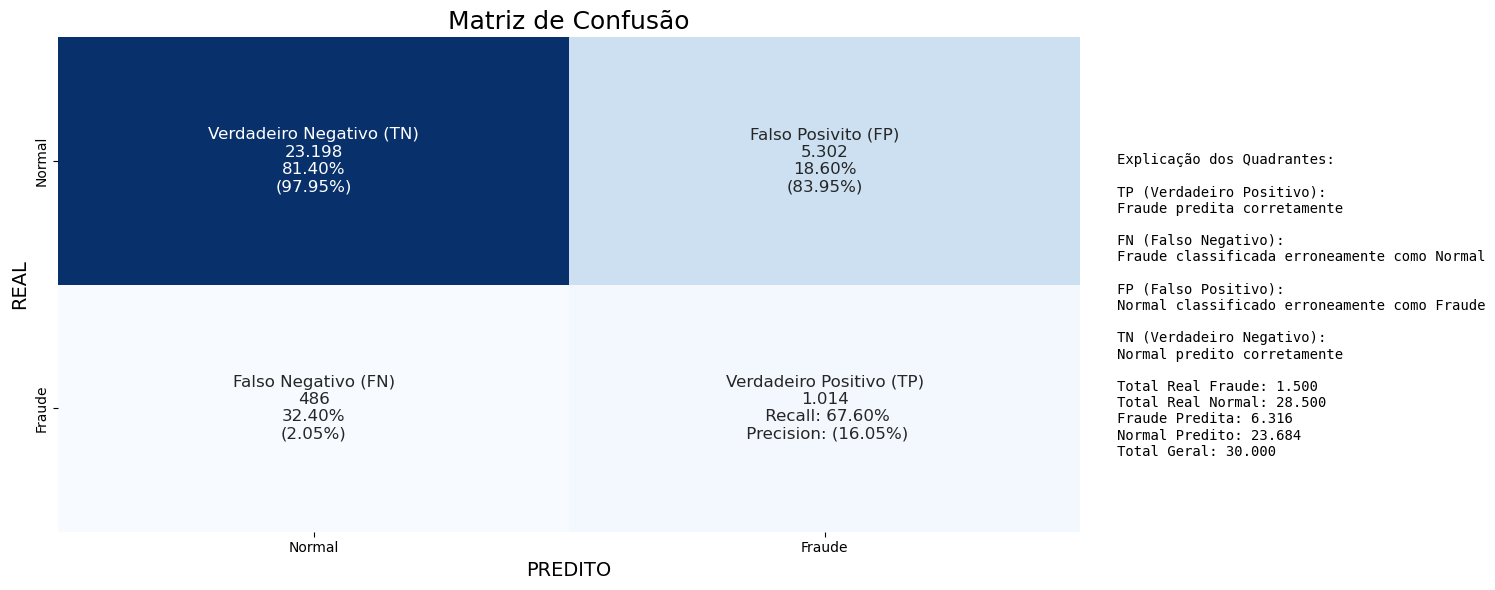

In [679]:
matriz_confusao(dt_poly, x_test_poly, y_test_poly)

- Nota-se que a inclusão de features polinomais não acrescentou performance, mas isso pode ter acontecido porque Árvores de Decisão não são muito sensíveis a essas técnicas. Outros algoritmos, como Regressão Logística, SVM e Redes Neurais são mais beneficiados por esse tipo de técnica.
  
- Assim, vamos comparar a performance de Regressão Logística com e sem as Features Polinomiais e verificar se o desempenho irá melhorar.

**Instanciando o Modelo**

In [705]:
reg_log_poly = LogisticRegression(
    solver="saga",        
    max_iter=100,         
    n_jobs=-1,            
    penalty="l2",         
    class_weight='balanced',
    verbose=2,            
    warm_start=False,      
    random_state=42
)

**Treinando o Modelo na base de Treino**

In [707]:
reg_log_poly.fit(x_train_poly, y_train_poly)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


max_iter reached after 23 seconds


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


**Desempenho do Modelo**

In [709]:
desempenho_reg_log_poly=calcula_desempenho(reg_log_poly,x_train_poly, y_train_poly, x_test_poly, y_test_poly)

In [871]:
desempenho_reg_log_poly

,Treino,Teste,Variação%
Acurácia,46.46%,45.81%,-1.39%
AUROC,79.66%,78.55%,-1.39%
Precision,7.96%,7.76%,-2.59%
Recall,91.97%,90.33%,-1.78%
F1,14.66%,14.29%,-2.53%
F2,29.58%,28.87%,-2.38%


**Matriz de Confusão da base de Treino**

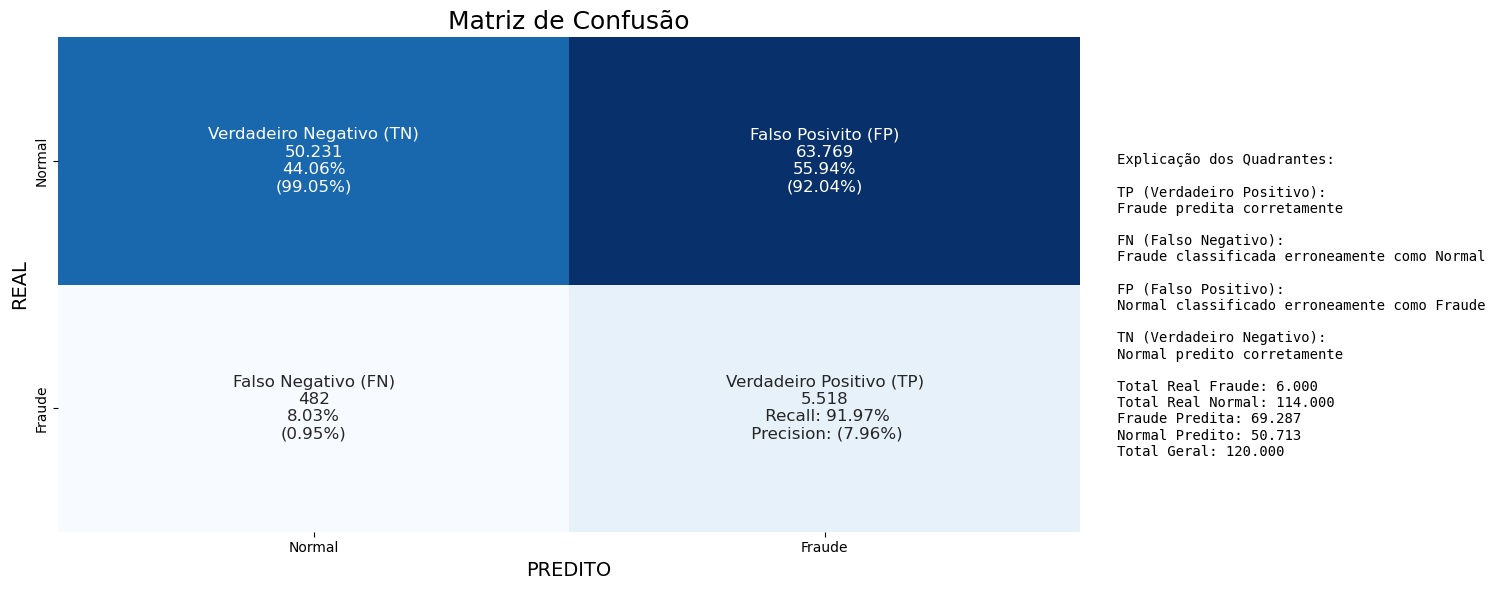

In [712]:
matriz_confusao(reg_log_poly,x_train_poly, y_train_poly)

**Matriz de Confusão da base de Teste**

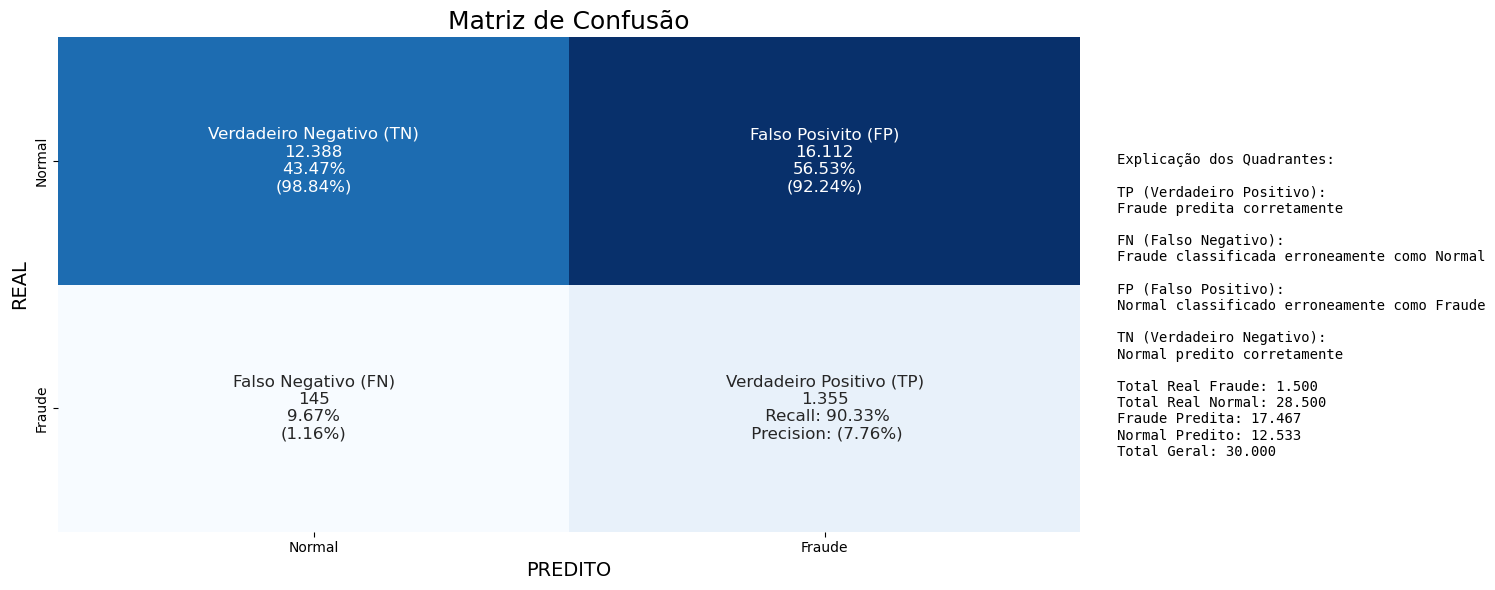

In [714]:
matriz_confusao(reg_log_poly,x_test_poly, y_test_poly)

- Apesar de o F2-Score ter piorado com a adição de features polinomiais, o Recall aumentou bastante.

- Assim, uma vez que as features irão passar por um processo de seleção rigoroso (método Boruta) e uma vez que algumas dessas features polinomiais podem capturar padrões importantes a depender do Modelo de Machine Learning, iremos manter essas features para passarem pelo processo de feature selection. 

## Feature Selection

Feature Selection é a etapa em que são eliminadas features menos importantes para o Modelo de Machine Learning.

Alguns possíveis benefícios do Feature Selection:

- Modelos com menos features tendem a **generalizar melhor** (reduz o overfitting, ou seja, reduz a chance de o modelo performar bem só na base de treinamento).
  
- Redução do **tempo de processamento**.

- Em alguns casos, especialmente em modelos supervisionados, **é possível verificar melhora de índices de performance na predição do modelo** com a redução de features.

- **Redução da Maldição da Dimensionalidade**, que afeta especialmente modelos baseados em distância.

### Boruta

O Boruta é um método de feature selection que trabalha com várias etapas:

1) O Boruta utiliza todas as variáveis (features) do conjunto de dados.
  
2) Em seguida, ele cria Variáveis Shadow. **Variável Shadow é uma cópia da variável original, mas com as linhas embaralhadas**.

3) Saímos de um modelo com n variáveis originais e passamos a ter 2n variáveis, considerando as cópias embaralhadas (shadow).

4) Daí, **treinamos um modelo de Machine Learning que possua o cálculo intrínseco de feature importance (importância de variável)**, como uma Random Forest, XGBoost, etc.

5) É calculada a feature importance de cada uma das variáveis, com relação ao Target.

6) O Boruta grava a feature importance da variável shadow que apresentou a maior feature importance.

7) Daí, o Boruta **compara a feature importance de cada variável original** com a da variável shadow que apresentou a maior feature importance.

8) Então, o Boruta cria uma tabela onde, para cada variável original, ele anota 1 se a importância da variável for maior que a da Variável Shadow com maior importância, e 0 caso contrário. Essa tabela representa os “casos de sucesso” da variável original.

9) O embaralhamento das linhas das variáveis shadow e as etapas seguintes são repetidos várias vezes a fim de preencher essa tabela de casos de sucesso **(padrão do Boruta são 100 iterações)**.

10) Com essas informações, podemos traçar uma distribuição estatística binomial e calcular o p-valor de cada uma das variáveis.

11) **Se o p-valor da variável for menor que um determinado Nível de Significância, essa variável será considerada como importante pelo Boruta**. Nível de Significância padrão do Boruta: 1%.

- Obs: Mesmo que uma feature já esteja “confirmada” ou "rejeitada", ela ainda entra na algorítmo que é executado na iteração seguinte. Mas essa feature "confirmada" ou "rejeitada" não é reavaliada estatisticamente na iteração seguinte.


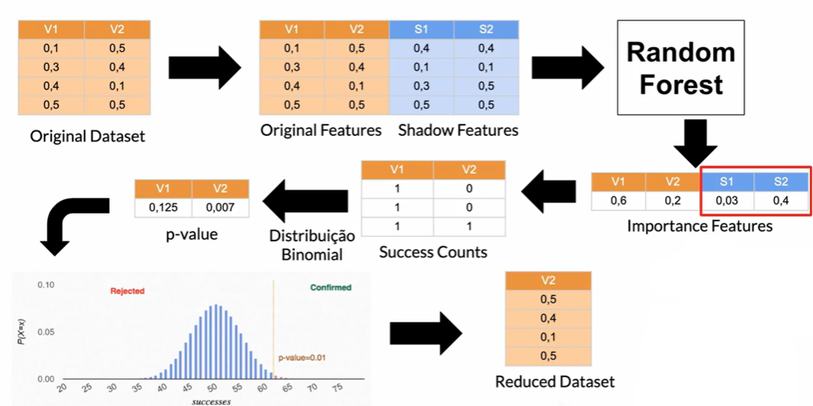

In [172]:

path = "Boruta.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

#### Utilizando o XGBoost como modelo base para o Boruta

- Para o método Boruta, nós não passamos um DataFrame, mas sim um array. **Por isso, executamos o .values:**

In [101]:
x_train_boruta_xgb = x_train_poly.values
y_train_boruta_xgb = y_train_poly.values

In [103]:
y_train_boruta_xgb

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

- Iremos utilizar o XGBoost como Modelo Base para o Boruta estabelecer a importância de cada variável. Mas, **como a base é desbalanceada** (temos muito mais dados de transação normal do que dados de fraude) é importante que o XGBoost lide com esse desbalanceamento da melhor forma pois, caso contrário, **ele tenderá a priorizar a classe majoritária na sua classificação**. Ele possui o parâmetro scale_pos_weight para ajustar o peso da classe positiva (1: dados de fraude) em relação à classe negativa (0: transação normal) na função de custo do algoritmo.

- Assim, o XGBoost dará mais peso ao erro cometido em relação à classificação das fraudes.

- scale_pos_weight = N_pos / N_neg

    - N_pos = número de amostras da classe 1 (fraude)
    - N_neg = número de amostras da classe 0 (normal)

**Se o scale_pos_weight der 13, por exemplo, o XGBoost irá tratar erros quanto à previsão da fraude como sendo 13 vezes mais grave do que erro quanto à previsão dos dados normais.** 

In [105]:
normal_count = np.sum(y_train_boruta_xgb == 0)
attack_count = np.sum(y_train_boruta_xgb == 1)
scale_pos_weight = normal_count / attack_count
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 19.00


- Criando o modelo XGBoost que irá servir ao Boruta:

In [107]:
xgb_boruta = XGBClassifier(n_estimators=100,
                    learning_rate=0.1,
                    objective='binary:logistic',
                    scale_pos_weight=scale_pos_weight,
                    random_state=42,
                    n_jobs=-1,
                    use_label_encoder=False,
                    eval_metric='logloss')

- Configurando o Boruta que utilizará o XGBoost:

In [126]:
boruta_xgb = BorutaPy(estimator=xgb_boruta,
                      n_estimators='auto',
                      verbose=2,
                      random_state=42,
                      max_iter=400
                      )

- Executando o Boruta:

In [129]:
boruta_xgb.fit(x_train_boruta_xgb, y_train_boruta_xgb)

Iteration: 	1 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	2 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	3 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	4 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	5 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	6 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	7 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	8 / 400
Confirmed: 	0
Tentative: 	33
Rejected: 	121
Iteration: 	9 / 400
Confirmed: 	10
Tentative: 	23
Rejected: 	121
Iteration: 	10 / 400
Confirmed: 	10
Tentative: 	23
Rejected: 	121
Iteration: 	11 / 400
Confirmed: 	10
Tentative: 	23
Rejected: 	121
Iteration: 	12 / 400
Confirmed: 	12
Tentative: 	16
Rejected: 	126
Iteration: 	13 / 400
Confirmed: 	12
Tentative: 	16
Rejected: 	126
Iteration: 	14 / 400
Confirmed: 	12
Tentative: 	16
Rejected: 	126
Iteration: 	15 / 400
Confirmed: 	12
Tentative: 	16
Rejected: 	126
Iteration: 	16 / 400
Confirmed: 	1

,estimator,"XGBClassifier...ree=None, ...)"
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,400
,random_state,RandomState(M... 0x1EF25DD3840
,verbose,2
,early_stopping,False
,n_iter_no_change,20
,objective,'binary:logistic'


In [131]:
selected_features_boruta_xgb = x_train_poly.columns[boruta_xgb.support_].tolist()

In [133]:
print("\n Features selecionadas com XGBoost + Boruta:")
for feat in selected_features_boruta_xgb:
    print(f"- {feat}")


 Features selecionadas com XGBoost + Boruta:
- score_6
- score_9
- score_10
- entrega_doc_2
- doc_2_vazio
- pais
- categoria_produto
- entrega_doc_3
- score_1 entrega_doc_1
- score_1 entrega_doc_3
- score_6 score_10
- score_6 entrega_doc_1
- score_6 entrega_doc_2
- score_7 score_10
- score_7 entrega_doc_1
- score_9 entrega_doc_1
- score_9 entrega_doc_2
- score_9 entrega_doc_3
- score_10 entrega_doc_1
- entrega_doc_1 entrega_doc_2
- entrega_doc_1 entrega_doc_3
- entrega_doc_2 valor_compra
- entrega_doc_2 doc_2_vazio


#### Utilizando a Regressão Logística como modelo base para o Boruta

- Como vimos anteriormente, os modelos que são da família das Árvores de Decisão (o XGBoost é um deles) tendem a dar baixa importância para features polinomiais.
  
- Após a seleção de features, vamos treinar uma série de Modelos de Machine Learning. E nem todos eles serão da família de Árvores de Decisão.

- Assim, para que modelos que não são da família de Árvores de Decisão possam ser beneficiados com features que possam agregar performance, iremos também fazer a seleção de features através da metodologia Boruta, mas de forma que o Boruta utilize uma Regressão Logística para cálculo da importância das features. A Regressão Logística tenderá a também dar importância para features polinomiais.

- Por fim, será considerada a união das features que foram apontadas como importantes pelo Boruta servido pelo XGBoost com as features que foram apontadas como importantes pelo Boruta servivo pela Regressão Logística.

- Ao fazer isso, a intenção é que sejam selecionadas features que possam agregar performance tanto para modelos de Machine Learning da família das Árvores de Decisão quanto para modelos de Machine Learning que não são da família das Árvores de Decisão.

In [135]:
x_train_boruta_lr = x_train_poly.values
y_train_boruta_lr = y_train_poly.values

In [159]:
from sklearn.model_selection import StratifiedShuffleSplit
# 1) Criar amostra estratificada de 100 mil linhas
# ===============================
n_sample = 100_000
sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sample, random_state=42)

idx_train, _ = next(sss.split(x_train_poly, y_train_poly))

X_sample = x_train_poly.iloc[idx_train].values
y_sample = y_train_poly.iloc[idx_train].values

print(f"Amostra gerada: {X_sample.shape[0]} linhas, proporção de 1s = {y_sample.mean():.4f}")

Amostra gerada: 100000 linhas, proporção de 1s = 0.0500


In [163]:
# 2) Criar wrapper para LogReg compatível com Boruta
# ===============================
class LogisticRegressionBoruta(LogisticRegression):
    def __init__(self,
                 penalty="l2",
                 dual=False,
                 tol=1e-4,
                 C=1.0,
                 fit_intercept=True,
                 intercept_scaling=1,
                 class_weight="balanced",
                 random_state=None,
                 solver="saga",
                 max_iter=100,
                 multi_class="auto",
                 verbose=0,
                 warm_start=False,
                 n_jobs=-1,
                 l1_ratio=None,
                 n_estimators=None  
                 ):
        super().__init__(penalty=penalty,
                         dual=dual,
                         tol=tol,
                         C=C,
                         fit_intercept=fit_intercept,
                         intercept_scaling=intercept_scaling,
                         class_weight=class_weight,
                         random_state=random_state,
                         solver=solver,
                         max_iter=max_iter,
                         multi_class=multi_class,
                         verbose=verbose,
                         warm_start=warm_start,
                         n_jobs=n_jobs,
                         l1_ratio=l1_ratio)
        self.n_estimators = n_estimators  

    @property
    def feature_importances_(self):
        # Importâncias = valor absoluto dos coeficientes
        return np.abs(self.coef_).ravel()

In [164]:
log_reg_boruta = LogisticRegressionBoruta(
    penalty='l2',
    solver='saga',
    max_iter=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

In [167]:
boruta_lr = BorutaPy(
    estimator=log_reg_boruta,
    n_estimators='auto',
    verbose=2,
    random_state=42,
    max_iter=400
)

In [169]:
boruta_lr.fit(X_sample, y_sample)

Iteration: 	1 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	2 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	3 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	4 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	5 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	6 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	7 / 400
Confirmed: 	0
Tentative: 	154
Rejected: 	0
Iteration: 	8 / 400
Confirmed: 	22
Tentative: 	11
Rejected: 	121
Iteration: 	9 / 400
Confirmed: 	22
Tentative: 	11
Rejected: 	121
Iteration: 	10 / 400
Confirmed: 	22
Tentative: 	11
Rejected: 	121
Iteration: 	11 / 400
Confirmed: 	22
Tentative: 	11
Rejected: 	121
Iteration: 	12 / 400
Confirmed: 	22
Tentative: 	11
Rejected: 	121
Iteration: 	13 / 400
Confirmed: 	22
Tentative: 	11
Rejected: 	121
Iteration: 	14 / 400
Confirmed: 	22
Tentative: 	11
Rejected: 	121
Iteration: 	15 / 400
Confirmed: 	22
Tentative: 	11
Rejected: 	121
Iteration: 	16 / 400
Confirmed: 	

,estimator,LogisticRegre...0x1F00E2E7540)
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,400
,random_state,RandomState(M... 0x1F00E2E7540
,verbose,2
,early_stopping,False
,n_iter_no_change,20
,penalty,'l2'


In [174]:
selected_features_boruta_lr = x_train_poly.columns[boruta_lr.support_].tolist()
print("\n Features selecionadas com Boruta + Regressão Logística:")
for feat in selected_features_boruta_lr:
    print(f"- {feat}")


 Features selecionadas com Boruta + Regressão Logística:
- score_1
- score_2
- score_4
- score_9
- score_10
- entrega_doc_1
- valor_compra
- doc_2_vazio
- pais
- categoria_produto
- score_1_kmeans
- score_2_kmeans
- score_9_kmeans
- score_10_kmeans
- entrega_doc_1_kmeans
- doc_2_vazio_kmeans
- pais_kmeans
- categoria_produto_kmeans
- score_1 score_2
- score_1 score_7
- score_1 entrega_doc_2
- score_1 valor_compra
- score_2^2
- score_4 score_9
- score_7 valor_compra
- score_9 score_10
- score_10 entrega_doc_1
- entrega_doc_1^2
- entrega_doc_2 doc_2_vazio
- doc_2_vazio^2
- doc_2_vazio entrega_doc_3


In [176]:
selected_features_union = list(set(selected_features_boruta_lr) | set(selected_features_boruta_xgb))

print(f"Total de features únicas selecionadas nos métodos Boruta + XGBoost e Boruta + Regressão Logística: {len(selected_features_union)}")
for feat in selected_features_union:
    print(f"- {feat}")

Total de features únicas selecionadas nos métodos Boruta + XGBoost e Boruta + Regressão Logística: 47
- pais_kmeans
- score_9 entrega_doc_1
- entrega_doc_2 valor_compra
- valor_compra
- entrega_doc_1^2
- score_6
- score_9 entrega_doc_2
- score_10 entrega_doc_1
- entrega_doc_1 entrega_doc_2
- entrega_doc_1_kmeans
- entrega_doc_2 doc_2_vazio
- score_1 score_2
- score_10_kmeans
- score_1 valor_compra
- doc_2_vazio entrega_doc_3
- doc_2_vazio^2
- score_7 score_10
- score_7 entrega_doc_1
- score_9_kmeans
- pais
- categoria_produto_kmeans
- score_4 score_9
- doc_2_vazio
- entrega_doc_1 entrega_doc_3
- doc_2_vazio_kmeans
- score_1
- score_1 score_7
- score_1 entrega_doc_3
- score_9 entrega_doc_3
- score_9 score_10
- score_6 entrega_doc_2
- entrega_doc_2
- score_9
- score_10
- entrega_doc_1
- score_1_kmeans
- categoria_produto
- score_1 entrega_doc_2
- entrega_doc_3
- score_7 valor_compra
- score_6 entrega_doc_1
- score_2
- score_1 entrega_doc_1
- score_2_kmeans
- score_2^2
- score_6 score_10


In [725]:
selected_features_union

['pais_kmeans',
 'score_9 entrega_doc_1',
 'entrega_doc_2 valor_compra',
 'valor_compra',
 'entrega_doc_1^2',
 'score_6',
 'score_9 entrega_doc_2',
 'score_10 entrega_doc_1',
 'entrega_doc_1 entrega_doc_2',
 'entrega_doc_1_kmeans',
 'entrega_doc_2 doc_2_vazio',
 'score_1 score_2',
 'score_10_kmeans',
 'score_1 valor_compra',
 'doc_2_vazio entrega_doc_3',
 'doc_2_vazio^2',
 'score_7 score_10',
 'score_7 entrega_doc_1',
 'score_9_kmeans',
 'pais',
 'categoria_produto_kmeans',
 'score_4 score_9',
 'doc_2_vazio',
 'entrega_doc_1 entrega_doc_3',
 'doc_2_vazio_kmeans',
 'score_1',
 'score_1 score_7',
 'score_1 entrega_doc_3',
 'score_9 entrega_doc_3',
 'score_9 score_10',
 'score_6 entrega_doc_2',
 'entrega_doc_2',
 'score_9',
 'score_10',
 'entrega_doc_1',
 'score_1_kmeans',
 'categoria_produto',
 'score_1 entrega_doc_2',
 'entrega_doc_3',
 'score_7 valor_compra',
 'score_6 entrega_doc_1',
 'score_2',
 'score_1 entrega_doc_1',
 'score_2_kmeans',
 'score_2^2',
 'score_6 score_10',
 'score_4'

In [727]:
x_train_selected = x_train_poly[selected_features_union]

In [728]:
x_train_selected.head()

,pais_kmeans,score_9 entrega_doc_1,entrega_doc_2 valor_compra,valor_compra,entrega_doc_1^2,score_6,score_9 entrega_doc_2,score_10 entrega_doc_1,entrega_doc_1 entrega_doc_2,entrega_doc_1_kmeans,entrega_doc_2 doc_2_vazio,score_1 score_2,score_10_kmeans,score_1 valor_compra,doc_2_vazio entrega_doc_3,doc_2_vazio^2,score_7 score_10,score_7 entrega_doc_1,score_9_kmeans,pais,categoria_produto_kmeans,score_4 score_9,doc_2_vazio,entrega_doc_1 entrega_doc_3,doc_2_vazio_kmeans,score_1,score_1 score_7,score_1 entrega_doc_3,score_9 entrega_doc_3,score_9 score_10,score_6 entrega_doc_2,entrega_doc_2,score_9,score_10,entrega_doc_1,score_1_kmeans,categoria_produto,score_1 entrega_doc_2,entrega_doc_3,score_7 valor_compra,score_6 entrega_doc_1,score_2,score_1 entrega_doc_1,score_2_kmeans,score_2^2,score_6 score_10,score_4
40222,0.578209,0.155948,0.011536,-0.026376,0.107205,-0.055092,-0.208308,-0.121596,-0.143200,0.327422,-0.268673,0.223981,-0.5817,-0.010295,0.685945,0.377379,-0.126438,0.111474,1.361972,0.561067,-1.060194,-0.491449,0.614312,0.365602,0.614312,0.390311,0.132885,0.435824,0.531830,-0.176883,0.024095,-0.437355,0.476291,-0.371375,0.327422,0.390311,-0.944594,-0.170705,1.116608,-0.008980,-0.018038,0.573852,0.127796,0.514945,0.329306,0.020460,-1.031826
113835,0.578209,0.624667,-0.878247,-0.384106,0.107205,-0.057803,4.362203,0.776105,0.748640,0.327422,-3.722002,0.284222,1.7191,-0.149921,1.457843,2.649857,-2.375109,-0.328079,1.361972,0.561067,0.814348,-0.161107,-1.627838,-0.293229,-1.627838,0.390311,-0.391094,-0.349551,-1.708598,4.522238,-0.132166,2.286469,1.907833,2.370353,0.327422,0.390311,0.930493,0.892434,-0.895570,0.384877,-0.018926,0.728193,0.127796,0.514945,0.530265,-0.137015,-0.084445
67288,0.578209,0.158625,0.095400,-0.218129,0.107205,-0.025264,-0.211885,-0.100174,-0.143200,0.327422,-0.268673,-0.125397,-0.5817,-0.085138,-0.550159,0.377379,0.090391,-0.096736,1.361972,0.561067,0.814348,0.055716,0.614312,-0.293229,0.614312,0.390311,-0.115316,-0.349551,-0.433875,-0.148222,0.011049,-0.437355,0.484468,-0.305948,0.327422,0.390311,0.504898,-0.170705,-0.895570,0.064445,-0.008272,-0.321274,0.127796,0.514945,0.103217,0.007729,0.115004
118571,0.578209,4.005629,0.059570,-0.136205,9.327911,-0.070006,0.573605,2.314169,1.335755,-3.054163,-0.268673,0.196642,-0.5817,-0.053162,0.685945,0.377379,0.491546,1.981316,-0.734230,0.561067,0.814348,1.157084,0.614312,-3.410301,0.614312,0.390311,-0.253205,0.435824,-1.464465,0.993760,0.030617,-0.437355,-1.311531,-0.757710,-3.054163,0.390311,1.328450,-0.170705,1.116608,0.088360,0.213809,0.503808,-1.192073,0.514945,0.253823,0.053044,-0.882239
5463,-0.169902,-2.260961,0.117310,-0.268225,9.327911,-0.063227,-0.323769,2.666244,1.335755,-3.054163,0.711944,-0.872867,-0.5817,-0.104691,-1.817656,2.649857,-0.975716,-3.413563,1.361972,-0.049307,0.814348,-0.505462,-1.627838,-3.410301,-1.627838,0.390311,0.436241,0.435824,0.826611,-0.646262,0.027653,-0.437355,0.740288,-0.872987,-3.054163,0.390311,0.679554,-0.170705,1.116608,-0.299788,0.193105,-2.236338,-1.192073,-1.941953,5.001208,0.055196,-0.682791


In [729]:
x_train_selected.shape

(120000, 47)

In [730]:
x_test_selected = x_test_poly[selected_features_union]

In [731]:
x_test_selected.head()

,pais_kmeans,score_9 entrega_doc_1,entrega_doc_2 valor_compra,valor_compra,entrega_doc_1^2,score_6,score_9 entrega_doc_2,score_10 entrega_doc_1,entrega_doc_1 entrega_doc_2,entrega_doc_1_kmeans,entrega_doc_2 doc_2_vazio,score_1 score_2,score_10_kmeans,score_1 valor_compra,doc_2_vazio entrega_doc_3,doc_2_vazio^2,score_7 score_10,score_7 entrega_doc_1,score_9_kmeans,pais,categoria_produto_kmeans,score_4 score_9,doc_2_vazio,entrega_doc_1 entrega_doc_3,doc_2_vazio_kmeans,score_1,score_1 score_7,score_1 entrega_doc_3,score_9 entrega_doc_3,score_9 score_10,score_6 entrega_doc_2,entrega_doc_2,score_9,score_10,entrega_doc_1,score_1_kmeans,categoria_produto,score_1 entrega_doc_2,entrega_doc_3,score_7 valor_compra,score_6 entrega_doc_1,score_2,score_1 entrega_doc_1,score_2_kmeans,score_2^2,score_6 score_10,score_4
22325,0.578209,0.635376,0.093537,-0.213871,0.107205,-0.042889,-0.848706,0.011019,-0.14320,0.327422,-0.268673,0.234350,-0.5817,-0.083476,-0.550159,0.377379,0.042368,0.412220,1.361972,0.561067,-1.060194,-0.647666,0.614312,-0.293229,0.614312,0.390311,0.491397,-0.349551,-1.737890,0.065304,0.018758,-0.437355,1.940541,0.033653,0.327422,0.390311,-0.944594,-0.170705,-0.895570,-0.269260,-0.014043,0.600418,0.127796,0.514945,0.360502,-0.001443,-0.333756
7970,0.578209,-0.333233,0.027171,-0.062127,0.107205,-0.068650,0.445117,0.042642,-0.14320,0.327422,0.711944,0.201203,-0.5817,-0.024249,1.457843,2.649857,-0.084488,-0.212407,-0.734230,0.561067,0.814348,-0.015551,-1.627838,-0.293229,-1.627838,0.390311,-0.253205,-0.349551,0.911463,-0.132547,0.030024,-0.437355,-1.017746,0.130236,0.327422,0.390311,0.504898,-0.170705,-0.895570,0.040303,-0.022478,0.515495,0.127796,0.514945,0.265735,-0.008941,0.015279
47378,0.578209,0.251183,-0.785230,-0.343424,0.107205,0.030325,1.754077,-0.213407,0.74864,0.327422,-3.722002,0.294865,-0.5817,-0.134042,1.457843,2.649857,0.008357,-0.004198,1.361972,0.561067,0.814348,-0.753318,-1.627838,-0.293229,-1.627838,0.390311,-0.005004,-0.349551,-0.687041,-0.500016,0.069338,2.286469,0.767155,-0.651779,0.327422,0.390311,0.338213,0.892434,-0.895570,0.004403,0.009929,0.755462,0.127796,0.514945,0.570723,-0.019765,-0.981963
37537,0.578209,0.390212,0.150689,-0.344545,0.107205,-0.045601,-0.521227,0.002858,-0.14320,0.327422,-0.268673,0.143121,-0.5817,-0.134480,-0.550159,0.377379,0.014688,0.551026,1.361972,0.561067,-1.060194,0.790724,0.614312,-0.293229,0.614312,0.390311,0.656864,-0.349551,-1.067313,0.010402,0.019944,-0.437355,1.191770,0.008728,0.327422,0.390311,-0.944594,-0.170705,-0.895570,-0.579843,-0.014931,0.366684,0.127796,0.514945,0.134457,-0.000398,0.663487
40722,0.578209,0.335710,0.703307,0.307595,0.107205,-0.055092,2.344344,-0.221568,0.74864,0.327422,-3.722002,0.081389,-0.5817,0.120058,-1.817656,2.649857,-0.278203,0.134608,1.361972,0.561067,-1.060194,-0.188831,-1.627838,0.365602,-1.627838,0.390311,0.160463,0.435824,1.144871,-0.693833,-0.125966,2.286469,1.025312,-0.676704,0.327422,0.390311,-0.944594,0.892434,1.116608,0.126457,-0.018038,0.208524,0.127796,0.514945,0.043482,0.037281,-0.184169


In [732]:
x_test_selected.shape

(30000, 47)

## Estimando Modelos Supervisionados

### Regressão Logística

- Regressão Logística é um algoritmo de Machine Learning que possui o funcionamento similar a uma Regressão Linear, mas que passa por algumas transformações para tratar de problemas de Classificação (como é o nosso caso).
  
- Ele inicia como uma Regressão Linear:

    - z=β0​+β1​x1​+β2​x2​+⋯+βn​xn​
      
    - Onde z é a combinação linear entre as variáveis (features)
      
- Mas, uma Regressão Linear pode resultar em qualquer número (de -∞ a +∞). Entretanto, para problemas de Classificação, precisamos de algo que pareça uma probabilidade (um valor entre 0 e 1).

- Para resolver isso, usamos a Função Logística (Sigmoide). Ela transforma qualquer valor para valores entre 0 e 1:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

O resultado 

$$
\hat{y} = \sigma(z)
$$

pode ser lido como a **probabilidade do exemplo pertencer à classe 1**.

Se 
$$
\hat{y} > 0.5
$$ 
classificamos como **classe 1**.

Se 
$$
\hat{y} \leq 0.5
$$ 
classificamos como **classe 0**.

- Esse 0,5 é padrão para a Regressão Logística e também para todos os outros algoritmos de Machine Learning que lidam com problema de Classificação. Ele é conhecido como **Threshold (ou Limiar)** e pode ser ajustado para maximizar alguma medida de qualidade do Modelo (como Recall, Precion, F1 Score, AUC ROC, etc).
  
- O Modelo ajusta os valores de 
𝛽0
,
𝛽1
,
…para maximizar a verossimilhança dos dados. Ou seja, ele escolhe os betas que melhor explicam as probabilidades observadas das classes. Isso é feito utilizando métodos de **otimização como o Gradiente Descendente** (o método "saga", que estamos utilizando, é uma variação do Gradiente Descendente que é mais eficiente no processo de treinamento de bases muito grandes)

**Instanciando o Modelo**

In [741]:
reg_logistica = LogisticRegression(
    solver="saga",        
    max_iter=100,         
    n_jobs=-1,            
    penalty="l2",         
    class_weight='balanced', 
    verbose=1,            
    warm_start=True,        
    random_state=42
)

**Treinando o Modelo na base de Treino**

In [743]:
reg_logistica.fit(x_train_selected, y_train_poly)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


max_iter reached after 10 seconds


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


**Threshold (ou Limiar)**

- Todos os Modelos de Machine Learning que se propõem a resolver um problema de Classificação **usarão um Threshold (ou Limiar) padrão de 50%**. Ou seja, **se a probabilidade calculada pelo Modelo de que uma determinada observação pertença à classe 1 for maior ou igual a 50%, o Modelo irá prever que essa observação será da classe 1**. Se a probabilidade calculada pelo Modelo de que uma determinada observação pertença à classe 1 for menor que 50%, o Modelo irá prever que essa observação será da classe 0.
  
- Mas podemos ser **mais flexiveis com esse Threshold (ou Limiar)**. Por exemplo, posso mudar o Threshold de forma que, se a probabilidade calculada pelo Modelo de que uma observação é uma fraude for de 40%, por exemplo, o Modelo já considerará aquela observação como uma fraude. **Isso mudará a quantidade de observações classificadas em cada Classe e alterará também as minhas medidas de avaliação do Modelo de Machine Learning** (Recall, Precision, F1 Score, AUC ROC, etc). Podemos também considear o Threshold acima de 50%.

- **Se eu defino o Threshold abaixo dos 50%, eu tendo a melhorar o Recall do Modelo**. Isso acontece porque ao considerar, por exemplo, um Threshold de 30%, eu passarei a considerar mais registros como fraude, porque agora todas as observações com 30% ou mais de serem uma fraude eu irei considerar como um fraude (anteriormente ela teria que ter uma probabilidade de pelo menos 50%). Assim, o Modelo considerando mais observações como fraude, ele tende a acertar mais as fraudes efetivas.

- **Por outro lado, se eu defino o Threshold abaixo dos 50%, eu tendo a piorar Precision do Modelo**. Isso acontece porque ao fazer isso, o Modelo passará a gerar uma lista maior de previsões de observações que considerará como fraude. Isso fará com que a precisão de acerto das *previsões* que o Modelo faz reduza, por gerar um maior número de falsos positivos (aumento a quantidade de alarme falso).

- Ou seja, **existe um trade-off entre Precision e Recall**.

- Assim sendo, **é possivel plotar uma Curva de Precision VS Recall para diferente níveis Thresholds (Limiares)**.
  
- Ou seja, plotar uma curva que mostra, para cada nível de Threshold (Limiares), qual será o Precision e qual será o seu respectivo Recall. 

**Calculando as probabilidades de Precision e Recall e a Curva Precision-Recall**

In [748]:
y_pred_proba_rl = reg_logistica.predict_proba(x_test_selected)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_poly, y_pred_proba_rl)

**Plotando o Gráfico da Curva Precision-Recall**

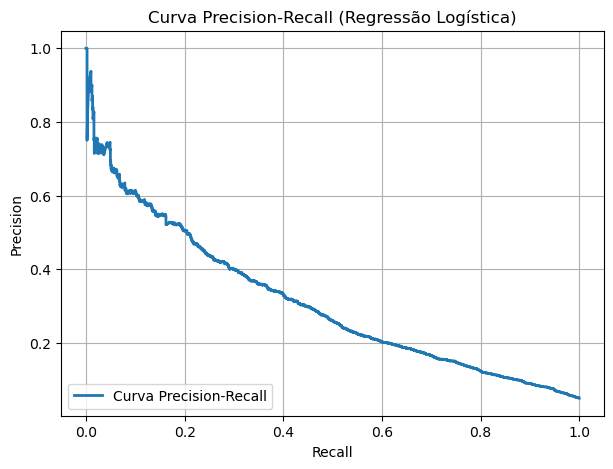

In [750]:
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label="Curva Precision-Recall", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall (Regressão Logística)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

**Escolha do melhor Threshold (Limiar)**

- Uma vez que, para cada nível de Threshold (Limiar) teremos um Precision e um respectivo Recall, **podemos escolher o Threshold que maximize alguma métrica de avaliação do desempenho do nosso Modelo de Machine Learning**.
  
- Uma vez que estamos partindo do pressuposto que o o custo da fraude é superior ao custo de oportunidade de um Precision baixo, iremos escolher a métrica que prioriza a capacidade de o Modelo identificar o máximo de fraudes (alto Recall), mas tentando minimizar o tamanho da lista de Falsos Positivos (alto Precision). **Ou seja, iremos escolher o Threshold (Limiar) que *maximize* o F2 Score, que é a média harmônica entre o Precision e o Recall, dando 4 vezes mais peso para o Recall do que para o Precision (β= 2 e β²= 4)**. Uma métrica que também poderia ser utilizada como referência para a escolha do Threshold, que traria resultados parecidos ao F2 Score, seria o AUC que, quanto maior, menor serão tanto os Falsos Positivos quanto os Falsos Negativos.

- O próprio sklearn possui um método de escolha do Threshold que maximiza a métrica que se pretende maximizar. **Esse método é o TunedThresholdClassifierCV**.

**Desempenho do Modelo**

In [754]:
desempenho_reg_logistica=calcula_desempenho(reg_logistica, x_train_selected, y_train_poly, x_test_selected, y_test_poly)

In [755]:
desempenho_reg_logistica

,Treino,Teste,Variação%
Acurácia,77.86%,77.71%,-0.19%
AUROC,84.87%,83.49%,-1.62%
Precision,15.45%,15.07%,-2.45%
Recall,76.65%,74.60%,-2.67%
F1,25.72%,25.08%,-2.49%
F2,42.77%,41.68%,-2.55%


**Matriz de Confusão da base de Treino**

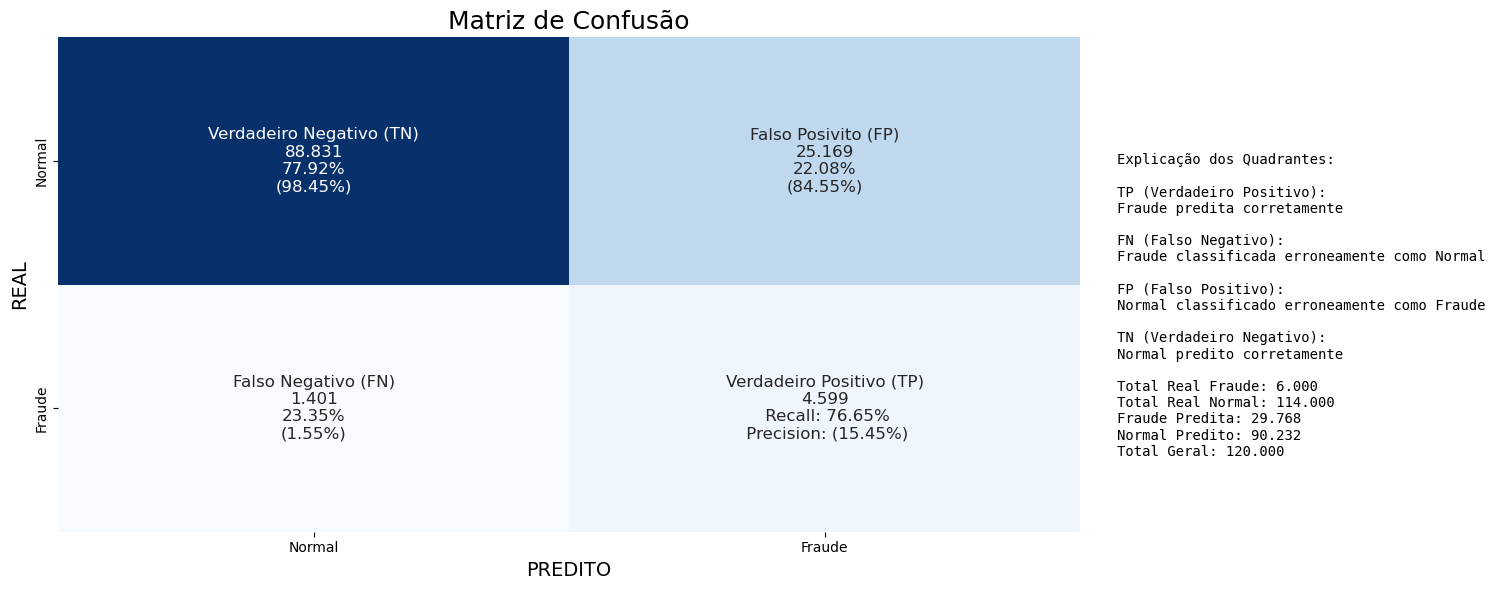

In [762]:
matriz_confusao(reg_logistica, x_train_selected, y_train_poly)

**Matriz de Confusão da base de Teste**

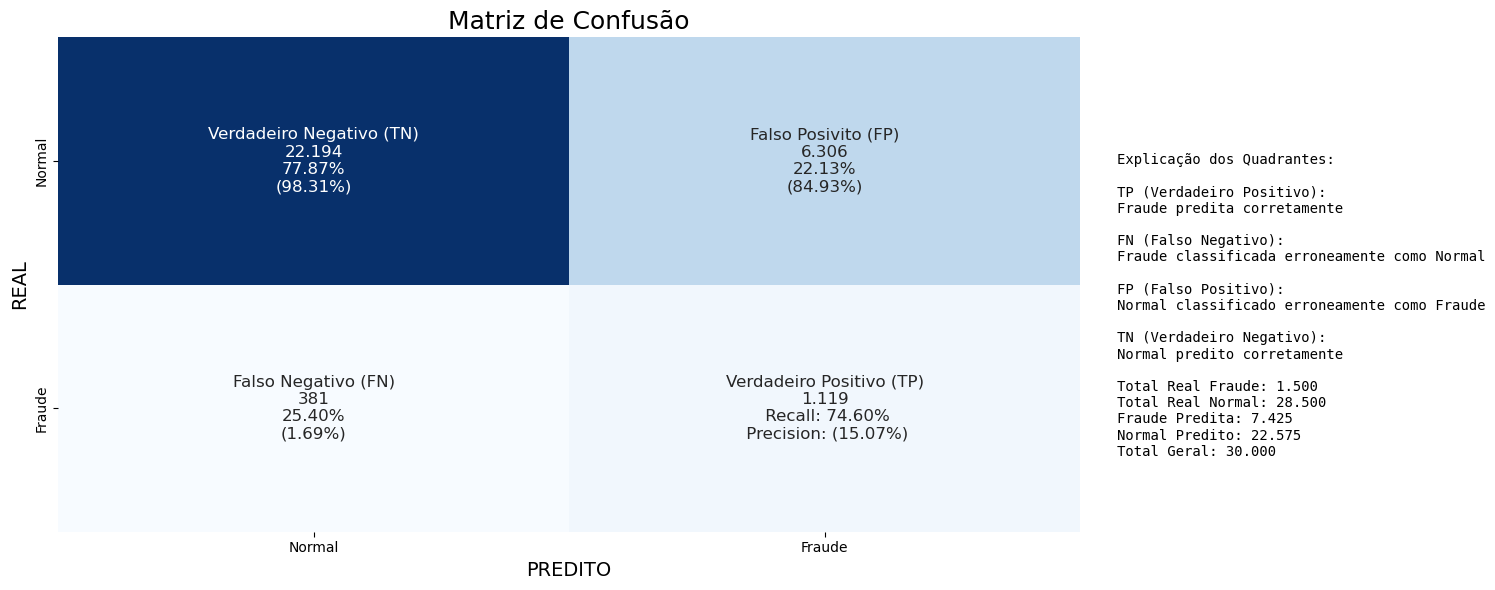

In [764]:
matriz_confusao(reg_logistica, x_test_selected, y_test_poly)

#### Tunagem de Hiperparâmetros

- Cada Modelo de Machine Learning possui diversos hiperparâmetros que podem assumir diversos valores/configurações. Assim, podemos chegar a uma **configuração de valores para cada um dos hiperparâmetros de cada Modelo que busque maximizar alguma métrica de desempenho do Modelo (como F2 Score, ou Recall, ou Precision, ou F1 Score, ou AUC ROC, etc)**. O processo para encontrar essa configuração se chama Tunagem de Hiperparâmetros.
  
- Existem 3 principais maneiras de tunar hiperparâmetros:

  - **Grid Search**: Nesse método, construímos um Modelo de Machine Learning para cada combinação possível de todos os valores de hiperparâmetros que nós fornecemos para ele testar, avaliamos cada Modelo e selecionamos aquela combinação que produz os melhores resultados. Ex: tunando um Modelo com 2 hiperparâmetros: número de estimadores (n_estimators) e a profundidade máxima (max_depth). Considerando que vamos testar, para o número de estimadores, os valores 10, 50, 100 e 200 e para a profundidade máxima, 3, 10, 20 e 40. Como temos 4 opções para o n_estimators e 4 para o max_depth, temos 4*4 = 16 combinações possíveis. Logo, treinarmos 16 Modelos diferentes. Dependendo do nº de hiperparâmetros e de possibilidades de valores para cada hiperparâmetro, pode ser muito custoso computacionalmente.
    
  - **Random Search**: Ao invés de passarmos uma lista fechada de valores para cada hiperparâmetro, definimos uma distribuição possível para cada um e o método seleciona, aleatoriamente, um valor de cada distribuição para fazer os testes.
 
  - **Bayesian Search**:  Usa a informação de um experimento para aprimorar o próximo. Ao invés de olhar para cada configuração de hiperparâmetros individualmente, ela considera a performance de todas as configurações testadas até o momento para fazer uma escolha mais informada sobre qual configuração testar a seguir. Ou seja, após fazer uma tentativa de ajuste de configuração de hiperparâmetros, o processo irá realizar um cálculo de probabilidade para testar novos valores de hiperparâmetros com mais chance estatística de melhorar a métrica de referência (F2 Score, por exemplo) obtido na tentativa anterior.

- Uma vez que o **Bayesian Search é mais performático, usaremos esse método para tunar os hiperparâmetros**.

- Usaremos a **biblioteca Optuna**, que utiliza Bayesian Search, para realizar a tunagem de hiperparâmetros.

**Função objetivo que será utilizada pelo Optuna para testar os vários hiperparâmetros**

In [767]:
def objective_reg(trial):
    # Hiperparâmetros a tunar
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    C = trial.suggest_float("C", 1e-2, 100.0, log=True)
    max_iter = trial.suggest_int("max_iter", 50, 120, step=10)
    
    l1_ratio = None
    if penalty == "elasticnet":
        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)
    
    # Instanciar Regressão Logística
    reg_logistica = LogisticRegression(
        solver="saga",
        penalty=penalty,
        C=C,
        l1_ratio=l1_ratio,
        max_iter=max_iter,
        class_weight="balanced",      
        n_jobs=-1,
        warm_start=True,
        random_state=42
    )
    
    # Criar o scorer F2
    f2_scorer = make_scorer(fbeta_score, beta=2)
    
    # Envolver no Threshold Tuning com F2
    reg_tt_clf = TunedThresholdClassifierCV(
        estimator=reg_logistica,
        scoring=f2_scorer,  
        cv=2
    )
    
    # Cross-validation com F2 como métrica
    scores = cross_val_score(
        reg_tt_clf,
        x_train_selected,
        y_train_poly,
        cv=2,
        scoring=f2_scorer,  
        n_jobs=-1
    )
    return scores.mean()

**Rodando a otimização que procurará os melhores hiperparâmetros que otimize o indicador-alvo**

In [769]:
study_reg_log = optuna.create_study(direction="maximize")  
study_reg_log.optimize(objective_reg, n_trials=50, n_jobs=-1)

print("Melhores hiperparâmetros encontrados:")
print(study_reg_log.best_params)
print("Melhor indicador obtido:", study_reg_log.best_value)

[I 2025-10-30 10:32:39,925] A new study created in memory with name: no-name-6a1da6d3-833b-46a2-a8d6-6204d78b52c4
[I 2025-10-30 10:33:28,339] Trial 1 finished with value: 0.4439902826968341 and parameters: {'penalty': 'elasticnet', 'C': 14.081036630751397, 'max_iter': 60, 'l1_ratio': 0.09849066818000529}. Best is trial 1 with value: 0.4439902826968341.
[I 2025-10-30 10:33:31,765] Trial 0 finished with value: 0.4457716686830454 and parameters: {'penalty': 'l2', 'C': 1.94097959424362, 'max_iter': 100}. Best is trial 0 with value: 0.4457716686830454.
[I 2025-10-30 10:33:34,484] Trial 9 finished with value: 0.4459406812413445 and parameters: {'penalty': 'l2', 'C': 1.3416308110713562, 'max_iter': 80}. Best is trial 9 with value: 0.4459406812413445.
[I 2025-10-30 10:33:37,266] Trial 3 finished with value: 0.44327140173488067 and parameters: {'penalty': 'l2', 'C': 5.449644963850542, 'max_iter': 110}. Best is trial 9 with value: 0.4459406812413445.
[I 2025-10-30 10:33:40,992] Trial 4 finished 

Melhores hiperparâmetros encontrados:
{'penalty': 'l2', 'C': 2.961739448911484, 'max_iter': 80}
Melhor indicador obtido: 0.4460270035912429


**Instanciando o Modelo final já com os hiperparâmetros que tunam (otimizam) o indicador-alvo**

In [772]:
reg_log_tunado = LogisticRegression(
    solver="saga",
    **{k: v for k, v in study_reg_log.best_params.items() if k != "l1_ratio"},
    l1_ratio=study_reg_log.best_params.get("l1_ratio", None),
    class_weight="balanced",
    n_jobs=-1,
    warm_start=True,
    random_state=42
)

In [773]:
f2_scorer = make_scorer(fbeta_score, beta=2)

**Envolvendo o Modelo no Threshold Tuning que maximiza o indicador-alvo**

In [775]:
reg_log_tunado_tt_clf = TunedThresholdClassifierCV(
    estimator=reg_log_tunado,
    scoring=f2_scorer,
    cv=2
)

**Treinando o Modelo Tunado na base de Treino**

In [777]:
reg_log_tunado_tt_clf.fit(x_train_selected, y_train_poly)

,estimator,LogisticRegre...rm_start=True)
,scoring,"make_scorer(f...dict', beta=2)"
,response_method,'auto'
,thresholds,100
,cv,2
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,penalty,'l2'
,dual,False


In [778]:
desempenho_reg_log_tunado_tt_clf=calcula_desempenho(reg_log_tunado_tt_clf, x_train_selected, y_train_poly, x_test_selected, y_test_poly)


>>> Melhor threshold encontrado: 0.6465



In [779]:
desempenho_reg_log_tunado_tt_clf

,Treino,Teste,Variação%
Acurácia,86.46%,86.06%,-0.47%
AUROC,84.86%,83.48%,-1.63%
Precision,21.07%,20.18%,-4.21%
Recall,62.17%,60.53%,-2.63%
F1,31.47%,30.27%,-3.81%
F2,44.72%,43.24%,-3.30%


### SVM (Support Vector Machine)

- SVM (Support Vector Machine) é um Modelo de Machine Learning cujo objetivo é encontrar um hiperplano (Fronteira de Decisão) que melhor separa as classes em um espaço de dimensões das features.
  
- O SVM busca o hiperplano (Fronteira de Decisão) que maximiza a margem, ou seja, a distância, entre o registro (ponto) mais próximo de cada classe.

- Esse registro (ponto) mais próximo de cada classe em relação à Fronteira de Decisão é conhecido como support vector e são eles que realmente definem a posição da fronteira.


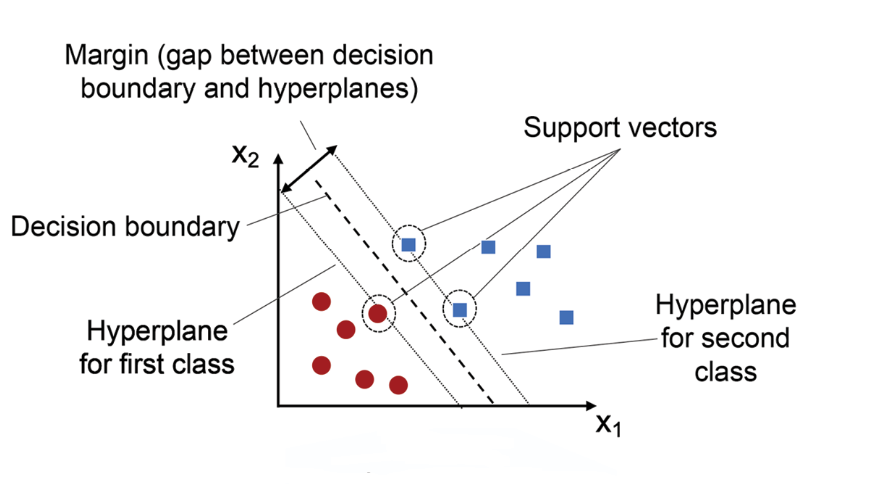

In [79]:

path = "SVM.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

- Quando o problema não pode ser linearmente separado, é possível trabalhar com **Kernel Trick** que consiste em incluir os dados em espaços multidimensionais (com muitas dimensões) para que seja possível separá-las linearmente. O problema é que o Kernel Trick deixa o processo muito mais exigente computacionalmente. Assim, estamos trabalhandos apenas com o SVM Linear.

In [790]:
X_train_svm, X_val_svm, y_train_svm, y_val_svm = train_test_split(
    x_train_selected, 
    y_train_poly, 
    test_size=0.2, 
    stratify=y_train_poly, 
    random_state=42
)

**Instanciando o Modelo**

In [792]:
svm = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=200,    
    dual=True,       
    random_state=42
)

**Treinando o modelo na base de Treino**

In [794]:
svm.fit(x_train_selected, y_train_poly)

,penalty,'l2'
,loss,'squared_hinge'
,dual,True
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


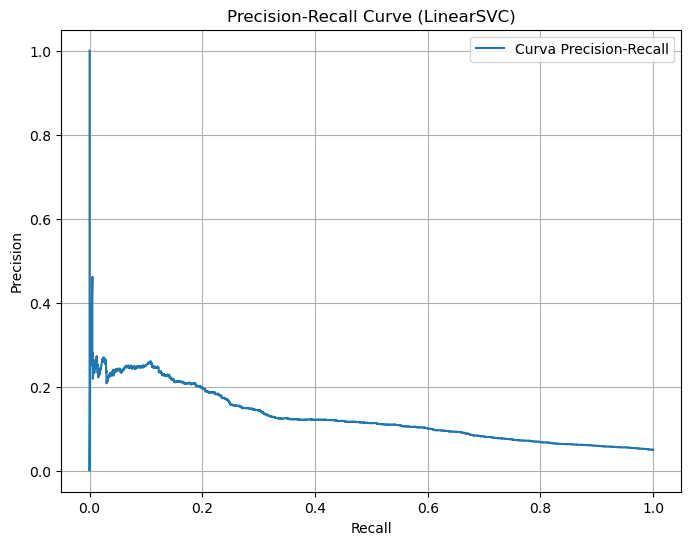

In [795]:
y_scores_val = svm.decision_function(X_val_svm)

precision, recall, thresholds = precision_recall_curve(y_val_svm, y_scores_val)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label="Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LinearSVC)")
plt.legend()
plt.grid(True)
plt.show()

**Desempenho do Modelo**

In [797]:
desempenho_svm=calcula_desempenho(svm, x_train_selected, y_train_poly, x_test_selected, y_test_poly)

In [798]:
desempenho_svm

,Treino,Teste,Variação%
Acurácia,89.56%,89.41%,-0.17%
AUROC,60.26%,59.31%,-1.57%
Precision,16.87%,15.81%,-6.26%
Recall,27.70%,25.87%,-6.62%
F1,20.97%,19.63%,-6.39%
F2,24.55%,22.95%,-6.51%


**Matriz de Confusão da base de Treino**

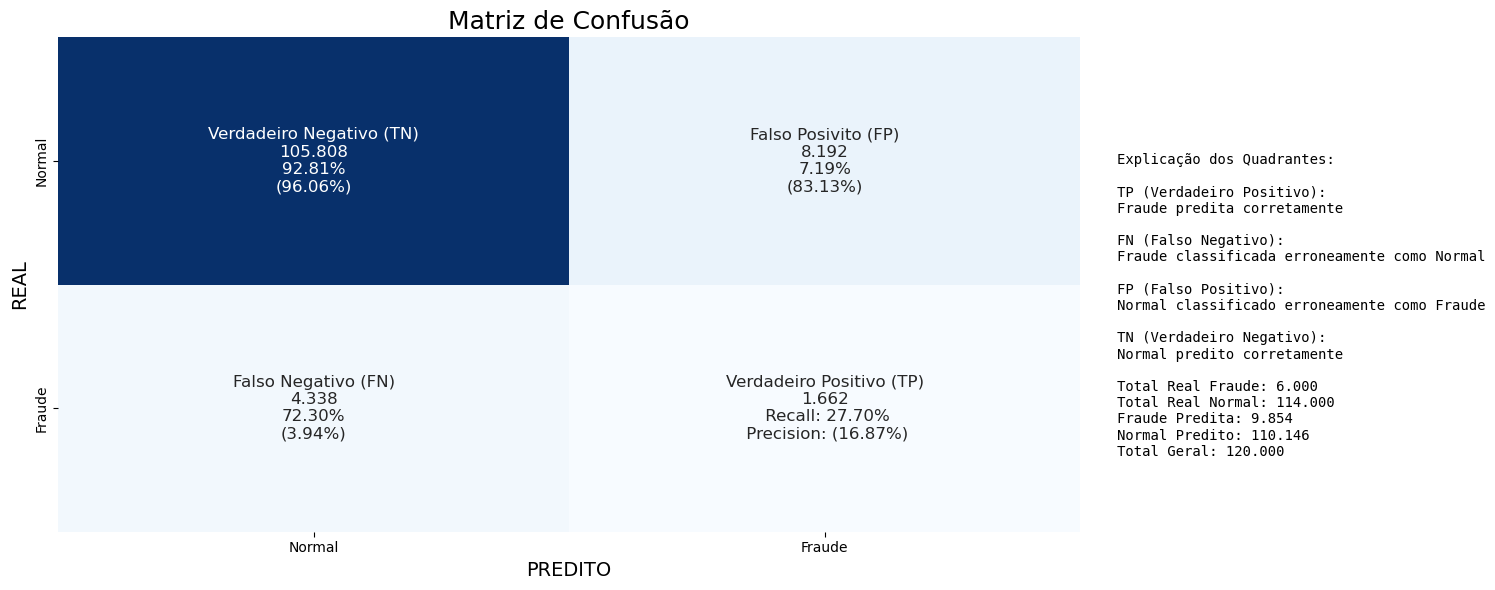

In [811]:
matriz_confusao(svm, x_train_selected, y_train_poly)

**Matriz de Confusão da base de Teste**

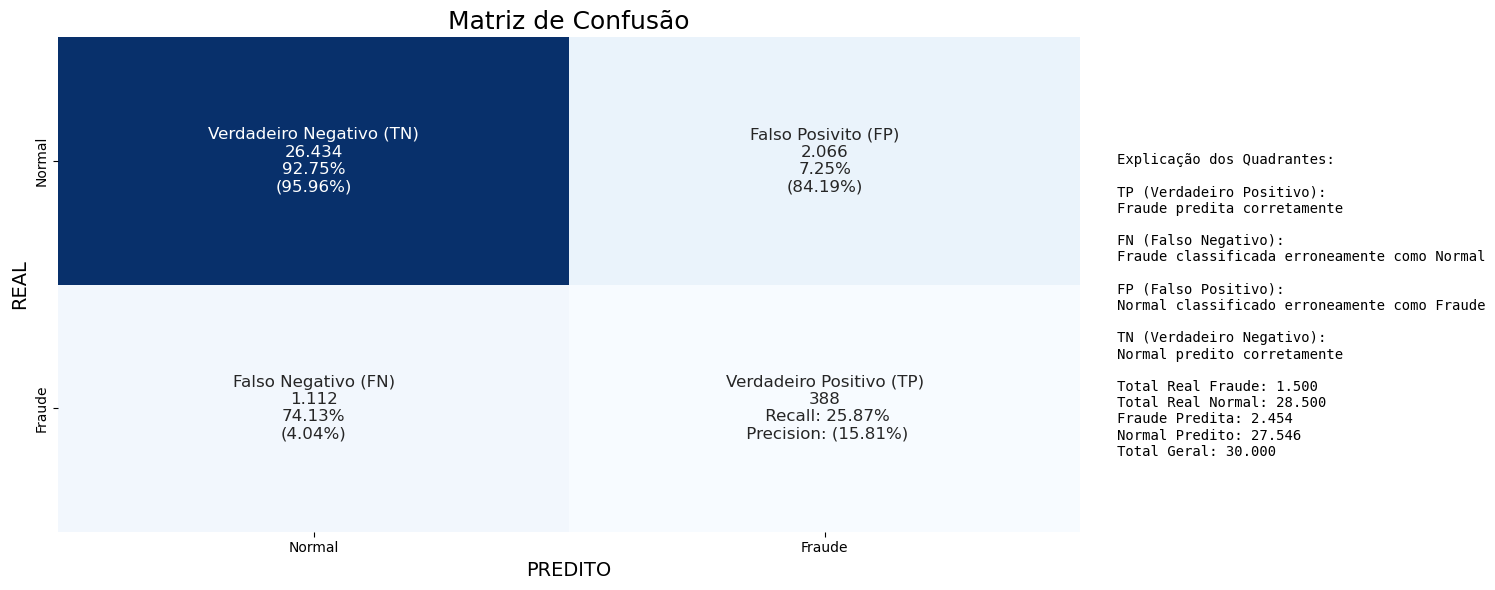

In [813]:
matriz_confusao(svm, x_test_selected, y_test_poly)

#### Tunagem de Hiperparâmetros

**Função objetivo que será utilizada pelo Optuna para testar os vários hiperparâmetros**

In [1098]:
f2_scorer = make_scorer(fbeta_score, beta=2)

def objective_svm(trial):
    C = trial.suggest_float("C", 1, 5.0)
    max_iter = trial.suggest_int("max_iter", 200, 5000, step=500)
    model = LinearSVC(
        C=C,
        class_weight='balanced',
        max_iter=max_iter,
        dual=True,
        random_state=42
    )
    # Threshold tuning com F2 score
    svm_tt_clf = TunedThresholdClassifierCV(
        estimator=model,
        scoring=f2_scorer, 
        cv=2
    )
    svm_tt_clf.fit(X_train_svm, y_train_svm)
    y_pred = svm_tt_clf.predict(X_val_svm)
    return fbeta_score(y_val_svm, y_pred, beta=2)

**Rodando a otimização que procurará os melhores hiperparâmetros que otimize o indicador-alvo**

In [1100]:
study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(objective_svm, n_trials=15)  
print("Melhores hiperparâmetros encontrados:")
print(study_svm.best_params)
print("Melhor F2 no conjunto de validação:", study_svm.best_value)

[I 2025-10-31 09:57:09,372] A new study created in memory with name: no-name-d420c5fb-1c17-42d6-879c-aa23f7fc017e
[I 2025-10-31 10:05:56,944] Trial 0 finished with value: 0.4052108823952785 and parameters: {'C': 2.50257009513765, 'max_iter': 2700}. Best is trial 0 with value: 0.4052108823952785.
[I 2025-10-31 10:18:47,227] Trial 1 finished with value: 0.3781639591990933 and parameters: {'C': 3.1121420407276217, 'max_iter': 3700}. Best is trial 0 with value: 0.4052108823952785.
[I 2025-10-31 10:31:34,018] Trial 2 finished with value: 0.34666203059805284 and parameters: {'C': 4.1106063040731975, 'max_iter': 3700}. Best is trial 0 with value: 0.4052108823952785.
[I 2025-10-31 10:41:28,078] Trial 3 finished with value: 0.3816707948660212 and parameters: {'C': 1.5548620436479776, 'max_iter': 4700}. Best is trial 0 with value: 0.4052108823952785.
[I 2025-10-31 10:43:04,812] Trial 4 finished with value: 0.41506605453012274 and parameters: {'C': 1.9003020235894161, 'max_iter': 1200}. Best is t

Melhores hiperparâmetros encontrados:
{'C': 1.0097506394414797, 'max_iter': 1700}
Melhor F2 no conjunto de validação: 0.4154676258992806


**Instanciando o Modelo final já com os hiperparâmetros que tunam (otimizam) o indicador-alvo**

In [820]:
svm_tunado = LinearSVC(
    **study_svm.best_params,
    class_weight='balanced',
    dual=True,
    random_state=42
)

**Envolvendo o Modelo no Threshold Tuning que maximiza o indicador-alvo**

In [1108]:
svm_tunado_tt_clf = TunedThresholdClassifierCV(
    estimator=svm_tunado,
    scoring=f2_scorer,  
    cv=2
)

**Treinando o Modelo Tunado na base de Treino**

In [1111]:
svm_tunado_tt_clf.fit(x_train_selected, y_train_poly)

,estimator,LinearSVC(C=1...ndom_state=42)
,scoring,"make_scorer(f...dict', beta=2)"
,response_method,'auto'
,thresholds,100
,cv,2
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,penalty,'l2'
,loss,'squared_hinge'


In [825]:
desempenho_svm_tunado_tt_clf=calcula_desempenho(svm_tunado_tt_clf, x_train_selected, y_train_poly, x_test_selected, y_test_poly)


>>> Melhor threshold encontrado: 0.3673



In [1113]:
desempenho_svm_tunado_tt_clf

,Treino,Teste,Variação%
Acurácia,89.26%,89.05%,-0.23%
AUROC,73.21%,71.72%,-2.03%
Precision,24.55%,23.44%,-4.53%
Recall,55.38%,52.47%,-5.27%
F1,34.02%,32.40%,-4.75%
F2,44.26%,42.05%,-5.00%


### Árvore de Decisão

- Árvore de Decisão é um algoritmo supervisionado que funcionar como um fluxograma de perguntas e respostas.
  
    - Cada nó interno da árvore representa uma condição (ex.: “idade > 30?”).
    
    - Cada ramo representa o resultado dessa condição (sim/não).
    
    - Cada folha representa a predição final (classe).
 
- O algoritmo escolhe uma feature (coluna da base de dados) e um determinado valor para ela que maximize, para os Nós filhos, a separação entre as classes (targets).

- Dito de outra forma, escolhe uma feature e o seu respectivo valor que minimize o grau de impureza dos nós filhos da Árvore, medido pelo Índice de Gini ou pela Entropia (se o Índice de Gini/Entropia for igual a zero, a impureza é mínima e indica que aquele nó separou totalmente uma classe de target em um nó).

- A Árvore de Decisão retorna a classe mais frequente naquela folha.


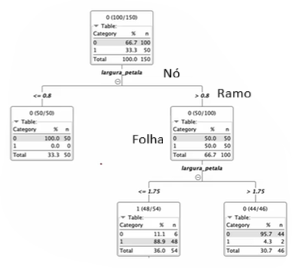

In [103]:

path = "Árvore_Decisão.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

**Instanciando o Modelo**

In [873]:
arvore_decisao = DecisionTreeClassifier(min_samples_leaf=2,
                                     max_depth=5,
                                     class_weight='balanced',    
                                     random_state=42)

**Treinando o modelo na base de Treino**

In [875]:
arvore_decisao.fit(x_train_selected, y_train_poly)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Desempenho do Modelo**

In [877]:
desempenho_arvore_decisao=calcula_desempenho(arvore_decisao, x_train_selected, y_train_poly, x_test_selected, y_test_poly)

In [878]:
desempenho_arvore_decisao

,Treino,Teste,Variação%
Acurácia,79.13%,78.53%,-0.75%
AUROC,84.72%,82.27%,-2.88%
Precision,15.86%,14.90%,-6.00%
Recall,73.72%,69.93%,-5.13%
F1,26.10%,24.57%,-5.85%
F2,42.62%,40.23%,-5.60%


**Matriz de Confusão da base de Treino**

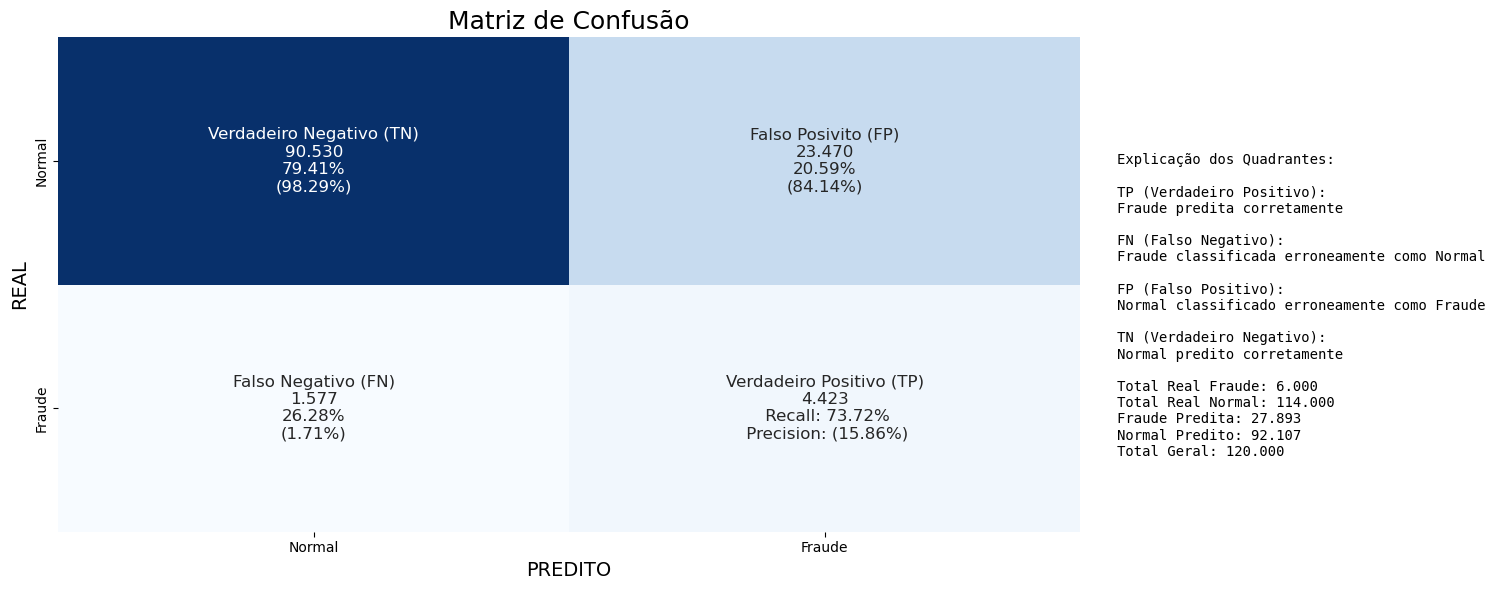

In [880]:
matriz_confusao(arvore_decisao, x_train_selected, y_train_poly)

**Matriz de Confusão da base de Teste**

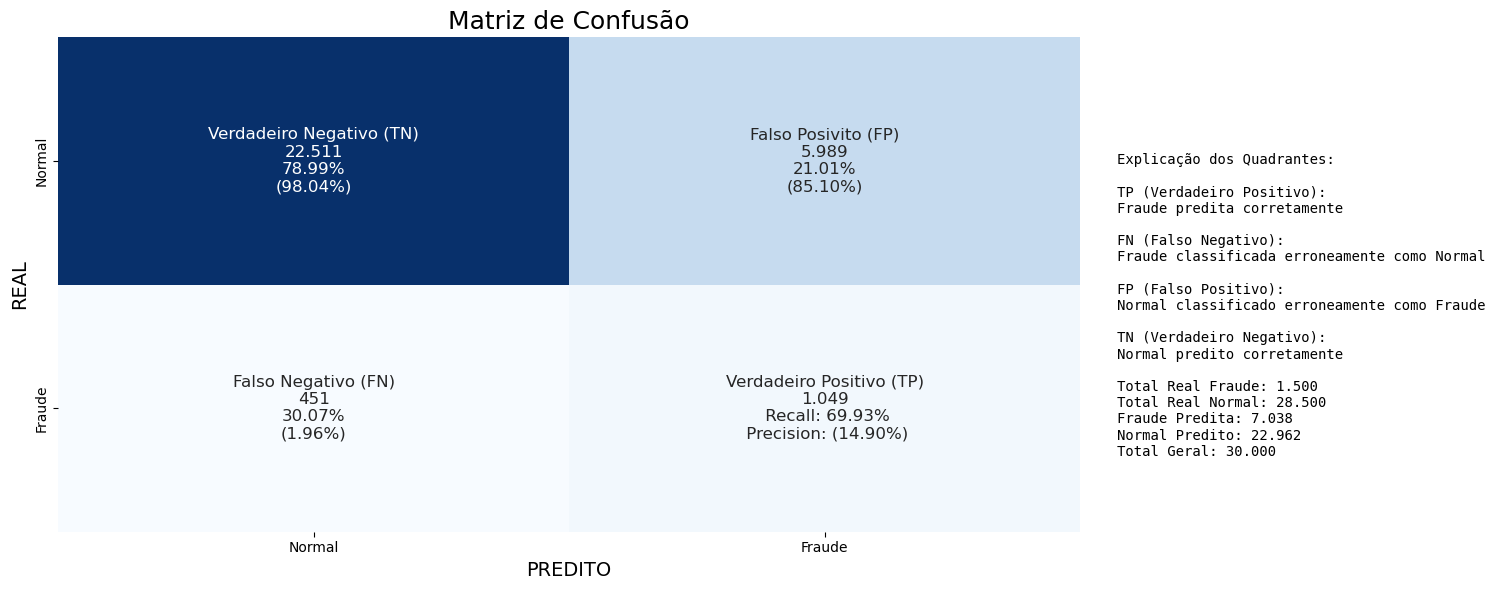

In [882]:
matriz_confusao(arvore_decisao, x_test_selected, y_test_poly)

**Calculando as probabilidades de Precision e Recall e a Curva Precision-Recall**

In [884]:
y_pred_proba_dt = arvore_decisao.predict_proba(x_test_selected)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_poly, y_pred_proba_dt)

**Plotando o Gráfico da Curva Precision-Recall**

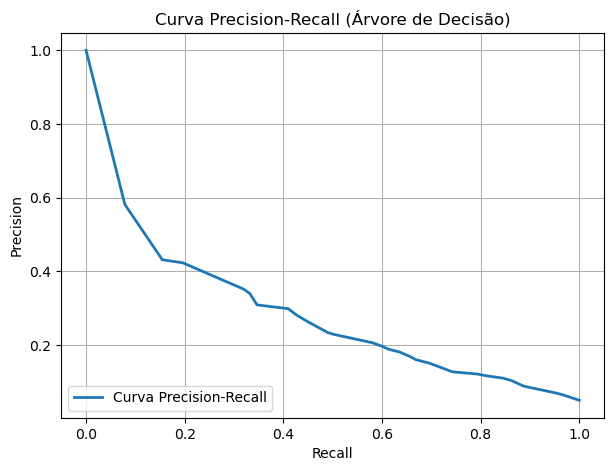

In [886]:
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label="Curva Precision-Recall", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall (Árvore de Decisão)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

#### Tunagem de Hiperparâmetros

**Função objetivo que será utilizada pelo Optuna para testar os vários hiperparâmetros**

In [889]:
# Função objetivo para o Optuna
# ===========================
def objective_dt(trial):
    # Sugerir hiperparâmetros
    max_depth = trial.suggest_int("max_depth", 2, 5)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 50)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 50)
    max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])
    splitter = trial.suggest_categorical("splitter", ["best", "random"])

    # Instanciar o modelo
    arvore = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion=criterion,
        splitter=splitter,
        class_weight="balanced",
        random_state=42
    )


    # Criar o scorer F2
    f2_scorer = make_scorer(fbeta_score, beta=2)
    
    
    # Envolver no Threshold Tuning
    arvore_tt_clf = TunedThresholdClassifierCV(
        estimator=arvore,
        scoring=f2_scorer,  
        cv=2
    )

    # Cross-validation usando f2 como métrica
    scores = cross_val_score(
        arvore_tt_clf,
        x_train_selected,
        y_train_poly,
        cv=2,
        scoring=f2_scorer,
        n_jobs=-1
    )

    return scores.mean()

**Rodando a otimização que procurará os melhores hiperparâmetros que otimize o indicador-alvo**

In [899]:
study_dt = optuna.create_study(direction="maximize")  
study_dt.optimize(objective_dt, n_trials=50, n_jobs=-1)

print("Melhores hiperparâmetros encontrados:")
print(study_dt.best_params)
print("Melhor indicador obtido:", study_dt.best_value)

[I 2025-10-30 12:01:36,310] A new study created in memory with name: no-name-606fac11-f4c9-4c26-bfd1-b67ebfa63557
[I 2025-10-30 12:01:48,517] Trial 4 finished with value: 0.36748925010119193 and parameters: {'max_depth': 2, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 'log2', 'criterion': 'gini', 'splitter': 'random'}. Best is trial 4 with value: 0.36748925010119193.
[I 2025-10-30 12:01:48,894] Trial 2 finished with value: 0.4239936906500617 and parameters: {'max_depth': 5, 'min_samples_split': 29, 'min_samples_leaf': 28, 'max_features': 'log2', 'criterion': 'entropy', 'splitter': 'best'}. Best is trial 2 with value: 0.4239936906500617.
[I 2025-10-30 12:01:52,389] Trial 11 finished with value: 0.3947484305012257 and parameters: {'max_depth': 3, 'min_samples_split': 32, 'min_samples_leaf': 5, 'max_features': None, 'criterion': 'entropy', 'splitter': 'random'}. Best is trial 2 with value: 0.4239936906500617.
[I 2025-10-30 12:01:52,408] Trial 8 finished with value: 0.40

Melhores hiperparâmetros encontrados:
{'max_depth': 5, 'min_samples_split': 12, 'min_samples_leaf': 44, 'max_features': None, 'criterion': 'gini', 'splitter': 'best'}
Melhor indicador obtido: 0.44445307693628644


**Instanciando o Modelo final já com os hiperparâmetros que tunam (otimizam) o indicador-alvo**

In [901]:
dt_tunado = DecisionTreeClassifier(
    **study_dt.best_params, 
    class_weight="balanced",
    random_state=42)

**Envolvendo o Modelo no Threshold Tuning que maximiza o indicador-alvo**

In [903]:
dt_tunado_tt_clf = TunedThresholdClassifierCV(
    estimator=dt_tunado,
    scoring=f2_scorer,
    cv=2
)

**Treinando o Modelo Tunado na base de Treino**

In [905]:
dt_tunado_tt_clf.fit(x_train_selected, y_train_poly)

,estimator,DecisionTreeC...ndom_state=42)
,scoring,"make_scorer(f...dict', beta=2)"
,response_method,'auto'
,thresholds,100
,cv,2
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,criterion,'gini'
,splitter,'best'


In [906]:
desempenho_dt_tunado_tt_clf=calcula_desempenho(dt_tunado_tt_clf, x_train_selected, y_train_poly, x_test_selected, y_test_poly)


>>> Melhor threshold encontrado: 0.6458



In [911]:
desempenho_dt_tunado_tt_clf

,Treino,Teste,Variação%
Acurácia,86.50%,85.74%,-0.88%
AUROC,84.72%,82.27%,-2.88%
Precision,21.40%,19.65%,-8.13%
Recall,63.58%,60.00%,-5.64%
F1,32.02%,29.61%,-7.52%
F2,45.60%,42.54%,-6.72%


### Random Forest

- O Random Forest é um algorítmo de Machine Learning que **utiliza o Método Enseble na estratégia de Bagging de Árvores de Decisão**. Isso quer dizer que, partindo de uma base de dados original, serão treinados várias Árvores de Decisão. Cada Árvore de Decisão terá acesso a algumas linhas da base original e, opcionalmente, uma parte das features (pode ser definido que cada Árvore de Decisão tenha acesso a todas as features da base original).
  
- **Ao criar Modelos que olham para partes do conjunto de dados, criamos modelos especialistas**. Cada um deles irá entender muito bem aquela amostra com escopo menor. Teremos vários modelos especialistas que serão combinados para gerar a estimativa final. Isso tende a melhorar a capacidade de generalização, porque o risco de overfitting diminui, já que cada modelo está olhando para uma parte da base.

- Para problemas de classificação, como é o nosso caso, o output final passa por um **processo de votação** entre todas as Árvores de Decisão. Exemplo: digamos que a Random Forest tenha 100 Árvores de Decisão. E que **dessas 100 Árvores, para 80 Árvores um determinado registro (linha do conjunto de dados) é previsto como tipo 1 e que para 20 Árvores esse registro é do tipo 0. Assim, por ser a classe mais frequente, para este registro a Random Forest irá prever que ela é do tipo 1.**

**Instanciando o Modelo**

In [918]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

**Treinando o Modelo na base de Treino**

In [920]:
rf.fit(x_train_selected, y_train_poly)

,n_estimators,200
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Calculando as probabilidades de Precision e Recall e a Curva Precision-Recall**

In [922]:
y_pred_proba_rf = rf.predict_proba(x_test_selected)[:, 1]
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test_poly, y_pred_proba_rf)

**Plotando o Gráfico da Curva Precision-Recall**

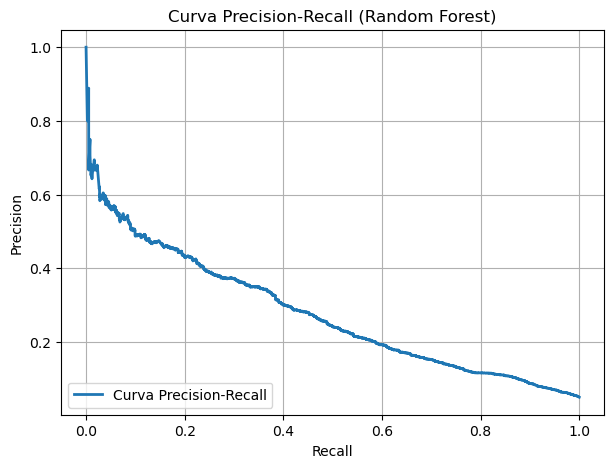

In [924]:
plt.figure(figsize=(7, 5))
plt.plot(recall_rf, precision_rf, label="Curva Precision-Recall", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall (Random Forest)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

**Desempenho do Modelo**

In [926]:
desempenho_rf=calcula_desempenho(rf, x_train_selected, y_train_poly, x_test_selected, y_test_poly)

In [927]:
desempenho_rf

,Treino,Teste,Variação%
Acurácia,73.54%,73.23%,-0.42%
AUROC,84.15%,82.67%,-1.77%
Precision,13.25%,12.91%,-2.56%
Recall,77.38%,75.80%,-2.05%
F1,22.63%,22.07%,-2.48%
F2,39.32%,38.40%,-2.35%


**Matriz de Confusão da base de Treino**

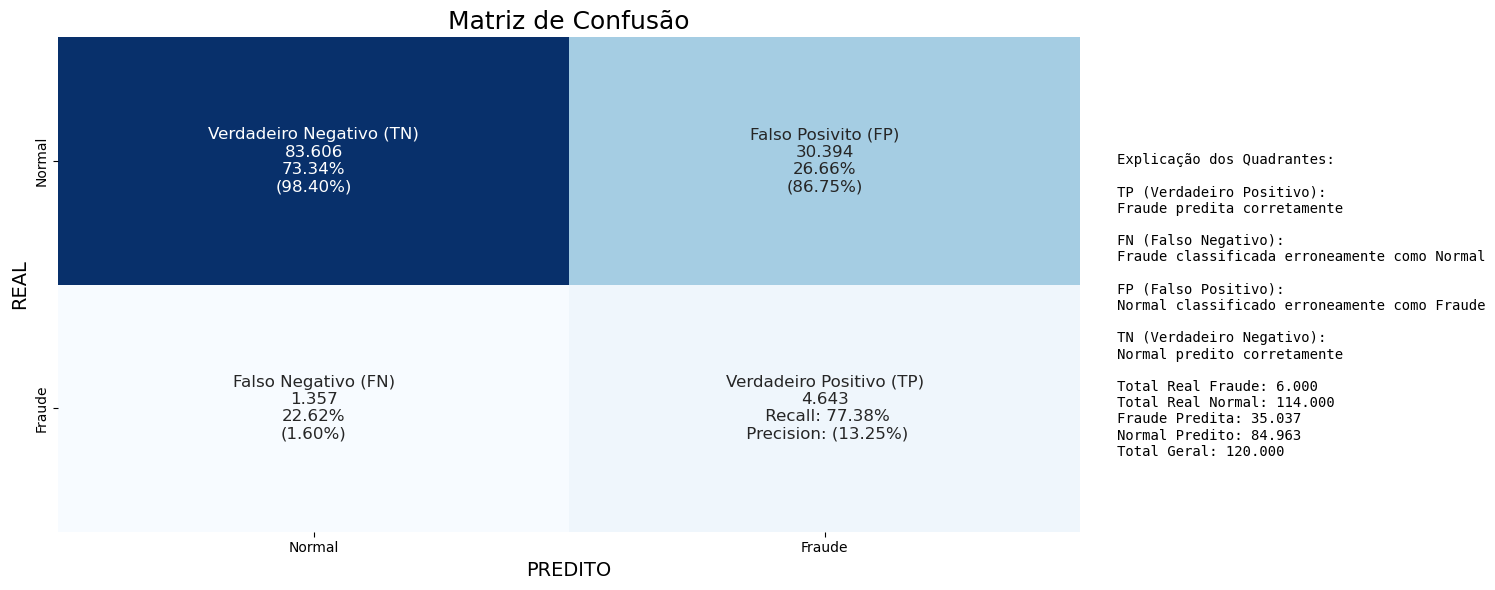

In [929]:
matriz_confusao(rf, x_train_selected, y_train_poly)

**Matriz de Confusão da base de Teste**

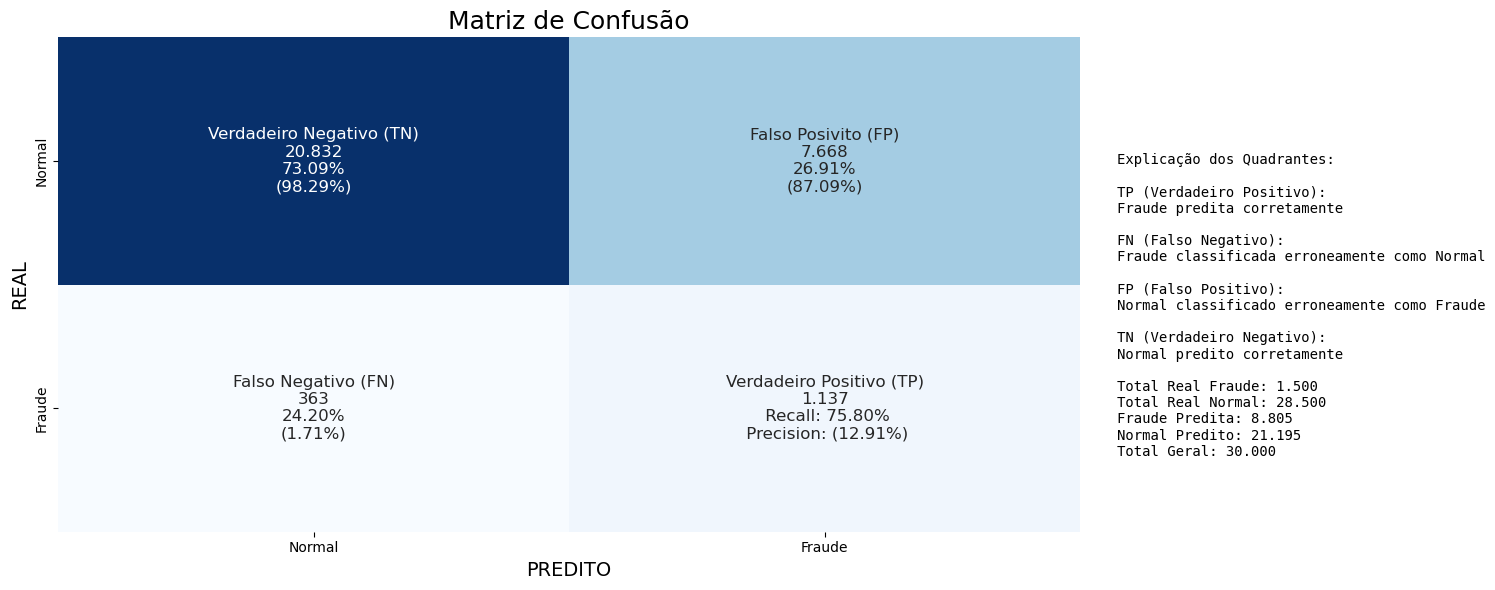

In [931]:
matriz_confusao(rf, x_test_selected, y_test_poly)

#### Tunagem de Hiperparâmetros

**Função objetivo que será utilizada pelo Optuna para testar os vários hiperparâmetros**

In [934]:
def objective_rf(trial):
    # Sugerir hiperparâmetros
    n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
    max_depth = trial.suggest_int("max_depth", 2, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
        

    # Instanciar o modelo
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        bootstrap=True,
        class_weight="balanced",
        random_state=42,
        n_jobs=6
    )

    # Criar o scorer F2
    f2_scorer = make_scorer(fbeta_score, beta=2)
    
    
    # Envolver no Threshold Tuning
    rf_tt_clf = TunedThresholdClassifierCV(
        estimator=rf,
        scoring=f2_scorer,  
        cv=2
    )

    # Cross-validation usando f1 como métrica
    scores = cross_val_score(
        rf_tt_clf,
        x_train_selected,
        y_train_poly,
        cv=2,
        scoring=f2_scorer,
        n_jobs=-1
    )

    return scores.mean()

**Rodando a otimização que procurará os melhores hiperparâmetros que otimize o indicador-alvo**

In [944]:
study_rf = optuna.create_study(direction="maximize")  
study_rf.optimize(objective_rf, n_trials=50, n_jobs=9)

print("Melhores hiperparâmetros encontrados:")
print(study_rf.best_params)
print("Melhor indicador obtido:", study_rf.best_value)

[I 2025-10-30 12:05:37,177] A new study created in memory with name: no-name-27b6dad4-4327-4b2d-ae1b-0cf2eaf56c4f
[I 2025-10-30 12:09:08,449] Trial 0 finished with value: 0.43930861690164874 and parameters: {'n_estimators': 650, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.43930861690164874.
[I 2025-10-30 12:10:04,371] Trial 5 finished with value: 0.4418454249926599 and parameters: {'n_estimators': 850, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 5 with value: 0.4418454249926599.
[I 2025-10-30 12:10:34,946] Trial 3 finished with value: 0.451152682602084 and parameters: {'n_estimators': 500, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 3 with value: 0.451152682602084.
[I 2025-10-30 12:10:43,269] Trial 8 finished with value: 0.43770821052515885 and parameters: {'n_estimators': 300, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 3}. Best is trial 3 with value: 

Melhores hiperparâmetros encontrados:
{'n_estimators': 1000, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 4}
Melhor indicador obtido: 0.45473731052360394


**Instanciando o Modelo final já com os hiperparâmetros que tunam (otimizam) o indicador-alvo**

In [946]:
rf_tunado = RandomForestClassifier(**study_rf.best_params,class_weight="balanced",bootstrap=True,random_state=42, n_jobs=-1)

**Envolvendo o Modelo no Threshold Tuning que maximiza o indicador-alvo**

In [948]:
rf_tunado_tt_clf = TunedThresholdClassifierCV(
    estimator=rf_tunado,
    scoring=f2_scorer,
    cv=2
)

**Treinando o Modelo Tunado na base de Treino**

In [951]:
rf_tunado_tt_clf.fit(x_train_selected, y_train_poly)

,estimator,RandomForestC...ndom_state=42)
,scoring,"make_scorer(f...dict', beta=2)"
,response_method,'auto'
,thresholds,100
,cv,2
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,n_estimators,1000
,criterion,'gini'


In [953]:
desempenho_rf_tunado_tt_clf=calcula_desempenho(rf_tunado_tt_clf, x_train_selected, y_train_poly, x_test_selected, y_test_poly)


>>> Melhor threshold encontrado: 0.5965



In [955]:
desempenho_rf_tunado_tt_clf

,Treino,Teste,Variação%
Acurácia,85.69%,85.01%,-0.79%
AUROC,86.06%,83.79%,-2.64%
Precision,21.03%,19.32%,-8.11%
Recall,67.58%,62.93%,-6.88%
F1,32.07%,29.56%,-7.82%
F2,46.84%,43.36%,-7.43%


### CatBoost

- O Catboost é um algorítmo de Machine Learning que utiliza o **método Enseble na estratégia de Boosting de Árvores de Decisão**. Os boosting podem ocorrer através de métodos adaptativos (como o AdaBoost) ou por Gradient Boosting e suas derivações (como o CatBoost, XGBoost e LightGBM).
  
- Diferentemente dos modelos de Machine Learning baseados em Bagging (como a Random Forest), que treina modelos de forma independente (e permite paralelização) e depois consolida os resultados desses modelos gerando uma predição final, **modelos de Machine Learning baseados em Boosting encadeiam os modelos sequencialmente, de forma que os erros dos modelos anteriores são utilizados para melhorar o modelo final.**

- Todos os Modelos de Machine Learning baseados em Boosting **seguem uma lógica matemática parecida com a do modelo Gradient Boosting** que é a seguinte:

    - Passo 1: Treinamos um modelo inicial e calculamos o erro/resíduo (Y(target) - Y Previsto pelo Modelo)
      
    - Passo 2: Um novo modelo será treinado. **O Target deste novo modelo será o erro/resíduo do modelo anterior**. E as features serão as mesmas do modelo anterior. Esse processo é repetido sequencialmente até alcançar o número total de estimadores definidos.
 
    - Esse 2º modelo, ao invés de prever a probabilidade do Y ser igual a 1, ele irá prever o erro do modelo 1. Assim, se eu tenho a estimativa da probabilidade do Y ser igual a 1 e tenho a estimativa do erro do modelo 1, eu posso compor (somar) essas 2 estimativas e chegar em uma previsão final melhor. 
 
    -  Passo 3: Para fazer a predição final, somamos as predições de cada estimador. Ou seja, somamos a 1ª estimativa com o quanto o modelo estimou que ela está errada. 


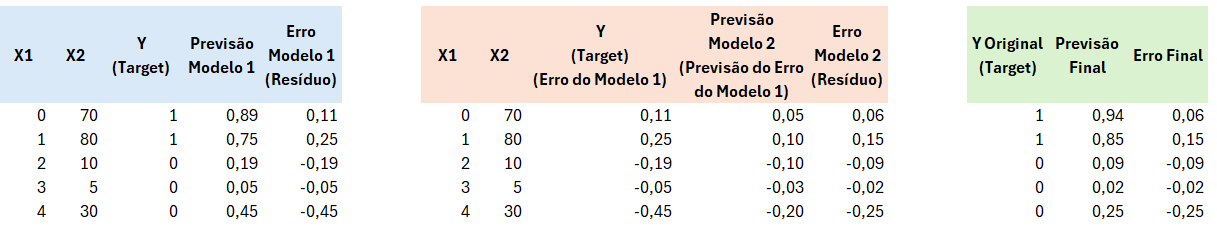

In [104]:

path = "Gradient_Boosting.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

- Ao contrário de outros Modelos de Machine Learning baseados em boosting (como o XGBoost e do LightGBM), que criam Árvores de Decisão assimétricas, o CatBoost usa Árvores de Decisão simétricas. Isso significa que as Árvores de Decisão são construídas de forma que todas as divisões em cada camada seguem a mesma regra de divisão (a mesma "pergunta" do Fluxograma):


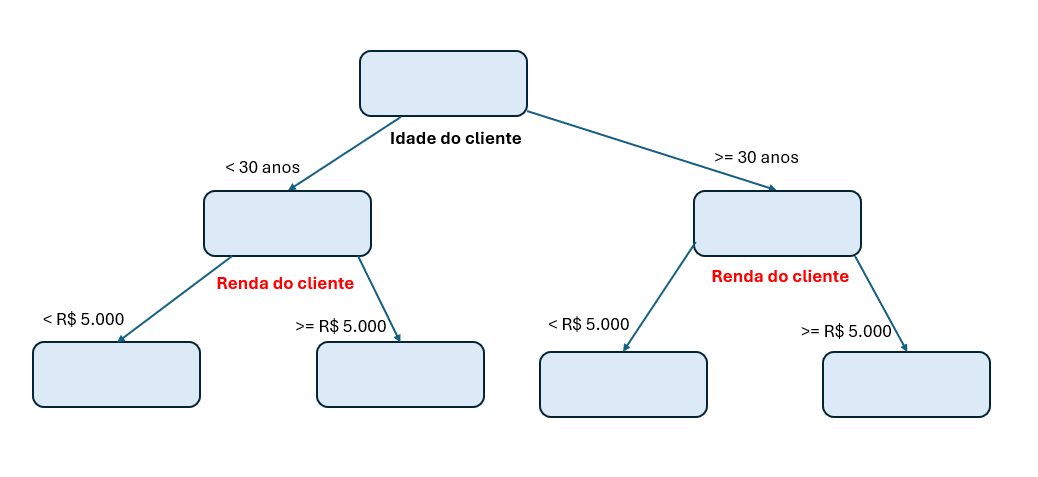

In [105]:

path = "CatBoost.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

In [965]:
# Dividindo a base de Treino em Treino e Validação para permitir Early Stopping.
X_train_cb, X_val_cb, y_train_cb, y_val_cb = train_test_split(
    x_train_selected,
    y_train_poly,
    test_size=0.2,
    stratify=y_train_poly,
    random_state=42
)

**Instanciando o Modelo**

In [967]:
cat = CatBoostClassifier(
    iterations=150,
    depth=3,
    od_type="Iter",
    od_wait=50,
    learning_rate=0.2,
    scale_pos_weight=(len(y_train_cb) - sum(y_train_cb)) / sum(y_train_cb),
    random_state=42,
    task_type="CPU",
    logging_level="Silent"
)

**Treinando o modelo na base de Treino e utilizando de uma base de Validação para realizar Early Stopping**

In [969]:
cat.fit(
    X_train_cb, y_train_cb,
    eval_set=(X_val_cb, y_val_cb),
    use_best_model=True
)

print("Árvores realmente usadas:", cat.best_iteration_)

Árvores realmente usadas: 131


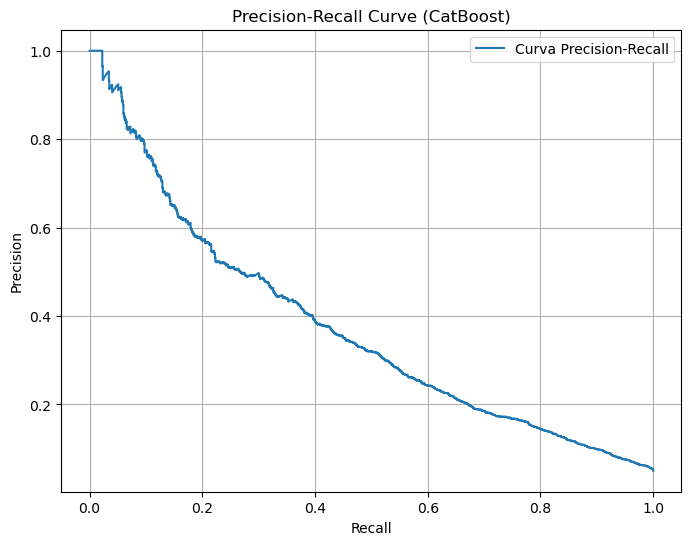

In [970]:
y_proba_val = cat.predict_proba(X_val_cb)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val_cb, y_proba_val)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label="Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (CatBoost)")
plt.legend()
plt.grid(True)
plt.show()

**Desempenho do Modelo**

In [972]:
desempenho_cat=calcula_desempenho(cat, x_train_selected, y_train_poly, x_test_selected, y_test_poly)

In [973]:
desempenho_cat

,Treino,Teste,Variação%
Acurácia,79.88%,79.42%,-0.58%
AUROC,87.10%,84.23%,-3.29%
Precision,17.04%,15.99%,-6.15%
Recall,78.17%,73.27%,-6.27%
F1,27.98%,26.25%,-6.17%
F2,45.51%,42.69%,-6.20%


**Matriz de Confusão da base de Treino**

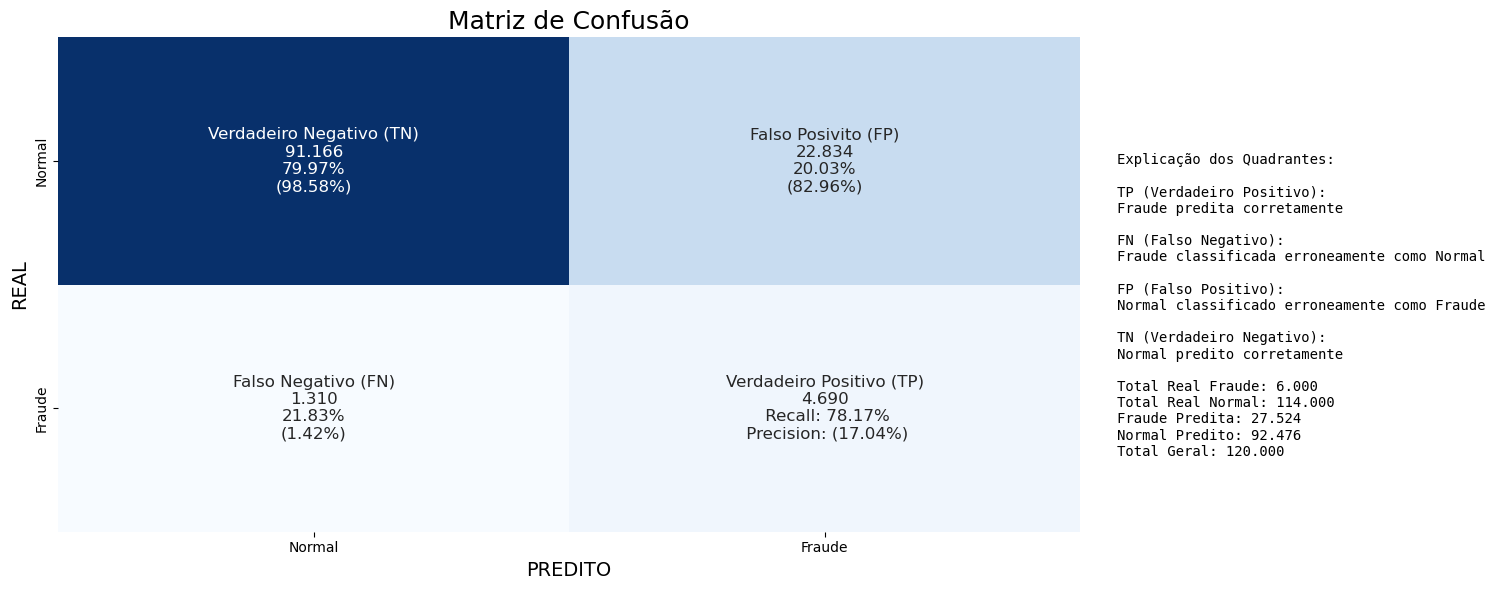

In [980]:
matriz_confusao(cat, x_train_selected, y_train_poly)

**Matriz de Confusão da base de Teste**

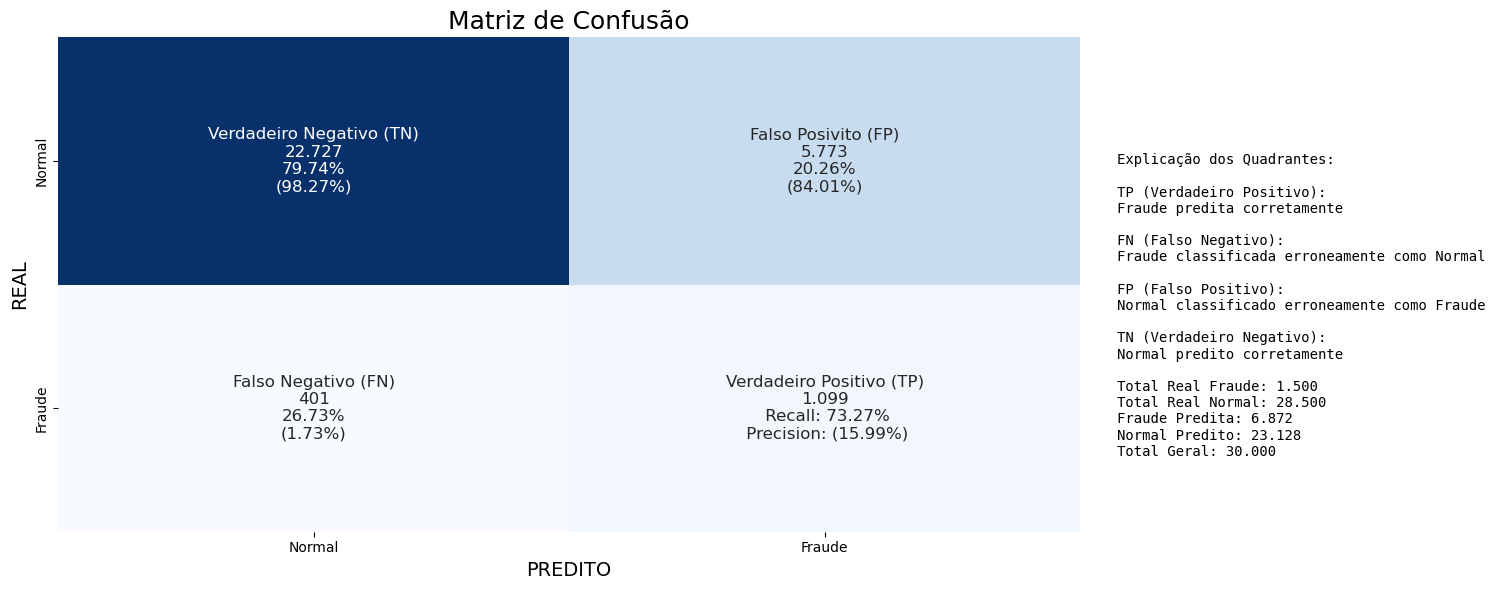

In [982]:
matriz_confusao(cat, x_test_selected, y_test_poly)

#### Tunagem de Hiperparâmetros

**Função objetivo que será utilizada pelo Optuna para testar os vários hiperparâmetros**

In [45]:
def objective_cat(trial):
    # Calcular scale_pos_weight explicitamente
    n_major = (y_train_cb == 0).sum()
    n_minor = (y_train_cb == 1).sum()
    scale_pos_weight = n_major / n_minor

    params = {
        "iterations": trial.suggest_int("iterations", 50, 250), 
        "depth": trial.suggest_int("depth", 3, 6),  
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.2),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "border_count": trial.suggest_int("border_count", 32, 128),
        "random_strength": trial.suggest_float("random_strength", 1, 5),
        "scale_pos_weight": scale_pos_weight,
        "od_type": "Iter",        
        "od_wait": 50,            
        "random_state": 42,
        "thread_count":6,
        "task_type": "CPU",
        "logging_level": "Silent"
    }

    # Instanciar CatBoost
    cat = CatBoostClassifier(**params)

    # Treinar no treino + validação
    cat.fit(X_train_cb, y_train_cb, eval_set=(X_val_cb, y_val_cb))

    # Criar o scorer F2
    f2_scorer = make_scorer(fbeta_score, beta=2)


    # Ajuste de threshold
    cat_tt_clf = TunedThresholdClassifierCV(
        estimator=cat,
        scoring=f2_scorer,
        cv=2
    )
    cat_tt_clf.fit(X_train_cb, y_train_cb)

    # Avaliar no conjunto de validação
    y_pred = cat_tt_clf.predict(X_val_cb)
    return fbeta_score(y_val_cb, y_pred, beta=2)

**Rodando a otimização que procurará os melhores hiperparâmetros que otimize o indicador-alvo**

In [47]:
study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=50)  

print("Melhores hiperparâmetros encontrados:")
print(study_cat.best_params)
print("Melhor indicador:", study_cat.best_value)

[I 2025-10-24 16:42:45,745] A new study created in memory with name: no-name-9d861d84-270b-48ab-8bc4-262e36ae9474
[I 2025-10-24 16:42:52,179] Trial 0 finished with value: 0.4671814671814672 and parameters: {'iterations': 98, 'depth': 3, 'learning_rate': 0.19030027550324385, 'l2_leaf_reg': 5.988921481294827, 'border_count': 101, 'random_strength': 4.351816633328064}. Best is trial 0 with value: 0.4671814671814672.
[I 2025-10-24 16:43:01,607] Trial 1 finished with value: 0.46217479918475 and parameters: {'iterations': 184, 'depth': 3, 'learning_rate': 0.1299761391469178, 'l2_leaf_reg': 5.390606877888916, 'border_count': 33, 'random_strength': 3.3129648595722996}. Best is trial 0 with value: 0.4671814671814672.
[I 2025-10-24 16:43:07,164] Trial 2 finished with value: 0.45728334357713585 and parameters: {'iterations': 68, 'depth': 4, 'learning_rate': 0.08178891997379514, 'l2_leaf_reg': 2.798043728005449, 'border_count': 53, 'random_strength': 1.2405973189642117}. Best is trial 0 with value

Melhores hiperparâmetros encontrados:
{'iterations': 98, 'depth': 3, 'learning_rate': 0.19030027550324385, 'l2_leaf_reg': 5.988921481294827, 'border_count': 101, 'random_strength': 4.351816633328064}
Melhor indicador: 0.4671814671814672


**Instanciando o Modelo final já com os hiperparâmetros que tunam (otimizam) o indicador-alvo**

In [49]:
scale_pos_weight_final = (y_train_poly == 0).sum() / (y_train_poly == 1).sum()

cat_tunado = CatBoostClassifier(
    **study_cat.best_params,
    scale_pos_weight=scale_pos_weight_final,
    od_type="Iter",
    od_wait=50,
    random_state=42,
    thread_count=6,
    task_type="CPU",
    logging_level="Silent"
)

**Envolvendo o Modelo no Threshold Tuning que maximiza o indicador-alvo**

In [55]:
cat_tunado_tt_clf = TunedThresholdClassifierCV(
    estimator=cat_tunado,
    scoring=f2_scorer,
    cv=2
)

**Treinando o Modelo Tunado na base de Treino**

In [61]:
cat_tunado_tt_clf.fit(x_train_selected, y_train_poly)

,estimator,<catboost.cor...00172478A1520>
,scoring,"make_scorer(f...dict', beta=2)"
,response_method,'auto'
,thresholds,100
,cv,2
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False


In [63]:
desempenho_cat_tunado_tt_clf=calcula_desempenho(cat_tunado_tt_clf, x_train_selected, y_train_poly, x_test_selected, y_test_poly)


>>> Melhor threshold encontrado: 0.6549



In [65]:
desempenho_cat_tunado_tt_clf

,Treino,Teste,Variação%
Acurácia,87.95%,87.26%,-0.78%
AUROC,86.38%,84.31%,-2.39%
Precision,23.61%,21.78%,-7.77%
Recall,63.10%,59.73%,-5.34%
F1,34.37%,31.92%,-7.12%
F2,47.29%,44.30%,-6.33%


### LightGBM

- O LightGBM é um algorítmo de Machine Learning que utiliza o **método Enseble na estratégia de Boosting de Árvores de Decisão**. Os boosting podem ocorrer através de métodos adaptativos (como o AdaBoost) ou por Gradient Boosting e suas derivações (como o CatBoost, XGBoost e LightGBM).
  
- Diferentemente dos modelos de Machine Learning baseados em Bagging (como a Random Forest), que treina modelos de forma independente (e permite paralelização) e depois consolida os resultados desses modelos gerando uma predição final, **modelos de Machine Learning baseados em Boosting encadeiam os modelos sequencialmente, de forma que os erros dos modelos anteriores são utilizados para melhorar o modelo final.**

- No LightGBM, **o crescimento das Árvores de Decisão é feito de forma assimétrica**. Ele não se preocupa em preencher todos os nós de uma camada antes de ir para a próxima. Em vez disso, ele **foca em expandir os Nós que trazem o maior ganho de informação (menor Gini)**, resultando em ramos de profundidades diferentes. **Por isso que o treinamento do LightGBM costuma ser mais rápido que o dos demais Modelos de Machine Learning que se baseiam em boosting**:

![Descrição da imagem](LightGBM.png)

In [1013]:
# Dividindo a base de Treino em Treino e Validação para permitir Early Stopping.
X_train_lgb, X_val_lgb, y_train_lgb, y_val_lgb = train_test_split(
    x_train_selected, 
    y_train_poly, 
    test_size=0.2, 
    stratify=y_train_poly, 
    random_state=42
)

**Instanciando o Modelo**

In [1015]:
lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.2,
    n_jobs=-1,
    is_unbalance=True,
    subsample=0.5,
    colsample_bytree=0.5,
    verbose=-1,
    metric='auc',
    random_state=42
)

**Treinando o modelo na base de Treino e utilizando de uma base de Validação para realizar Early Stopping**

In [1017]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
lgbm.fit(
    X_train_lgb, 
    y_train_lgb,
    eval_set=[(X_val_lgb, y_val_lgb)],
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=50)]
)

print("Árvores realmente usadas:", lgbm.booster_.current_iteration())

Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.850355
[100]	valid_0's auc: 0.851769
[150]	valid_0's auc: 0.850169
Early stopping, best iteration is:
[108]	valid_0's auc: 0.852
Árvores realmente usadas: 108


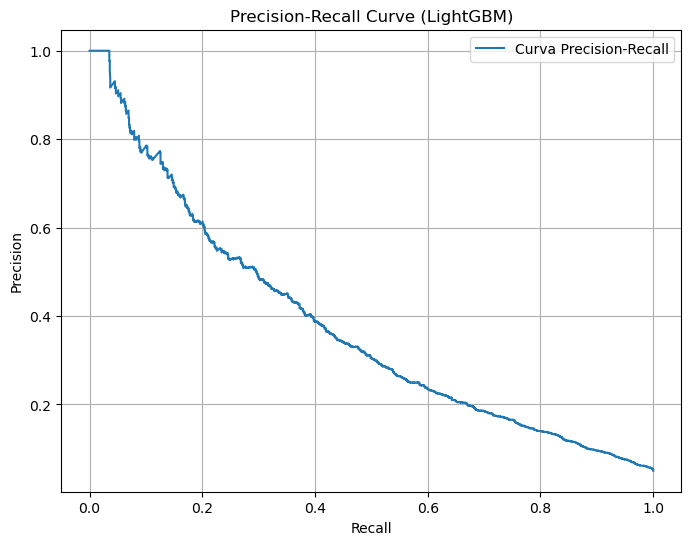

In [1018]:
y_proba_val = lgbm.predict_proba(X_val_lgb)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val_lgb, y_proba_val)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label="Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LightGBM)")
plt.legend()
plt.grid(True)
plt.show()

**Desempenho do Modelo**

In [1020]:
desempenho_lgbm=calcula_desempenho(lgbm, x_train_selected, y_train_poly, x_test_selected, y_test_poly)

In [1021]:
desempenho_lgbm

,Treino,Teste,Variação%
Acurácia,78.62%,78.14%,-0.61%
AUROC,87.49%,83.99%,-3.99%
Precision,16.40%,15.15%,-7.66%
Recall,79.98%,73.27%,-8.40%
F1,27.22%,25.11%,-7.78%
F2,45.06%,41.46%,-7.99%


**Matriz de Confusão da base de Treino**

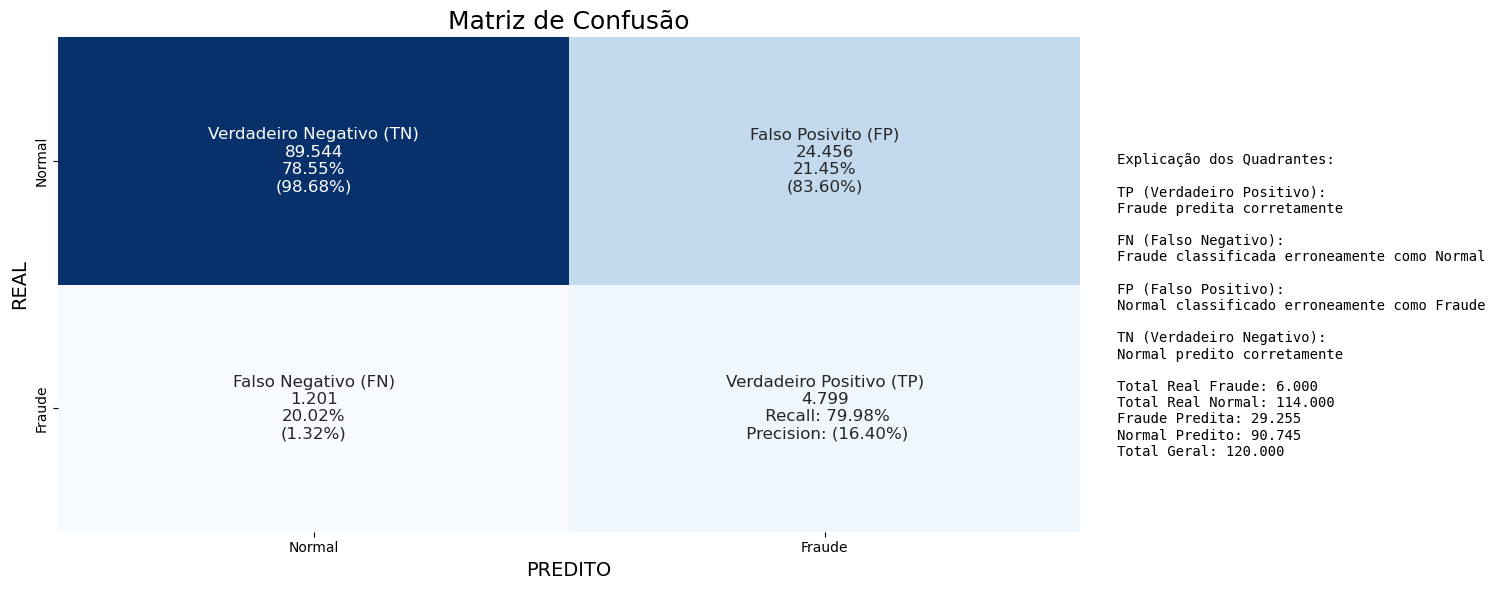

In [1023]:
matriz_confusao(lgbm, x_train_selected, y_train_poly)

**Matriz de Confusão da base de Teste**

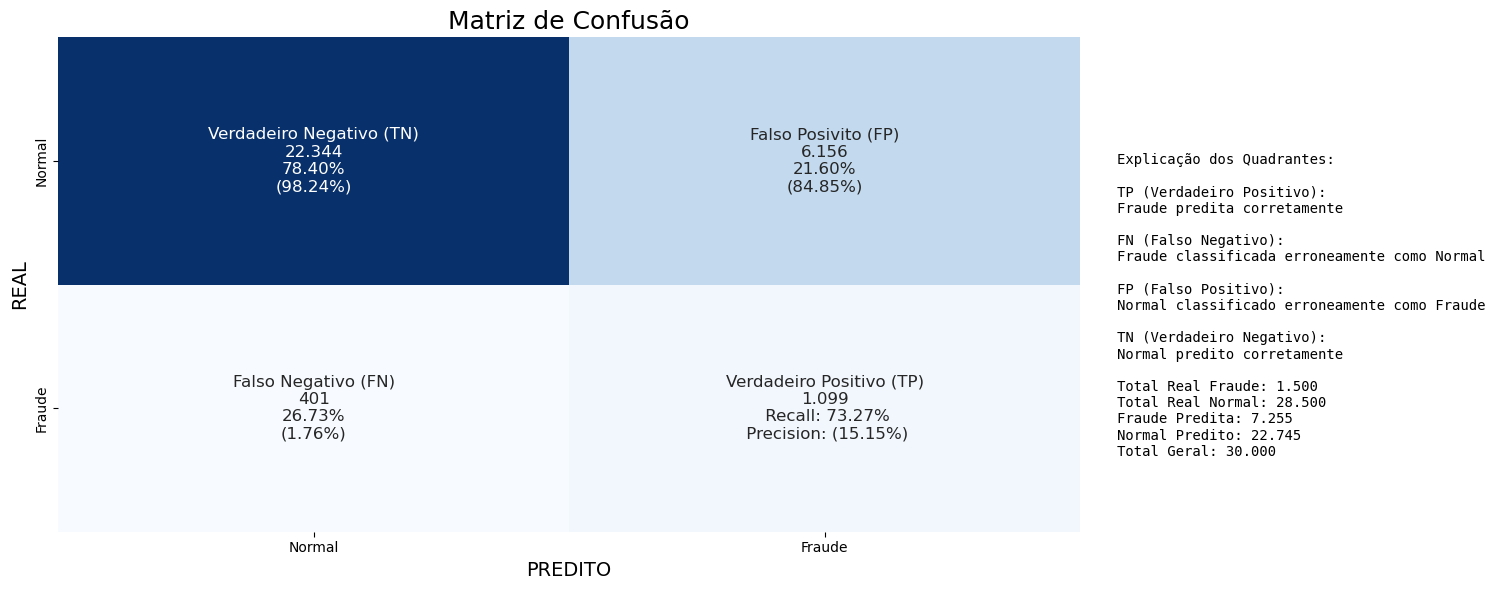

In [1025]:
matriz_confusao(lgbm, x_test_selected, y_test_poly)

#### Tunagem de Hiperparâmetros

**Função objetivo que será utilizada pelo Optuna para testar os vários hiperparâmetros**

In [186]:
def objective_lgbm(trial):
    # Definir hiperparâmetros do LightGBM
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 400, 1000),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "is_unbalance": True,
        "random_state": 42,
        "n_jobs": -1
    }

    # Treinar LGBM com early stopping
    lgbm = LGBMClassifier(**params)
    lgbm.fit(
        X_train_lgb, y_train_lgb,
        eval_set=[(X_val_lgb, y_val_lgb)],
        eval_metric="auc",
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
    )


    # Criar o scorer F2
    f2_scorer = make_scorer(fbeta_score, beta=2)
    
    
    # Ajustar o threshold
    lgbm_tt_clf = TunedThresholdClassifierCV(
        estimator=lgbm,
        scoring=f2_scorer,
        cv=2
    )
    lgbm_tt_clf.fit(X_train_lgb, y_train_lgb)

    # Avaliar no conjunto de validação
    y_pred = lgbm_tt_clf.predict(X_val_lgb)
    return fbeta_score(y_val_lgb, y_pred, beta=2)

**Rodando a otimização que procurará os melhores hiperparâmetros que otimize o indicador-alvo**

In [188]:
study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=50)

print("Melhores hiperparâmetros encontrados:")
print(study_lgbm.best_params)
print("Melhor indicador obtido no conjunto de validação:", study_lgbm.best_value)

[I 2025-10-24 17:51:07,582] A new study created in memory with name: no-name-70115f28-b5e1-432f-9287-90628369c873
[I 2025-10-24 17:51:17,982] Trial 0 finished with value: 0.4015215553677092 and parameters: {'num_leaves': 147, 'max_depth': 5, 'learning_rate': 0.1788530474656761, 'n_estimators': 630, 'min_child_samples': 92, 'subsample': 0.5787014976128273, 'colsample_bytree': 0.6558498763913014, 'reg_alpha': 0.012836866372895252, 'reg_lambda': 0.012455087162733873}. Best is trial 0 with value: 0.4015215553677092.
[I 2025-10-24 17:51:54,842] Trial 1 finished with value: 0.4467584816929795 and parameters: {'num_leaves': 182, 'max_depth': 7, 'learning_rate': 0.002225199079534535, 'n_estimators': 890, 'min_child_samples': 29, 'subsample': 0.5290661651476436, 'colsample_bytree': 0.5808090721013457, 'reg_alpha': 4.464166351569054e-06, 'reg_lambda': 1.0399892231348294e-06}. Best is trial 1 with value: 0.4467584816929795.
[I 2025-10-24 17:52:16,432] Trial 2 finished with value: 0.45269704580791

Melhores hiperparâmetros encontrados:
{'num_leaves': 219, 'max_depth': 4, 'learning_rate': 0.01835895812660602, 'n_estimators': 754, 'min_child_samples': 76, 'subsample': 0.5063859640249427, 'colsample_bytree': 0.8400182989264889, 'reg_alpha': 0.00015170630964697358, 'reg_lambda': 0.014823532891343192}
Melhor indicador obtido no conjunto de validação: 0.46573604060913704


**Instanciando o Modelo final já com os hiperparâmetros que tunam (otimizam) o indicador-alvo**

In [190]:
lgbm_tunado = LGBMClassifier(**study_lgbm.best_params, random_state=42, is_unbalance= True, n_jobs=-1)

**Envolvendo o Modelo no Threshold Tuning que maximiza o indicador-alvo**

In [192]:
lgbm_tunado_tt_clf = TunedThresholdClassifierCV(
    estimator=lgbm_tunado,
    scoring=f2_scorer,
    cv=2
)

**Treinando o Modelo Tunado na base de Treino**

In [194]:
lgbm_tunado_tt_clf.fit(x_train_selected, y_train_poly)

,estimator,LGBMClassifie...3859640249427)
,scoring,"make_scorer(f...dict', beta=2)"
,response_method,'auto'
,thresholds,100
,cv,2
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,boosting_type,'gbdt'
,num_leaves,219


In [196]:
desempenho_lgbm_tunado_tt_clf=calcula_desempenho(lgbm_tunado_tt_clf, x_train_selected, y_train_poly, x_test_selected, y_test_poly)


>>> Melhor threshold encontrado: 0.6544



In [198]:
desempenho_lgbm_tunado_tt_clf

,Treino,Teste,Variação%
Acurácia,88.83%,87.83%,-1.13%
AUROC,88.53%,84.42%,-4.64%
Precision,25.91%,22.48%,-13.24%
Recall,66.35%,58.60%,-11.68%
F1,37.27%,32.50%,-12.81%
F2,50.57%,44.35%,-12.30%


### Rede Neural Artificial


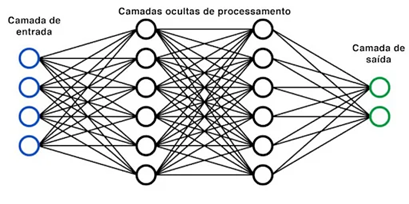

In [139]:

path = "Rede Neural.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

- Uma Rede Neural Artificial (RNA) é um algoritmo inspirado no funcionamento do cérebro humano, projetado para aprender padrões complexos a partir de dados.
  
- Ela é composta por camadas de neurônios artificiais, onde cada neurônio realiza operações matemáticas (como uma soma ponderada seguida de uma função de ativação). Quando organizados em camadas — entrada, ocultas e saída — esses neurônios conseguem representar relações não lineares entre variáveis.

- Na camada mais à esquerda, temos os inputs da Rede Neural. Essa é a **Camada de Entrada** (Input Layer).

- Na sequência, temos as **Camadas Ocultas (Hidden Layers)**. No desenho acima, temos 2 Camadas Ocultas. Cada uma das duas camadas contando com 6 neurônios.

- Finalmente, temos a **Camada de Saída (Output Layer)**. No desenho acima, há 2 saídas (2 outputs). Pode ser, nesse caso, 2 categorias como resposta, por exemplo. 

In [1115]:
# Dividir treino em treino e validação
X_train_rna, X_val_rna, y_train_rna, y_val_rna = train_test_split(
    x_train_selected,
    y_train_poly,
    test_size=0.2,
    stratify=y_train_poly,
    random_state=42
)

In [1117]:
# Calcular class_weight
n_major = (y_train_rna == 0).sum()
n_minor = (y_train_rna == 1).sum()
class_weight = {0: 1.0, 1: n_major / n_minor}

In [1119]:
# Métrica customizada F2 Score para Keras
class F2Score(keras.metrics.Metric):
    def __init__(self, name='f2_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.f2 = self.add_weight(name='f2', initializer='zeros')
        self.true_positives = self.add_weight(name='tp', initializer='zeros')
        self.false_positives = self.add_weight(name='fp', initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', initializer='zeros')
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > 0.5, tf.float32)
        y_true = tf.cast(y_true, tf.float32)
        
        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))
        
        self.true_positives.assign_add(tp)
        self.false_positives.assign_add(fp)
        self.false_negatives.assign_add(fn)
    
    def result(self):
        precision = self.true_positives / (self.true_positives + self.false_positives + keras.backend.epsilon())
        recall = self.true_positives / (self.true_positives + self.false_negatives + keras.backend.epsilon())
        beta = 2.0
        f2 = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + keras.backend.epsilon())
        return f2
    
    def reset_state(self):
        self.true_positives.assign(0)
        self.false_positives.assign(0)
        self.false_negatives.assign(0)

In [35]:
# Instanciando o modelo
model = keras.Sequential()

# Camada de Entrada
model.add(keras.Input(shape=(X_train_rna.shape[1],)))  

# Camada Oculta 1
model.add(layers.Dense(8, 
                       activation='relu', 
                       kernel_regularizer=keras.regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(layers.Dropout(0.3))

# Camada Oculta 2
model.add(layers.Dense(4, 
                       activation='relu', 
                       kernel_regularizer=keras.regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(layers.Dropout(0.2))

# Camada Oculta 3
model.add(layers.Dense(4, 
                       activation='relu', 
                       kernel_regularizer=keras.regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(layers.Dropout(0.2))

# Camada Saída
model.add(layers.Dense(1, activation='sigmoid'))

# Compilação do Modelo com F2 Score
model.compile(
    loss='binary_crossentropy', 
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=[F2Score(), keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 445 (1.74 KB)

 Trainable params: 445 (1.74 KB)

 Non-trainable params: 0 (0.00 B)

- Acima, estamos montando um Rede Neural com 3 camadas ocultas. A 1ª camada com 8 neurônios e a 2ª e 3ª camadas com 4 neurônios cada.
  
- Estamos adicionando camadas densas. **Em camadas densas (Fully Conected) cada neurônio conecta-se a todas as entradas da camada anterior**. Para problemas de Classificação, de Regressão e NLP normalmente são usadas camadas densas. Existem camadas convolucionais (CNN), especialmente para imagens. Usamos camadas recorrentes (RNN) especialmente para séries temporais, como LSTM e GRU.

- Está sendo realizada as seguintes **Regularizações, que são técnicas que aplicam restrições no treinamento e nos valores dos pesos sinápticos para simplificar o modelo com o intuito de combater o overfitting**:

    - L1 de 1%: Penalização adicionada à função de perda equivale a 1% da soma absoluta dos pesos. Tende a “zerar” pesos pequenos, ou seja, elimina conexões irrelevantes.
      
    - L2 de 1%: Penalização adicionada à função de perda equivale a 1% da soma dos quadrados dos pesos. Penaliza mais fortemente pesos grandes. Isso reduz gradualmente a magnitude dos pesos, evitando que alguns dominem o aprendizado. 
 
    - Dropout de 20% na primeira camada oculta e de 30% nas camadas ocultas seguintes: Percentual dos neurônios que serão desligados e religados durante cada Época do treinamento.

- Como estamos tratando de um **problema de classificação**, usaremos a **função de ativação Sigmoid na Camada de Saída, porque ela é uma função que varia entre 0 e 1**.  

In [1121]:
# Early Stopping monitorando F2 Score
rna_es = tf.keras.callbacks.EarlyStopping(
    monitor="val_f2_score",
    min_delta=0.001,
    patience=5,
    verbose=1,
    mode='max',
    restore_best_weights=True
)

In [39]:
# Treinar o modelo
historico = model.fit(
    x=X_train_rna, 
    y=y_train_rna,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_rna, y_val_rna),
    class_weight=class_weight,
    verbose=1,
    callbacks=[rna_es]
)

Epoch 1/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - auc: 0.7091 - f2_score: 0.2880 - loss: 1.5696 - val_auc: 0.8305 - val_f2_score: 0.4009 - val_loss: 0.6721
Epoch 2/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - auc: 0.7674 - f2_score: 0.3328 - loss: 1.2322 - val_auc: 0.8288 - val_f2_score: 0.3940 - val_loss: 0.6319
Epoch 3/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - auc: 0.7733 - f2_score: 0.3486 - loss: 1.2089 - val_auc: 0.8356 - val_f2_score: 0.4015 - val_loss: 0.6492
Epoch 4/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - auc: 0.7752 - f2_score: 0.3532 - loss: 1.2013 - val_auc: 0.8326 - val_f2_score: 0.3998 - val_loss: 0.6534
Epoch 5/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - auc: 0.7716 - f2_score: 0.3521 - loss: 1.2034 - val_auc: 0.8351 - val_f2_score: 0.4215 - val_loss: 0.5942
Epoch 6/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - auc: 0.7725 - f2_score: 0.3514 - loss: 1.2009 - val_auc: 0.8332 - val_f2_score: 0.4213 - val_loss: 0.5756
Epoch 7/20
3000/3000 ━

In [41]:
# Avaliar no conjunto completo
score_train, f2_train, auc_train = model.evaluate(x_train_selected, y_train_poly, verbose=0)
score_test, f2_test, auc_test = model.evaluate(x_test_selected, y_test_poly, verbose=0)
print('\n=== Resultados ===')
print(f'F2 Score no Treino: {f2_train:.1%}')
print(f'F2 Score no Teste: {f2_test:.1%}')
print(f'AUC no Treino: {auc_train:.1%}')
print(f'AUC no Teste: {auc_test:.1%}')


=== Resultados ===
F2 Score no Treino: 42.5%
F2 Score no Teste: 41.0%
AUC no Treino: 84.0%
AUC no Teste: 82.4%


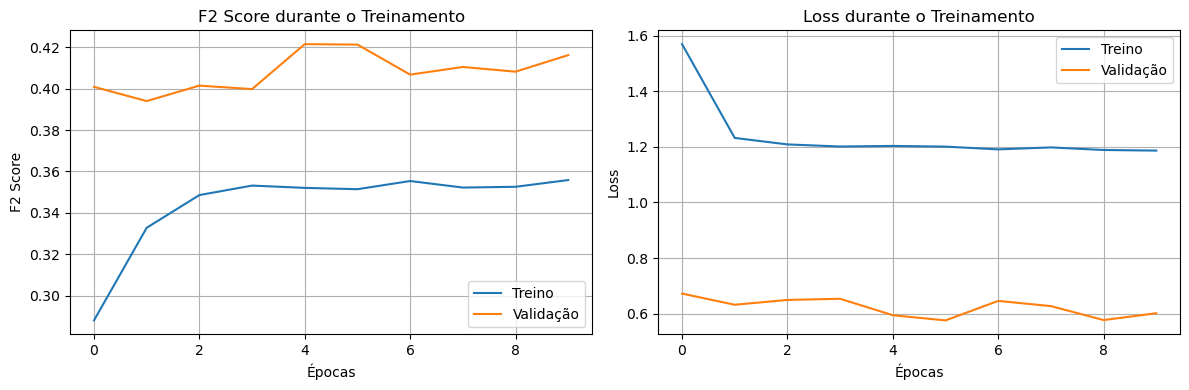

In [43]:
# Plotar histórico de F2 Score
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(historico.history['f2_score'])
plt.plot(historico.history['val_f2_score'])
plt.title('F2 Score durante o Treinamento')
plt.ylabel('F2 Score')
plt.xlabel('Épocas')
plt.legend(['Treino', 'Validação'], loc='lower right')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(historico.history['loss'])
plt.plot(historico.history['val_loss'])
plt.title('Loss durante o Treinamento')
plt.ylabel('Loss')
plt.xlabel('Épocas')
plt.legend(['Treino', 'Validação'], loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [1123]:
# Usar com a função calcula_desempenho (criar wrapper)
class KerasClassifierWrapper:
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold
    
    def predict_proba(self, X):
        proba_1 = self.model.predict(X, verbose=0).flatten()
        proba_0 = 1 - proba_1
        return np.column_stack([proba_0, proba_1])
    
    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)

In [47]:
# Wrapper para usar com calcula_desempenho
rna_wrapper = KerasClassifierWrapper(model, threshold=0.5)

desempenho_rna = calcula_desempenho(
    rna_wrapper,
    x_train_selected,
    y_train_poly,
    x_test_selected,
    y_test_poly
)

In [49]:
desempenho_rna

,Treino,Teste,Variação%
Acurácia,78.64%,78.40%,-0.31%
AUROC,84.07%,82.47%,-1.90%
Precision,15.64%,15.11%,-3.44%
Recall,74.48%,71.87%,-3.51%
F1,25.86%,24.97%,-3.45%
F2,42.51%,41.03%,-3.47%


In [1125]:
def objective_rna(trial):
    # Limpar sessão do Keras para evitar acúmulo de memória
    keras.backend.clear_session()
    
    # Hiperparâmetros a tunar 
    n_units_1 = trial.suggest_int("n_units_1", 8, 64)
    n_units_2 = trial.suggest_int("n_units_2", 4, 32)
    n_units_3 = trial.suggest_int("n_units_3", 2, 16)
    dropout_1 = trial.suggest_float("dropout_1", 0.1, 0.5)
    dropout_2 = trial.suggest_float("dropout_2", 0.1, 0.5)
    dropout_3 = trial.suggest_float("dropout_3", 0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    l1_reg = trial.suggest_float("l1_reg", 1e-5, 0.1, log=True)
    l2_reg = trial.suggest_float("l2_reg", 1e-5, 0.1, log=True)
    
    # Construir modelo 
    model = keras.Sequential([
        keras.Input(shape=(X_train_rna.shape[1],)),
        layers.Dense(n_units_1, 
                    activation='relu',
                    kernel_regularizer=keras.regularizers.l1_l2(l1=l1_reg, l2=l2_reg)),
        layers.Dropout(dropout_1),
        layers.Dense(n_units_2, 
                    activation='relu',
                    kernel_regularizer=keras.regularizers.l1_l2(l1=l1_reg, l2=l2_reg)),
        layers.Dropout(dropout_2),
        layers.Dense(n_units_3, 
                    activation='relu',
                    kernel_regularizer=keras.regularizers.l1_l2(l1=l1_reg, l2=l2_reg)),
        layers.Dropout(dropout_3),
        layers.Dense(1, activation='sigmoid')
    ])
    
    # Compilar
    model.compile(
        loss='binary_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[F2Score()]
    )
    
    # Early stopping
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_f2_score',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=0
    )
    
    # Treinar
    history = model.fit(
        X_train_rna, y_train_rna,
        validation_data=(X_val_rna, y_val_rna),
        epochs=30,
        batch_size=batch_size,
        class_weight=class_weight,
        verbose=0,
        callbacks=[early_stop]
    )
    
    # Retornar melhor F2 Score de validação
    best_f2 = max(history.history['val_f2_score'])
    return best_f2

In [1129]:
warnings.filterwarnings('ignore', message='.*tf.reset_default_graph.*')
tf.get_logger().setLevel('ERROR')
study_rna = optuna.create_study(direction="maximize")
study_rna.optimize(objective_rna, n_trials=5) 

print("Melhores hiperparâmetros encontrados:")
print(study_rna.best_params)
print("Melhor F2 Score obtido no conjunto de validação:", study_rna.best_value)

[I 2025-10-31 11:36:02,619] A new study created in memory with name: no-name-675bd7e8-133f-4fef-a14a-661b8154e4fc
[I 2025-10-31 11:40:03,549] Trial 0 finished with value: 0.4241005778312683 and parameters: {'n_units_1': 25, 'n_units_2': 32, 'n_units_3': 11, 'dropout_1': 0.1190139109393869, 'dropout_2': 0.3648639866243081, 'dropout_3': 0.36093221353318383, 'learning_rate': 0.0001898480801315383, 'batch_size': 16, 'l1_reg': 4.987377287350428e-05, 'l2_reg': 0.03965999496809085}. Best is trial 0 with value: 0.4241005778312683.
[I 2025-10-31 11:42:06,785] Trial 1 finished with value: 0.4345237910747528 and parameters: {'n_units_1': 52, 'n_units_2': 22, 'n_units_3': 2, 'dropout_1': 0.19148794740233194, 'dropout_2': 0.24183906641398512, 'dropout_3': 0.4235938284095677, 'learning_rate': 0.004672099836196713, 'batch_size': 64, 'l1_reg': 0.00016294655411559867, 'l2_reg': 0.00713214808021253}. Best is trial 1 with value: 0.4345237910747528.
[I 2025-10-31 11:47:03,064] Trial 2 finished with value:

Melhores hiperparâmetros encontrados:
{'n_units_1': 52, 'n_units_2': 22, 'n_units_3': 2, 'dropout_1': 0.19148794740233194, 'dropout_2': 0.24183906641398512, 'dropout_3': 0.4235938284095677, 'learning_rate': 0.004672099836196713, 'batch_size': 64, 'l1_reg': 0.00016294655411559867, 'l2_reg': 0.00713214808021253}
Melhor F2 Score obtido no conjunto de validação: 0.4345237910747528


In [1135]:
best_params = study_rna.best_params

In [1137]:
rna_tunado = keras.Sequential([
    keras.Input(shape=(x_train_selected.shape[1],)),
    layers.Dense(best_params['n_units_1'], 
                activation='relu',
                kernel_regularizer=keras.regularizers.l1_l2(
                    l1=best_params['l1_reg'], 
                    l2=best_params['l2_reg'])),
    layers.Dropout(best_params['dropout_1']),
    layers.Dense(best_params['n_units_2'], 
                activation='relu',
                kernel_regularizer=keras.regularizers.l1_l2(
                    l1=best_params['l1_reg'], 
                    l2=best_params['l2_reg'])),
    layers.Dropout(best_params['dropout_2']),
    layers.Dense(best_params['n_units_3'], 
                activation='relu',
                kernel_regularizer=keras.regularizers.l1_l2(
                    l1=best_params['l1_reg'], 
                    l2=best_params['l2_reg'])),
    layers.Dropout(best_params['dropout_3']),
    layers.Dense(1, activation='sigmoid')
])

rna_tunado.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    metrics=[F2Score(), keras.metrics.AUC(name='auc')]
)

In [1139]:
# Early stopping para o modelo final
rna_es_final = keras.callbacks.EarlyStopping(
    monitor="val_f2_score",
    min_delta=0.001,
    patience=5,
    verbose=1,
    mode='max',
    restore_best_weights=True
)

In [1141]:
# Treinar no conjunto completo de treino
historico_final = rna_tunado.fit(
    x=x_train_selected, 
    y=y_train_poly,
    epochs=20,
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    class_weight=class_weight,
    verbose=1,
    callbacks=[rna_es_final]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - auc: 0.7317 - f2_score: 0.3595 - loss: 1.2404 - val_auc: 0.8239 - val_f2_score: 0.4140 - val_loss: 0.6153
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - auc: 0.7466 - f2_score: 0.3762 - loss: 1.1556 - val_auc: 0.8231 - val_f2_score: 0.4345 - val_loss: 0.5807
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - auc: 0.7457 - f2_score: 0.3793 - loss: 1.1511 - val_auc: 0.8230 - val_f2_score: 0.4188 - val_loss: 0.5820
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - auc: 0.7370 - f2_score: 0.3743 - loss: 1.1625 - val_auc: 0.8275 - val_f2_score: 0.4213 - val_loss: 0.6013
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - auc: 0.7398 - f2_score: 0.3717 - loss: 1.1571 - val_auc: 0.8296 - val_f2_score: 0.4190 - val_loss: 0.5685
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - auc: 0.7450 - f2_score: 0.3765 - loss: 1.1514 - val_auc: 0.8143 - val_f2_score: 0.3967 - val_loss: 0.5683
Epoch 7/20
1500/1500 ━━━━━━

In [1143]:
# Avaliar com a função calcula_desempenho
class KerasClassifierWrapper:
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold
    
    def predict_proba(self, X):
        proba_1 = self.model.predict(X, verbose=0).flatten()
        proba_0 = 1 - proba_1
        return np.column_stack([proba_0, proba_1])
    
    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)

In [1145]:
# Criar wrapper
rna_tunado_wrapper = KerasClassifierWrapper(rna_tunado, threshold=0.5)

In [1147]:
desempenho_rna_tunado = calcula_desempenho(
    rna_tunado_wrapper,
    x_train_selected,
    y_train_poly,
    x_test_selected,
    y_test_poly
)

In [1149]:
desempenho_rna_tunado

,Treino,Teste,Variação%
Acurácia,82.90%,82.53%,-0.44%
AUROC,82.86%,81.63%,-1.48%
Precision,17.97%,17.14%,-4.66%
Recall,67.90%,65.00%,-4.27%
F1,28.42%,27.12%,-4.58%
F2,43.65%,41.70%,-4.46%


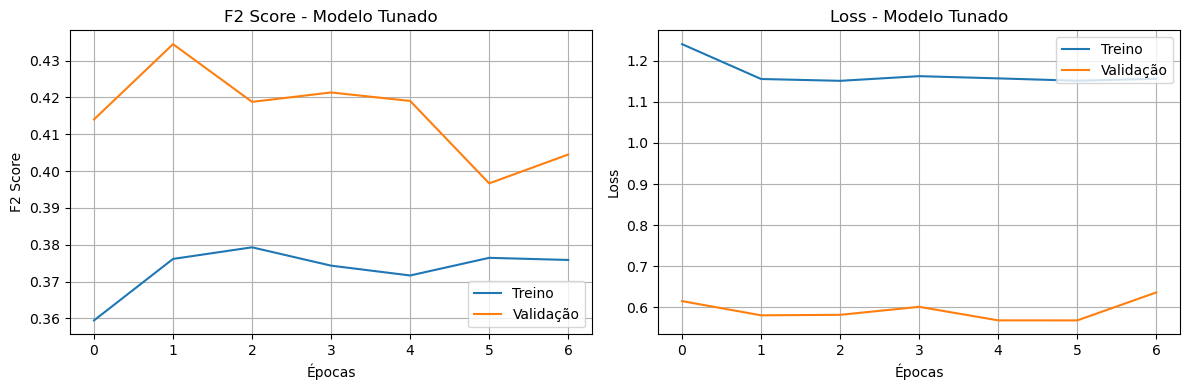

In [1151]:
# Plotar histórico de treinamento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(historico_final.history['f2_score'])
plt.plot(historico_final.history['val_f2_score'])
plt.title('F2 Score - Modelo Tunado')
plt.ylabel('F2 Score')
plt.xlabel('Épocas')
plt.legend(['Treino', 'Validação'], loc='lower right')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(historico_final.history['loss'])
plt.plot(historico_final.history['val_loss'])
plt.title('Loss - Modelo Tunado')
plt.ylabel('Loss')
plt.xlabel('Épocas')
plt.legend(['Treino', 'Validação'], loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

### XGBoost

- O XGBoost é um algorítmo de Machine Learning que utiliza o **método Enseble na estratégia de Boosting de Árvores de Decisão**. Os boosting podem ocorrer através de métodos adaptativos (como o AdaBoost) ou por Gradient Boosting e suas derivações (como o CatBoost, XGBoost e LightGBM).
  
- Diferentemente dos modelos de Machine Learning baseados em Bagging (como a Random Forest), que treina modelos de forma independente (e permite paralelização) e depois consolida os resultados desses modelos gerando uma predição final, **modelos de Machine Learning baseados em Boosting encadeiam os modelos sequencialmente, de forma que os erros dos modelos anteriores são utilizados para melhorar o modelo final.**

- O XGBoost utiliza Árvores de Decisão que são **construídas com profundidade fixa (Depth-wise)**. Isso significa que a Árvore de Decisão expande igualmente para todos os lados, com cada nível (ou camada) da árvore sendo completado antes de passar para o próximo. E, diferentemente do Catboost, **as perguntas não precisam ser as mesmas em cada Nó**.


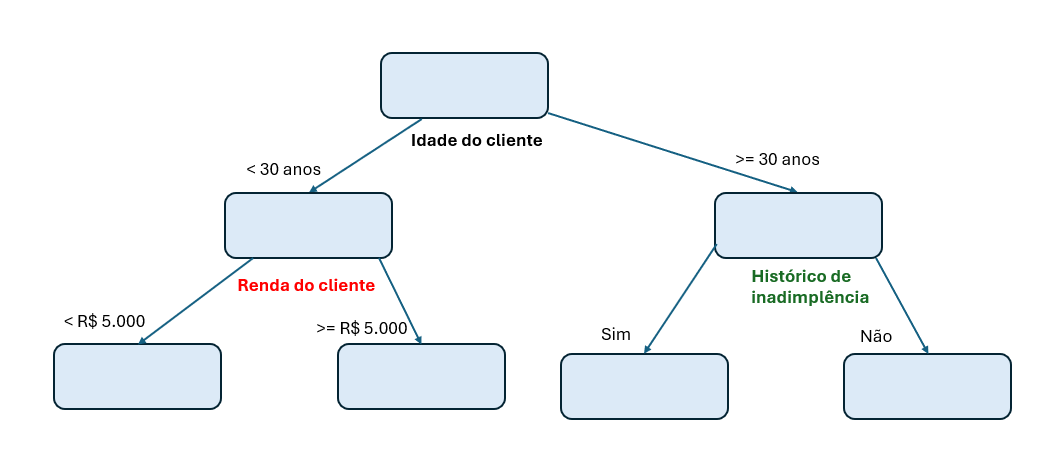

In [106]:

path = "XGBoost.png"
with open(path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
display(HTML(f"<img src='data:image/png;base64,{data}' style='max-width:100%; height:auto;'>"))

In [985]:
# Dividindo a base de Treino em Treino e Validação para permitir Early Stopping.
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    x_train_selected,
    y_train_poly,
    test_size=0.2,
    stratify=y_train_poly,
    random_state=42
)

**Instanciando o Modelo**

In [987]:
scale_pos_weight_xgb = (len(y_train_xgb) - sum(y_train_xgb)) / sum(y_train_xgb)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.2,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=scale_pos_weight_xgb,
    random_state=42,
    n_jobs=6,              
    eval_metric="logloss",
    tree_method="hist",     
    verbosity=0
)

# ativar early stopping
xgb.set_params(early_stopping_rounds=50)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'logloss'


**Treinando o modelo na base de Treino e utilizando de uma base de Validação para realizar Early Stopping**

In [989]:
xgb.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)

print("Árvores realmente usadas:", xgb.best_iteration)

Árvores realmente usadas: 194


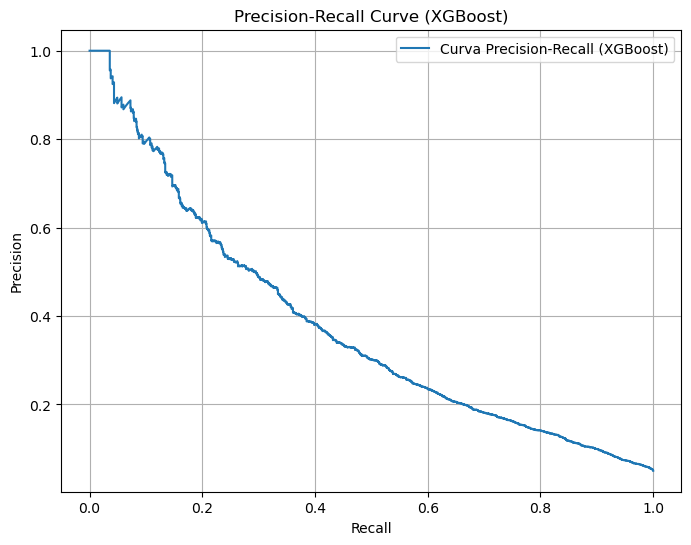

In [990]:
y_proba_val_xgb = xgb.predict_proba(X_val_xgb)[:, 1]
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_val_xgb, y_proba_val_xgb)

plt.figure(figsize=(8,6))
plt.plot(recall_xgb, precision_xgb, label="Curva Precision-Recall (XGBoost)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()

**Desempenho do Modelo**

In [992]:
desempenho_xgb=calcula_desempenho(xgb, x_train_selected, y_train_poly, x_test_selected, y_test_poly)

In [993]:
desempenho_xgb

,Treino,Teste,Variação%
Acurácia,81.57%,80.65%,-1.13%
AUROC,88.85%,83.90%,-5.57%
Precision,18.59%,16.56%,-10.95%
Recall,79.53%,71.07%,-10.65%
F1,30.14%,26.86%,-10.89%
F2,48.04%,42.85%,-10.80%


**Matriz de Confusão da base de Treino**

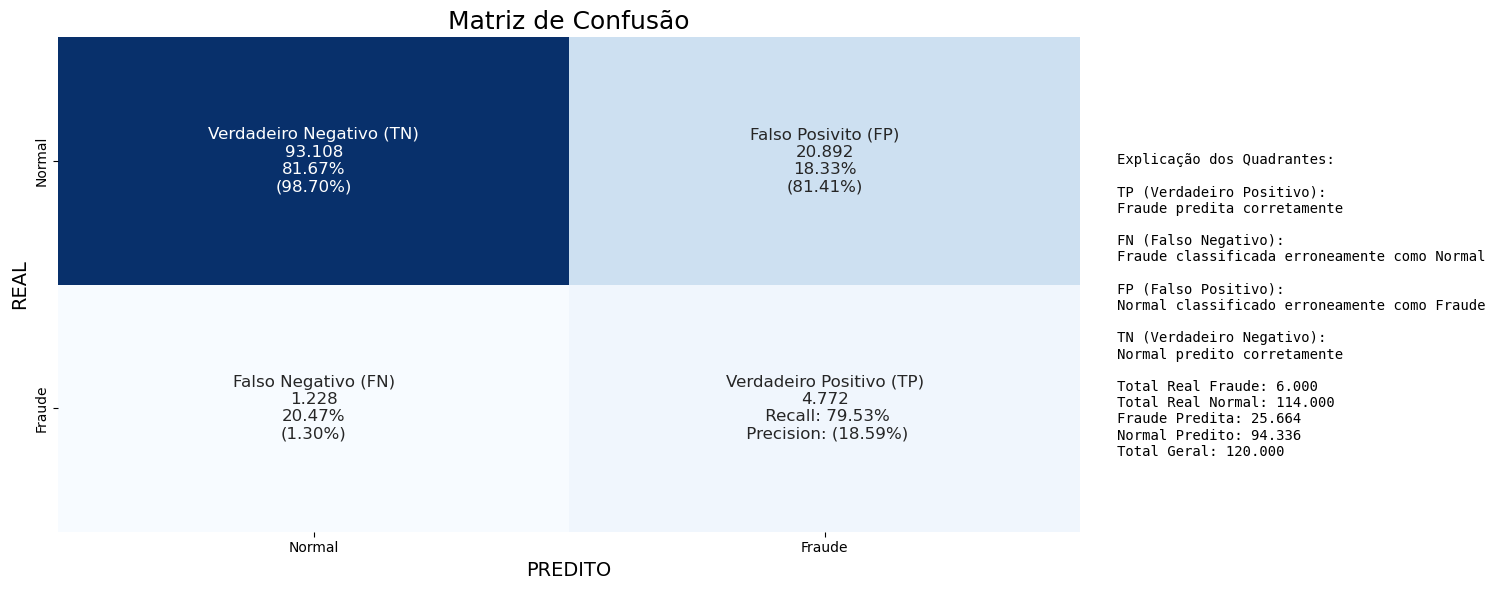

In [1000]:
matriz_confusao(xgb, x_train_selected, y_train_poly)

**Matriz de Confusão da base de Teste**

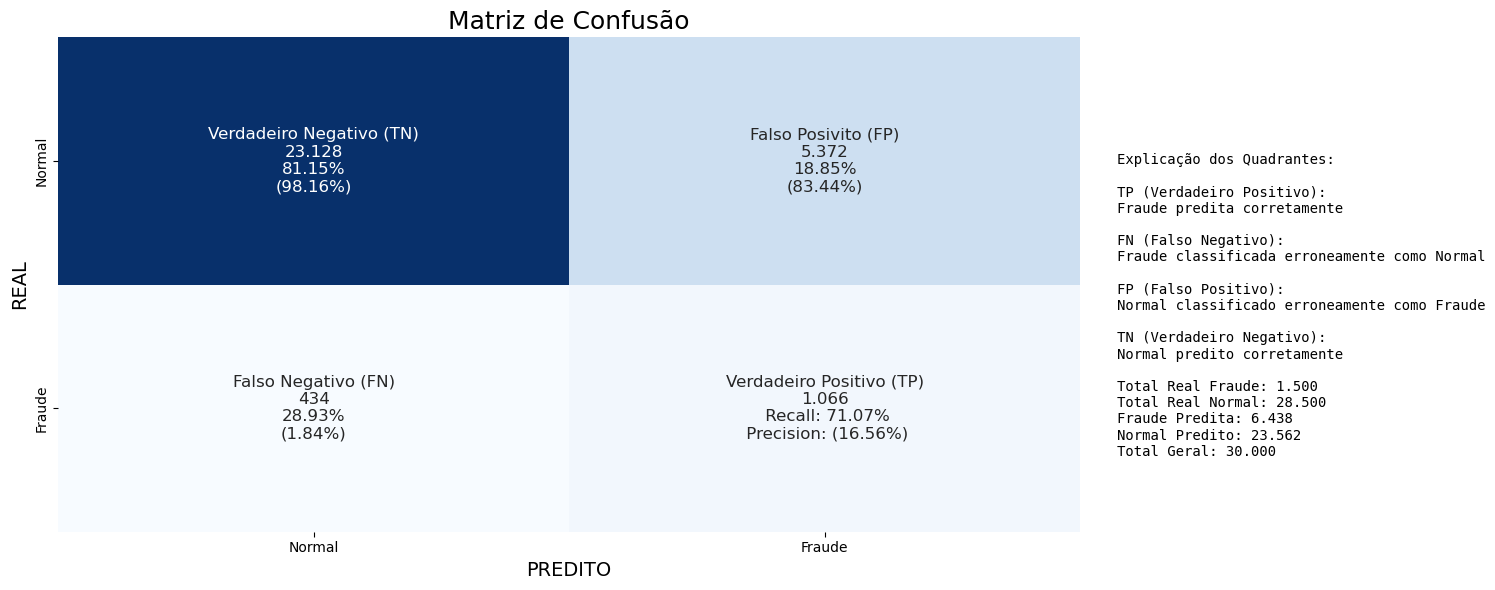

In [1002]:
matriz_confusao(xgb, x_test_selected, y_test_poly)

#### Tunagem de Hiperparâmetros

**Função objetivo que será utilizada pelo Optuna para testar os vários hiperparâmetros**

In [89]:
def objective_xgb(trial):
    # Calcula scale_pos_weight
    n_major = (y_train_xgb == 0).sum()
    n_minor = (y_train_xgb == 1).sum()
    scale_pos_weight = n_major / n_minor

    # Hiperparâmetros do XGB
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 250),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "scale_pos_weight": scale_pos_weight,
        "random_state": 42,
        "n_jobs": 6,
        "tree_method": "hist",
        "eval_metric": "logloss",
        "verbosity": 0
    }

    # Instancia o XGBClassifier
    xgb = XGBClassifier(**params)

    # Treina o modelo
    xgb.fit(X_train_xgb, y_train_xgb)


    # Criar o scorer F2
    f2_scorer = make_scorer(fbeta_score, beta=2)


    # Threshold tuning
    xgb_tt_clf = TunedThresholdClassifierCV(
        estimator=xgb,
        scoring=f2_scorer,
        cv=2
    )
    xgb_tt_clf.fit(X_train_xgb, y_train_xgb)

    # Avaliação
    y_pred = xgb_tt_clf.predict(X_val_xgb)
    return fbeta_score(y_val_xgb, y_pred, beta=2)

**Rodando a otimização que procurará os melhores hiperparâmetros que otimize o indicador-alvo**

In [91]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=50) 

print("Melhores hiperparâmetros encontrados:")
print(study_xgb.best_params)
print("Melhor indicador encontrado:", study_xgb.best_value)

[I 2025-10-28 15:03:30,295] A new study created in memory with name: no-name-5cb26c08-542d-4a1f-8f13-f2f1855239c3
[I 2025-10-28 15:03:34,972] Trial 0 finished with value: 0.4403409090909091 and parameters: {'n_estimators': 106, 'max_depth': 5, 'learning_rate': 0.18380109757459417, 'subsample': 0.6651202554170083, 'colsample_bytree': 0.7905555339637992, 'reg_alpha': 0.6275872854948866, 'reg_lambda': 3.980162988781229}. Best is trial 0 with value: 0.4403409090909091.
[I 2025-10-28 15:03:40,728] Trial 1 finished with value: 0.45283248237296375 and parameters: {'n_estimators': 146, 'max_depth': 6, 'learning_rate': 0.07594257274724708, 'subsample': 0.7368730597403809, 'colsample_bytree': 0.7572934664962134, 'reg_alpha': 2.2533153022429, 'reg_lambda': 1.8810478574093543}. Best is trial 1 with value: 0.45283248237296375.
[I 2025-10-28 15:03:45,737] Trial 2 finished with value: 0.447752808988764 and parameters: {'n_estimators': 153, 'max_depth': 5, 'learning_rate': 0.09958353626576905, 'subsam

Melhores hiperparâmetros encontrados:
{'n_estimators': 248, 'max_depth': 3, 'learning_rate': 0.14212964375616896, 'subsample': 0.9950224298826932, 'colsample_bytree': 0.9976190686451121, 'reg_alpha': 1.86098860418811, 'reg_lambda': 3.792049271465867}
Melhor indicador encontrado: 0.46954788890272764


**Instanciando o Modelo final já com os hiperparâmetros que tunam (otimizam) o indicador-alvo**

In [94]:
scale_pos_weight_xgb_final = (y_train_poly == 0).sum() / (y_train_poly == 1).sum()

xgb_tunado = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=scale_pos_weight_xgb_final,
    random_state=42,
    n_jobs=6,
    tree_method="hist",
    eval_metric="logloss",
    verbosity=0
)

**Envolvendo o Modelo no Threshold Tuning que maximiza o indicador-alvo**

In [98]:
f2_scorer = make_scorer(fbeta_score, beta=2)

In [100]:
xgb_tunado_tt_clf = TunedThresholdClassifierCV(
    estimator=xgb_tunado,
    scoring=f2_scorer,
    cv=2
)

**Treinando o Modelo Tunado na base de Treino**

In [102]:
xgb_tunado_tt_clf.fit(x_train_selected, y_train_poly)

,estimator,"XGBClassifier...ree=None, ...)"
,scoring,"make_scorer(f...dict', beta=2)"
,response_method,'auto'
,thresholds,100
,cv,2
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,objective,'binary:logistic'
,base_score,None


In [1005]:
desempenho_xgb_tunado_tt_clf=calcula_desempenho(xgb_tunado_tt_clf, x_train_selected , y_train_poly, x_test_selected, y_test_poly)


>>> Melhor threshold encontrado: 0.6149



In [1007]:
desempenho_xgb_tunado_tt_clf

,Treino,Teste,Variação%
Acurácia,87.09%,86.15%,-1.08%
AUROC,88.94%,84.37%,-5.14%
Precision,23.62%,20.79%,-11.99%
Recall,70.82%,63.00%,-11.04%
F1,35.43%,31.27%,-11.75%
F2,50.60%,44.81%,-11.45%


- **Nota-se que, após a tunagem de hiperparâmetros de todos os Modelos de Machine Learning/Deep Learning avaliados, o XGBoost foi o que apresentou a melhor métrica de avaliação utilizada como referência (F2-Score) na base de teste.**

- Em relação à **primeira Árvore de Decisão treinada**, o XGBoost apresentou um **ganho de 13,58 pontos percentuais no F2-Score** na base de teste, passando de 31,23% para 44,81%.

- **Em relação ao Modelo que é vigente atualmente (baseado na coluna `score_fraude_modelo`)**, o XGBoost apresentou um **aumento do indicador F2-Score de 16,90 pontos percentuais** (de 27,91% para 44,81%).

**Matriz de Confusão da base de Treino**

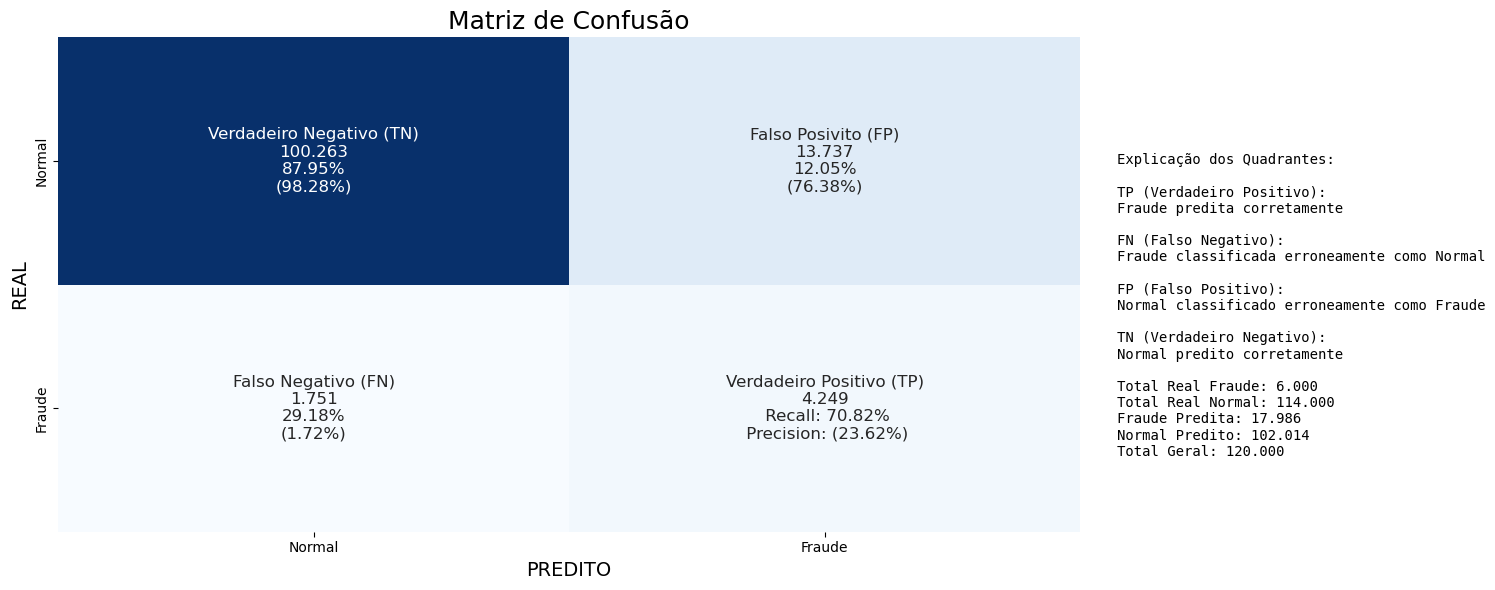

In [1009]:
matriz_confusao(xgb_tunado_tt_clf, x_train_selected, y_train_poly)

**Matriz de Confusão da base de Teste**

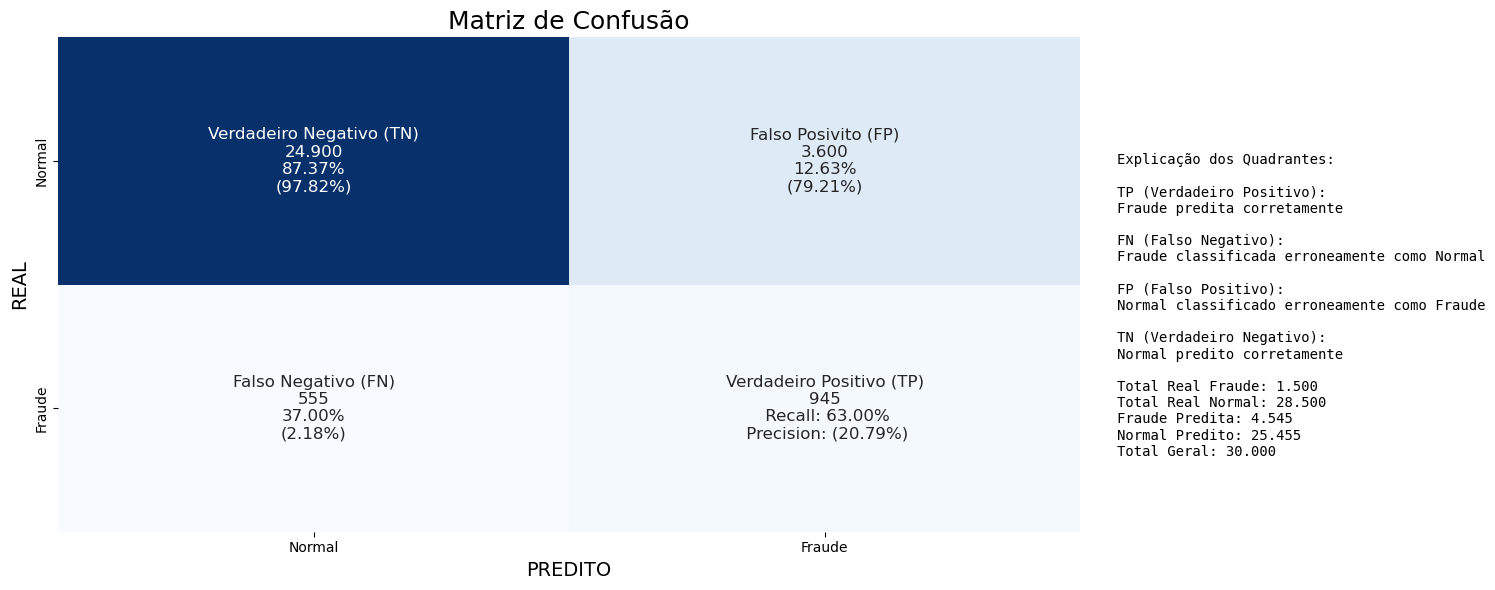

In [1011]:
matriz_confusao(xgb_tunado_tt_clf, x_test_selected, y_test_poly)

Na **Matriz de Confusão** (Confusion Matriz), da base de Teste, acima, podemos verificar que:

- Temos um total de **30.000 observações na base de Teste**.

    - Dessas, **1.500** observações (945 + 555) foram **Fraudes** (Positivo no contexto de Matriz de Confusão).
      
    - E **28.500** observações (24.900 + 3.600) foram **Normais** (Negativo no contexto de Matriz de Confusão).

- **Verdadeiro Positivo (TP - True Positive)**: Considerando a base de Teste, verificamos que este Modelo de Machine Learning identificou **945** observações Verdadeiro Positivo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam positivas (ser Fraude) e de fato foram positivas**. Ou seja, ele **conseguiu identificar 63% dos registros que de fato foram fraude** (945/1.500). Esse percentual é o **Recall**. Além disso, considerando que este Modelo previu 4.545 observações como fraude (945 + 3.600), **o nível de assertividade das *previsões* que o Modelo faz foi de 20,79% (945/4.545)**. Esse percentual é o **Precision**.

- **Falso Negativo (FN - False Negative)**: Considerando a base de Teste, verificamos que este Modelo de Machine Learning identificou **555** observações Falso Negativo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam negativas (ser Normal) mas, de fato, foram positivas (foram fraude)**. Isso representa 37% das fraudes efetivas. O Falso Negativo também é conhecido como Erro do Tipo II.

- **Falso Positivo (FP - False Positive)**: Considerando a base de Teste, verificamos que este Modelo de Machine Learning identificou **3.600** observações Falso Positivo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam positivas (ser Fraude) mas, de fato, foram negativas (foram Normais)**. Isso representa 79,21% das previsões de fraude realizadas por este Modelo. O Falso Positivo também é conhecido como Erro do Tipo I.

- **Verdadeiro Negativo (TN - True Negative)**: Considerando a base de Teste, verificamos que este Modelo de Machine Learning identificou **24.900** observações Verdadeiro Negativo. Ou seja, **observações que este Modelo de Machine Learning previu que seriam negativas (ser Normal) e de fato foram negativas**. Ou seja, ele conseguiu identificar 87,37% dos registros que de fato foram Normais (24.900/28.500).

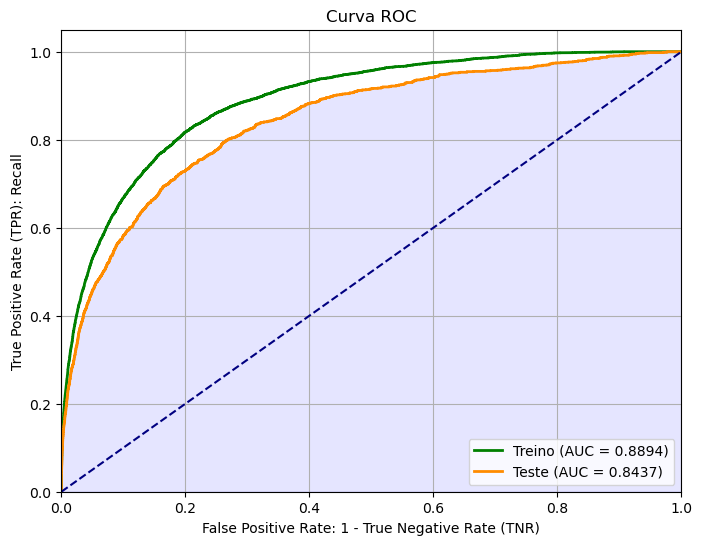

In [1051]:
curva_roc(xgb_tunado_tt_clf, x_train_selected, y_train_poly, x_test_selected, y_test_poly, titulo="Curva ROC")

## Interpretabilidade - SHAP (*SH*apley *A*dditive ex*P*lanations)

- Alguns Modelos de Machine Learning, especialmente os não lineares (como Random Forest, XGBoost, LightGBM, Redes Neurais, etc), costumam ser chamados de **caixas-pretas**. Ou seja, eles **dão previsões muito boas, mas não são diretamente interpretáveis**. Outros tipos de modelos, como a Regressão Logística, possuem resultados e coeficientes muito mais diretamente interpretáveis.
  
- Exemplo: Um Modelo diz que o cliente não deveria receber crédito. Mas se alguém perguntar qual feature está influenciando o modelo a tomar essa decisão e o quanto cada feature do Modelo está contribuindo nessa decisão, é complexo avaliar essa resposta para modelos "caixa-preta".

- O SHAP nasceu para resolver isso de forma justa e matematicamente consistente.

- O SHAP vem diretamente do Shapley Values, criados por Lloyd Shapley em 1953. Esses Shapley Values fazem parte da Teoria dos Jogos, que lhe garantiu o Nobel de Economia. O objetivo central do Shapley Values é: "Como dividir de forma justa o resultado (ganho) entre jogadores que cooperam em um jogo?"

- Em 2017, Scott M. Lundberg & Su-In Lee publicaram um artigo em que eles pegam os valores de Shapley da Teoria dos Jogos e traduzem matematicamente para o contexto de Machine Learning, criando um método aditivo para calcular explicações locais de previsões individuais, que ao serem agregadas, fornecem uma visão global do comportamento do modelo.

- **O SHAP calcula quanto cada feature contribui para a previsão do Modelo, comparando o Modelo com e sem aquela feature, em todas as possíveis combinações**.

- Iremos realizar a interpretação do XGBoost, que foi o Modelo que apresentou o melhor resultado medido através da métrica F2 Score.

#### Extração do Aprendizado do XGBoost

In [38]:
xgb_base_model = xgb_tunado_tt_clf.estimator_

In [39]:
xgb_explainer = shap.TreeExplainer(model=xgb_base_model, 
                                  data=x_test_selected)

xgb_shap_values = xgb_explainer.shap_values(X=x_test_selected)

100%|===================| 29976/30000 [04:56<00:00]        

In [40]:
xgb_shap_values

array([[ 0.04447116, -0.05394161, -0.02466598, ..., -0.02920276,
        -0.02886625,  0.15598732],
       [ 0.03113266, -0.02072683,  0.05416702, ..., -0.02924845,
         0.01201362, -0.0026785 ],
       [ 0.04665621, -0.03115996,  0.12139719, ...,  0.03895887,
        -0.00828606, -0.09523936],
       ...,
       [ 0.00959633, -0.01418004, -0.15932956, ...,  0.02193142,
         0.08947943,  0.14240531],
       [ 0.03437636, -0.01541139,  0.08314375, ...,  0.0940207 ,
        -0.03102758,  0.16928406],
       [ 0.02929079, -0.03616371,  0.0550503 , ...,  0.05585772,
         0.20339595,  0.07945326]])

#### Shap Summary Plot - Em gráfico de Enxame de Abelhas

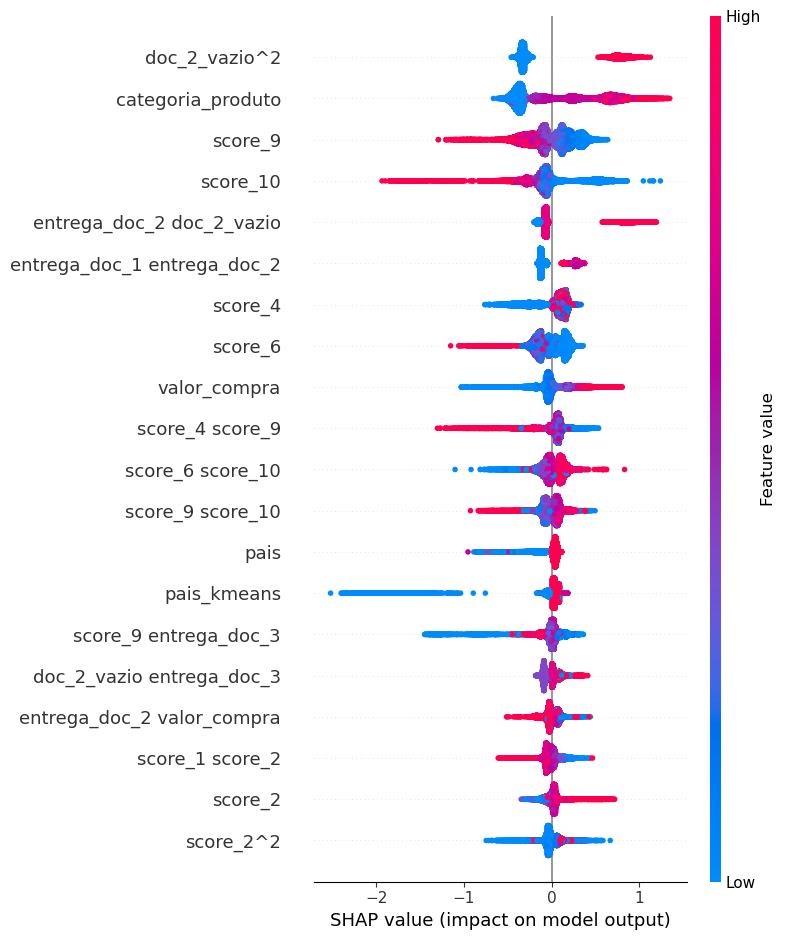

In [44]:
shap.summary_plot(shap_values=xgb_shap_values, 
                  features=x_test_selected,
                  plot_type='dot')

- Para entendermos o Shap Summary Plot em gráfico de Enxame de Abelhas precisamos definir os seguintes pontos:

    - A cor **vermelha** indica **valores altos da feature**/variável em questão.
      
    - A cor **azul** indica **valores baixos da feature**/variável em questão.
 
    - A cor **roxa** indica **valores centrais da feature**/variável em questão.
 
    - Quanto **maior o SHAP Value** (ou seja, quanto mais à direita no Eixo X), **maior a chance de uma observação pertencer à classe 1** (à classe 'Fraude', no nosso caso).
 
    - As features/variáveis estão na ordem de importância de maior para menor impacto de explicabilidade do Modelo.

- Então, no gráfico acima podemos concluir que:

    - As features mais importantes para o modelo são **`doc_2_vazio^2`, `categoria_produto`** e **`score_9`**
    
    - Quanto maior o valor de **`doc_2_vazio^2`** (ou seja, quando a feature entrega_doc_2 veio originalmente vazia), maior a chance de aquela transação ser fraudulenta.
 
    - Quanto maior o valor de **`categoria_produto`**, maior a chance de aquela transação ser fraudulenta. **`categoria_produto`** era uma feature categórica que passou pelo CatBoostEncoder. Essa interpretação do Shap Summary Plot faz sentido porque esse método de encoding irá atribuir valores maiores para categorias mais frequentes com o Target 1 (ou seja, com categorias de produto mais frequentemente associadas a transações fraudulentas).
 
    - Quanto menor o valor de **`score_9`**, maior a chance de aquela transação ser fraudulenta.
 
    - Quanto menor o valor de **`score_10`**, maior a chance de aquela transação ser fraudulenta.

#### Shap Waterfall Plot

- O Shap Waterfall Plot apresenta a decomposição aditiva da predição de uma observação individual, mostrando como cada feature contribui (positiva ou negativamente) para o valor final estimado pelo modelo de Machine Learning em relação ao valor de base (expected value).

In [91]:
def plot_waterfall_with_probs(shap_values, base_value, data, feature_names, max_display=10):
    """
    Cria waterfall plot com barras representando mudanças de probabilidade
    """
    # Função de conversão
    def logodds_to_prob(lo):
        return 1 / (1 + np.exp(-lo))
    
    # Preparar dados
    values = shap_values.copy()
    features = np.array(feature_names)
    feature_values = data.values
    
    # Ordenar por valor absoluto
    idx = np.argsort(-np.abs(values))
    
    # Pegar top features
    if len(idx) > max_display:
        other_sum = values[idx[max_display:]].sum()
        idx = idx[:max_display]
        values_plot = np.append(values[idx], other_sum)
        features_plot = np.append(features[idx], f'{len(values)-max_display} other features')
        feature_values_plot = np.append(feature_values[idx], np.nan)
    else:
        values_plot = values[idx]
        features_plot = features[idx]
        feature_values_plot = feature_values[idx]
    
    # Calcular posições acumuladas em log-odds
    cumsum_logodds = np.cumsum(values_plot)
    cumsum_logodds = np.insert(cumsum_logodds, 0, 0)
    
    # Converter para probabilidades
    prob_base = logodds_to_prob(base_value)
    probs_cumulative = [logodds_to_prob(base_value + c) for c in cumsum_logodds]
    
    # Calcular mudanças de probabilidade (delta)
    prob_changes = np.diff(probs_cumulative)
    
    # Criar figura
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Configurar eixos
    ax.set_xlabel('Probabilidade Acumulada', fontsize=12)
    ax.set_ylabel('Features', fontsize=12)
    
    # Plot das barras (agora em probabilidade)
    colors = ['#ff0051' if v > 0 else '#008bfb' for v in prob_changes]
    positions = range(1, len(prob_changes) + 1)
    
    # Barras horizontais
    for i, (delta_prob, color) in enumerate(zip(prob_changes, colors)):
        left = probs_cumulative[i]
        ax.barh(i + 1, delta_prob, left=left, color=color, alpha=0.8, height=0.6, 
                edgecolor='black', linewidth=0.5)
        
        # Adicionar valor de mudança de probabilidade no meio da barra
        ax.text(left + delta_prob/2, i + 1, f'{delta_prob:+.1%}', 
                ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Ponto base
    ax.plot(prob_base, 0, 'ko', markersize=10, zorder=5)
    ax.text(prob_base, 0, f'  Base\n  {prob_base:.1%}', 
            ha='left', va='center', fontsize=9, fontweight='bold')
    
    # Ponto final
    prob_final = probs_cumulative[-1]
    ax.plot(prob_final, len(prob_changes) + 1, 'ko', markersize=10, zorder=5)
    ax.text(prob_final, len(prob_changes) + 1, f'  Final\n  {prob_final:.1%}', 
            ha='left', va='center', fontsize=9, fontweight='bold')
    
    # Labels das features com valores
    labels = [f'{feat} = {val:.3f}' if not np.isnan(val) 
              else feat for feat, val in zip(features_plot, feature_values_plot)]
    
    all_positions = [0] + list(positions) + [len(prob_changes) + 1]
    all_labels = [''] + labels + ['']
    ax.set_yticks(all_positions)
    ax.set_yticklabels(all_labels, fontsize=10)
    ax.invert_yaxis()
    
    # Grid vertical
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Formatar eixo X como percentual
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
    
    # Limites do eixo X
    ax.set_xlim(0, 1)
    
    # Título
    delta_total = prob_final - prob_base
    plt.title(f'SHAP Waterfall Plot (Probability Scale)\n' + 
              f'Base: {prob_base:.2%} → Final: {prob_final:.2%} (Δ = {delta_total:+.2%})', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Box com informações
    textstr = f'Base log-odds: {base_value:.3f}\nFinal log-odds: {base_value + cumsum_logodds[-1]:.3f}'
    ax.text(0.02, 0.98, textstr, 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # Legenda
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#ff0051', alpha=0.8, label='Aumenta a chance de fraude'),
        Patch(facecolor='#008bfb', alpha=0.8, label='Reduz a chance de fraude')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [130]:
pd.set_option('display.max_rows', None)
y_test_poly.head(5)

22325    0
7970     1
47378    0
37537    0
40722    0
Name: fraude, dtype: int64

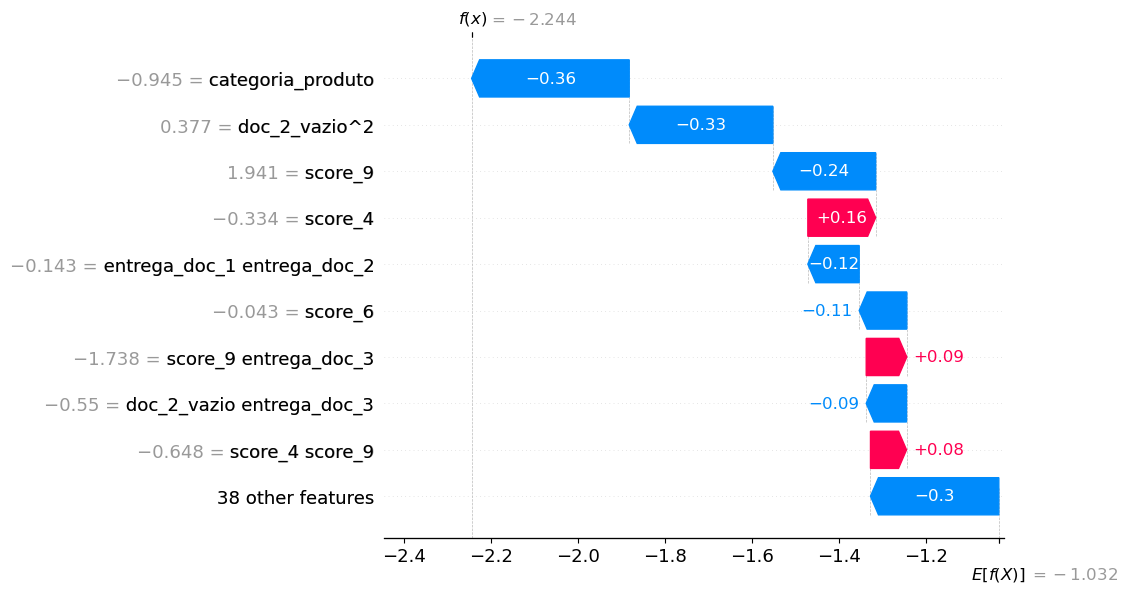

In [49]:
shap.waterfall_plot(shap.Explanation(values=xgb_shap_values[0], 
                                     base_values=xgb_explainer.expected_value,
                                     data=x_test_selected.iloc[0],
                                     feature_names=x_test_selected.columns.tolist()))

- No Gráfico de Cascata acima temos, no Eixo Y, as features na ordem da mais importante para a menos importante para a primeira linha do nosso dataset.

- O E[f(X)] = -1.032 mostrado na parte inferior direita é o valor esperado pelo base line do Modelo. Este é o log-odds médio de fraude considerando todas as transações. O XGBoost (e outros modelos de árvore) trabalha internamente em log-odds (logits), não diretamente em probabilidades. A conversão para probabilidade é dada por $p = \frac{1}{1 + e^{-f(X)}}$. Em termos de probabilidade, isso representa aproximadamente 26% de chance de fraude na população geral. 

- A feature **categoria_produto** foi a que mais influenciou a previsão desta instância em particular, contribuindo com -0,36 no log-odds.

- Ao somarmos a contribuição de todas as features, partimos de um valor esperado de -1.032 para -2,244 para essa instância. Ou seja, as características dessa transação a tornam menos provável de ser uma fraude do que o base line do Modelo.

- Para tornar a visualização mais interpretável, vamos executar a função 'plot_waterfall_with_probs' que converte o log-odds em probabilidade:

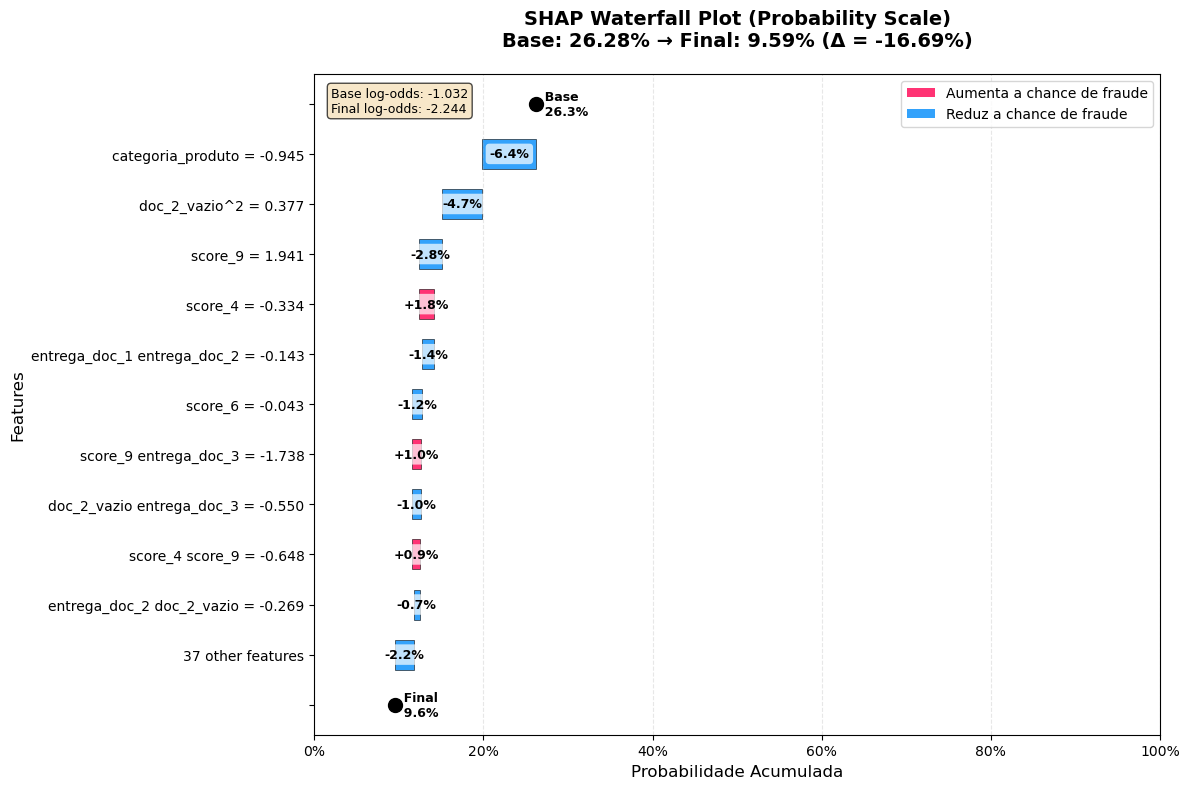

In [50]:
# Executando a função plot_waterfall_with_probs 
plot_waterfall_with_probs(
    shap_values=xgb_shap_values[0],
    base_value=xgb_explainer.expected_value,
    data=x_test_selected.iloc[0],
    feature_names=x_test_selected.columns.tolist(),
    max_display=10
)

- Ou seja, o base line de probabilidade de fraude era de 26%. A feature categoria_produto contribuiu com -6,4%. A feature doc_2_vazio^2 contribuiu com -4,7% e assim por diante. Ao somarmos a contribuição aditiva de todas as features a probabilidade dessa instância em específico de ser fraude é de 9,6%, abaixo da base line.

- **Agora vamos ver uma instância que apresentou fraude**:

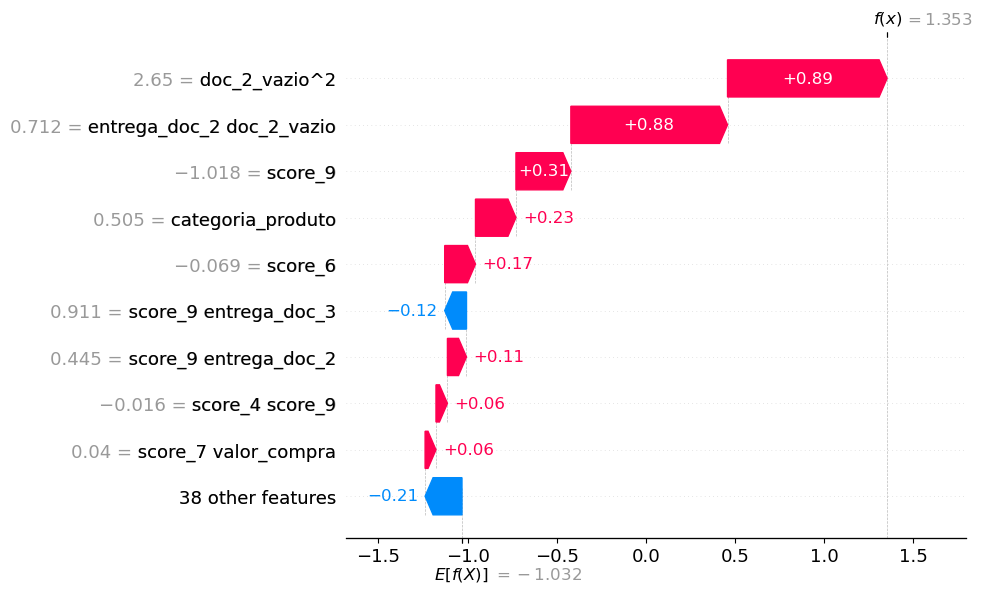

In [51]:
shap.waterfall_plot(shap.Explanation(values=xgb_shap_values[1], 
                                     base_values=xgb_explainer.expected_value,
                                     data=x_test_selected.iloc[1],
                                     feature_names=x_test_selected.columns.tolist()))

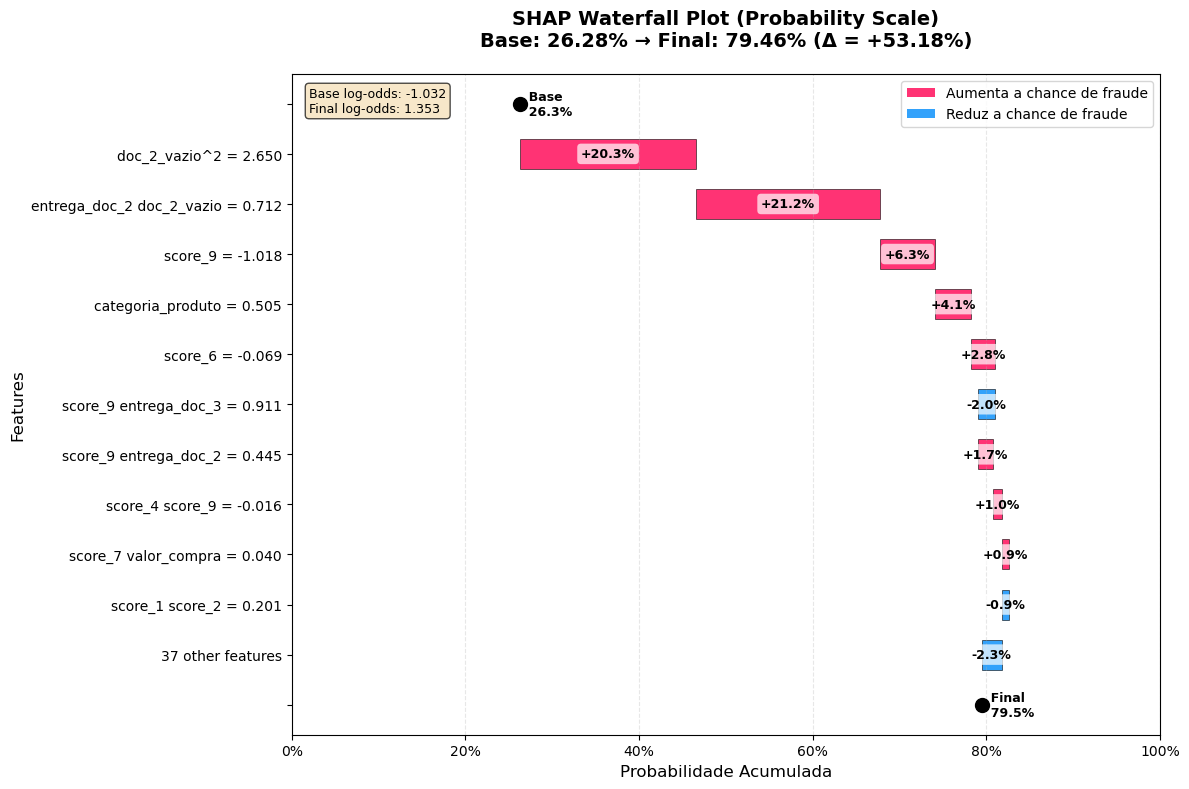

In [127]:
# Executando a função plot_waterfall_with_probs 
plot_waterfall_with_probs(
    shap_values=xgb_shap_values[1],
    base_value=xgb_explainer.expected_value,
    data=x_test_selected.iloc[1],
    feature_names=x_test_selected.columns.tolist(),
    max_display=10
)

- Partimos da base line de 26,3%.
  
- O fato de a feature entrega_doc_2 ser vazia contribuiu com mais 20,3% na probabilidade de a transação dessa instância ser fraude.

- O valor do Score_9 dessa instância contribuiu com mais 6,3% na probabilidade de a transação dessa instância ser fraude.

- Ao somarmos a contribuição aditiva de todas as features, a probabilidade dessa instância em específico ser fraude é de 79,5%, bem acima da base line.